# Trend Following Multi-Asset amb Dades Reals

## 1. Objectiu

En aquest projecte estudiarem estratègies de **trend following** utilitzant dades reals.

La idea bàsica del trend following és:

$$
\text{tendència passada}
\rightarrow
\text{possible persistència futura}
$$

A diferència del mean reversion, no esperem que el preu torni cap a un equilibri.

En trend following assumim que alguns moviments poden persistir durant un cert temps.

Començarem amb models molt simples per poder entendre exactament d'on prové qualsevol resultat abans d'afegir:

- diverses velocitats de trend;
- volatility targeting;
- cartera multi-actiu;
- costos;
- walk-forward;
- detecció de règims.

L'objectiu no és trobar el millor backtest, sinó comprovar si existeix un efecte robust i econòmicament explotable.

In [1]:
# IMPORTS I CONFIGURACIO INICIAL

import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("yfinance:", yf.__version__)

Python: 3.13.15
NumPy: 2.5.3
Pandas: 3.0.6
yfinance: 1.7.0


## 2. Univers d'actius

Per estudiar trend following utilitzarem diversos mercats.

No volem comprovar només si una regla funciona sobre accions, sinó si el fenomen de persistència de tendències apareix en actius amb comportaments econòmics diferents.

Univers inicial:

- **SPY**: accions dels Estats Units;
- **EFA**: accions de mercats desenvolupats fora dels EUA;
- **TLT**: bons del Tresor dels EUA de llarg termini;
- **GLD**: or;
- **DBC**: commodities.

L'objectiu inicial no és optimitzar aquest univers.

El farem servir com un laboratori senzill per entendre:

$$
\text{preu}
\rightarrow
\text{trend}
\rightarrow
\text{senyal}
\rightarrow
\text{posició}
\rightarrow
\text{retorn}
$$

Més endavant podrem ampliar l'univers si l'estratègia i la metodologia ho justifiquen.

In [2]:
# DESCARREGA DE DADES

tickers = ["SPY", "EFA", "TLT", "GLD", "DBC"]

data = yf.download(
    tickers,
    start="2007-01-01",
    end="2026-09-30",
    auto_adjust=True,
    progress=False
)

prices = data["Close"].copy()

print("Primeres files:")
display(prices.head())

print("\nUltimes files:")
display(prices.tail())

print("\nDimensions:")
print(prices.shape)

print("\nPeriode:")
print(prices.index.min(), "->", prices.index.max())

print("\nValors nuls:")
display(prices.isna().sum())

Primeres files:


Ticker,DBC,EFA,GLD,SPY,TLT
Date,,,,,
2007-01-03,19.330030,41.088039,62.279999,98.624565,48.048382
2007-01-04,18.826477,40.970665,61.650002,98.833839,48.339703
2007-01-05,18.761503,40.355827,60.169998,98.045578,48.129299
2007-01-08,18.858963,40.411720,60.480000,98.498978,48.215622
2007-01-09,18.696527,40.450851,60.849998,98.415260,48.215622



Ultimes files:


Ticker,DBC,EFA,GLD,SPY,TLT
Date,,,,,
2026-09-23,32.880001,104.800003,392.880005,767.809998,80.459999
2026-09-24,33.180000,104.500000,391.690002,767.179993,79.419998
2026-09-25,32.619999,105.559998,393.410004,771.349976,79.320000
2026-09-28,32.490002,105.040001,377.910004,765.609985,78.620003
2026-09-29,32.000000,104.540001,382.890015,764.200012,78.230003



Dimensions:
(4966, 5)

Periode:
2007-01-03 00:00:00 -> 2026-09-29 00:00:00

Valors nuls:


Ticker
DBC    0
EFA    0
GLD    0
SPY    0
TLT    0
dtype: int64

## 3. Evolució dels mercats

Abans de construir cap senyal, observem el comportament dels actius.

Com que cada ETF té un nivell de preu diferent, normalitzarem totes les sèries perquè comencin a 100:

$$
P_t^{norm}
=
100
\frac{P_t}{P_0}
$$

Això ens permet comparar visualment les seves trajectòries.

De moment no busquem una estratègia.

Volem observar si els mercats presenten períodes prolongats de:

- tendència alcista;
- tendència baixista;
- moviment lateral;
- canvis bruscos de règim.

Aquests períodes són el tipus d'estructura que una estratègia de trend following intentarà capturar.

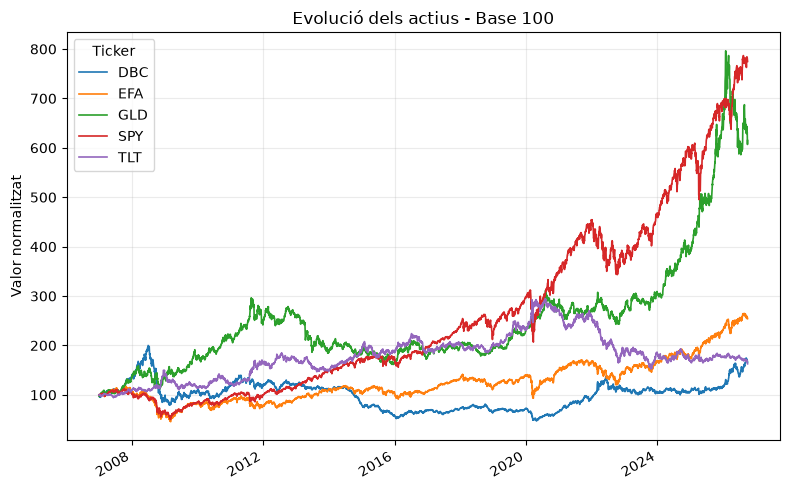

In [3]:
# PREUS NORMALITZATS

normalized_prices = prices / prices.iloc[0] * 100

ax = normalized_prices.plot(
    figsize=(8, 5),
    linewidth=1.2
)

ax.set_title("Evolució dels actius - Base 100")
ax.set_xlabel("")
ax.set_ylabel("Valor normalitzat")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

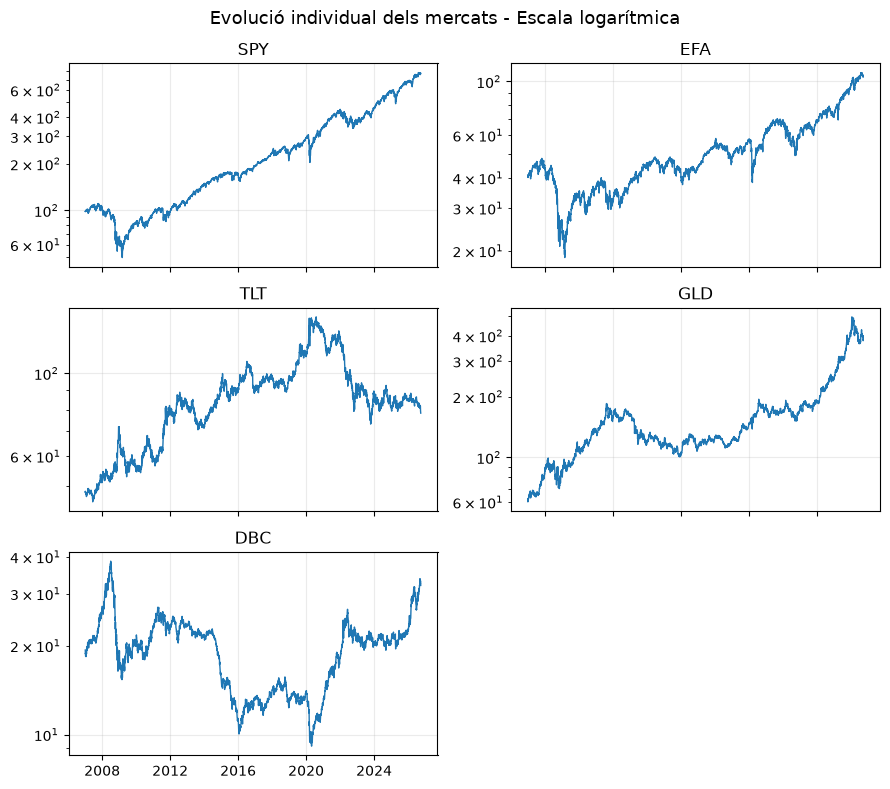

In [4]:
# EVOLUCIO INDIVIDUAL DELS MERCATS

fig, axes = plt.subplots(
    3, 2,
    figsize=(9, 8),
    sharex=True
)

axes = axes.flatten()

for i, ticker in enumerate(tickers):
    axes[i].plot(
        prices.index,
        prices[ticker],
        linewidth=1
    )

    axes[i].set_title(ticker)
    axes[i].set_yscale("log")
    axes[i].grid(alpha=0.25)

# Eliminem el panel que sobra
axes[-1].axis("off")

fig.suptitle(
    "Evolució individual dels mercats - Escala logarítmica",
    fontsize=13
)

plt.tight_layout()
plt.show()

## 4. Primera definició quantitativa de trend

La manera més simple de mesurar una tendència és calcular el retorn d'un actiu durant un horitzó passat.

Per un horitzó de $h$ dies:

$$
M_{t,h}
=
\frac{P_t}{P_{t-h}}-1
$$

Començarem utilitzant aproximadament un any borsari:

$$
h=252
$$

Per tant:

$$
M_{t,252}>0
\Rightarrow
\text{trend positiu}
$$

$$
M_{t,252}<0
\Rightarrow
\text{trend negatiu}
$$

Aquesta mesura no intenta predir directament el retorn futur.

Simplement resumeix la direcció que ha tingut el preu durant el passat recent.

Els 252 dies s'utilitzen inicialment com a baseline i no com un paràmetre optimitzat.

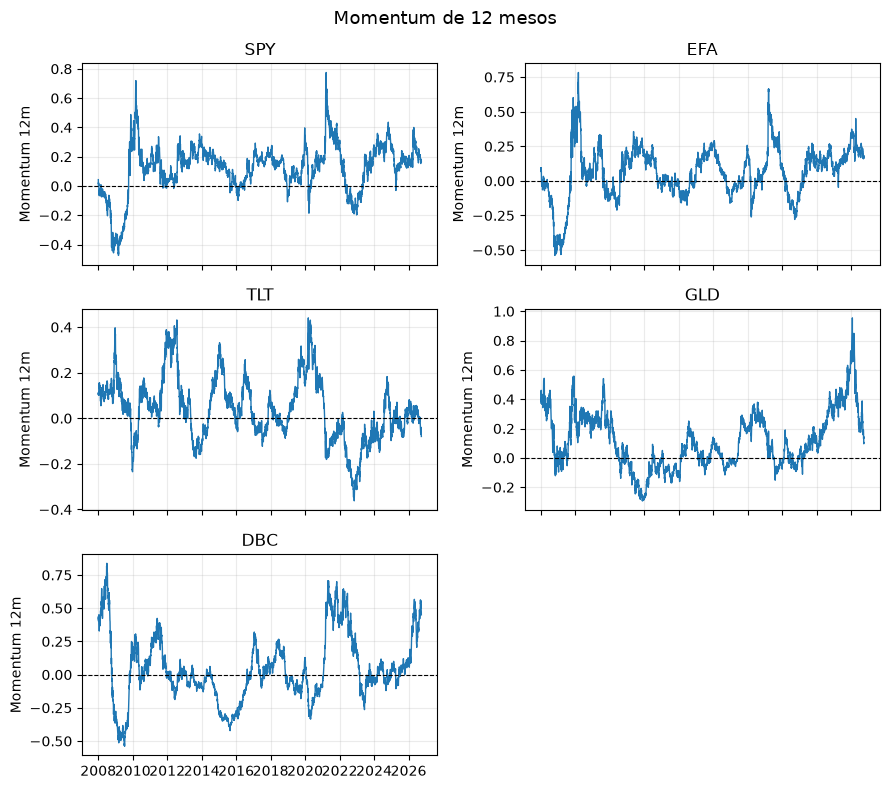

In [5]:
# MOMENTUM DE 12 MESOS

lookback = 252

momentum_12m = prices / prices.shift(lookback) - 1

fig, axes = plt.subplots(
    3, 2,
    figsize=(9, 8),
    sharex=True
)

axes = axes.flatten()

for i, ticker in enumerate(tickers):
    axes[i].plot(
        momentum_12m.index,
        momentum_12m[ticker],
        linewidth=1
    )

    axes[i].axhline(
        0,
        color="black",
        linewidth=0.8,
        linestyle="--"
    )

    axes[i].set_title(ticker)
    axes[i].set_ylabel("Momentum 12m")
    axes[i].grid(alpha=0.25)

axes[-1].axis("off")

fig.suptitle(
    "Momentum de 12 mesos",
    fontsize=13
)

plt.tight_layout()
plt.show()

## 5. Primer senyal de trend following

Transformarem el momentum de 12 mesos en un primer senyal binari:

$$
Signal_t =
\begin{cases}
1 & \text{si } M_{t,252}>0 \\
0 & \text{si } M_{t,252}\leq0
\end{cases}
$$

Aquesta primera versió serà **LONG / FLAT**:

- `1`: mantenim una posició long;
- `0`: no tenim exposició.

És important evitar lookahead.

El senyal calculat amb el tancament del dia $t$ només pot utilitzar-se a partir del període següent.

Per tant:

$$
Position_t = Signal_{t-1}
$$

i el retorn de l'estratègia és:

$$
R_t^{strategy}
=
Position_tR_t
$$

Així, cada retorn només utilitza informació que ja era coneguda abans que comencés aquell període.

In [6]:
# PRIMER SENYAL LONG FLAT

# Retorns diaris dels actius
daily_returns = prices.pct_change()

# Senyal:
# 1 = momentum positiu
# 0 = momentum negatiu
signal_long_flat = (momentum_12m > 0).astype(float)

# Durant els primers 252 dies encara no tenim prou historial
signal_long_flat[momentum_12m.isna()] = np.nan

# Retardem el senyal un dia per evitar lookahead
positions_long_flat = signal_long_flat.shift(1).fillna(0.0)

# Retorn de l'estrategia
strategy_returns = positions_long_flat * daily_returns

# Exemple amb SPY per comprovar la logica
check_spy = pd.DataFrame({
    "Price": prices["SPY"],
    "Momentum_12m": momentum_12m["SPY"],
    "Signal": signal_long_flat["SPY"],
    "Position": positions_long_flat["SPY"],
    "Return": daily_returns["SPY"],
    "Strategy_Return": strategy_returns["SPY"]
})

display(check_spy.tail(15))

,Price,Momentum_12m,Signal,Position,Return,Strategy_Return
Date,,,,,,
2026-09-09,760.511536,0.188058,1.0,1.0,-0.004648,-0.004648
2026-09-10,755.952820,0.178213,1.0,1.0,-0.005994,-0.005994
2026-09-11,762.396790,0.184831,1.0,1.0,0.008524,0.008524
2026-09-14,758.995239,0.169823,1.0,1.0,-0.004462,-0.004462
2026-09-15,755.513916,0.164847,1.0,1.0,-0.004587,-0.004587
2026-09-16,752.182190,0.153569,1.0,1.0,-0.004410,-0.004410
2026-09-17,760.710999,0.168257,1.0,1.0,0.011339,0.011339
2026-09-18,761.690002,0.171216,1.0,1.0,0.001287,0.001287
2026-09-21,773.500000,0.183844,1.0,1.0,0.015505,0.015505


## 6. Primer backtest: Trend Following vs Buy & Hold

Ara compararem la primera estratègia amb el benchmark més simple:

$$
\text{Trend Following LONG/FLAT}
\quad
vs
\quad
\text{Buy \& Hold}
$$

La comparació començarà el mateix dia per a les dues estratègies, un cop disposem dels 252 dies necessaris per calcular el momentum.

Mesurarem:

- retorn total;
- CAGR;
- volatilitat anualitzada;
- Sharpe Ratio;
- màxim drawdown;
- percentatge de temps invertit.

El CAGR és:

$$
CAGR
=
\left(
\frac{V_T}{V_0}
\right)^{1/T}
-1
$$

La volatilitat anualitzada és:

$$
\sigma_{anual}
=
\sigma_{diaria}\sqrt{252}
$$

I, assumint de moment tipus lliure de risc igual a zero:

$$
Sharpe
=
\frac{\bar r_{diari}}{\sigma_{diaria}}
\sqrt{252}
$$

Aquest primer backtest no inclou costos ni remuneració del cash.

L'objectiu és entendre el comportament brut de la regla abans d'afegir més realisme.

In [7]:
# PRIMER BACKTEST TREND VS BUY AND HOLD

# Posicio retardada sense omplir els NaN inicials
positions_raw = signal_long_flat.shift(1)

# Primer dia en què tenim una posicio valida per a tots els actius
valid_days = positions_raw.notna().all(axis=1)
backtest_start = positions_raw.index[valid_days][0]

# Mateix periode per estrategia i benchmark
positions_bt = positions_raw.loc[backtest_start:].copy()
returns_bt = daily_returns.loc[backtest_start:].copy()

strategy_returns_bt = positions_bt * returns_bt
buyhold_returns_bt = returns_bt.copy()

print("Inici del backtest:", backtest_start.date())
print("Final del backtest:", returns_bt.index[-1].date())


def performance_metrics(returns, exposure=None):
    returns = returns.dropna()

    equity = (1 + returns).cumprod()

    years = (
        returns.index[-1] - returns.index[0]
    ).days / 365.25

    total_return = equity.iloc[-1] - 1

    cagr = equity.iloc[-1] ** (1 / years) - 1

    volatility = returns.std() * np.sqrt(252)

    if returns.std() > 0:
        sharpe = (
            returns.mean()
            / returns.std()
            * np.sqrt(252)
        )
    else:
        sharpe = np.nan

    drawdown = equity / equity.cummax() - 1
    max_drawdown = drawdown.min()

    if exposure is None:
        avg_exposure = 1.0
    else:
        avg_exposure = exposure.loc[returns.index].mean()

    return {
        "Total Return": total_return,
        "CAGR": cagr,
        "Volatility": volatility,
        "Sharpe": sharpe,
        "Max Drawdown": max_drawdown,
        "Exposure": avg_exposure
    }


results = []

for ticker in tickers:

    trend_metrics = performance_metrics(
        strategy_returns_bt[ticker],
        positions_bt[ticker]
    )

    buyhold_metrics = performance_metrics(
        buyhold_returns_bt[ticker]
    )

    results.append({
        "Ticker": ticker,
        "Strategy": "Trend",
        **trend_metrics
    })

    results.append({
        "Ticker": ticker,
        "Strategy": "Buy & Hold",
        **buyhold_metrics
    })


results_df = pd.DataFrame(results)

percentage_cols = [
    "Total Return",
    "CAGR",
    "Volatility",
    "Max Drawdown",
    "Exposure"
]

results_display = results_df.copy()

for col in percentage_cols:
    results_display[col] = (
        results_display[col] * 100
    ).map(lambda x: f"{x:.2f}%")

results_display["Sharpe"] = (
    results_display["Sharpe"]
    .map(lambda x: f"{x:.2f}")
)

display(results_display)

Inici del backtest: 2008-01-04
Final del backtest: 2026-09-29


,Ticker,Strategy,Total Return,CAGR,Volatility,Sharpe,Max Drawdown,Exposure
0,SPY,Trend,351.10%,8.37%,13.84%,0.65,-31.17%,82.05%
1,SPY,Buy & Hold,642.49%,11.29%,19.73%,0.64,-51.48%,100.00%
2,EFA,Trend,35.87%,1.65%,12.77%,0.19,-29.16%,64.25%
3,EFA,Buy & Hold,132.76%,4.61%,21.75%,0.32,-58.34%,100.00%
4,TLT,Trend,19.06%,0.94%,12.33%,0.14,-37.74%,60.00%
5,TLT,Buy & Hold,46.75%,2.07%,15.25%,0.21,-48.35%,100.00%
6,GLD,Trend,138.68%,4.75%,15.54%,0.38,-36.42%,66.52%
7,GLD,Buy & Hold,347.46%,8.33%,18.22%,0.53,-45.56%,100.00%
8,DBC,Trend,69.79%,2.87%,14.02%,0.27,-50.45%,50.65%
9,DBC,Buy & Hold,17.65%,0.87%,19.39%,0.14,-76.36%,100.00%


## 7. Equity curves: Trend Following vs Buy & Hold

Les mètriques finals no expliquen quan es produeixen els guanys i les pèrdues.

Per entendre el comportament de l'estratègia compararem l'evolució d'una inversió inicial de 100:

$$
V_0 = 100
$$

Per cada actiu observarem:

$$
\text{Trend LONG/FLAT}
\quad
vs
\quad
\text{Buy \& Hold}
$$

Ens interessa especialment detectar:

- grans caigudes que el trend aconsegueix evitar;
- períodes laterals on apareixen falsos senyals;
- retards en la sortida;
- retards en la reentrada;
- períodes on Buy & Hold captura millor una tendència alcista.

L'objectiu no és només saber quin resultat final és superior, sinó entendre d'on prové la diferència.

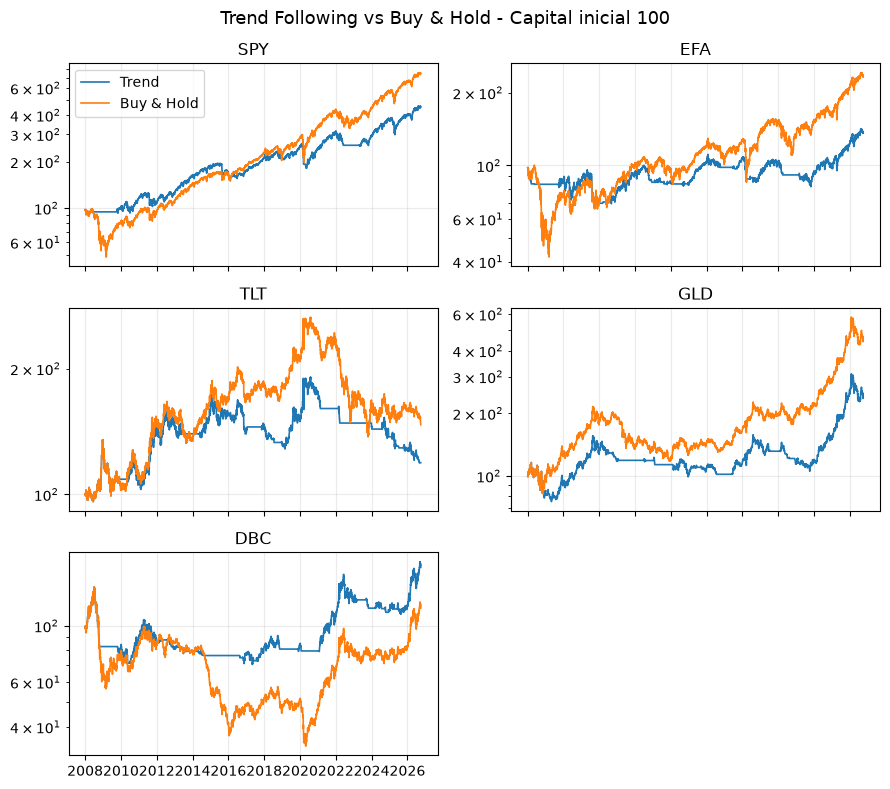

In [8]:
# EQUITY CURVES TREND VS BUY AND HOLD

fig, axes = plt.subplots(
    3, 2,
    figsize=(9, 8),
    sharex=True
)

axes = axes.flatten()

for i, ticker in enumerate(tickers):

    trend_equity = (
        1 + strategy_returns_bt[ticker].fillna(0)
    ).cumprod() * 100

    buyhold_equity = (
        1 + buyhold_returns_bt[ticker].fillna(0)
    ).cumprod() * 100

    axes[i].plot(
        trend_equity.index,
        trend_equity,
        label="Trend",
        linewidth=1.2
    )

    axes[i].plot(
        buyhold_equity.index,
        buyhold_equity,
        label="Buy & Hold",
        linewidth=1.2
    )

    axes[i].set_title(ticker)
    axes[i].set_yscale("log")
    axes[i].grid(alpha=0.25)

    if i == 0:
        axes[i].legend()

axes[-1].axis("off")

fig.suptitle(
    "Trend Following vs Buy & Hold - Capital inicial 100",
    fontsize=13
)

plt.tight_layout()
plt.show()

## 8. Posicions i whipsaw

Una estratègia de trend following reacciona amb retard als canvis de direcció.

Quan el momentum passa a negatiu, l'estratègia surt del mercat. Quan torna a ser positiu, torna a entrar.

Aquest mecanisme pot protegir durant tendències baixistes prolongades, però genera un problema en mercats laterals:

$$
+\rightarrow-\rightarrow+\rightarrow-\rightarrow+
$$

Cada canvi pot provocar una entrada o una sortida sense que aparegui una tendència prou gran.

Aquest fenomen s'anomena **whipsaw**.

Visualitzarem els períodes:

- verd: posició LONG;
- sense ombrejat: FLAT.

Això ens permetrà veure exactament quan el model decideix participar en el mercat.

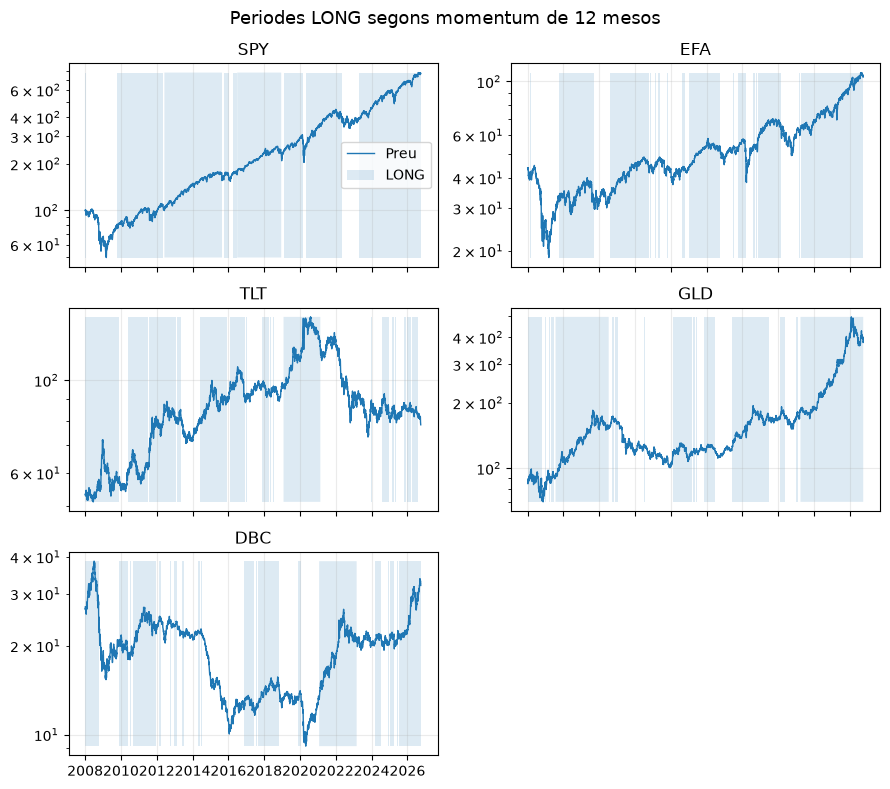

In [9]:
# REGIMS LONG I FLAT

fig, axes = plt.subplots(
    3, 2,
    figsize=(9, 8),
    sharex=True
)

axes = axes.flatten()

for i, ticker in enumerate(tickers):

    price_bt = prices.loc[backtest_start:, ticker]
    position_bt = positions_bt[ticker]

    axes[i].plot(
        price_bt.index,
        price_bt,
        linewidth=1,
        label="Preu"
    )

    ymin = price_bt.min()
    ymax = price_bt.max()

    axes[i].fill_between(
        price_bt.index,
        ymin,
        ymax,
        where=(position_bt > 0),
        alpha=0.15,
        label="LONG"
    )

    axes[i].set_title(ticker)
    axes[i].set_yscale("log")
    axes[i].grid(alpha=0.25)

    if i == 0:
        axes[i].legend()

axes[-1].axis("off")

fig.suptitle(
    "Periodes LONG segons momentum de 12 mesos",
    fontsize=13
)

plt.tight_layout()
plt.show()

## 9. Persistència de les posicions i whipsaw

Ara quantificarem el que hem observat visualment.

Per cada actiu calcularem:

- nombre de períodes LONG;
- durada mitjana d'un període LONG;
- durada mediana;
- període LONG més llarg;
- nombre total de canvis LONG/FLAT;
- canvis anuals aproximats.

Molts canvis de posició poden indicar **whipsaw**.

A més, més canvis impliquen potencialment més turnover i més costos de transacció.

In [10]:
# DURADA DE POSICIONS I WHIPSAW

position_stats = []

years_bt = (
    positions_bt.index[-1] - positions_bt.index[0]
).days / 365.25


for ticker in tickers:

    pos = positions_bt[ticker].dropna().astype(int)

    # Cada vegada que la posicio canvia comenca un nou bloc
    groups = pos.ne(pos.shift()).cumsum()

    runs = (
        pos.groupby(groups)
        .agg(["first", "size"])
        .rename(columns={
            "first": "Position",
            "size": "Days"
        })
    )

    long_runs = runs[runs["Position"] == 1]

    # Nombre de canvis LONG <-> FLAT
    switches = pos.diff().abs().eq(1).sum()

    position_stats.append({
        "Ticker": ticker,
        "Long periods": len(long_runs),
        "Avg long days": long_runs["Days"].mean(),
        "Median long days": long_runs["Days"].median(),
        "Max long days": long_runs["Days"].max(),
        "Switches": switches,
        "Switches/year": switches / years_bt,
        "Exposure": pos.mean()
    })


position_stats_df = pd.DataFrame(position_stats)

position_stats_df["Avg long days"] = (
    position_stats_df["Avg long days"].round(1)
)

position_stats_df["Median long days"] = (
    position_stats_df["Median long days"].round(1)
)

position_stats_df["Switches/year"] = (
    position_stats_df["Switches/year"].round(1)
)

position_stats_df["Exposure"] = (
    position_stats_df["Exposure"] * 100
).map(lambda x: f"{x:.1f}%")

display(position_stats_df)

,Ticker,Long periods,Avg long days,Median long days,Max long days,Switches,Switches/year,Exposure
0,SPY,36,107.4,4.5,810,70,3.7,82.0%
1,EFA,71,42.6,3.0,500,140,7.5,64.2%
2,TLT,58,48.8,5.0,519,115,6.1,60.0%
3,GLD,55,57.0,3.0,879,108,5.8,66.5%
4,DBC,64,37.3,3.0,529,126,6.7,50.6%


## 10. Costos de transacció

Fins ara hem assumit que entrar i sortir del mercat és gratuït.

Definim el turnover diari com:

$$
Turnover_t
=
|Position_t-Position_{t-1}|
$$

Un canvi:

$$
0\rightarrow1
$$

representa una entrada, mentre que:

$$
1\rightarrow0
$$

representa una sortida.

Els retorns nets seran:

$$
R_t^{net}
=
R_t^{gross}
-
Turnover_t \cdot Cost
$$

No assumirem encara un únic cost correcte.

Compararem diversos escenaris:

$$
0,\ 5,\ 10,\ 20
$$

basis points per unitat de turnover.

Això ens permet veure fins a quin punt l'estratègia depèn d'una execució barata.

In [11]:
# SENSIBILITAT ALS COSTOS DE TRANSACCIO

turnover = positions_bt.diff().abs().fillna(0)

cost_levels_bps = [0, 5, 10, 20]

cost_results = []

for cost_bps in cost_levels_bps:

    cost_rate = cost_bps / 10000

    net_returns = (
        strategy_returns_bt
        - turnover * cost_rate
    )

    for ticker in tickers:

        metrics = performance_metrics(
            net_returns[ticker],
            positions_bt[ticker]
        )

        cost_results.append({
            "Ticker": ticker,
            "Cost (bps)": cost_bps,
            "CAGR": metrics["CAGR"],
            "Sharpe": metrics["Sharpe"],
            "Max Drawdown": metrics["Max Drawdown"]
        })


cost_results_df = pd.DataFrame(cost_results)

cost_display = cost_results_df.copy()

cost_display["CAGR"] = (
    cost_display["CAGR"] * 100
).map(lambda x: f"{x:.2f}%")

cost_display["Max Drawdown"] = (
    cost_display["Max Drawdown"] * 100
).map(lambda x: f"{x:.2f}%")

cost_display["Sharpe"] = (
    cost_display["Sharpe"]
    .map(lambda x: f"{x:.2f}")
)

display(cost_display)

,Ticker,Cost (bps),CAGR,Sharpe,Max Drawdown
0,SPY,0,8.37%,0.65,-31.17%
1,EFA,0,1.65%,0.19,-29.16%
2,TLT,0,0.94%,0.14,-37.74%
3,GLD,0,4.75%,0.38,-36.42%
4,DBC,0,2.87%,0.27,-50.45%
5,SPY,5,8.17%,0.64,-31.38%
6,EFA,5,1.27%,0.16,-30.43%
7,TLT,5,0.63%,0.11,-39.12%
8,GLD,5,4.45%,0.36,-37.18%
9,DBC,5,2.52%,0.25,-52.54%


## 11. Primera cartera multi-actiu

Fins ara hem estudiat cada mercat individualment.

Però una estratègia de trend following multi-actiu no depèn necessàriament de trobar un mercat on el senyal funcioni excepcionalment bé.

La idea és combinar tendències de mercats diferents:

$$
\text{diversificació}
+
\text{tendències independents}
\rightarrow
\text{cartera}
$$

Començarem amb una assignació inicial igual:

$$
w_i = \frac{1}{5}=20\%
$$

per cada mercat.

Cada bloc de capital funcionarà independentment.

Si el senyal d'un actiu és LONG, aquell capital estarà invertit.

Si el senyal és FLAT, aquell capital quedarà en cash.

De moment:

- no redistribuirem el capital dels actius inactius;
- no utilitzarem leverage;
- no farem volatility targeting;
- utilitzarem un cost de 10 bps per unitat de turnover.

Compararem aquesta cartera de trend following amb una cartera passiva que comença amb el mateix 20% de capital en cada ETF.

,Portfolio,Total Return,CAGR,Volatility,Sharpe,Max Drawdown,Exposure
0,Trend,104.10%,3.88%,7.78%,0.53,-17.31%,1.0
1,Buy & Hold,241.38%,6.77%,10.87%,0.66,-31.14%,1.0


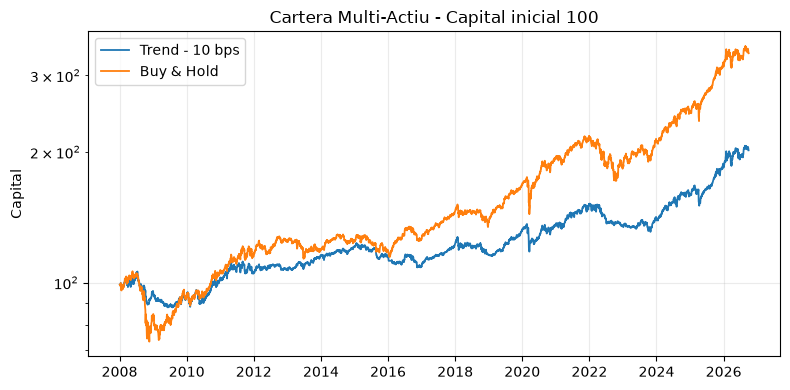

In [12]:
# PRIMERA CARTERA MULTI-ACTIU

cost_bps = 10
cost_rate = cost_bps / 10000

# Retorns nets de cada motor Trend
trend_net_returns = (
    strategy_returns_bt
    - turnover * cost_rate
)

initial_capital = 100
capital_per_asset = initial_capital / len(tickers)

# Cada actiu comenca amb 20 i evoluciona independentment
trend_sleeves = pd.DataFrame(index=returns_bt.index)
buyhold_sleeves = pd.DataFrame(index=returns_bt.index)

for ticker in tickers:

    trend_sleeves[ticker] = (
        1 + trend_net_returns[ticker].fillna(0)
    ).cumprod() * capital_per_asset

    buyhold_sleeves[ticker] = (
        1 + buyhold_returns_bt[ticker].fillna(0)
    ).cumprod() * capital_per_asset


# Capital total de les dues carteres
trend_portfolio = trend_sleeves.sum(axis=1)
buyhold_portfolio = buyhold_sleeves.sum(axis=1)

# Retorns diaris de cartera
trend_portfolio_returns = trend_portfolio.pct_change().fillna(0)
buyhold_portfolio_returns = buyhold_portfolio.pct_change().fillna(0)


# Metriques
trend_portfolio_metrics = performance_metrics(
    trend_portfolio_returns
)

buyhold_portfolio_metrics = performance_metrics(
    buyhold_portfolio_returns
)


portfolio_results = pd.DataFrame([
    {
        "Portfolio": "Trend",
        **trend_portfolio_metrics
    },
    {
        "Portfolio": "Buy & Hold",
        **buyhold_portfolio_metrics
    }
])


percentage_cols = [
    "Total Return",
    "CAGR",
    "Volatility",
    "Max Drawdown"
]

portfolio_display = portfolio_results.copy()

for col in percentage_cols:
    portfolio_display[col] = (
        portfolio_display[col] * 100
    ).map(lambda x: f"{x:.2f}%")

portfolio_display["Sharpe"] = (
    portfolio_display["Sharpe"]
    .map(lambda x: f"{x:.2f}")
)

display(portfolio_display)


# Equity curves
plt.figure(figsize=(8, 4))

plt.plot(
    trend_portfolio.index,
    trend_portfolio,
    label="Trend - 10 bps",
    linewidth=1.3
)

plt.plot(
    buyhold_portfolio.index,
    buyhold_portfolio,
    label="Buy & Hold",
    linewidth=1.3
)

plt.title("Cartera Multi-Actiu - Capital inicial 100")
plt.ylabel("Capital")
plt.yscale("log")
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

## 12. Correlació i diversificació

Tenir diversos actius no implica automàticament tenir una cartera diversificada.

La diversificació depèn de com es mouen els retorns conjuntament.

La correlació entre dos actius $A$ i $B$ és:

$$
\rho_{A,B}
=
\frac{
Cov(R_A,R_B)
}{
\sigma_A\sigma_B
}
$$

Interpretació:

- $\rho \approx 1$: es mouen molt semblant;
- $\rho \approx 0$: poca relació lineal;
- $\rho \approx -1$: tendeixen a moure's en direccions oposades.

La correlació tampoc és constant.

Durant períodes de crisi pot canviar fortament, de manera que una cartera aparentment diversificada en períodes normals pot estar molt més concentrada del que sembla.

Compararem:

1. correlació entre els retorns dels actius;
2. correlació entre els retorns dels motors de Trend Following.

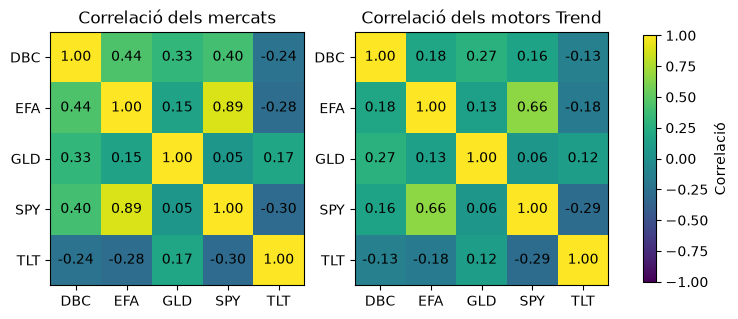

Ordre real de les columnes:
['DBC', 'EFA', 'GLD', 'SPY', 'TLT']


In [14]:
# CORRELACIO ENTRE MERCATS I MOTORS TREND

asset_corr = returns_bt.corr()
trend_corr = trend_net_returns.corr()

fig, axes = plt.subplots(
    1, 2,
    figsize=(9, 4)
)

# CORRELACIO DELS MERCATS

labels_asset = asset_corr.columns

im1 = axes[0].imshow(
    asset_corr,
    vmin=-1,
    vmax=1
)

axes[0].set_title("Correlació dels mercats")

axes[0].set_xticks(range(len(labels_asset)))
axes[0].set_yticks(range(len(labels_asset)))
axes[0].set_xticklabels(labels_asset)
axes[0].set_yticklabels(labels_asset)

for i in range(len(labels_asset)):
    for j in range(len(labels_asset)):
        axes[0].text(
            j,
            i,
            f"{asset_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )


# CORRELACIO DELS MOTORS TREND

labels_trend = trend_corr.columns

im2 = axes[1].imshow(
    trend_corr,
    vmin=-1,
    vmax=1
)

axes[1].set_title("Correlació dels motors Trend")

axes[1].set_xticks(range(len(labels_trend)))
axes[1].set_yticks(range(len(labels_trend)))
axes[1].set_xticklabels(labels_trend)
axes[1].set_yticklabels(labels_trend)

for i in range(len(labels_trend)):
    for j in range(len(labels_trend)):
        axes[1].text(
            j,
            i,
            f"{trend_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(
    im2,
    ax=axes,
    shrink=0.8,
    label="Correlació"
)

plt.show()

print("Ordre real de les columnes:")
print(list(returns_bt.columns))

## 13. Correlacions durant períodes de crisi

La correlació històrica mitjana pot ocultar canvis importants.

Durant una crisi, diversos mercats poden començar a moure's conjuntament:

$$
\rho_{crisi}
\neq
\rho_{normal}
$$

Això és important perquè una cartera aparentment diversificada pot perdre part de la seva diversificació precisament quan més la necessita.

Analitzarem dos períodes:

- crisi financera: setembre 2008 fins març 2009;
- crisi COVID: febrer 2020 fins maig 2020.

Compararem les correlacions dels mercats amb les correlacions dels motors de Trend Following.

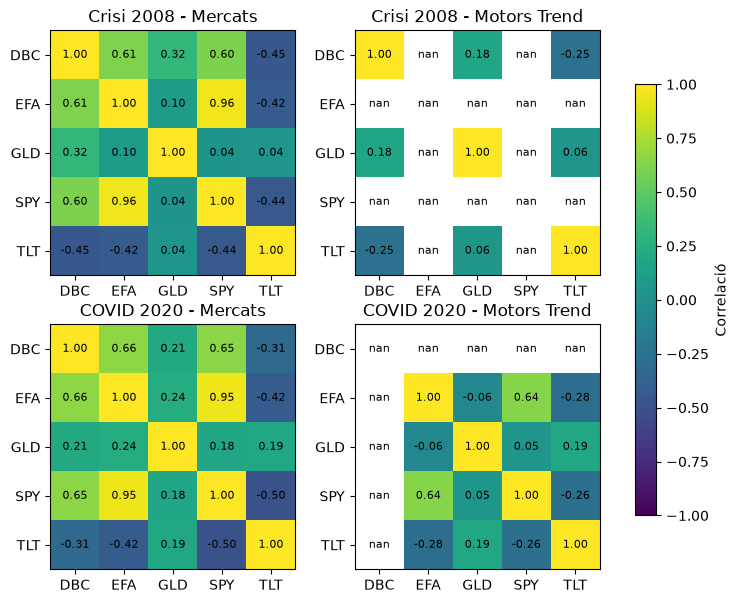

In [15]:
# CORRELACIONS DURANT CRISIS

crisis_periods = {
    "Crisi 2008": ("2008-09-01", "2009-03-31"),
    "COVID 2020": ("2020-02-01", "2020-05-31")
}


def plot_corr_matrix(ax, corr, title):

    labels = corr.columns

    im = ax.imshow(
        corr,
        vmin=-1,
        vmax=1
    )

    ax.set_title(title)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(
                j,
                i,
                f"{corr.iloc[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=8
            )

    return im


fig, axes = plt.subplots(
    2, 2,
    figsize=(9, 7)
)

for row, (name, dates) in enumerate(crisis_periods.items()):

    start, end = dates

    crisis_asset_returns = returns_bt.loc[start:end]
    crisis_trend_returns = trend_net_returns.loc[start:end]

    asset_crisis_corr = crisis_asset_returns.corr()
    trend_crisis_corr = crisis_trend_returns.corr()

    plot_corr_matrix(
        axes[row, 0],
        asset_crisis_corr,
        f"{name} - Mercats"
    )

    im = plot_corr_matrix(
        axes[row, 1],
        trend_crisis_corr,
        f"{name} - Motors Trend"
    )


fig.colorbar(
    im,
    ax=axes,
    shrink=0.8,
    label="Correlació"
)

plt.show()

## 14. Velocitat del Trend Following

Fins ara hem utilitzat un únic horitzó:

$$
252 \text{ dies}
$$

Però una tendència es pot mesurar a diferents velocitats.

Compararem:

- 21 dies: aproximadament 1 mes;
- 63 dies: aproximadament 3 mesos;
- 126 dies: aproximadament 6 mesos;
- 252 dies: aproximadament 12 mesos.

Per cada horitzó:

$$
M_{t,h}
=
\frac{P_t}{P_{t-h}}-1
$$

Un model ràpid reacciona abans als canvis de direcció, però és més sensible al soroll.

Un model lent genera menys canvis de posició, però pot reaccionar tard quan una tendència es trenca.

Per tant existeix un compromís entre:

$$
\text{rapidesa}
\quad\text{i}\quad
\text{whipsaw}
$$

De moment no intentarem trobar el millor horitzó.

Volem entendre com canvia el comportament del senyal.

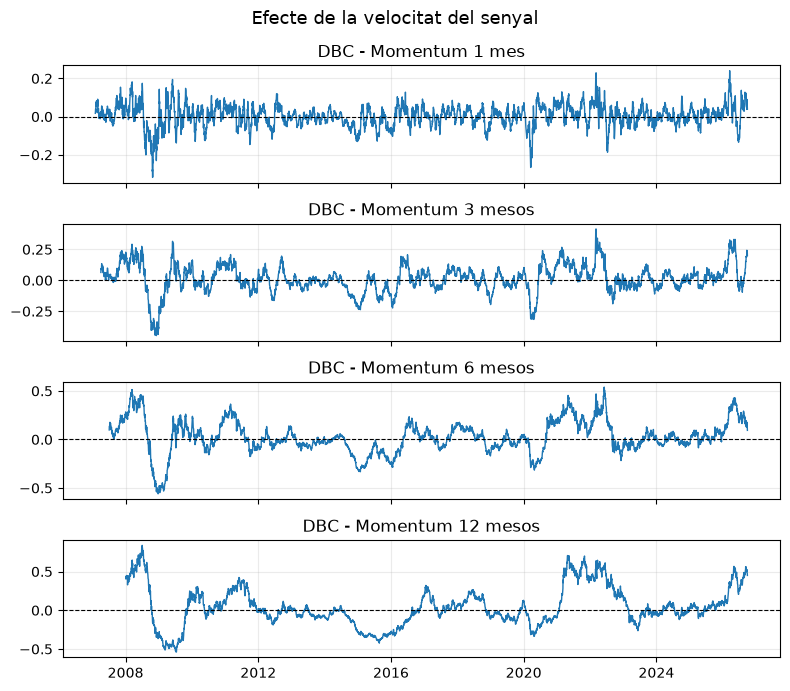

In [16]:
# MOMENTUM A DIFERENTS VELOCITATS

lookbacks = {
    "1 mes": 21,
    "3 mesos": 63,
    "6 mesos": 126,
    "12 mesos": 252
}

ticker_example = "DBC"

fig, axes = plt.subplots(
    4, 1,
    figsize=(8, 7),
    sharex=True
)

for ax, (name, lookback) in zip(axes, lookbacks.items()):

    momentum = (
        prices[ticker_example]
        / prices[ticker_example].shift(lookback)
        - 1
    )

    ax.plot(
        momentum.index,
        momentum,
        linewidth=1
    )

    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.8
    )

    ax.set_title(
        f"{ticker_example} - Momentum {name}"
    )

    ax.grid(alpha=0.25)

fig.suptitle(
    "Efecte de la velocitat del senyal",
    fontsize=13
)

plt.tight_layout()
plt.show()

## 15. Velocitat del senyal: rendiment vs whipsaw

Ara compararem quantitativament diferents velocitats de trend sobre DBC.

Utilitzarem:

- 21 dies;
- 63 dies;
- 126 dies;
- 252 dies.

Per fer una comparació justa, tots els models començaran el mateix dia: quan el model més lent ja disposa d'historial suficient.

Per cada velocitat mesurarem:

- CAGR;
- volatilitat;
- Sharpe;
- max drawdown;
- nombre de canvis de posició;
- canvis anuals;
- exposició.

Mantindrem:

$$
Cost = 10 \text{ bps}
$$

per unitat de turnover.

No busquem encara seleccionar el millor lookback.

Volem entendre el compromís entre:

$$
\text{velocitat}
\leftrightarrow
\text{whipsaw}
\leftrightarrow
\text{rendiment}
$$

In [18]:
# COMPARACIO DE VELOCITATS EN DBC VS BUY AND HOLD

ticker = "DBC"

lookbacks = {
    "1 mes": 21,
    "3 mesos": 63,
    "6 mesos": 126,
    "12 mesos": 252
}

cost_bps = 10
cost_rate = cost_bps / 10000

models = {}

# Construim tots els models
for name, lookback in lookbacks.items():

    momentum = (
        prices[ticker]
        / prices[ticker].shift(lookback)
        - 1
    )

    signal = (momentum > 0).astype(float)
    signal[momentum.isna()] = np.nan

    position = signal.shift(1)

    models[name] = {
        "position": position
    }


# Mateix periode per a tots els models
common_start = max(
    model["position"].first_valid_index()
    for model in models.values()
)

returns_common = (
    daily_returns[ticker]
    .loc[common_start:]
)


# BUY AND HOLD

buyhold_metrics = performance_metrics(
    returns_common
)


# TREND

comparison_results = []

for name, model in models.items():

    position = (
        model["position"]
        .loc[common_start:]
        .fillna(0)
    )

    gross_returns = (
        position * returns_common
    )

    turnover_model = (
        position.diff()
        .abs()
        .fillna(0)
    )

    net_returns = (
        gross_returns
        - turnover_model * cost_rate
    )

    trend_metrics = performance_metrics(
        net_returns,
        position
    )

    years = (
        net_returns.index[-1]
        - net_returns.index[0]
    ).days / 365.25

    switches = turnover_model.sum()

    comparison_results.append({
        "Lookback": name,
        "Days": lookbacks[name],

        "Trend CAGR": trend_metrics["CAGR"],
        "B&H CAGR": buyhold_metrics["CAGR"],
        "CAGR vs B&H": (
            trend_metrics["CAGR"]
            - buyhold_metrics["CAGR"]
        ),

        "Trend Vol": trend_metrics["Volatility"],
        "B&H Vol": buyhold_metrics["Volatility"],

        "Trend Sharpe": trend_metrics["Sharpe"],
        "B&H Sharpe": buyhold_metrics["Sharpe"],

        "Trend MaxDD": trend_metrics["Max Drawdown"],
        "B&H MaxDD": buyhold_metrics["Max Drawdown"],

        "Switches/year": switches / years,
        "Exposure": position.mean()
    })


comparison_df = pd.DataFrame(comparison_results)

comparison_display = comparison_df.copy()


percentage_cols = [
    "Trend CAGR",
    "B&H CAGR",
    "CAGR vs B&H",
    "Trend Vol",
    "B&H Vol",
    "Trend MaxDD",
    "B&H MaxDD",
    "Exposure"
]

for col in percentage_cols:
    comparison_display[col] = (
        comparison_display[col] * 100
    ).map(lambda x: f"{x:.2f}%")


for col in [
    "Trend Sharpe",
    "B&H Sharpe",
    "Switches/year"
]:
    comparison_display[col] = (
        comparison_display[col]
        .map(lambda x: f"{x:.2f}")
    )


print(
    "Periode comu:",
    common_start.date(),
    "->",
    returns_common.index[-1].date()
)

display(comparison_display)

Periode comu: 2008-01-04 -> 2026-09-29


,Lookback,Days,Trend CAGR,B&H CAGR,CAGR vs B&H,Trend Vol,B&H Vol,Trend Sharpe,B&H Sharpe,Trend MaxDD,B&H MaxDD,Switches/year,Exposure
0,1 mes,21,0.95%,0.87%,0.08%,13.01%,19.39%,0.14,0.14,-44.28%,-76.36%,22.63,53.64%
1,3 mesos,63,4.64%,0.87%,3.77%,13.38%,19.39%,0.41,0.14,-34.48%,-76.36%,11.85,54.30%
2,6 mesos,126,3.01%,0.87%,2.14%,13.74%,19.39%,0.29,0.14,-46.56%,-76.36%,9.29,53.43%
3,12 mesos,252,2.18%,0.87%,1.31%,14.02%,19.39%,0.22,0.14,-54.54%,-76.36%,6.73,50.65%


## 16. Velocitats de trend en tots els mercats

Ara repetirem l'anàlisi de velocitats sobre tots els actius.

Compararem:

- 21 dies;
- 63 dies;
- 126 dies;
- 252 dies.

Per cada combinació mesurarem el resultat del Trend Following i el compararem amb Buy & Hold durant exactament el mateix període.

Ens interessa observar si:

$$
CAGR_{Trend} - CAGR_{B\&H} > 0
$$

però també compararem:

- Sharpe;
- max drawdown;
- exposició;
- freqüència de canvis.

Encara no seleccionarem el millor lookback.

L'objectiu és comprovar si existeix una regió de velocitats amb comportament consistent entre mercats diferents.

In [19]:
# VELOCITATS DE TREND EN TOTS ELS MERCATS

lookbacks = {
    "1 mes": 21,
    "3 mesos": 63,
    "6 mesos": 126,
    "12 mesos": 252
}

cost_bps = 10
cost_rate = cost_bps / 10000

# Mateix inici per a tots:
# necessitem historial suficient per al lookback mes llarg
common_start = prices.index[252 + 1]

multi_speed_results = []


for ticker in tickers:

    returns_common = (
        daily_returns[ticker]
        .loc[common_start:]
        .copy()
    )

    # BUY AND HOLD del mateix actiu i periode
    buyhold_metrics = performance_metrics(
        returns_common
    )

    for name, lookback in lookbacks.items():

        momentum = (
            prices[ticker]
            / prices[ticker].shift(lookback)
            - 1
        )

        signal = (momentum > 0).astype(float)
        signal[momentum.isna()] = np.nan

        position = (
            signal.shift(1)
            .loc[common_start:]
            .fillna(0)
        )

        gross_returns = (
            position * returns_common
        )

        turnover_model = (
            position.diff()
            .abs()
            .fillna(0)
        )

        net_returns = (
            gross_returns
            - turnover_model * cost_rate
        )

        trend_metrics = performance_metrics(
            net_returns,
            position
        )

        years = (
            net_returns.index[-1]
            - net_returns.index[0]
        ).days / 365.25

        switches = turnover_model.sum()

        multi_speed_results.append({
            "Ticker": ticker,
            "Lookback": name,

            "Trend CAGR": trend_metrics["CAGR"],
            "B&H CAGR": buyhold_metrics["CAGR"],
            "CAGR vs B&H":
                trend_metrics["CAGR"]
                - buyhold_metrics["CAGR"],

            "Trend Sharpe": trend_metrics["Sharpe"],
            "B&H Sharpe": buyhold_metrics["Sharpe"],

            "Trend MaxDD": trend_metrics["Max Drawdown"],
            "B&H MaxDD": buyhold_metrics["Max Drawdown"],

            "Switches/year": switches / years,
            "Exposure": position.mean()
        })


multi_speed_df = pd.DataFrame(
    multi_speed_results
)


# FORMAT PER MOSTRAR

multi_speed_display = multi_speed_df.copy()

percentage_cols = [
    "Trend CAGR",
    "B&H CAGR",
    "CAGR vs B&H",
    "Trend MaxDD",
    "B&H MaxDD",
    "Exposure"
]

for col in percentage_cols:
    multi_speed_display[col] = (
        multi_speed_display[col] * 100
    ).map(lambda x: f"{x:.2f}%")

for col in [
    "Trend Sharpe",
    "B&H Sharpe",
    "Switches/year"
]:
    multi_speed_display[col] = (
        multi_speed_display[col]
        .map(lambda x: f"{x:.2f}")
    )


print(
    "Periode comu:",
    common_start.date(),
    "->",
    daily_returns.index[-1].date()
)

display(multi_speed_display)

Periode comu: 2008-01-04 -> 2026-09-29


,Ticker,Lookback,Trend CAGR,B&H CAGR,CAGR vs B&H,Trend Sharpe,B&H Sharpe,Trend MaxDD,B&H MaxDD,Switches/year,Exposure
0,SPY,1 mes,4.07%,11.29%,-7.23%,0.42,0.64,-32.82%,-51.48%,21.46,67.13%
1,SPY,3 mesos,6.36%,11.29%,-4.94%,0.60,0.64,-24.75%,-51.48%,10.19,73.69%
2,SPY,6 mesos,7.85%,11.29%,-3.45%,0.70,0.64,-23.95%,-51.48%,6.99,76.19%
3,SPY,12 mesos,7.97%,11.29%,-3.33%,0.62,0.64,-31.58%,-51.48%,3.74,82.05%
4,EFA,1 mes,0.42%,4.61%,-4.19%,0.10,0.32,-45.52%,-58.34%,23.70,59.73%
5,EFA,3 mesos,2.63%,4.61%,-1.98%,0.27,0.32,-27.99%,-58.34%,13.29,64.42%
6,EFA,6 mesos,4.07%,4.61%,-0.54%,0.39,0.32,-28.77%,-58.34%,6.89,64.93%
7,EFA,12 mesos,0.89%,4.61%,-3.72%,0.13,0.32,-31.68%,-58.34%,7.47,64.25%
8,TLT,1 mes,-1.69%,2.07%,-3.76%,-0.10,0.21,-41.99%,-48.35%,25.51,51.24%
9,TLT,3 mesos,1.19%,2.07%,-0.87%,0.16,0.21,-42.83%,-48.35%,15.75,55.23%


## 17. Trend Following LONG / SHORT

Fins ara el model era LONG / FLAT:

$$
M_t>0
\Rightarrow LONG
$$

$$
M_t<0
\Rightarrow FLAT
$$

Això permet reduir exposició durant tendències negatives, però no permet beneficiar-se'n.

Ara provarem una versió LONG / SHORT:

$$
Signal_t =
\begin{cases}
+1 & \text{si } M_t>0 \\
-1 & \text{si } M_t<0
\end{cases}
$$

Per tant:

- trend positiu → LONG;
- trend negatiu → SHORT.

El retorn serà:

$$
R_t^{strategy}
=
Position_tR_t
$$

amb la posició retardada un període per evitar lookahead.

Mantindrem un cost de 10 bps per unitat de turnover.

Aquesta primera versió encara no incorpora:

- costos de borrow;
- finançament;
- remuneració del collateral;
- volatility targeting.

L'objectiu és comprovar si capturar tendències negatives aporta informació econòmica addicional.

In [20]:
# TREND LONG SHORT VS BUY AND HOLD

lookbacks = {
    "1 mes": 21,
    "3 mesos": 63,
    "6 mesos": 126,
    "12 mesos": 252
}

cost_bps = 10
cost_rate = cost_bps / 10000

common_start = prices.index[252 + 1]

long_short_results = []


for ticker in tickers:

    returns_common = (
        daily_returns[ticker]
        .loc[common_start:]
        .copy()
    )

    # BUY AND HOLD

    buyhold_metrics = performance_metrics(
        returns_common
    )


    for name, lookback in lookbacks.items():

        # MOMENTUM

        momentum = (
            prices[ticker]
            / prices[ticker].shift(lookback)
            - 1
        )

        # +1 LONG
        # -1 SHORT

        signal = pd.Series(
            np.where(
                momentum > 0,
                1.0,
                -1.0
            ),
            index=momentum.index
        )

        signal[momentum.isna()] = np.nan

        # Evitem lookahead

        position = (
            signal.shift(1)
            .loc[common_start:]
            .fillna(0)
        )

        # Retorn brut

        gross_returns = (
            position * returns_common
        )

        # Turnover
        #
        # +1 -> -1 = turnover 2
        # -1 -> +1 = turnover 2

        turnover_model = (
            position.diff()
            .abs()
            .fillna(0)
        )

        # Retorn net

        net_returns = (
            gross_returns
            - turnover_model * cost_rate
        )

        trend_metrics = performance_metrics(
            net_returns
        )

        years = (
            net_returns.index[-1]
            - net_returns.index[0]
        ).days / 365.25

        long_short_results.append({
            "Ticker": ticker,
            "Lookback": name,

            "LS CAGR": trend_metrics["CAGR"],
            "B&H CAGR": buyhold_metrics["CAGR"],
            "CAGR vs B&H":
                trend_metrics["CAGR"]
                - buyhold_metrics["CAGR"],

            "LS Vol": trend_metrics["Volatility"],
            "B&H Vol": buyhold_metrics["Volatility"],

            "LS Sharpe": trend_metrics["Sharpe"],
            "B&H Sharpe": buyhold_metrics["Sharpe"],

            "LS MaxDD": trend_metrics["Max Drawdown"],
            "B&H MaxDD": buyhold_metrics["Max Drawdown"],

            "Switches/year":
                (turnover_model > 0).sum() / years,

            "Short time":
                (position < 0).mean()
        })


long_short_df = pd.DataFrame(
    long_short_results
)


# FORMAT

long_short_display = long_short_df.copy()

percentage_cols = [
    "LS CAGR",
    "B&H CAGR",
    "CAGR vs B&H",
    "LS Vol",
    "B&H Vol",
    "LS MaxDD",
    "B&H MaxDD",
    "Short time"
]

for col in percentage_cols:
    long_short_display[col] = (
        long_short_display[col] * 100
    ).map(lambda x: f"{x:.2f}%")


for col in [
    "LS Sharpe",
    "B&H Sharpe",
    "Switches/year"
]:
    long_short_display[col] = (
        long_short_display[col]
        .map(lambda x: f"{x:.2f}")
    )


print(
    "Periode comu:",
    common_start.date(),
    "->",
    daily_returns.index[-1].date()
)

display(long_short_display)

Periode comu: 2008-01-04 -> 2026-09-29


,Ticker,Lookback,LS CAGR,B&H CAGR,CAGR vs B&H,LS Vol,B&H Vol,LS Sharpe,B&H Sharpe,LS MaxDD,B&H MaxDD,Switches/year,Short time
0,SPY,1 mes,-5.26%,11.29%,-16.56%,19.77%,19.73%,-0.17,0.64,-76.31%,-51.48%,21.46,32.87%
1,SPY,3 mesos,-0.98%,11.29%,-12.27%,19.76%,19.73%,0.05,0.64,-64.01%,-51.48%,10.19,26.31%
2,SPY,6 mesos,1.91%,11.29%,-9.38%,19.76%,19.73%,0.20,0.64,-47.38%,-51.48%,6.99,23.81%
3,SPY,12 mesos,2.69%,11.29%,-8.61%,19.76%,19.73%,0.23,0.64,-49.46%,-51.48%,3.74,17.95%
4,EFA,1 mes,-6.64%,4.61%,-11.25%,21.78%,21.75%,-0.21,0.32,-84.57%,-58.34%,23.70,40.27%
5,EFA,3 mesos,-2.49%,4.61%,-7.10%,21.76%,21.75%,-0.01,0.32,-64.52%,-58.34%,13.29,35.58%
6,EFA,6 mesos,0.20%,4.61%,-4.41%,21.75%,21.75%,0.12,0.32,-68.44%,-58.34%,6.89,35.07%
7,EFA,12 mesos,-5.67%,4.61%,-10.28%,21.75%,21.75%,-0.16,0.32,-83.19%,-58.34%,7.47,35.75%
8,TLT,1 mes,-6.33%,2.07%,-8.39%,15.29%,15.25%,-0.35,0.21,-74.28%,-48.35%,25.51,48.76%
9,TLT,3 mesos,-0.65%,2.07%,-2.72%,15.27%,15.25%,0.03,0.21,-52.72%,-48.35%,15.75,44.77%


## 18. Trend multi-speed i volatility targeting

En lloc de seleccionar un únic lookback, combinarem diverses velocitats:

$$
21,\ 63,\ 126,\ 252
$$

Cada velocitat genera un senyal LONG / FLAT.

El senyal agregat és:

$$
Signal_t
=
\frac{
S_{21,t}
+
S_{63,t}
+
S_{126,t}
+
S_{252,t}
}{4}
$$

Això produeix una exposició entre 0 i 1.

Per exemple:

- `0.00`: cap velocitat detecta trend positiu;
- `0.25`: una velocitat positiva;
- `0.50`: dues;
- `0.75`: tres;
- `1.00`: totes quatre.

A continuació ajustarem l'exposició segons la volatilitat estimada:

$$
VolScaler_t
=
\min
\left(
1,
\frac{\sigma_{target}}
{\hat{\sigma}_t}
\right)
$$

amb:

$$
\sigma_{target}=10\%
$$

La posició final serà:

$$
Position_t
=
Signal_t
\times
VolScaler_t
$$

De moment no permetrem leverage.

Mantindrem un cost de 10 bps per unitat de turnover i compararem sempre els resultats amb Buy & Hold.

Periode: 2008-01-04 -> 2026-09-29


,Ticker,Trend CAGR,B&H CAGR,CAGR vs B&H,Trend Sharpe,B&H Sharpe,Trend MaxDD,B&H MaxDD,Avg Position
0,SPY,4.76%,11.29%,-6.53%,0.65,0.64,-13.29%,-51.48%,57.09%
1,EFA,1.14%,4.61%,-3.47%,0.20,0.32,-17.87%,-58.34%,44.08%
2,TLT,0.67%,2.07%,-1.39%,0.13,0.21,-30.17%,-48.35%,41.54%
3,GLD,3.94%,8.33%,-4.38%,0.54,0.53,-27.68%,-45.56%,40.68%
4,DBC,1.00%,0.87%,0.13%,0.18,0.14,-25.49%,-76.36%,32.67%


,Portfolio,Total Return,CAGR,Volatility,Sharpe,Max Drawdown,Exposure
0,Trend,61.00%,2.57%,4.10%,0.64,-8.14%,1.0
1,Buy & Hold,241.38%,6.77%,10.87%,0.66,-31.14%,1.0


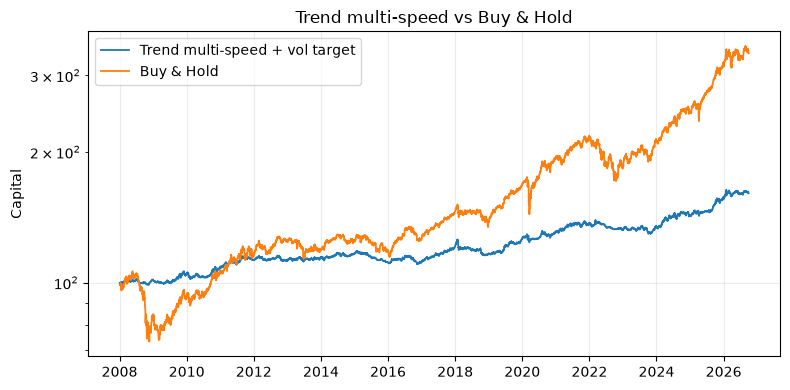

In [21]:
# TREND MULTI-SPEED AMB VOLATILITY TARGETING

lookbacks = [21, 63, 126, 252]

vol_window = 63
target_vol = 0.10

cost_bps = 10
cost_rate = cost_bps / 10000


# SENYALS DE CADA VELOCITAT

speed_signals = []

for lookback in lookbacks:

    momentum = (
        prices
        / prices.shift(lookback)
        - 1
    )

    signal = (momentum > 0).astype(float)

    signal[momentum.isna()] = np.nan

    speed_signals.append(signal)


# SENYAL MULTI-SPEED

multi_signal = (
    speed_signals[0]
    + speed_signals[1]
    + speed_signals[2]
    + speed_signals[3]
) / len(speed_signals)


# Retardem un dia per evitar lookahead

multi_signal_lagged = multi_signal.shift(1)


# VOLATILITAT EX-ANTE

estimated_vol = (
    daily_returns
    .rolling(vol_window)
    .std()
    * np.sqrt(252)
)

# La volatilitat utilitzada avui
# ha de ser coneguda abans del retorn d'avui

estimated_vol_lagged = estimated_vol.shift(1)


# VOLATILITY SCALER

vol_scaler = (
    target_vol
    / estimated_vol_lagged
).clip(
    lower=0,
    upper=1
)


# POSICIO FINAL

final_position = (
    multi_signal_lagged
    * vol_scaler
)


# PERIODE COMU VALID

valid_days = (
    final_position.notna().all(axis=1)
    & daily_returns.notna().all(axis=1)
)

common_start = final_position.index[
    valid_days
][0]


position_bt_multi = (
    final_position
    .loc[common_start:]
    .copy()
)

returns_multi = (
    daily_returns
    .loc[common_start:]
    .copy()
)


# TURNOVER

turnover_multi = (
    position_bt_multi
    .diff()
    .abs()
    .fillna(0)
)


# RETORNS NETS

trend_multi_returns = (
    position_bt_multi
    * returns_multi
    - turnover_multi * cost_rate
)


# RESULTATS PER ACTIU

asset_results = []

for ticker in tickers:

    trend_metrics = performance_metrics(
        trend_multi_returns[ticker],
        position_bt_multi[ticker]
    )

    buyhold_metrics = performance_metrics(
        returns_multi[ticker]
    )

    asset_results.append({
        "Ticker": ticker,

        "Trend CAGR":
            trend_metrics["CAGR"],

        "B&H CAGR":
            buyhold_metrics["CAGR"],

        "CAGR vs B&H":
            trend_metrics["CAGR"]
            - buyhold_metrics["CAGR"],

        "Trend Sharpe":
            trend_metrics["Sharpe"],

        "B&H Sharpe":
            buyhold_metrics["Sharpe"],

        "Trend MaxDD":
            trend_metrics["Max Drawdown"],

        "B&H MaxDD":
            buyhold_metrics["Max Drawdown"],

        "Avg Position":
            position_bt_multi[ticker].mean()
    })


asset_results_df = pd.DataFrame(
    asset_results
)


# FORMAT

asset_display = asset_results_df.copy()

for col in [
    "Trend CAGR",
    "B&H CAGR",
    "CAGR vs B&H",
    "Trend MaxDD",
    "B&H MaxDD",
    "Avg Position"
]:
    asset_display[col] = (
        asset_display[col] * 100
    ).map(
        lambda x: f"{x:.2f}%"
    )

for col in [
    "Trend Sharpe",
    "B&H Sharpe"
]:
    asset_display[col] = (
        asset_display[col]
        .map(lambda x: f"{x:.2f}")
    )


print(
    "Periode:",
    common_start.date(),
    "->",
    returns_multi.index[-1].date()
)

display(asset_display)


# CARTERA MULTI-ACTIU

initial_capital = 100
capital_per_asset = (
    initial_capital
    / len(tickers)
)


trend_sleeves = (
    1
    + trend_multi_returns.fillna(0)
).cumprod() * capital_per_asset


buyhold_sleeves = (
    1
    + returns_multi.fillna(0)
).cumprod() * capital_per_asset


trend_portfolio = (
    trend_sleeves.sum(axis=1)
)

buyhold_portfolio = (
    buyhold_sleeves.sum(axis=1)
)


trend_portfolio_returns = (
    trend_portfolio
    .pct_change()
    .fillna(0)
)

buyhold_portfolio_returns = (
    buyhold_portfolio
    .pct_change()
    .fillna(0)
)


trend_portfolio_metrics = (
    performance_metrics(
        trend_portfolio_returns
    )
)

buyhold_portfolio_metrics = (
    performance_metrics(
        buyhold_portfolio_returns
    )
)


portfolio_results = pd.DataFrame([
    {
        "Portfolio": "Trend",
        **trend_portfolio_metrics
    },
    {
        "Portfolio": "Buy & Hold",
        **buyhold_portfolio_metrics
    }
])


portfolio_display = (
    portfolio_results.copy()
)

for col in [
    "Total Return",
    "CAGR",
    "Volatility",
    "Max Drawdown"
]:
    portfolio_display[col] = (
        portfolio_display[col] * 100
    ).map(
        lambda x: f"{x:.2f}%"
    )

portfolio_display["Sharpe"] = (
    portfolio_display["Sharpe"]
    .map(lambda x: f"{x:.2f}")
)

display(portfolio_display)


# EQUITY CURVES

plt.figure(figsize=(8, 4))

plt.plot(
    trend_portfolio,
    label="Trend multi-speed + vol target",
    linewidth=1.3
)

plt.plot(
    buyhold_portfolio,
    label="Buy & Hold",
    linewidth=1.3
)

plt.title(
    "Trend multi-speed vs Buy & Hold"
)

plt.ylabel("Capital")
plt.yscale("log")

plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

## 19. Estabilitat temporal del model

Ja hem utilitzat tota la mostra 2008–2026 durant el desenvolupament.

Per tant, no podem considerar retrospectivament cap part d'aquest període com un test completament verge.

En lloc d'optimitzar més, congelarem el model actual i estudiarem la seva estabilitat temporal.

Dividirem la història en quatre blocs:

- 2008–2012;
- 2013–2017;
- 2018–2022;
- 2023–2026.

En cada període reiniciarem les dues carteres amb capital 100 i compararem:

$$
\text{Trend}
\quad vs \quad
\text{Buy \& Hold}
$$

No busquem seleccionar el millor període.

Volem comprovar si el comportament del model és estable o depèn fortament del règim de mercat.

In [22]:
# ESTABILITAT TEMPORAL DEL MODEL

periods = {
    "2008-2012": ("2008-01-04", "2012-12-31"),
    "2013-2017": ("2013-01-01", "2017-12-31"),
    "2018-2022": ("2018-01-01", "2022-12-31"),
    "2023-2026": ("2023-01-01", "2026-09-29")
}


def build_portfolio(asset_returns, initial_capital=100):

    capital_per_asset = (
        initial_capital
        / asset_returns.shape[1]
    )

    sleeves = (
        1 + asset_returns.fillna(0)
    ).cumprod() * capital_per_asset

    portfolio = sleeves.sum(axis=1)

    portfolio_returns = (
        portfolio
        .pct_change()
        .fillna(0)
    )

    return portfolio, portfolio_returns


period_results = []


for period_name, (start, end) in periods.items():

    # Retorns del periode

    trend_period_assets = (
        trend_multi_returns
        .loc[start:end]
        .copy()
    )

    buyhold_period_assets = (
        returns_multi
        .loc[start:end]
        .copy()
    )

    position_period = (
        position_bt_multi
        .loc[start:end]
        .copy()
    )


    # Reconstruim les carteres des de 100

    trend_portfolio_period, trend_returns_period = (
        build_portfolio(
            trend_period_assets
        )
    )

    buyhold_portfolio_period, buyhold_returns_period = (
        build_portfolio(
            buyhold_period_assets
        )
    )


    # Metriques

    trend_metrics = performance_metrics(
        trend_returns_period
    )

    buyhold_metrics = performance_metrics(
        buyhold_returns_period
    )


    # Exposicio mitjana real aproximada
    # amb pesos iguals entre els 5 motors

    avg_exposure = (
        position_period
        .mean(axis=1)
        .mean()
    )


    period_results.append({
        "Period": period_name,

        "Trend CAGR":
            trend_metrics["CAGR"],

        "B&H CAGR":
            buyhold_metrics["CAGR"],

        "CAGR vs B&H":
            trend_metrics["CAGR"]
            - buyhold_metrics["CAGR"],

        "Trend Vol":
            trend_metrics["Volatility"],

        "B&H Vol":
            buyhold_metrics["Volatility"],

        "Trend Sharpe":
            trend_metrics["Sharpe"],

        "B&H Sharpe":
            buyhold_metrics["Sharpe"],

        "Trend MaxDD":
            trend_metrics["Max Drawdown"],

        "B&H MaxDD":
            buyhold_metrics["Max Drawdown"],

        "Avg Exposure":
            avg_exposure
    })


period_results_df = pd.DataFrame(
    period_results
)


# FORMAT

period_display = period_results_df.copy()

for col in [
    "Trend CAGR",
    "B&H CAGR",
    "CAGR vs B&H",
    "Trend Vol",
    "B&H Vol",
    "Trend MaxDD",
    "B&H MaxDD",
    "Avg Exposure"
]:
    period_display[col] = (
        period_display[col] * 100
    ).map(
        lambda x: f"{x:.2f}%"
    )


for col in [
    "Trend Sharpe",
    "B&H Sharpe"
]:
    period_display[col] = (
        period_display[col]
        .map(lambda x: f"{x:.2f}")
    )


display(period_display)

,Period,Trend CAGR,B&H CAGR,CAGR vs B&H,Trend Vol,B&H Vol,Trend Sharpe,B&H Sharpe,Trend MaxDD,B&H MaxDD,Avg Exposure
0,2008-2012,2.44%,4.80%,-2.36%,4.14%,13.13%,0.60,0.42,-3.95%,-31.14%,34.78%
1,2013-2017,1.57%,3.77%,-2.19%,3.32%,7.43%,0.49,0.53,-6.66%,-14.89%,47.50%
2,2018-2022,1.81%,5.05%,-3.24%,4.12%,10.93%,0.45,0.51,-8.10%,-18.75%,42.76%
3,2023-2026,5.16%,15.31%,-10.15%,5.01%,10.80%,1.03,1.38,-4.05%,-8.41%,49.36%


## 20. Comparació a igual risc

La cartera Trend actual assumeix molta menys volatilitat que Buy & Hold.

Per tant, comparar només CAGR pot ser enganyós.

Aplicarem volatility targeting a nivell de cartera:

$$
L_t
=
\frac{\sigma_{target}}
{\hat{\sigma}_t}
$$

amb:

$$
\sigma_{target}=10\%
$$

La volatilitat s'estimarà utilitzant només informació passada.

Limitarem el leverage màxim a:

$$
L_{max}=3
$$

Això no crea alpha.

Simplement permet comparar les dues estratègies amb nivells de risc més semblants.

,Portfolio,Total Return,CAGR,Volatility,Sharpe,Max Drawdown,Exposure,Avg Leverage
0,Trend,178.71%,5.70%,9.71%,0.62,-19.02%,1.0,2.57x
1,Buy & Hold,211.12%,6.34%,10.63%,0.63,-28.21%,1.0,1.15x


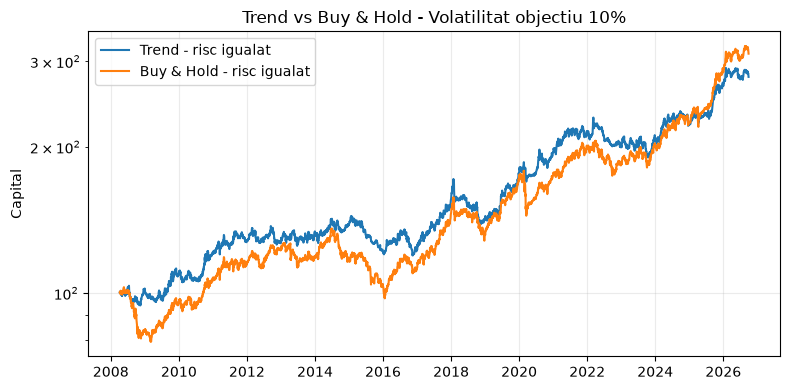

In [23]:
# COMPARACIO A IGUAL RISC

target_portfolio_vol = 0.10
vol_window_portfolio = 63
max_leverage = 3.0


# RETORNS BASE DE LES DUES CARTERES

trend_base = (
    trend_multi_returns
    .mean(axis=1)
)

buyhold_base = (
    returns_multi
    .mean(axis=1)
)


def apply_vol_target(
    returns,
    target_vol=0.10,
    vol_window=63,
    max_leverage=3.0
):

    estimated_vol = (
        returns
        .rolling(vol_window)
        .std()
        * np.sqrt(252)
    )

    # Retardem l'estimacio per evitar lookahead
    estimated_vol = estimated_vol.shift(1)

    leverage = (
        target_vol
        / estimated_vol
    ).clip(
        lower=0,
        upper=max_leverage
    )

    targeted_returns = (
        leverage * returns
    )

    return targeted_returns, leverage


trend_risk_matched, trend_leverage = (
    apply_vol_target(
        trend_base,
        target_portfolio_vol,
        vol_window_portfolio,
        max_leverage
    )
)

buyhold_risk_matched, buyhold_leverage = (
    apply_vol_target(
        buyhold_base,
        target_portfolio_vol,
        vol_window_portfolio,
        max_leverage
    )
)


# Mateix periode valid

valid = (
    trend_risk_matched.notna()
    & buyhold_risk_matched.notna()
)

trend_rm = trend_risk_matched.loc[valid]
buyhold_rm = buyhold_risk_matched.loc[valid]


# METRIQUES

trend_metrics = performance_metrics(
    trend_rm
)

buyhold_metrics = performance_metrics(
    buyhold_rm
)


risk_matched_results = pd.DataFrame([
    {
        "Portfolio": "Trend",
        **trend_metrics,
        "Avg Leverage":
            trend_leverage.loc[valid].mean()
    },
    {
        "Portfolio": "Buy & Hold",
        **buyhold_metrics,
        "Avg Leverage":
            buyhold_leverage.loc[valid].mean()
    }
])


risk_display = risk_matched_results.copy()

for col in [
    "Total Return",
    "CAGR",
    "Volatility",
    "Max Drawdown"
]:
    risk_display[col] = (
        risk_display[col] * 100
    ).map(lambda x: f"{x:.2f}%")

risk_display["Sharpe"] = (
    risk_display["Sharpe"]
    .map(lambda x: f"{x:.2f}")
)

risk_display["Avg Leverage"] = (
    risk_display["Avg Leverage"]
    .map(lambda x: f"{x:.2f}x")
)

display(risk_display)


# EQUITY CURVES

trend_equity_rm = (
    1 + trend_rm
).cumprod() * 100

buyhold_equity_rm = (
    1 + buyhold_rm
).cumprod() * 100


plt.figure(figsize=(8, 4))

plt.plot(
    trend_equity_rm,
    label="Trend - risc igualat"
)

plt.plot(
    buyhold_equity_rm,
    label="Buy & Hold - risc igualat"
)

plt.title(
    "Trend vs Buy & Hold - Volatilitat objectiu 10%"
)

plt.ylabel("Capital")
plt.yscale("log")

plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

# Cross-Sectional Momentum amb Dades Reals

## 1. Objectiu

En time-series momentum comparem cada actiu amb el seu propi passat.

En cross-sectional momentum comparem els actius entre ells.

La pregunta és:

$$
\text{quins actius han tingut millor comportament recent?}
$$

Construirem un primer model simple:

1. calcular momentum de 6 mesos;
2. ordenar els actius de millor a pitjor;
3. comprar els 3 primers;
4. rebalancejar mensualment;
5. mantenir pesos iguals entre els seleccionats.

Compararem sempre el resultat amb Buy & Hold sobre el mateix univers.

L'objectiu inicial no és optimitzar paràmetres, sinó entendre el mecanisme.

Periode: 2007-08-31 -> 2026-09-30


,Strategy,Total Return,CAGR,Volatility,Sharpe,Max Drawdown
0,Cross-Sectional Momentum,474.95%,9.56%,13.08%,0.77,-26.45%
1,Buy & Hold,260.36%,6.92%,12.45%,0.60,-36.34%


,Momentum 6m,Rank,Selected
Ticker,,,
EEM,0.192998,1.0,True
SPY,0.181030,2.0,True
IWM,0.130661,3.0,True
DBC,0.105354,4.0,False
EFA,0.093321,5.0,False
VNQ,0.038557,6.0,False
TLT,-0.076473,7.0,False
GLD,-0.110158,8.0,False


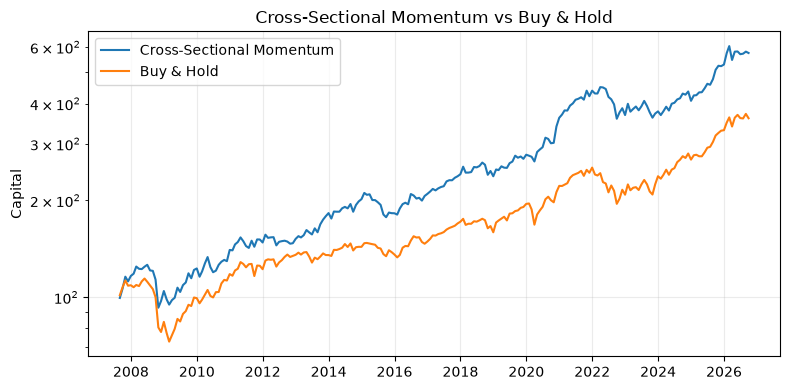

In [24]:
# CROSS-SECTIONAL MOMENTUM - BASELINE

cs_tickers = [
    "SPY",  # Accions EUA
    "EFA",  # Accions desenvolupades fora EUA
    "EEM",  # Emergents
    "IWM",  # Small caps EUA
    "VNQ",  # REITs
    "TLT",  # Bons llargs EUA
    "GLD",  # Or
    "DBC"   # Commodities
]


# DESCARREGA

cs_data = yf.download(
    cs_tickers,
    start="2007-01-01",
    end="2026-09-30",
    auto_adjust=True,
    progress=False
)

cs_prices = (
    cs_data["Close"]
    .dropna()
    .copy()
)


# PASSEM A FREQUENCIA MENSUAL

monthly_prices = (
    cs_prices
    .resample("ME")
    .last()
)

monthly_returns = (
    monthly_prices
    .pct_change()
)


# PARAMETRES BASELINE

lookback_months = 6
top_n = 3

cost_bps = 10
cost_rate = cost_bps / 10000


# MOMENTUM DE 6 MESOS

momentum = (
    monthly_prices
    / monthly_prices.shift(lookback_months)
    - 1
)


# RANKING
# 1 = millor actiu

ranks = momentum.rank(
    axis=1,
    ascending=False,
    method="first"
)


# COMPREM ELS TOP 3

weights_signal = (
    ranks <= top_n
).astype(float)

weights_signal = weights_signal.div(
    weights_signal.sum(axis=1),
    axis=0
)


# El ranking del mes t s'utilitza
# durant el mes següent

weights = weights_signal.shift(1)


# PERIODE VALID

valid = (
    weights.notna().all(axis=1)
    & monthly_returns.notna().all(axis=1)
)

start = weights.index[valid][0]

weights_bt = weights.loc[start:]
returns_bt_cs = monthly_returns.loc[start:]


# RETORN DE L'ESTRATEGIA

gross_returns_cs = (
    weights_bt
    * returns_bt_cs
).sum(axis=1)


# TURNOVER

turnover_cs = (
    weights_bt
    .diff()
    .abs()
    .sum(axis=1)
    .fillna(0)
)


# COSTOS

strategy_returns_cs = (
    gross_returns_cs
    - turnover_cs * cost_rate
)


# BUY AND HOLD
# Mateix capital inicial repartit entre els 8 actius
# sense rebalancejar

buyhold_growth = (
    1 + returns_bt_cs
).cumprod()

buyhold_equity = (
    buyhold_growth.mean(axis=1)
)

buyhold_returns_cs = (
    buyhold_equity.pct_change()
)

buyhold_returns_cs.iloc[0] = (
    buyhold_equity.iloc[0] - 1
)


# FUNCIO DE METRIQUES MENSUALS

def performance_metrics_monthly(returns):

    returns = returns.dropna()

    equity = (
        1 + returns
    ).cumprod()

    years = len(returns) / 12

    total_return = (
        equity.iloc[-1] - 1
    )

    cagr = (
        equity.iloc[-1] ** (1 / years)
        - 1
    )

    volatility = (
        returns.std()
        * np.sqrt(12)
    )

    if returns.std() > 0:
        sharpe = (
            returns.mean()
            / returns.std()
            * np.sqrt(12)
        )
    else:
        sharpe = np.nan

    drawdown = (
        equity
        / equity.cummax()
        - 1
    )

    max_drawdown = drawdown.min()

    return {
        "Total Return": total_return,
        "CAGR": cagr,
        "Volatility": volatility,
        "Sharpe": sharpe,
        "Max Drawdown": max_drawdown
    }


# RESULTATS

strategy_metrics = (
    performance_metrics_monthly(
        strategy_returns_cs
    )
)

buyhold_metrics = (
    performance_metrics_monthly(
        buyhold_returns_cs
    )
)


results_cs = pd.DataFrame([
    {
        "Strategy": "Cross-Sectional Momentum",
        **strategy_metrics
    },
    {
        "Strategy": "Buy & Hold",
        **buyhold_metrics
    }
])


display_results = results_cs.copy()

for col in [
    "Total Return",
    "CAGR",
    "Volatility",
    "Max Drawdown"
]:
    display_results[col] = (
        display_results[col] * 100
    ).map(lambda x: f"{x:.2f}%")

display_results["Sharpe"] = (
    display_results["Sharpe"]
    .map(lambda x: f"{x:.2f}")
)

print(
    "Periode:",
    start.date(),
    "->",
    returns_bt_cs.index[-1].date()
)

display(display_results)


# ULTIM RANKING

latest_ranking = pd.DataFrame({
    "Momentum 6m": momentum.iloc[-1],
    "Rank": ranks.iloc[-1],
    "Selected": ranks.iloc[-1] <= top_n
}).sort_values("Rank")

display(latest_ranking)


# EQUITY CURVES

strategy_equity_cs = (
    1 + strategy_returns_cs
).cumprod() * 100

buyhold_equity_plot = (
    1 + buyhold_returns_cs
).cumprod() * 100


plt.figure(figsize=(8, 4))

plt.plot(
    strategy_equity_cs,
    label="Cross-Sectional Momentum"
)

plt.plot(
    buyhold_equity_plot,
    label="Buy & Hold"
)

plt.title(
    "Cross-Sectional Momentum vs Buy & Hold"
)

plt.ylabel("Capital")
plt.yscale("log")

plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

## 2. Cross-sectional momentum amb filtre de règim

Ampliarem el model utilitzant la direcció general de l'univers.

Si la majoria dels actius tenen momentum positiu:

$$
N_{positius} > \frac{N}{2}
$$

comprarem els 3 actius amb millor momentum.

Si la majoria tenen momentum negatiu:

$$
N_{negatius} > \frac{N}{2}
$$

vendrem en curt els 3 actius amb pitjor momentum.

Si no existeix majoria:

$$
N_{positius}=N_{negatius}
$$

la cartera quedarà en cash.

Per tant:

$$
\text{règim positiu}
\rightarrow
\text{LONG winners}
$$

$$
\text{règim negatiu}
\rightarrow
\text{SHORT losers}
$$

$$
\text{règim neutral}
\rightarrow
\text{FLAT}
$$

La decisió calculada al final del mes $t$ s'utilitzarà durant el mes següent per evitar lookahead.

Mantindrem:

- momentum de 6 mesos;
- 3 actius seleccionats;
- rebalanceig mensual;
- 10 bps per unitat de turnover.

Aquesta primera versió encara no incorpora costos específics de venda en curt.

Periode: 2007-02-28 -> 2026-09-30


,Strategy,Total Return,CAGR,Volatility,Sharpe,Max Drawdown
0,Momentum Regime L/S,94.10%,3.43%,14.71%,0.30,-30.06%
1,Buy & Hold,262.62%,6.77%,12.24%,0.60,-36.26%



Distribucio dels regims:


LONG     60.59
SHORT    23.31
FLAT     16.10
Name: Percentatge, dtype: float64

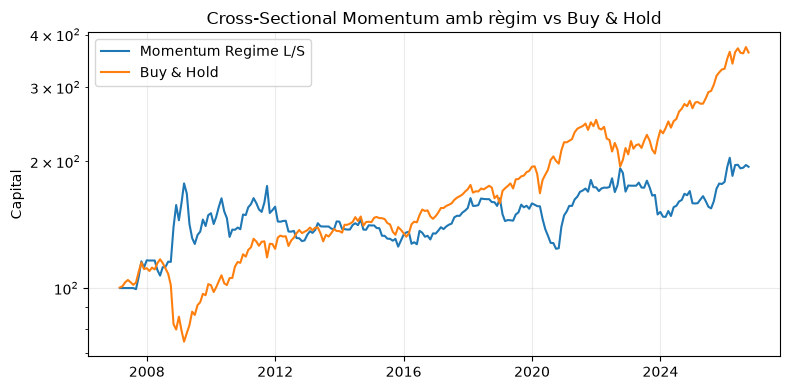

In [25]:
# CROSS-SECTIONAL MOMENTUM AMB REGIM LONG SHORT

lookback_months = 6
top_n = 3

cost_bps = 10
cost_rate = cost_bps / 10000


# MOMENTUM

momentum_regime = (
    monthly_prices
    / monthly_prices.shift(lookback_months)
    - 1
)


# RANKING

ranks_desc = momentum_regime.rank(
    axis=1,
    ascending=False,
    method="first"
)

ranks_asc = momentum_regime.rank(
    axis=1,
    ascending=True,
    method="first"
)


# NOMBRE D'ACTIUS POSITIUS I NEGATIUS

n_positive = (
    momentum_regime > 0
).sum(axis=1)

n_negative = (
    momentum_regime < 0
).sum(axis=1)

n_assets = momentum_regime.shape[1]


# PESOS DEL SENYAL

weights_regime_signal = pd.DataFrame(
    0.0,
    index=momentum_regime.index,
    columns=momentum_regime.columns
)


for date in momentum_regime.index:

    # REGIM POSITIU:
    # LONG als 3 millors

    if n_positive.loc[date] > n_assets / 2:

        selected = (
            ranks_desc.loc[date] <= top_n
        )

        weights_regime_signal.loc[
            date,
            selected
        ] = 1 / top_n


    # REGIM NEGATIU:
    # SHORT als 3 pitjors

    elif n_negative.loc[date] > n_assets / 2:

        selected = (
            ranks_asc.loc[date] <= top_n
        )

        weights_regime_signal.loc[
            date,
            selected
        ] = -1 / top_n


    # REGIM NEUTRAL:
    # FLAT
    else:

        weights_regime_signal.loc[
            date
        ] = 0.0


# RETARD D'UN MES

weights_regime = (
    weights_regime_signal.shift(1)
)


# PERIODE VALID

valid_regime = (
    weights_regime.notna().all(axis=1)
    & monthly_returns.notna().all(axis=1)
)

start_regime = (
    weights_regime.index[
        valid_regime
    ][0]
)

weights_regime_bt = (
    weights_regime.loc[start_regime:]
)

returns_regime_bt = (
    monthly_returns.loc[start_regime:]
)


# RETORN BRUT

gross_returns_regime = (
    weights_regime_bt
    * returns_regime_bt
).sum(axis=1)


# TURNOVER

turnover_regime = (
    weights_regime_bt
    .diff()
    .abs()
    .sum(axis=1)
    .fillna(0)
)


# RETORN NET

strategy_returns_regime = (
    gross_returns_regime
    - turnover_regime * cost_rate
)


# BUY AND HOLD DEL MATEIX UNIVERS

buyhold_growth_regime = (
    1 + returns_regime_bt
).cumprod()

buyhold_equity_regime = (
    buyhold_growth_regime.mean(axis=1)
)

buyhold_returns_regime = (
    buyhold_equity_regime
    .pct_change()
)

buyhold_returns_regime.iloc[0] = (
    buyhold_equity_regime.iloc[0] - 1
)


# METRIQUES

regime_metrics = (
    performance_metrics_monthly(
        strategy_returns_regime
    )
)

buyhold_metrics_regime = (
    performance_metrics_monthly(
        buyhold_returns_regime
    )
)


results_regime = pd.DataFrame([
    {
        "Strategy": "Momentum Regime L/S",
        **regime_metrics
    },
    {
        "Strategy": "Buy & Hold",
        **buyhold_metrics_regime
    }
])


display_regime = (
    results_regime.copy()
)

for col in [
    "Total Return",
    "CAGR",
    "Volatility",
    "Max Drawdown"
]:
    display_regime[col] = (
        display_regime[col] * 100
    ).map(
        lambda x: f"{x:.2f}%"
    )

display_regime["Sharpe"] = (
    display_regime["Sharpe"]
    .map(lambda x: f"{x:.2f}")
)


print(
    "Periode:",
    start_regime.date(),
    "->",
    returns_regime_bt.index[-1].date()
)

display(display_regime)


# ESTADISTIQUES DELS REGIMS

regime_state = pd.Series(
    "FLAT",
    index=momentum_regime.index
)

regime_state[
    n_positive > n_assets / 2
] = "LONG"

regime_state[
    n_negative > n_assets / 2
] = "SHORT"


print("\nDistribucio dels regims:")

display(
    regime_state
    .loc[start_regime:]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("Percentatge")
)


# EQUITY CURVES

equity_regime = (
    1 + strategy_returns_regime
).cumprod() * 100

equity_buyhold_regime = (
    1 + buyhold_returns_regime
).cumprod() * 100


plt.figure(figsize=(8, 4))

plt.plot(
    equity_regime,
    label="Momentum Regime L/S"
)

plt.plot(
    equity_buyhold_regime,
    label="Buy & Hold"
)

plt.title(
    "Cross-Sectional Momentum amb règim vs Buy & Hold"
)

plt.ylabel("Capital")
plt.yscale("log")

plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

## 3. Cross-sectional momentum amb filtre de breadth

El model original sempre mantenia els 3 actius amb millor momentum, encara que tot l'univers estigués caient.

Ara utilitzarem la proporció d'actius amb momentum positiu com a filtre.

Si més de la meitat dels actius tenen momentum positiu:

$$
N_{positius} > \frac{N}{2}
$$

invertirem a parts iguals en els 3 actius amb millor momentum.

Si no hi ha majoria positiva:

$$
N_{positius} \leq \frac{N}{2}
$$

la cartera quedarà en cash.

Per tant:

$$
\text{mercat saludable}
\rightarrow
\text{LONG winners}
$$

$$
\text{mercat dèbil}
\rightarrow
\text{CASH}
$$

Compararem aquesta versió amb:

- cross-sectional momentum original;
- Buy & Hold.

Mantindrem momentum de 6 mesos, top 3, rebalanceig mensual i 10 bps de cost.

Periode: 2007-08-31 -> 2026-09-30


,Strategy,Total Return,CAGR,Volatility,Sharpe,Max Drawdown
0,Momentum Top 3,474.95%,9.56%,13.08%,0.77,-26.45%
1,Top 3 + Breadth Filter,232.77%,6.47%,9.54%,0.71,-12.15%
2,Buy & Hold,260.36%,6.92%,12.45%,0.60,-36.34%



Temps invertit: 61.74%
Temps en cash: 38.26%


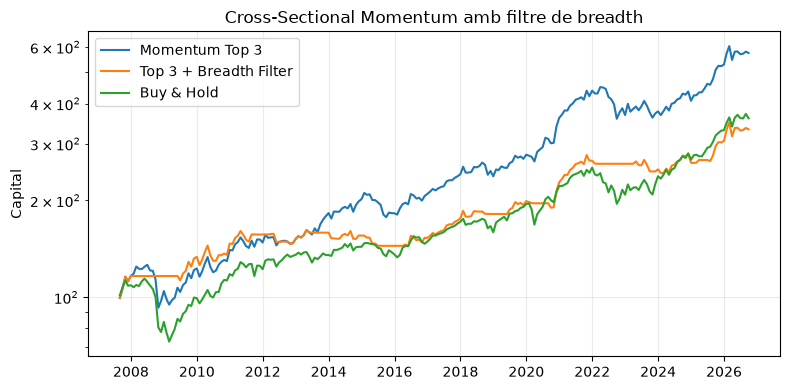

In [26]:
# CROSS-SECTIONAL MOMENTUM AMB FILTRE DE BREADTH

lookback_months = 6
top_n = 3

cost_bps = 10
cost_rate = cost_bps / 10000


# MOMENTUM DE 6 MESOS

momentum = (
    monthly_prices
    / monthly_prices.shift(lookback_months)
    - 1
)


# RANKING
# 1 = millor actiu

ranks = momentum.rank(
    axis=1,
    ascending=False,
    method="first"
)


# NOMBRE D'ACTIUS AMB MOMENTUM POSITIU

n_positive = (
    momentum > 0
).sum(axis=1)

n_assets = momentum.shape[1]

positive_regime = (
    n_positive > n_assets / 2
)


# COMPROVEM QUAN JA TENIM HISTORIAL SUFICIENT

valid_momentum = (
    momentum.notna().all(axis=1)
)


# ESTRATEGIA ORIGINAL:
# sempre LONG als TOP 3

weights_original_signal = (
    ranks <= top_n
).astype(float) / top_n

weights_original_signal.loc[
    ~valid_momentum
] = np.nan


# ESTRATEGIA AMB FILTRE:
# TOP 3 si hi ha majoria positiva
# CASH si no

weights_filter_signal = (
    weights_original_signal
    .mul(
        positive_regime.astype(float),
        axis=0
    )
)


# RETARD D'UN MES PER EVITAR LOOKAHEAD

weights_original = (
    weights_original_signal.shift(1)
)

weights_filter = (
    weights_filter_signal.shift(1)
)


# PERIODE COMU VALID

valid = (
    weights_original.notna().all(axis=1)
    & weights_filter.notna().all(axis=1)
    & monthly_returns.notna().all(axis=1)
)

start = valid[valid].index[0]


weights_original_bt = (
    weights_original.loc[start:]
)

weights_filter_bt = (
    weights_filter.loc[start:]
)

returns_bt = (
    monthly_returns.loc[start:]
)


# FUNCIO PER CALCULAR RETORNS NETS

def strategy_from_weights(
    weights,
    returns,
    cost_rate
):

    gross_returns = (
        weights * returns
    ).sum(axis=1)

    turnover = (
        weights
        .diff()
        .abs()
        .sum(axis=1)
        .fillna(0)
    )

    net_returns = (
        gross_returns
        - turnover * cost_rate
    )

    return net_returns, turnover


# CROSS-SECTIONAL ORIGINAL

original_returns, original_turnover = (
    strategy_from_weights(
        weights_original_bt,
        returns_bt,
        cost_rate
    )
)


# CROSS-SECTIONAL AMB FILTRE

filter_returns, filter_turnover = (
    strategy_from_weights(
        weights_filter_bt,
        returns_bt,
        cost_rate
    )
)


# BUY AND HOLD
# Capital inicial repartit entre els 8 actius
# i sense rebalanceig posterior

buyhold_sleeves = (
    1 + returns_bt
).cumprod() / len(cs_tickers)

buyhold_equity = (
    buyhold_sleeves.sum(axis=1)
)

buyhold_returns = (
    buyhold_equity
    .pct_change()
)

buyhold_returns.iloc[0] = (
    buyhold_equity.iloc[0] - 1
)


# METRIQUES

original_metrics = (
    performance_metrics_monthly(
        original_returns
    )
)

filter_metrics = (
    performance_metrics_monthly(
        filter_returns
    )
)

buyhold_metrics = (
    performance_metrics_monthly(
        buyhold_returns
    )
)


results = pd.DataFrame([
    {
        "Strategy": "Momentum Top 3",
        **original_metrics
    },
    {
        "Strategy": "Top 3 + Breadth Filter",
        **filter_metrics
    },
    {
        "Strategy": "Buy & Hold",
        **buyhold_metrics
    }
])


results_display = results.copy()

for col in [
    "Total Return",
    "CAGR",
    "Volatility",
    "Max Drawdown"
]:
    results_display[col] = (
        results_display[col] * 100
    ).map(
        lambda x: f"{x:.2f}%"
    )

results_display["Sharpe"] = (
    results_display["Sharpe"]
    .map(lambda x: f"{x:.2f}")
)


print(
    "Periode:",
    start.date(),
    "->",
    returns_bt.index[-1].date()
)

display(results_display)


# QUANT TEMPS ESTEM INVERTITS?

invested_months = (
    weights_filter_bt
    .abs()
    .sum(axis=1) > 0
)

print(
    "\nTemps invertit:",
    f"{invested_months.mean() * 100:.2f}%"
)

print(
    "Temps en cash:",
    f"{(~invested_months).mean() * 100:.2f}%"
)


# EQUITY CURVES

equity_original = (
    1 + original_returns
).cumprod() * 100

equity_filter = (
    1 + filter_returns
).cumprod() * 100

equity_buyhold = (
    1 + buyhold_returns
).cumprod() * 100


plt.figure(figsize=(8, 4))

plt.plot(
    equity_original,
    label="Momentum Top 3"
)

plt.plot(
    equity_filter,
    label="Top 3 + Breadth Filter"
)

plt.plot(
    equity_buyhold,
    label="Buy & Hold"
)

plt.title(
    "Cross-Sectional Momentum amb filtre de breadth"
)

plt.ylabel("Capital")
plt.yscale("log")

plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

## 4. Sensibilitat a l'horitzó de momentum

Fins ara hem utilitzat un momentum de 6 mesos.

Ara estudiarem diversos horitzons:

$$
1,\ 2,\ 3,\ 4,\ 6,\ 9,\ 12
\text{ mesos}
$$

Compararem quatre models:

1. Momentum Top 3;
2. Top 3 amb filtre de breadth;
3. règim LONG / SHORT;
4. Buy & Hold.

L'objectiu no és seleccionar automàticament el lookback amb millor resultat.

Busquem comprovar si existeix una zona de paràmetres amb comportament consistent.

Una estratègia més robusta hauria de mostrar bons resultats en una regió de lookbacks, no només en un valor concret.

Model,Buy & Hold,Momentum Top 3,Regime L/S,Top 3 + Breadth
Lookback,,,,
1,6.87,7.06,-2.38,2.38
2,6.87,7.86,-0.10,6.42
3,6.87,9.27,3.03,4.76
4,6.87,8.71,2.81,5.09
6,6.87,8.84,2.78,5.79
9,6.87,10.13,3.01,7.34
12,6.87,8.33,1.69,4.38


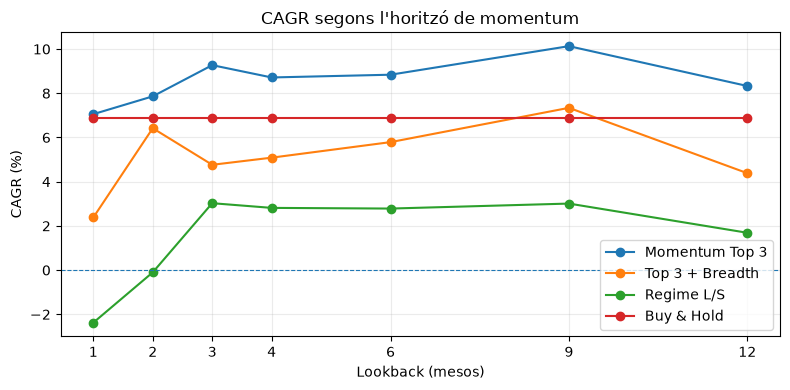

In [27]:
# SENSIBILITAT AL LOOKBACK - QUATRE MODELS

lookbacks_months = [
    1, 2, 3, 4, 6, 9, 12
]

top_n = 3

cost_bps = 10
cost_rate = cost_bps / 10000


def net_returns_from_weights(
    weights,
    returns,
    cost_rate
):

    gross_returns = (
        weights * returns
    ).sum(axis=1)

    turnover = (
        weights
        .diff()
        .abs()
        .sum(axis=1)
        .fillna(0)
    )

    net_returns = (
        gross_returns
        - turnover * cost_rate
    )

    return net_returns


# Mateix inici per TOTS els lookbacks:
# esperem fins que existeixin 12 mesos d'historial

max_lookback = max(lookbacks_months)

global_start = (
    monthly_prices.index[
        max_lookback + 1
    ]
)

returns_common = (
    monthly_returns
    .loc[global_start:]
    .copy()
)


# BUY AND HOLD
# Mateix benchmark per tots els lookbacks

buyhold_sleeves = (
    1 + returns_common
).cumprod() / len(cs_tickers)

buyhold_equity = (
    buyhold_sleeves.sum(axis=1)
)

buyhold_returns_common = (
    buyhold_equity
    .pct_change()
)

buyhold_returns_common.iloc[0] = (
    buyhold_equity.iloc[0] - 1
)

buyhold_metrics = (
    performance_metrics_monthly(
        buyhold_returns_common
    )
)


# RESULTATS

lookback_results = []


for lookback in lookbacks_months:

    # MOMENTUM

    momentum_lb = (
        monthly_prices
        / monthly_prices.shift(lookback)
        - 1
    )


    # RANKINGS

    ranks_best = momentum_lb.rank(
        axis=1,
        ascending=False,
        method="first"
    )

    ranks_worst = momentum_lb.rank(
        axis=1,
        ascending=True,
        method="first"
    )


    # BREADTH

    n_positive = (
        momentum_lb > 0
    ).sum(axis=1)

    n_negative = (
        momentum_lb < 0
    ).sum(axis=1)

    n_assets = (
        momentum_lb.shape[1]
    )


    # MODEL 1
    # MOMENTUM TOP 3

    weights_top3_signal = (
        ranks_best <= top_n
    ).astype(float) / top_n

    weights_top3 = (
        weights_top3_signal
        .shift(1)
        .loc[global_start:]
    )

    returns_top3 = (
        net_returns_from_weights(
            weights_top3,
            returns_common,
            cost_rate
        )
    )


    # MODEL 2
    # TOP 3 + BREADTH FILTER

    positive_regime = (
        n_positive > n_assets / 2
    )

    weights_breadth_signal = (
        weights_top3_signal
        .mul(
            positive_regime.astype(float),
            axis=0
        )
    )

    weights_breadth = (
        weights_breadth_signal
        .shift(1)
        .loc[global_start:]
    )

    returns_breadth = (
        net_returns_from_weights(
            weights_breadth,
            returns_common,
            cost_rate
        )
    )


    # MODEL 3
    # REGIME LONG / SHORT

    weights_ls_signal = pd.DataFrame(
        0.0,
        index=momentum_lb.index,
        columns=momentum_lb.columns
    )

    # LONG top 3 si majoria positiva

    long_dates = (
        n_positive > n_assets / 2
    )

    for date in momentum_lb.index[long_dates]:

        selected = (
            ranks_best.loc[date]
            <= top_n
        )

        weights_ls_signal.loc[
            date,
            selected
        ] = 1 / top_n


    # SHORT bottom 3 si majoria negativa

    short_dates = (
        n_negative > n_assets / 2
    )

    for date in momentum_lb.index[short_dates]:

        selected = (
            ranks_worst.loc[date]
            <= top_n
        )

        weights_ls_signal.loc[
            date,
            selected
        ] = -1 / top_n


    weights_ls = (
        weights_ls_signal
        .shift(1)
        .loc[global_start:]
    )

    returns_ls = (
        net_returns_from_weights(
            weights_ls,
            returns_common,
            cost_rate
        )
    )


    # METRIQUES

    metrics_top3 = (
        performance_metrics_monthly(
            returns_top3
        )
    )

    metrics_breadth = (
        performance_metrics_monthly(
            returns_breadth
        )
    )

    metrics_ls = (
        performance_metrics_monthly(
            returns_ls
        )
    )


    # GUARDEM RESULTATS

    models = {
        "Momentum Top 3":
            metrics_top3,

        "Top 3 + Breadth":
            metrics_breadth,

        "Regime L/S":
            metrics_ls,

        "Buy & Hold":
            buyhold_metrics
    }


    for model_name, metrics in models.items():

        lookback_results.append({
            "Lookback": lookback,
            "Model": model_name,

            "CAGR":
                metrics["CAGR"],

            "Volatility":
                metrics["Volatility"],

            "Sharpe":
                metrics["Sharpe"],

            "Max Drawdown":
                metrics["Max Drawdown"]
        })


lookback_results_df = pd.DataFrame(
    lookback_results
)


# TAULA RESUM DE CAGR

cagr_table = (
    lookback_results_df
    .pivot(
        index="Lookback",
        columns="Model",
        values="CAGR"
    )
    * 100
)

display(
    cagr_table.round(2)
)


# GRAFIC PRINCIPAL

plt.figure(figsize=(8, 4))

for model_name in [
    "Momentum Top 3",
    "Top 3 + Breadth",
    "Regime L/S",
    "Buy & Hold"
]:

    model_data = (
        lookback_results_df[
            lookback_results_df["Model"]
            == model_name
        ]
    )

    plt.plot(
        model_data["Lookback"],
        model_data["CAGR"] * 100,
        marker="o",
        label=model_name
    )


plt.axhline(
    0,
    linewidth=0.8,
    linestyle="--"
)

plt.title(
    "CAGR segons l'horitzó de momentum"
)

plt.xlabel(
    "Lookback (mesos)"
)

plt.ylabel(
    "CAGR (%)"
)

plt.xticks(
    lookbacks_months
)

plt.grid(alpha=0.25)

plt.legend()

plt.tight_layout()

plt.show()

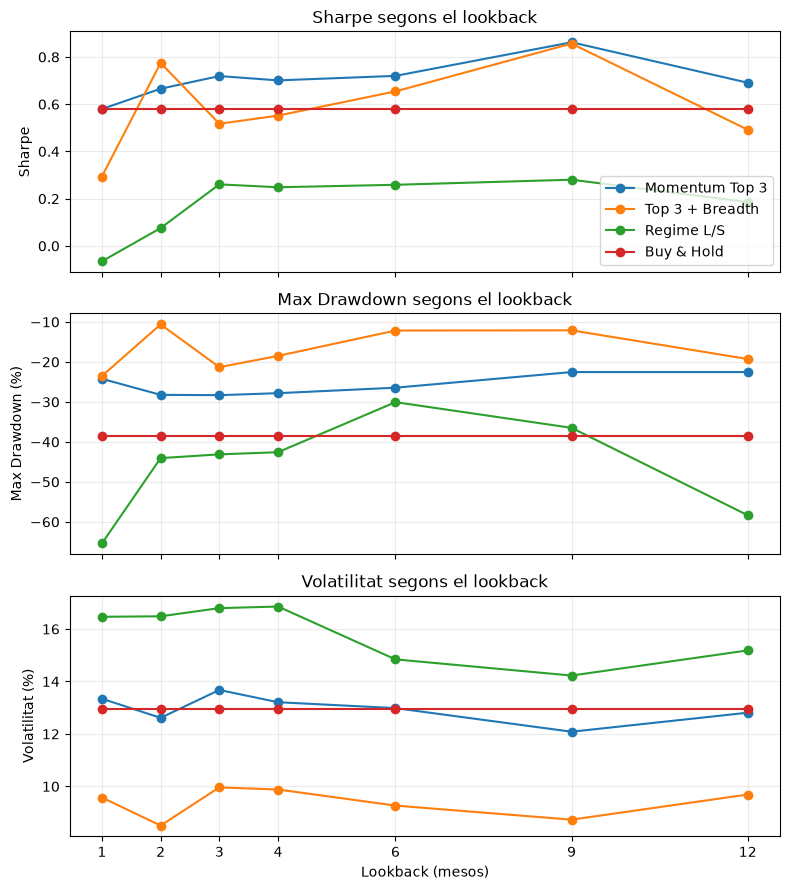

In [28]:
# RISC I QUALITAT SEGONS EL LOOKBACK

fig, axes = plt.subplots(
    3, 1,
    figsize=(8, 9),
    sharex=True
)

models_to_plot = [
    "Momentum Top 3",
    "Top 3 + Breadth",
    "Regime L/S",
    "Buy & Hold"
]


# SHARPE

for model_name in models_to_plot:

    data = lookback_results_df[
        lookback_results_df["Model"] == model_name
    ]

    axes[0].plot(
        data["Lookback"],
        data["Sharpe"],
        marker="o",
        label=model_name
    )

axes[0].set_title("Sharpe segons el lookback")
axes[0].set_ylabel("Sharpe")
axes[0].grid(alpha=0.25)
axes[0].legend()


# MAX DRAWDOWN

for model_name in models_to_plot:

    data = lookback_results_df[
        lookback_results_df["Model"] == model_name
    ]

    axes[1].plot(
        data["Lookback"],
        data["Max Drawdown"] * 100,
        marker="o"
    )

axes[1].set_title("Max Drawdown segons el lookback")
axes[1].set_ylabel("Max Drawdown (%)")
axes[1].grid(alpha=0.25)


# VOLATILITAT

for model_name in models_to_plot:

    data = lookback_results_df[
        lookback_results_df["Model"] == model_name
    ]

    axes[2].plot(
        data["Lookback"],
        data["Volatility"] * 100,
        marker="o"
    )

axes[2].set_title("Volatilitat segons el lookback")
axes[2].set_xlabel("Lookback (mesos)")
axes[2].set_ylabel("Volatilitat (%)")
axes[2].set_xticks(lookbacks_months)
axes[2].grid(alpha=0.25)


plt.tight_layout()
plt.show()

## 5. Sensibilitat fina del lookback

Fins ara hem comparat només alguns horitzons:

$$
1,2,3,4,6,9,12
\text{ mesos}
$$

Ara utilitzarem dades diàries per provar tots els lookbacks entre aproximadament 1 i 12 mesos:

$$
21,22,23,\ldots,252
\text{ dies borsaris}
$$

El rebalanceig continuarà sent mensual.

Per tant, no augmentem la freqüència de trading.

Només augmentem la resolució amb què estudiem el paràmetre de momentum.

L'objectiu és comprovar si existeix una regió robusta de lookbacks o si els bons resultats depenen d'un punt concret.

Calculant: 100.0% (232/232)
Fet.


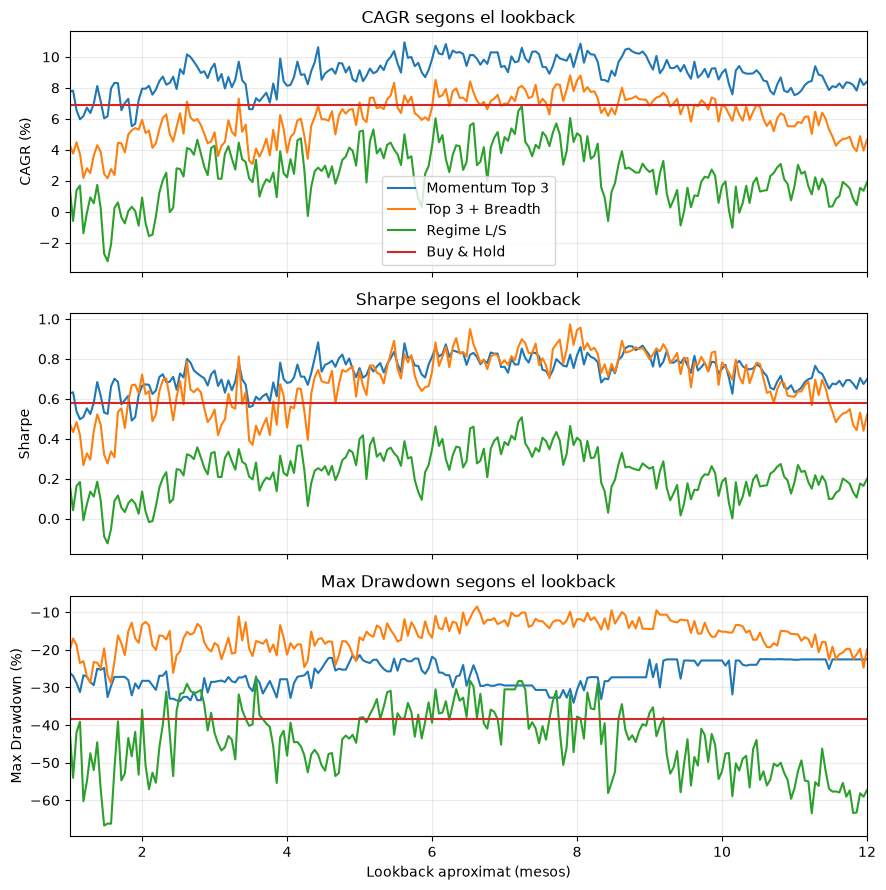

In [30]:
# SENSIBILITAT FINA DEL LOOKBACK

lookback_days = range(21, 253)

top_n = 3

cost_bps = 10
cost_rate = cost_bps / 10000


# PREUS I RETORNS MENSUALS

monthly_prices_daily_source = (
    cs_prices
    .resample("ME")
    .last()
)

monthly_returns_fine = (
    monthly_prices_daily_source
    .pct_change()
)


# Mateix periode per tots els lookbacks

max_lookback_days = max(lookback_days)

first_valid_daily_date = (
    cs_prices.index[
        max_lookback_days
    ]
)

global_start = (
    monthly_returns_fine.index[
        monthly_returns_fine.index
        > first_valid_daily_date
    ][1]
)

returns_common = (
    monthly_returns_fine
    .loc[global_start:]
    .copy()
)


# BUY AND HOLD

buyhold_sleeves = (
    1 + returns_common
).cumprod() / len(cs_tickers)

buyhold_equity = (
    buyhold_sleeves.sum(axis=1)
)

buyhold_returns = (
    buyhold_equity
    .pct_change()
)

buyhold_returns.iloc[0] = (
    buyhold_equity.iloc[0] - 1
)

buyhold_metrics = (
    performance_metrics_monthly(
        buyhold_returns
    )
)


def net_returns_from_weights(
    weights,
    returns,
    cost_rate
):

    gross_returns = (
        weights * returns
    ).sum(axis=1)

    turnover = (
        weights
        .diff()
        .abs()
        .sum(axis=1)
        .fillna(0)
    )

    net_returns = (
        gross_returns
        - turnover * cost_rate
    )

    return net_returns


fine_results = []

total_tests = len(lookback_days)


for n, lookback in enumerate(
    lookback_days,
    start=1
):

    # MOMENTUM DIARI

    momentum_daily = (
        cs_prices
        / cs_prices.shift(lookback)
        - 1
    )

    # Agafem el momentum disponible
    # al final de cada mes

    momentum_monthly = (
        momentum_daily
        .resample("ME")
        .last()
    )


    # RANKINGS

    ranks_best = (
        momentum_monthly.rank(
            axis=1,
            ascending=False,
            method="first"
        )
    )

    ranks_worst = (
        momentum_monthly.rank(
            axis=1,
            ascending=True,
            method="first"
        )
    )


    # BREADTH

    n_positive = (
        momentum_monthly > 0
    ).sum(axis=1)

    n_negative = (
        momentum_monthly < 0
    ).sum(axis=1)

    n_assets = (
        momentum_monthly.shape[1]
    )


    # MODEL 1
    # MOMENTUM TOP 3

    weights_top3_signal = (
        ranks_best <= top_n
    ).astype(float) / top_n

    weights_top3 = (
        weights_top3_signal
        .shift(1)
        .loc[global_start:]
    )

    returns_top3 = (
        net_returns_from_weights(
            weights_top3,
            returns_common,
            cost_rate
        )
    )


    # MODEL 2
    # TOP 3 + BREADTH

    positive_regime = (
        n_positive > n_assets / 2
    )

    weights_breadth_signal = (
        weights_top3_signal
        .mul(
            positive_regime.astype(float),
            axis=0
        )
    )

    weights_breadth = (
        weights_breadth_signal
        .shift(1)
        .loc[global_start:]
    )

    returns_breadth = (
        net_returns_from_weights(
            weights_breadth,
            returns_common,
            cost_rate
        )
    )


    # MODEL 3
    # REGIME LONG / SHORT

    weights_ls_signal = pd.DataFrame(
        0.0,
        index=momentum_monthly.index,
        columns=momentum_monthly.columns
    )

    long_dates = (
        n_positive > n_assets / 2
    )

    short_dates = (
        n_negative > n_assets / 2
    )


    for date in momentum_monthly.index[long_dates]:

        selected = (
            ranks_best.loc[date]
            <= top_n
        )

        weights_ls_signal.loc[
            date,
            selected
        ] = 1 / top_n


    for date in momentum_monthly.index[short_dates]:

        selected = (
            ranks_worst.loc[date]
            <= top_n
        )

        weights_ls_signal.loc[
            date,
            selected
        ] = -1 / top_n


    weights_ls = (
        weights_ls_signal
        .shift(1)
        .loc[global_start:]
    )

    returns_ls = (
        net_returns_from_weights(
            weights_ls,
            returns_common,
            cost_rate
        )
    )


    # METRIQUES

    metrics_top3 = (
        performance_metrics_monthly(
            returns_top3
        )
    )

    metrics_breadth = (
        performance_metrics_monthly(
            returns_breadth
        )
    )

    metrics_ls = (
        performance_metrics_monthly(
            returns_ls
        )
    )


    models = {
        "Momentum Top 3":
            metrics_top3,

        "Top 3 + Breadth":
            metrics_breadth,

        "Regime L/S":
            metrics_ls,

        "Buy & Hold":
            buyhold_metrics
    }


    for model_name, metrics in models.items():

        fine_results.append({
            "Lookback Days":
                lookback,

            "Lookback Months":
                lookback / 21,

            "Model":
                model_name,

            "CAGR":
                metrics["CAGR"],

            "Sharpe":
                metrics["Sharpe"],

            "Max Drawdown":
                metrics["Max Drawdown"],

            "Volatility":
                metrics["Volatility"]
        })


    # Progres global

    if (
        n == 1
        or n % 20 == 0
        or n == total_tests
    ):

        print(
            f"\rCalculant: "
            f"{100 * n / total_tests:.1f}% "
            f"({n}/{total_tests})",
            end=""
        )


print("\nFet.")


fine_results_df = pd.DataFrame(
    fine_results
)


# GRAFICS

fig, axes = plt.subplots(
    3,
    1,
    figsize=(9, 9),
    sharex=True
)


models_to_plot = [
    "Momentum Top 3",
    "Top 3 + Breadth",
    "Regime L/S",
    "Buy & Hold"
]


# CAGR

for model_name in models_to_plot:

    data = fine_results_df[
        fine_results_df["Model"]
        == model_name
    ]

    axes[0].plot(
        data["Lookback Months"],
        data["CAGR"] * 100,
        label=model_name,
        linewidth=1.5
    )


axes[0].set_title(
    "CAGR segons el lookback"
)

axes[0].set_ylabel(
    "CAGR (%)"
)

axes[0].grid(
    alpha=0.25
)

axes[0].legend()


# SHARPE

for model_name in models_to_plot:

    data = fine_results_df[
        fine_results_df["Model"]
        == model_name
    ]

    axes[1].plot(
        data["Lookback Months"],
        data["Sharpe"],
        linewidth=1.5
    )


axes[1].set_title(
    "Sharpe segons el lookback"
)

axes[1].set_ylabel(
    "Sharpe"
)

axes[1].grid(
    alpha=0.25
)


# MAX DRAWDOWN

for model_name in models_to_plot:

    data = fine_results_df[
        fine_results_df["Model"]
        == model_name
    ]

    axes[2].plot(
        data["Lookback Months"],
        data["Max Drawdown"] * 100,
        linewidth=1.5
    )


axes[2].set_title(
    "Max Drawdown segons el lookback"
)

axes[2].set_xlabel(
    "Lookback aproximat (mesos)"
)

axes[2].set_ylabel(
    "Max Drawdown (%)"
)

axes[2].set_xlim(
    1,
    12
)

axes[2].grid(
    alpha=0.25
)


plt.tight_layout()
plt.show()

## 6. Rendibilitat respecte al drawdown

El Sharpe compara rendibilitat i volatilitat.

Però no ens diu directament quanta rendibilitat obtenim respecte a la pitjor caiguda històrica.

Per això utilitzarem el Calmar Ratio:

$$
Calmar
=
\frac{CAGR}
{|MaxDrawdown|}
$$

Un Calmar més alt indica més rendibilitat anual per unitat de drawdown màxim.

Això ens ajudarà especialment a comparar:

- Momentum Top 3;
- Top 3 + Breadth Filter.

Les dues estratègies poden tenir Sharpe semblant però perfils de drawdown molt diferents.

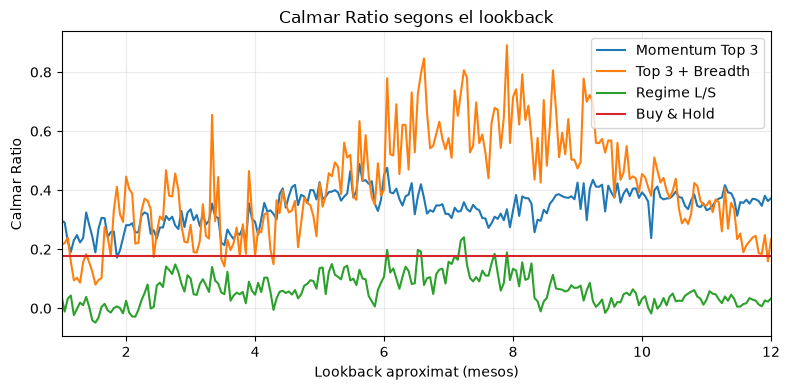

In [31]:
# CALMAR RATIO SEGONS EL LOOKBACK

calmar_results = fine_results_df.copy()

calmar_results["Calmar"] = (
    calmar_results["CAGR"]
    / calmar_results["Max Drawdown"].abs()
)


plt.figure(figsize=(8, 4))

for model_name in [
    "Momentum Top 3",
    "Top 3 + Breadth",
    "Regime L/S",
    "Buy & Hold"
]:

    data = calmar_results[
        calmar_results["Model"] == model_name
    ]

    plt.plot(
        data["Lookback Months"],
        data["Calmar"],
        linewidth=1.5,
        label=model_name
    )


plt.title(
    "Calmar Ratio segons el lookback"
)

plt.xlabel(
    "Lookback aproximat (mesos)"
)

plt.ylabel(
    "Calmar Ratio"
)

plt.xlim(
    1,
    12
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()

## 7. Comparació a igual volatilitat

Momentum Top 3 i Breadth Filter assumeixen nivells de risc diferents.

Per comparar-los de manera més justa aplicarem un volatility target:

$$
\sigma_{target}=12\%
$$

L'exposició serà:

$$
L_t
=
\frac{\sigma_{target}}
{\hat{\sigma}_{t-1}}
$$

amb un leverage màxim de:

$$
L_{max}=2
$$

La volatilitat s'estimarà utilitzant només informació passada.

Escalarem els pesos de la cartera abans de calcular turnover i costos.

Aquesta prova ens permetrà distingir entre:

$$
\text{menys risc simplement perquè estem més en cash}
$$

i

$$
\text{millor ús del risc}
$$

Encara no incorporarem costos de finançament del leverage.

Calculant: 100.0% (232/232)
Fet.


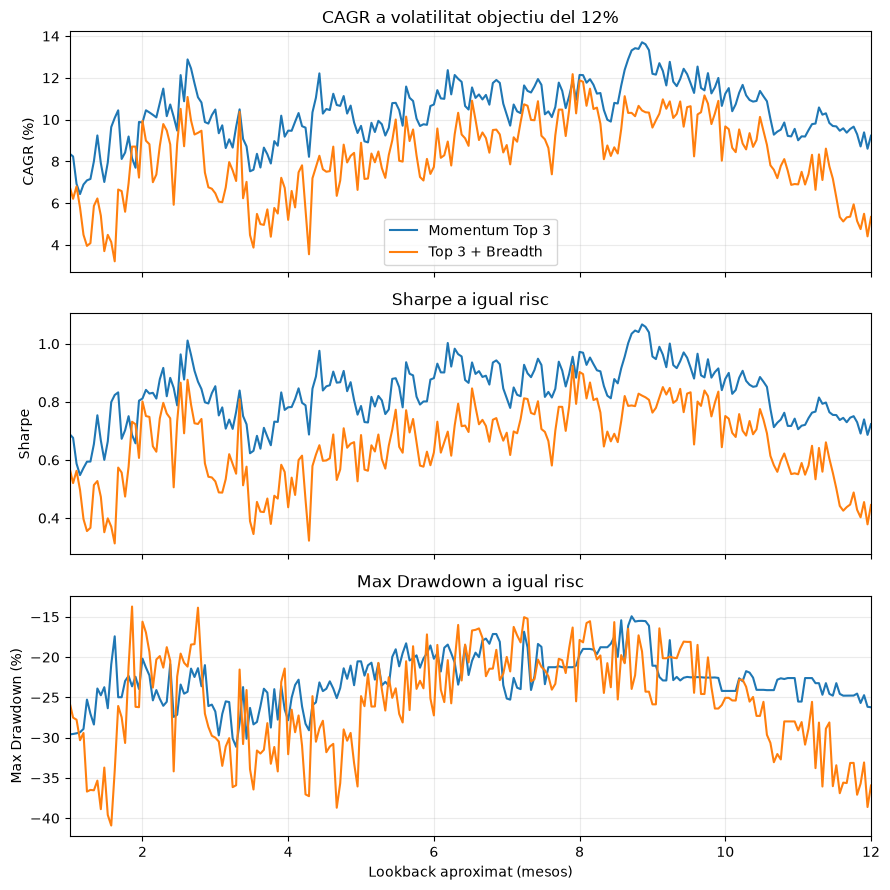

In [32]:
# COMPARACIO TOP 3 VS BREADTH A IGUAL RISC

lookback_days = range(21, 253)

top_n = 3

target_vol = 0.12
vol_window = 12
max_leverage = 2.0

cost_bps = 10
cost_rate = cost_bps / 10000


# PERIODE COMU

max_lookback = max(lookback_days)

first_valid_date = cs_prices.index[max_lookback]

global_start = (
    monthly_returns_fine.index[
        monthly_returns_fine.index > first_valid_date
    ][1]
)

returns_common = (
    monthly_returns_fine
    .loc[global_start:]
    .copy()
)


risk_matched_results = []

total_tests = len(lookback_days)


for n, lookback in enumerate(
    lookback_days,
    start=1
):

    # MOMENTUM DIARI

    momentum_daily = (
        cs_prices
        / cs_prices.shift(lookback)
        - 1
    )

    momentum_monthly = (
        momentum_daily
        .resample("ME")
        .last()
    )


    # RANKING

    ranks = momentum_monthly.rank(
        axis=1,
        ascending=False,
        method="first"
    )


    # BREADTH

    n_positive = (
        momentum_monthly > 0
    ).sum(axis=1)

    n_assets = momentum_monthly.shape[1]

    positive_regime = (
        n_positive > n_assets / 2
    )


    # PESOS TOP 3

    weights_top3_signal = (
        ranks <= top_n
    ).astype(float) / top_n

    weights_top3 = (
        weights_top3_signal
        .shift(1)
        .loc[global_start:]
    )


    # PESOS BREADTH

    weights_breadth_signal = (
        weights_top3_signal
        .mul(
            positive_regime.astype(float),
            axis=0
        )
    )

    weights_breadth = (
        weights_breadth_signal
        .shift(1)
        .loc[global_start:]
    )


    # FUNCIO DE VOL TARGET

    def vol_target_weights(
        base_weights,
        returns
    ):

        # Retorn brut de l'estrategia base

        base_returns = (
            base_weights * returns
        ).sum(axis=1)


        # Volatilitat historica anualitzada

        estimated_vol = (
            base_returns
            .rolling(vol_window)
            .std()
            * np.sqrt(12)
        )


        # Només utilitzem informació passada

        estimated_vol = (
            estimated_vol.shift(1)
        )


        leverage = (
            target_vol
            / estimated_vol
        ).clip(
            lower=0,
            upper=max_leverage
        )


        scaled_weights = (
            base_weights
            .mul(
                leverage,
                axis=0
            )
            .fillna(0)
        )


        # RETORN BRUT

        gross_returns = (
            scaled_weights
            * returns
        ).sum(axis=1)


        # TURNOVER REAL DELS PESOS ESCALATS

        turnover = (
            scaled_weights
            .diff()
            .abs()
            .sum(axis=1)
            .fillna(0)
        )


        # RETORN NET

        net_returns = (
            gross_returns
            - turnover * cost_rate
        )


        return (
            net_returns,
            leverage,
            scaled_weights
        )


    # TOP 3

    top3_returns, top3_lev, _ = (
        vol_target_weights(
            weights_top3,
            returns_common
        )
    )


    # BREADTH

    breadth_returns, breadth_lev, _ = (
        vol_target_weights(
            weights_breadth,
            returns_common
        )
    )


    # METRIQUES

    top3_metrics = (
        performance_metrics_monthly(
            top3_returns
        )
    )

    breadth_metrics = (
        performance_metrics_monthly(
            breadth_returns
        )
    )


    for model_name, metrics, leverage in [

        (
            "Momentum Top 3",
            top3_metrics,
            top3_lev
        ),

        (
            "Top 3 + Breadth",
            breadth_metrics,
            breadth_lev
        )
    ]:

        risk_matched_results.append({

            "Lookback Days":
                lookback,

            "Lookback Months":
                lookback / 21,

            "Model":
                model_name,

            "CAGR":
                metrics["CAGR"],

            "Volatility":
                metrics["Volatility"],

            "Sharpe":
                metrics["Sharpe"],

            "Max Drawdown":
                metrics["Max Drawdown"],

            "Calmar":
                metrics["CAGR"]
                / abs(metrics["Max Drawdown"]),

            "Avg Leverage":
                leverage.mean()
        })


    if (
        n == 1
        or n % 20 == 0
        or n == total_tests
    ):

        print(
            f"\rCalculant: "
            f"{100 * n / total_tests:.1f}% "
            f"({n}/{total_tests})",
            end=""
        )


print("\nFet.")


risk_matched_df = pd.DataFrame(
    risk_matched_results
)


# GRAFICS

fig, axes = plt.subplots(
    3,
    1,
    figsize=(9, 9),
    sharex=True
)


for model_name in [
    "Momentum Top 3",
    "Top 3 + Breadth"
]:

    data = risk_matched_df[
        risk_matched_df["Model"]
        == model_name
    ]


    # CAGR

    axes[0].plot(
        data["Lookback Months"],
        data["CAGR"] * 100,
        label=model_name,
        linewidth=1.5
    )


    # SHARPE

    axes[1].plot(
        data["Lookback Months"],
        data["Sharpe"],
        linewidth=1.5
    )


    # MAX DRAWDOWN

    axes[2].plot(
        data["Lookback Months"],
        data["Max Drawdown"] * 100,
        linewidth=1.5
    )


axes[0].set_title(
    "CAGR a volatilitat objectiu del 12%"
)

axes[0].set_ylabel(
    "CAGR (%)"
)

axes[0].legend()

axes[0].grid(alpha=0.25)


axes[1].set_title(
    "Sharpe a igual risc"
)

axes[1].set_ylabel(
    "Sharpe"
)

axes[1].grid(alpha=0.25)


axes[2].set_title(
    "Max Drawdown a igual risc"
)

axes[2].set_xlabel(
    "Lookback aproximat (mesos)"
)

axes[2].set_ylabel(
    "Max Drawdown (%)"
)

axes[2].set_xlim(
    1,
    12
)

axes[2].grid(alpha=0.25)


plt.tight_layout()

plt.show()

## 8. Estabilitat temporal del Momentum Top 3

La mostra completa pot ocultar comportaments molt diferents al llarg del temps.

Per tant, no buscarem el millor lookback sobre tota la història.

Dividirem els resultats en quatre períodes:

- 2008–2012;
- 2013–2017;
- 2018–2022;
- 2023–2026.

Per cada període i cada lookback calcularem:

$$
CAGR_{Top3}
-
CAGR_{BuyHold}
$$

Un resultat robust no hauria de dependre exclusivament d'un únic període o d'un únic lookback.

Busquem una regió que mostri comportament raonablement consistent al llarg del temps.

Calculant: 100.0% (232/232)
Fet.


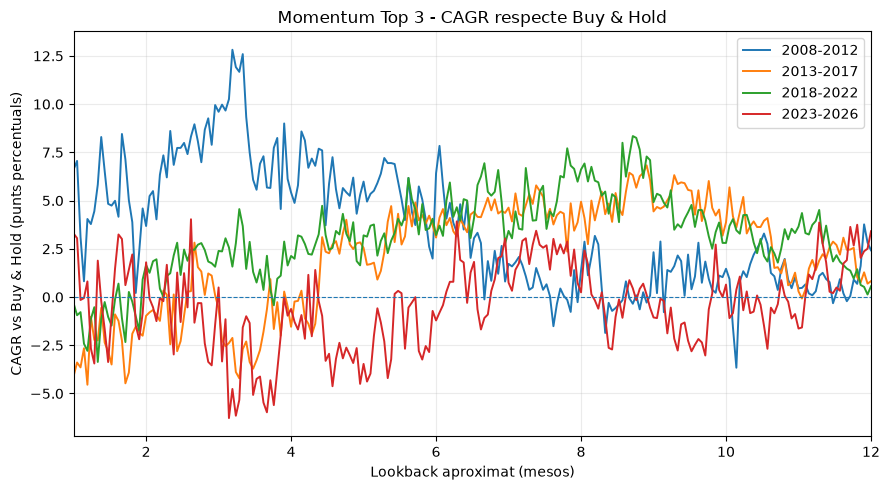

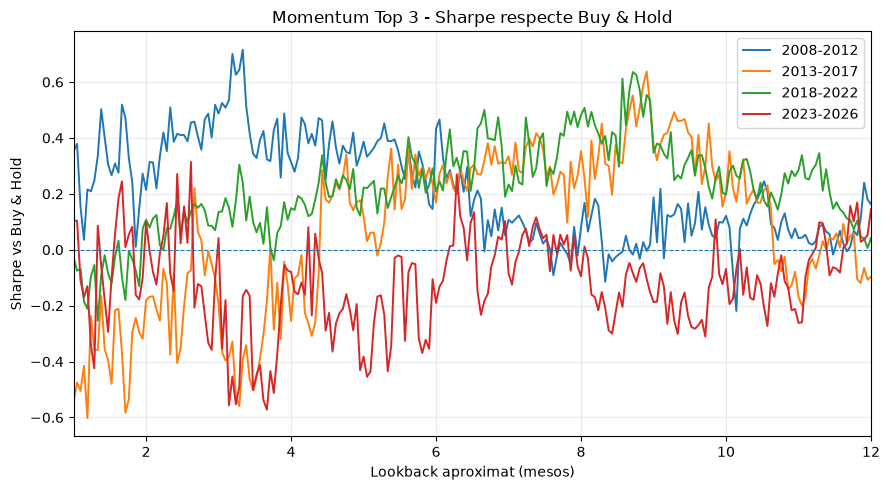

In [33]:
# ESTABILITAT TEMPORAL DEL MOMENTUM TOP 3

periods = {
    "2008-2012": ("2008-01-01", "2012-12-31"),
    "2013-2017": ("2013-01-01", "2017-12-31"),
    "2018-2022": ("2018-01-01", "2022-12-31"),
    "2023-2026": ("2023-01-01", "2026-09-30")
}

lookback_days = range(21, 253)

top_n = 3

cost_bps = 10
cost_rate = cost_bps / 10000


stability_results = []

total_tests = len(lookback_days)


for n, lookback in enumerate(
    lookback_days,
    start=1
):

    # MOMENTUM DIARI

    momentum_daily = (
        cs_prices
        / cs_prices.shift(lookback)
        - 1
    )


    # MOMENTUM DISPONIBLE A FINAL DE MES

    momentum_monthly = (
        momentum_daily
        .resample("ME")
        .last()
    )


    # RANKING

    ranks = momentum_monthly.rank(
        axis=1,
        ascending=False,
        method="first"
    )


    # TOP 3

    weights_signal = (
        ranks <= top_n
    ).astype(float) / top_n


    # UN MES DE RETARD

    weights = (
        weights_signal.shift(1)
    )


    # ANALISI PER PERIODES

    for period_name, (start, end) in periods.items():

        period_returns = (
            monthly_returns_fine
            .loc[start:end]
            .copy()
        )

        period_weights = (
            weights
            .reindex(period_returns.index)
        )


        valid = (
            period_weights.notna().all(axis=1)
            & period_returns.notna().all(axis=1)
        )

        period_returns = (
            period_returns.loc[valid]
        )

        period_weights = (
            period_weights.loc[valid]
        )


        if len(period_returns) < 12:
            continue


        # MOMENTUM TOP 3

        gross_returns = (
            period_weights
            * period_returns
        ).sum(axis=1)

        turnover = (
            period_weights
            .diff()
            .abs()
            .sum(axis=1)
            .fillna(0)
        )

        top3_returns = (
            gross_returns
            - turnover * cost_rate
        )


        # BUY AND HOLD DEL MATEIX PERIODE

        buyhold_sleeves = (
            1 + period_returns
        ).cumprod() / len(cs_tickers)

        buyhold_equity = (
            buyhold_sleeves.sum(axis=1)
        )

        buyhold_returns = (
            buyhold_equity
            .pct_change()
        )

        buyhold_returns.iloc[0] = (
            buyhold_equity.iloc[0] - 1
        )


        # METRIQUES

        top3_metrics = (
            performance_metrics_monthly(
                top3_returns
            )
        )

        buyhold_metrics = (
            performance_metrics_monthly(
                buyhold_returns
            )
        )


        stability_results.append({

            "Period":
                period_name,

            "Lookback Days":
                lookback,

            "Lookback Months":
                lookback / 21,

            "Top3 CAGR":
                top3_metrics["CAGR"],

            "B&H CAGR":
                buyhold_metrics["CAGR"],

            "CAGR vs B&H":
                top3_metrics["CAGR"]
                - buyhold_metrics["CAGR"],

            "Top3 Sharpe":
                top3_metrics["Sharpe"],

            "B&H Sharpe":
                buyhold_metrics["Sharpe"],

            "Sharpe vs B&H":
                top3_metrics["Sharpe"]
                - buyhold_metrics["Sharpe"]
        })


    if (
        n == 1
        or n % 20 == 0
        or n == total_tests
    ):

        print(
            f"\rCalculant: "
            f"{100 * n / total_tests:.1f}% "
            f"({n}/{total_tests})",
            end=""
        )


print("\nFet.")


stability_df = pd.DataFrame(
    stability_results
)


# GRAFIC: CAGR RELATIU PER PERIODE

plt.figure(figsize=(9, 5))

for period_name in periods:

    data = stability_df[
        stability_df["Period"]
        == period_name
    ]

    plt.plot(
        data["Lookback Months"],
        data["CAGR vs B&H"] * 100,
        label=period_name,
        linewidth=1.4
    )


plt.axhline(
    0,
    linewidth=0.8,
    linestyle="--"
)

plt.title(
    "Momentum Top 3 - CAGR respecte Buy & Hold"
)

plt.xlabel(
    "Lookback aproximat (mesos)"
)

plt.ylabel(
    "CAGR vs Buy & Hold (punts percentuals)"
)

plt.xlim(
    1,
    12
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# GRAFIC: SHARPE RELATIU PER PERIODE

plt.figure(figsize=(9, 5))

for period_name in periods:

    data = stability_df[
        stability_df["Period"]
        == period_name
    ]

    plt.plot(
        data["Lookback Months"],
        data["Sharpe vs B&H"],
        label=period_name,
        linewidth=1.4
    )


plt.axhline(
    0,
    linewidth=0.8,
    linestyle="--"
)

plt.title(
    "Momentum Top 3 - Sharpe respecte Buy & Hold"
)

plt.xlabel(
    "Lookback aproximat (mesos)"
)

plt.ylabel(
    "Sharpe vs Buy & Hold"
)

plt.xlim(
    1,
    12
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()

## 9. Robustesa entre períodes

Un bon resultat sobre la mostra completa pot estar dominat per un únic període.

Per cada lookback calcularem:

- nombre de períodes on el CAGR supera Buy & Hold;
- excés de CAGR mediana;
- excés de CAGR del pitjor període;
- nombre de períodes on el Sharpe supera Buy & Hold;
- millora mediana de Sharpe.

L'objectiu no és trobar el màxim exacte.

Busquem una regió on:

$$
\text{diversos períodes}
\rightarrow
\text{resultats consistentment positius}
$$

Això és una evidència de robustesa més útil que un únic pic de rendiment.

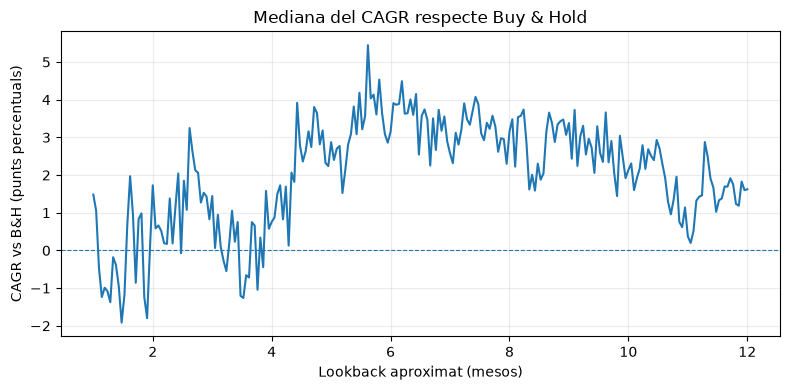

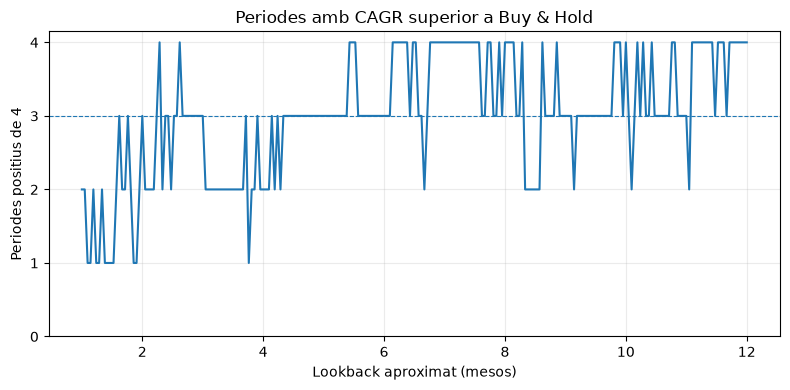

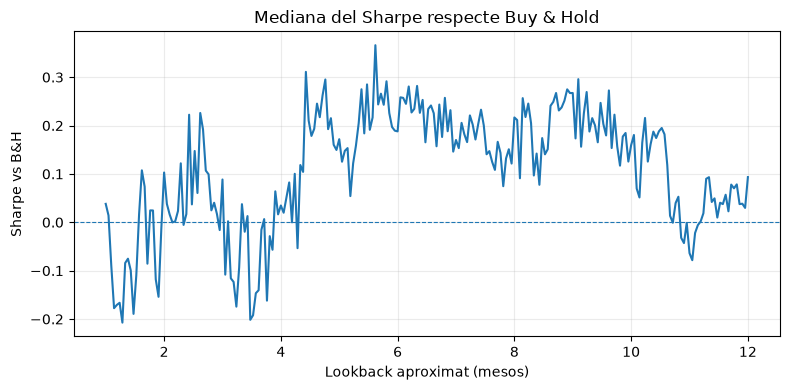

Lookbacks que superen Buy & Hold en CAGR i Sharpe en almenys 3 de 4 períodes:


,Lookback Days,Lookback Months,Median_CAGR_vs_BH,Positive_CAGR_Periods,Median_Sharpe_vs_BH,Positive_Sharpe_Periods
13,34,1.619048,0.019690,3,0.107412,3
21,42,2.000000,0.017274,3,0.102933,3
27,48,2.285714,0.013786,4,0.121924,3
30,51,2.428571,0.020428,3,0.222375,3
32,53,2.523810,0.018499,3,0.147437,3
...,...,...,...,...,...,...
227,248,11.809524,0.012333,4,0.078371,3
228,249,11.857143,0.011872,4,0.037576,3
229,250,11.904762,0.018274,4,0.038425,3
230,251,11.952381,0.015999,4,0.029759,3


In [34]:
# ROBUSTESA ENTRE PERIODES

robustness = (
    stability_df
    .groupby(
        ["Lookback Days", "Lookback Months"]
    )
    .agg(
        Median_CAGR_vs_BH=(
            "CAGR vs B&H",
            "median"
        ),

        Worst_CAGR_vs_BH=(
            "CAGR vs B&H",
            "min"
        ),

        Positive_CAGR_Periods=(
            "CAGR vs B&H",
            lambda x: (x > 0).sum()
        ),

        Median_Sharpe_vs_BH=(
            "Sharpe vs B&H",
            "median"
        ),

        Worst_Sharpe_vs_BH=(
            "Sharpe vs B&H",
            "min"
        ),

        Positive_Sharpe_Periods=(
            "Sharpe vs B&H",
            lambda x: (x > 0).sum()
        )
    )
    .reset_index()
)


# GRAFIC 1
# MEDIANA DE CAGR RELATIU

plt.figure(figsize=(8, 4))

plt.plot(
    robustness["Lookback Months"],
    robustness["Median_CAGR_vs_BH"] * 100,
    linewidth=1.5
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)

plt.title(
    "Mediana del CAGR respecte Buy & Hold"
)

plt.xlabel(
    "Lookback aproximat (mesos)"
)

plt.ylabel(
    "CAGR vs B&H (punts percentuals)"
)

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# GRAFIC 2
# QUANTS PERIODES SUPEREN BUY AND HOLD

plt.figure(figsize=(8, 4))

plt.plot(
    robustness["Lookback Months"],
    robustness["Positive_CAGR_Periods"],
    linewidth=1.5
)

plt.yticks(
    [0, 1, 2, 3, 4]
)

plt.axhline(
    3,
    linestyle="--",
    linewidth=0.8
)

plt.title(
    "Periodes amb CAGR superior a Buy & Hold"
)

plt.xlabel(
    "Lookback aproximat (mesos)"
)

plt.ylabel(
    "Periodes positius de 4"
)

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# GRAFIC 3
# ROBUSTESA DE SHARPE

plt.figure(figsize=(8, 4))

plt.plot(
    robustness["Lookback Months"],
    robustness["Median_Sharpe_vs_BH"],
    linewidth=1.5
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)

plt.title(
    "Mediana del Sharpe respecte Buy & Hold"
)

plt.xlabel(
    "Lookback aproximat (mesos)"
)

plt.ylabel(
    "Sharpe vs B&H"
)

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# REGIO QUE SUPERA B&H EN ALMENYS 3 DE 4 PERIODES

robust_zone = robustness[
    (robustness["Positive_CAGR_Periods"] >= 3)
    &
    (robustness["Positive_Sharpe_Periods"] >= 3)
].copy()


print(
    "Lookbacks que superen Buy & Hold"
    " en CAGR i Sharpe en almenys 3 de 4 períodes:"
)

display(
    robust_zone[
        [
            "Lookback Days",
            "Lookback Months",
            "Median_CAGR_vs_BH",
            "Positive_CAGR_Periods",
            "Median_Sharpe_vs_BH",
            "Positive_Sharpe_Periods"
        ]
    ]
)

## 10. Robustesa amb finestres rolling

Dividir la història en quatre blocs genera molt poques observacions.

Per estudiar millor l'estabilitat temporal utilitzarem finestres mòbils.

Començarem amb una finestra de 36 mesos.

Per exemple:

$$
2008\text{-}2010
$$

després avancem un mes:

$$
2008\text{-}2011
$$

i continuem avançant mensualment.

Per cada finestra i cada lookback calcularem:

$$
CAGR_{Top3}
-
CAGR_{BuyHold}
$$

Les finestres se solapen i, per tant, no són observacions estadísticament independents.

No les utilitzarem com experiments independents, sinó com una mesura de l'estabilitat temporal del senyal.

Calculant: 100.0% (232/232)
Fet.


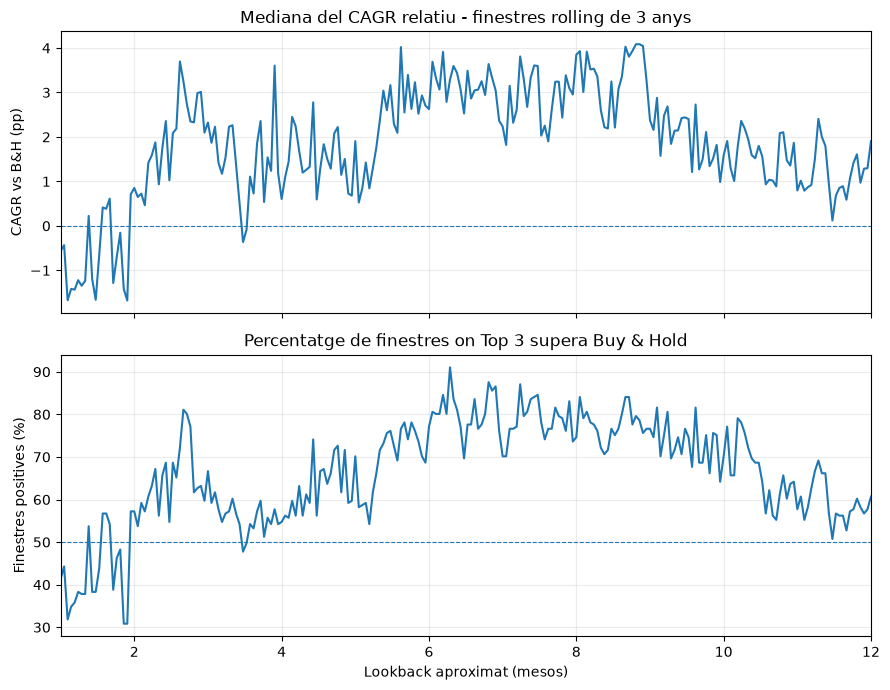

In [35]:
# ROBUSTESA AMB FINESTRES ROLLING DE 3 ANYS

rolling_months = 36

lookback_days = range(21, 253)

top_n = 3

cost_bps = 10
cost_rate = cost_bps / 10000

rolling_results = []

total_tests = len(lookback_days)


for n, lookback in enumerate(
    lookback_days,
    start=1
):

    # MOMENTUM

    momentum_daily = (
        cs_prices
        / cs_prices.shift(lookback)
        - 1
    )

    momentum_monthly = (
        momentum_daily
        .resample("ME")
        .last()
    )


    # RANKING

    ranks = momentum_monthly.rank(
        axis=1,
        ascending=False,
        method="first"
    )


    # TOP 3

    weights_signal = (
        ranks <= top_n
    ).astype(float) / top_n

    weights = (
        weights_signal.shift(1)
    )


    # PERIODE COMU

    valid = (
        weights.notna().all(axis=1)
        & monthly_returns_fine.notna().all(axis=1)
    )

    dates = monthly_returns_fine.index[valid]


    # FINESTRES ROLLING

    for end_idx in range(
        rolling_months - 1,
        len(dates)
    ):

        window_dates = dates[
            end_idx - rolling_months + 1:
            end_idx + 1
        ]

        period_returns = (
            monthly_returns_fine
            .loc[window_dates]
        )

        period_weights = (
            weights
            .loc[window_dates]
        )


        # TOP 3

        gross_returns = (
            period_weights
            * period_returns
        ).sum(axis=1)

        turnover = (
            period_weights
            .diff()
            .abs()
            .sum(axis=1)
            .fillna(0)
        )

        top3_returns = (
            gross_returns
            - turnover * cost_rate
        )


        # BUY AND HOLD

        buyhold_sleeves = (
            1 + period_returns
        ).cumprod() / len(cs_tickers)

        buyhold_equity = (
            buyhold_sleeves.sum(axis=1)
        )

        buyhold_returns = (
            buyhold_equity
            .pct_change()
        )

        buyhold_returns.iloc[0] = (
            buyhold_equity.iloc[0] - 1
        )


        # METRIQUES

        top3_metrics = (
            performance_metrics_monthly(
                top3_returns
            )
        )

        bh_metrics = (
            performance_metrics_monthly(
                buyhold_returns
            )
        )


        rolling_results.append({

            "Window End":
                window_dates[-1],

            "Lookback Days":
                lookback,

            "Lookback Months":
                lookback / 21,

            "CAGR vs B&H":
                top3_metrics["CAGR"]
                - bh_metrics["CAGR"],

            "Sharpe vs B&H":
                top3_metrics["Sharpe"]
                - bh_metrics["Sharpe"]
        })


    if (
        n == 1
        or n % 20 == 0
        or n == total_tests
    ):

        print(
            f"\rCalculant: "
            f"{100 * n / total_tests:.1f}% "
            f"({n}/{total_tests})",
            end=""
        )


print("\nFet.")


rolling_df = pd.DataFrame(
    rolling_results
)


# RESUM PER LOOKBACK

rolling_summary = (
    rolling_df
    .groupby(
        [
            "Lookback Days",
            "Lookback Months"
        ]
    )
    .agg(

        Median_CAGR_vs_BH=(
            "CAGR vs B&H",
            "median"
        ),

        Positive_CAGR_Windows=(
            "CAGR vs B&H",
            lambda x: (x > 0).mean()
        ),

        Median_Sharpe_vs_BH=(
            "Sharpe vs B&H",
            "median"
        ),

        Positive_Sharpe_Windows=(
            "Sharpe vs B&H",
            lambda x: (x > 0).mean()
        )
    )
    .reset_index()
)


fig, axes = plt.subplots(
    2,
    1,
    figsize=(9, 7),
    sharex=True
)


# CAGR MEDIÀ

axes[0].plot(
    rolling_summary["Lookback Months"],
    rolling_summary["Median_CAGR_vs_BH"] * 100
)

axes[0].axhline(
    0,
    linestyle="--",
    linewidth=0.8
)

axes[0].set_title(
    "Mediana del CAGR relatiu - finestres rolling de 3 anys"
)

axes[0].set_ylabel(
    "CAGR vs B&H (pp)"
)

axes[0].grid(alpha=0.25)


# % DE FINESTRES POSITIVES

axes[1].plot(
    rolling_summary["Lookback Months"],
    rolling_summary["Positive_CAGR_Windows"] * 100
)

axes[1].axhline(
    50,
    linestyle="--",
    linewidth=0.8
)

axes[1].set_title(
    "Percentatge de finestres on Top 3 supera Buy & Hold"
)

axes[1].set_xlabel(
    "Lookback aproximat (mesos)"
)

axes[1].set_ylabel(
    "Finestres positives (%)"
)

axes[1].set_xlim(
    1,
    12
)

axes[1].grid(alpha=0.25)


plt.tight_layout()
plt.show()

## 11. Walk-forward

El backtest complet utilitza tota la història per analitzar els paràmetres.

En un walk-forward simulem una situació més realista.

Per cada any:

1. utilitzem només els 5 anys anteriors;
2. comparem els lookbacks de 21 a 252 dies;
3. seleccionem el lookback amb millor Sharpe dins del període de train;
4. congelem aquest lookback;
5. l'utilitzem durant l'any següent.

Per exemple:

$$
2009-2013
\rightarrow
\text{selecció}
\rightarrow
2014
$$

Després avancem:

$$
2010-2014
\rightarrow
\text{selecció}
\rightarrow
2015
$$

El resultat final s'obté concatenant únicament els períodes futurs.

Això evita seleccionar un paràmetre utilitzant informació posterior al moment en què hauria estat escollit.

Precalculant: 100.0% (232/232)
Precalculat.
RESULTATS WALK-FORWARD:


,Year,Selected Days,Selected Months,Train Sharpe,OOS Return
0,2014,70,3.33,1.60,12.87%
1,2015,70,3.33,1.57,-15.35%
2,2016,222,10.57,0.96,6.16%
3,2017,187,8.90,1.15,18.45%
4,2018,187,8.90,1.44,0.54%
5,2019,187,8.90,0.87,23.36%
6,2020,187,8.90,1.07,24.61%
7,2021,184,8.76,1.51,26.81%
8,2022,187,8.90,1.67,-13.52%
9,2023,183,8.71,1.00,3.79%



RESULTAT TOTAL OUT-OF-SAMPLE:


,Strategy,Total Return,CAGR,Volatility,Sharpe,Max Drawdown
0,Walk-Forward Momentum,221.02%,9.58%,11.81%,0.84,-19.97%
1,Buy & Hold,156.74%,7.68%,11.33%,0.71,-22.77%


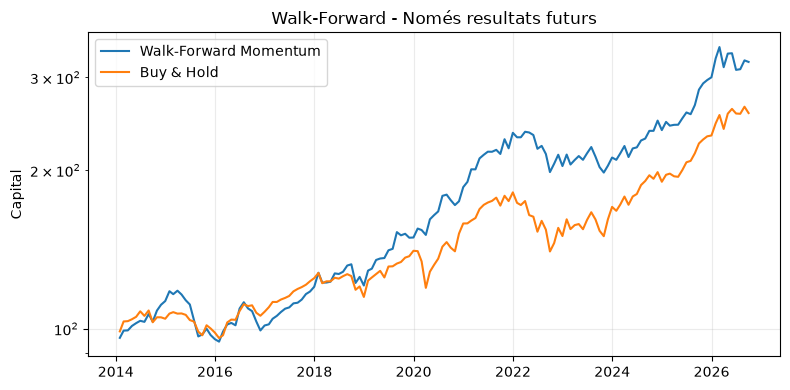

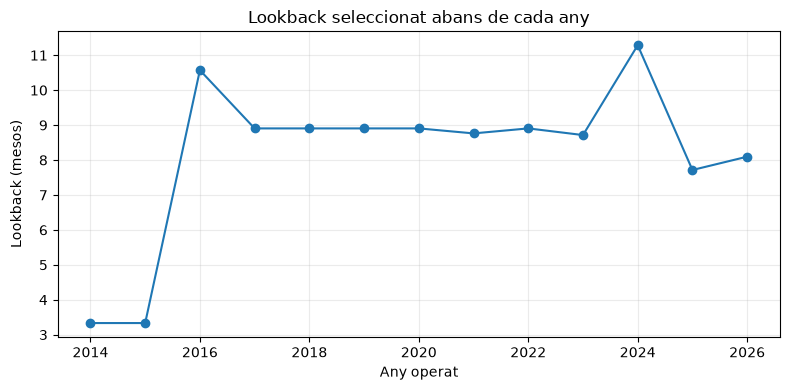

In [37]:
# WALK-FORWARD ANUAL

candidate_lookbacks = range(21, 253)

train_years = 5
top_n = 3

cost_bps = 10
cost_rate = cost_bps / 10000


# PRECALCULEM ELS RETORNS DE CADA LOOKBACK

strategy_returns_dict = {}

total_tests = len(candidate_lookbacks)


for n, lookback in enumerate(
    candidate_lookbacks,
    start=1
):

    # MOMENTUM DIARI

    momentum_daily = (
        cs_prices
        / cs_prices.shift(lookback)
        - 1
    )


    # MOMENTUM DISPONIBLE A FINAL DE MES

    momentum_monthly = (
        momentum_daily
        .resample("ME")
        .last()
    )


    # RANKING

    ranks = momentum_monthly.rank(
        axis=1,
        ascending=False,
        method="first"
    )


    # TOP 3

    weights_signal = (
        ranks <= top_n
    ).astype(float) / top_n


    # UTILITZEM EL SENYAL DURANT EL MES SEGÜENT

    weights = (
        weights_signal
        .shift(1)
        .reindex(
            monthly_returns_fine.index
        )
    )


    # DIES VALIDS

    valid = (
        weights.notna().all(axis=1)
        & monthly_returns_fine.notna().all(axis=1)
    )


    # RETORN BRUT

    gross_returns = (
        weights
        * monthly_returns_fine
    ).sum(axis=1)


    # TURNOVER

    turnover = (
        weights
        .diff()
        .abs()
        .sum(axis=1)
        .fillna(0)
    )


    # RETORN NET

    net_returns = (
        gross_returns
        - turnover * cost_rate
    )

    net_returns.loc[
        ~valid
    ] = np.nan


    # GUARDEM LA SERIE
    # SENSE MODIFICAR UN DATAFRAME COLUMNA A COLUMNA

    strategy_returns_dict[
        lookback
    ] = net_returns


    # PROGRES GLOBAL

    if (
        n == 1
        or n % 20 == 0
        or n == total_tests
    ):

        print(
            f"\rPrecalculant: "
            f"{100 * n / total_tests:.1f}% "
            f"({n}/{total_tests})",
            end=""
        )


# CONSTRUIM EL DATAFRAME UNA SOLA VEGADA

strategy_returns_by_lb = pd.DataFrame(
    strategy_returns_dict
)


print("\nPrecalculat.")


# WALK-FORWARD

walkforward_rows = []
oos_parts = []


for year in range(
    2014,
    2027
):

    train_start = (
        f"{year - train_years}-01-01"
    )

    train_end = (
        f"{year - 1}-12-31"
    )

    test_start = (
        f"{year}-01-01"
    )

    test_end = (
        f"{year}-12-31"
    )


    # SELECCIO UTILITZANT NOMES TRAIN

    candidates = []


    for lookback in candidate_lookbacks:

        train_returns = (
            strategy_returns_by_lb[
                lookback
            ]
            .loc[
                train_start:
                train_end
            ]
            .dropna()
        )


        # Necessitem prou historial

        if len(train_returns) < 48:
            continue


        # Evitem divisions per zero

        if train_returns.std() == 0:
            continue


        # SHARPE DEL TRAIN

        train_sharpe = (
            train_returns.mean()
            / train_returns.std()
            * np.sqrt(12)
        )


        candidates.append({
            "Lookback":
                lookback,

            "Train Sharpe":
                train_sharpe
        })


    candidates_df = pd.DataFrame(
        candidates
    )


    if candidates_df.empty:
        continue


    # MILLOR LOOKBACK DEL TRAIN

    best_row = (
        candidates_df
        .sort_values(
            "Train Sharpe",
            ascending=False
        )
        .iloc[0]
    )


    selected_lb = int(
        best_row["Lookback"]
    )

    selected_train_sharpe = (
        best_row["Train Sharpe"]
    )


    # OUT-OF-SAMPLE
    # UTILITZEM EL PARAMETRE CONGELAT

    test_returns = (
        strategy_returns_by_lb[
            selected_lb
        ]
        .loc[
            test_start:
            test_end
        ]
        .dropna()
    )


    if len(test_returns) == 0:
        continue


    # GUARDEM ELS RETORNS OOS

    oos_parts.append(
        test_returns
    )


    # RETORN TOTAL DE L'ANY OOS

    test_return = (
        (1 + test_returns).prod()
        - 1
    )


    walkforward_rows.append({

        "Year":
            year,

        "Selected Days":
            selected_lb,

        "Selected Months":
            selected_lb / 21,

        "Train Sharpe":
            selected_train_sharpe,

        "OOS Return":
            test_return
    })


walkforward_df = pd.DataFrame(
    walkforward_rows
)


# CONCATENEM NOMES ELS RETORNS OUT-OF-SAMPLE

oos_strategy_returns = (
    pd.concat(
        oos_parts
    )
    .sort_index()
)


# ELIMINEM POSSIBLES DUPLICATS

oos_strategy_returns = (
    oos_strategy_returns[
        ~oos_strategy_returns
        .index
        .duplicated()
    ]
)


# BUY AND HOLD DEL MATEIX PERIODE OOS

oos_asset_returns = (
    monthly_returns_fine
    .reindex(
        oos_strategy_returns.index
    )
)


# CAPITAL INICIAL REPARTIT ENTRE ELS ACTIUS

buyhold_sleeves = (
    1 + oos_asset_returns
).cumprod() / len(cs_tickers)


buyhold_equity = (
    buyhold_sleeves.sum(axis=1)
)


oos_buyhold_returns = (
    buyhold_equity
    .pct_change()
)


oos_buyhold_returns.iloc[0] = (
    buyhold_equity.iloc[0]
    - 1
)


# METRIQUES FINALS

wf_metrics = (
    performance_metrics_monthly(
        oos_strategy_returns
    )
)


bh_metrics = (
    performance_metrics_monthly(
        oos_buyhold_returns
    )
)


wf_results = pd.DataFrame([
    {
        "Strategy":
            "Walk-Forward Momentum",
        **wf_metrics
    },
    {
        "Strategy":
            "Buy & Hold",
        **bh_metrics
    }
])


# FORMAT DE RESULTATS FINALS

wf_display = (
    wf_results.copy()
)


for col in [
    "Total Return",
    "CAGR",
    "Volatility",
    "Max Drawdown"
]:

    wf_display[col] = (
        wf_display[col] * 100
    ).map(
        lambda x: f"{x:.2f}%"
    )


wf_display["Sharpe"] = (
    wf_display["Sharpe"]
    .map(
        lambda x: f"{x:.2f}"
    )
)


# FORMAT DE LA TAULA ANUAL

walkforward_display = (
    walkforward_df.copy()
)


walkforward_display[
    "Selected Months"
] = (
    walkforward_display[
        "Selected Months"
    ]
    .map(
        lambda x: f"{x:.2f}"
    )
)


walkforward_display[
    "Train Sharpe"
] = (
    walkforward_display[
        "Train Sharpe"
    ]
    .map(
        lambda x: f"{x:.2f}"
    )
)


walkforward_display[
    "OOS Return"
] = (
    walkforward_display[
        "OOS Return"
    ] * 100
).map(
    lambda x: f"{x:.2f}%"
)


# RESULTATS

print(
    "RESULTATS WALK-FORWARD:"
)

display(
    walkforward_display
)


print(
    "\nRESULTAT TOTAL OUT-OF-SAMPLE:"
)

display(
    wf_display
)


# EQUITY CURVES OOS

wf_equity = (
    1 + oos_strategy_returns
).cumprod() * 100


bh_equity = (
    1 + oos_buyhold_returns
).cumprod() * 100


plt.figure(
    figsize=(8, 4)
)


plt.plot(
    wf_equity,
    label="Walk-Forward Momentum"
)


plt.plot(
    bh_equity,
    label="Buy & Hold"
)


plt.title(
    "Walk-Forward - Només resultats futurs"
)

plt.ylabel(
    "Capital"
)

plt.yscale(
    "log"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# PARAMETRE ESCOLLIT CADA ANY

plt.figure(
    figsize=(8, 4)
)


plt.plot(
    walkforward_df["Year"],
    walkforward_df["Selected Months"],
    marker="o"
)


plt.title(
    "Lookback seleccionat abans de cada any"
)

plt.xlabel(
    "Any operat"
)

plt.ylabel(
    "Lookback (mesos)"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()

## 12. Walk-forward robust

El walk-forward anterior seleccionava el lookback amb millor Sharpe exacte dins dels 5 anys de train.

Això pot afavorir pics locals provocats per soroll.

Ara seleccionarem regions robustes.

Per cada lookback $L$ calcularem el Sharpe dels paràmetres situats aproximadament a $\pm 1.5$ mesos:

$$
N(L)
=
[L-32,L+32]
$$

I definirem:

$$
RobustScore(L)
=
Mean
\left(
Sharpe(k)
\right),
\qquad
k \in N(L)
$$

Això premia una muntanya ampla de bons resultats en lloc d'un pic aïllat.

També mesurarem la dispersió local:

$$
LocalStd(L)
=
Std
\left(
Sharpe(k)
\right)
$$

La dispersió no s'utilitzarà directament per seleccionar el model, però servirà per comprovar si la regió escollida és estable.

Per cada any:

$$
5\ anys\ de\ train
\rightarrow
regió\ robusta
\rightarrow
lookback\ seleccionat
\rightarrow
1\ any\ out\text{-}of\text{-}sample
$$

Finalment compararem:

- Walk-Forward Robust;
- Walk-Forward basat en el millor pic;
- Buy & Hold.

SELECCIO ROBUSTA CADA ANY:


,Year,Peak Days,Peak Months,Robust Days,Robust Months,Raw Sharpe,Robust Score,Local Std,Local Worst Sharpe,Train MaxDD,OOS Return
0,2014,70,3.33,82,3.90,1.45,1.30,0.10,1.06,-7.14%,11.96%
1,2015,70,3.33,78,3.71,1.29,1.26,0.14,0.96,-10.29%,-12.09%
2,2016,222,10.57,213,10.14,0.69,0.78,0.09,0.57,-13.08%,2.81%
3,2017,187,8.90,193,9.19,1.00,0.89,0.12,0.61,-12.81%,17.07%
4,2018,187,8.90,173,8.24,1.13,1.16,0.10,0.90,-13.15%,-9.61%
5,2019,187,8.90,156,7.43,0.64,0.52,0.12,0.23,-16.13%,9.54%
6,2020,187,8.90,162,7.71,0.42,0.61,0.15,0.40,-18.17%,39.96%
7,2021,184,8.76,156,7.43,1.32,1.20,0.14,0.99,-12.45%,28.04%
8,2022,187,8.90,162,7.71,1.28,1.34,0.13,1.11,-18.17%,-9.06%
9,2023,183,8.71,162,7.71,0.78,0.76,0.11,0.56,-18.17%,17.14%



RESULTAT TOTAL OUT-OF-SAMPLE:


,Strategy,Total Return,CAGR,Volatility,Sharpe,Max Drawdown
0,Robust Walk-Forward,246.76%,10.24%,12.30%,0.86,-18.36%
1,Peak Walk-Forward,221.02%,9.58%,11.81%,0.84,-19.97%
2,Buy & Hold,156.74%,7.68%,11.33%,0.71,-22.77%


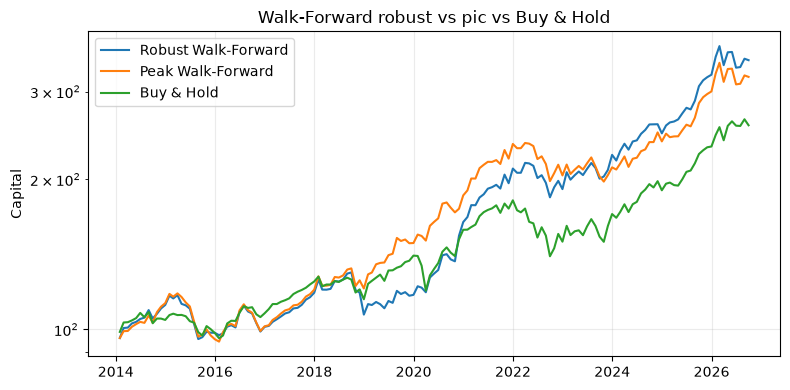

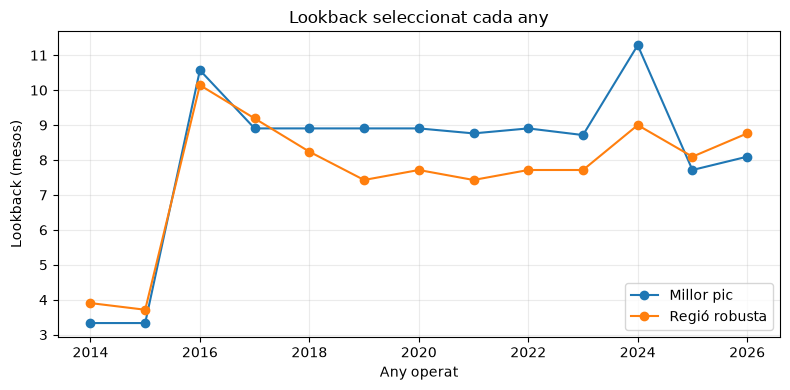

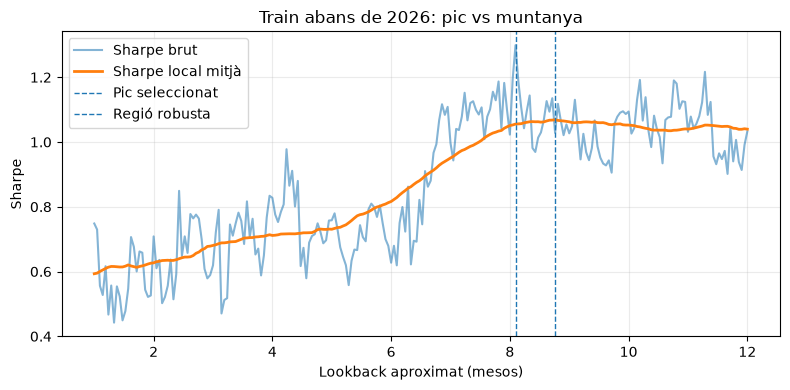

In [38]:
# WALK-FORWARD ROBUST

train_years = 5

# ±1.5 mesos aproximadament
half_neighborhood_days = 32

candidate_lookbacks = range(21, 253)


def train_sharpe_curve(
    returns_by_lb,
    train_start,
    train_end
):

    sharpe_values = {}

    for lookback in candidate_lookbacks:

        train_returns = (
            returns_by_lb[lookback]
            .loc[train_start:train_end]
            .dropna()
        )

        if len(train_returns) < 48:
            continue

        if train_returns.std() == 0:
            continue

        sharpe = (
            train_returns.mean()
            / train_returns.std()
            * np.sqrt(12)
        )

        sharpe_values[lookback] = sharpe

    return pd.Series(
        sharpe_values,
        dtype=float
    ).sort_index()


def robust_score_curve(
    sharpe_curve,
    half_width
):

    robust_score = pd.Series(
        index=sharpe_curve.index,
        dtype=float
    )

    local_std = pd.Series(
        index=sharpe_curve.index,
        dtype=float
    )

    local_min = pd.Series(
        index=sharpe_curve.index,
        dtype=float
    )

    for lookback in sharpe_curve.index:

        neighborhood = sharpe_curve.loc[
            max(
                sharpe_curve.index.min(),
                lookback - half_width
            ):
            min(
                sharpe_curve.index.max(),
                lookback + half_width
            )
        ]

        robust_score.loc[lookback] = (
            neighborhood.mean()
        )

        local_std.loc[lookback] = (
            neighborhood.std()
        )

        local_min.loc[lookback] = (
            neighborhood.min()
        )

    return (
        robust_score,
        local_std,
        local_min
    )


# WALK-FORWARD

robust_rows = []
robust_oos_parts = []

# Guardarem les corbes per poder-les visualitzar després
train_curves = {}


for year in range(
    2014,
    2027
):

    train_start = (
        f"{year - train_years}-01-01"
    )

    train_end = (
        f"{year - 1}-12-31"
    )

    test_start = (
        f"{year}-01-01"
    )

    test_end = (
        f"{year}-12-31"
    )


    # SHARPE DE CADA LOOKBACK EN TRAIN

    sharpe_curve = (
        train_sharpe_curve(
            strategy_returns_by_lb,
            train_start,
            train_end
        )
    )


    # SCORE ROBUST

    (
        robust_score,
        local_std,
        local_min
    ) = robust_score_curve(
        sharpe_curve,
        half_neighborhood_days
    )


    # MILLOR PIC TRADICIONAL

    peak_lb = int(
        sharpe_curve.idxmax()
    )


    # MILLOR MUNTANYA ROBUSTA

    robust_lb = int(
        robust_score.idxmax()
    )


    # OUT-OF-SAMPLE

    test_returns = (
        strategy_returns_by_lb[
            robust_lb
        ]
        .loc[
            test_start:
            test_end
        ]
        .dropna()
    )


    if len(test_returns) == 0:
        continue


    robust_oos_parts.append(
        test_returns
    )


    oos_return = (
        (1 + test_returns).prod()
        - 1
    )


    # MAX DRAWDOWN DEL PARAMETRE SELECCIONAT
    # NOMES COM A DIAGNOSTIC DEL TRAIN

    selected_train_returns = (
        strategy_returns_by_lb[
            robust_lb
        ]
        .loc[
            train_start:
            train_end
        ]
        .dropna()
    )

    selected_train_metrics = (
        performance_metrics_monthly(
            selected_train_returns
        )
    )


    robust_rows.append({

        "Year":
            year,

        "Peak Days":
            peak_lb,

        "Peak Months":
            peak_lb / 21,

        "Robust Days":
            robust_lb,

        "Robust Months":
            robust_lb / 21,

        "Raw Sharpe":
            sharpe_curve.loc[
                robust_lb
            ],

        "Robust Score":
            robust_score.loc[
                robust_lb
            ],

        "Local Std":
            local_std.loc[
                robust_lb
            ],

        "Local Worst Sharpe":
            local_min.loc[
                robust_lb
            ],

        "Train MaxDD":
            selected_train_metrics[
                "Max Drawdown"
            ],

        "OOS Return":
            oos_return
    })


    train_curves[year] = {
        "Sharpe":
            sharpe_curve,

        "Robust Score":
            robust_score,

        "Selected Peak":
            peak_lb,

        "Selected Robust":
            robust_lb
    }


robust_walkforward_df = pd.DataFrame(
    robust_rows
)


# CONCATENEM NOMES ELS RETORNS FUTURS

robust_oos_returns = (
    pd.concat(
        robust_oos_parts
    )
    .sort_index()
)

robust_oos_returns = (
    robust_oos_returns[
        ~robust_oos_returns
        .index
        .duplicated()
    ]
)


# MATEIXES DATES PER TOTES LES ESTRATEGIES

common_oos_index = (
    robust_oos_returns.index
    .intersection(
        oos_strategy_returns.index
    )
)

robust_oos_returns = (
    robust_oos_returns
    .reindex(common_oos_index)
)

peak_oos_returns = (
    oos_strategy_returns
    .reindex(common_oos_index)
)


# BUY AND HOLD DEL MATEIX PERIODE

oos_asset_returns = (
    monthly_returns_fine
    .reindex(common_oos_index)
)

buyhold_sleeves = (
    1 + oos_asset_returns
).cumprod() / len(cs_tickers)

buyhold_equity = (
    buyhold_sleeves.sum(axis=1)
)

buyhold_returns = (
    buyhold_equity
    .pct_change()
)

buyhold_returns.iloc[0] = (
    buyhold_equity.iloc[0]
    - 1
)


# METRIQUES FINALS

robust_metrics = (
    performance_metrics_monthly(
        robust_oos_returns
    )
)

peak_metrics = (
    performance_metrics_monthly(
        peak_oos_returns
    )
)

buyhold_metrics = (
    performance_metrics_monthly(
        buyhold_returns
    )
)


comparison_results = pd.DataFrame([
    {
        "Strategy":
            "Robust Walk-Forward",
        **robust_metrics
    },
    {
        "Strategy":
            "Peak Walk-Forward",
        **peak_metrics
    },
    {
        "Strategy":
            "Buy & Hold",
        **buyhold_metrics
    }
])


# FORMAT TAULA ANUAL

robust_display = (
    robust_walkforward_df.copy()
)


for col in [
    "Peak Months",
    "Robust Months",
    "Raw Sharpe",
    "Robust Score",
    "Local Std",
    "Local Worst Sharpe"
]:

    robust_display[col] = (
        robust_display[col]
        .map(
            lambda x: f"{x:.2f}"
        )
    )


robust_display[
    "Train MaxDD"
] = (
    robust_display[
        "Train MaxDD"
    ] * 100
).map(
    lambda x: f"{x:.2f}%"
)


robust_display[
    "OOS Return"
] = (
    robust_display[
        "OOS Return"
    ] * 100
).map(
    lambda x: f"{x:.2f}%"
)


print(
    "SELECCIO ROBUSTA CADA ANY:"
)

display(
    robust_display
)


# FORMAT RESULTATS TOTALS

comparison_display = (
    comparison_results.copy()
)


for col in [
    "Total Return",
    "CAGR",
    "Volatility",
    "Max Drawdown"
]:

    comparison_display[col] = (
        comparison_display[col] * 100
    ).map(
        lambda x: f"{x:.2f}%"
    )


comparison_display[
    "Sharpe"
] = (
    comparison_display[
        "Sharpe"
    ]
    .map(
        lambda x: f"{x:.2f}"
    )
)


print(
    "\nRESULTAT TOTAL OUT-OF-SAMPLE:"
)

display(
    comparison_display
)


# EQUITY CURVES

robust_equity = (
    1 + robust_oos_returns
).cumprod() * 100

peak_equity = (
    1 + peak_oos_returns
).cumprod() * 100

bh_equity = (
    1 + buyhold_returns
).cumprod() * 100


plt.figure(
    figsize=(8, 4)
)

plt.plot(
    robust_equity,
    label="Robust Walk-Forward"
)

plt.plot(
    peak_equity,
    label="Peak Walk-Forward"
)

plt.plot(
    bh_equity,
    label="Buy & Hold"
)

plt.title(
    "Walk-Forward robust vs pic vs Buy & Hold"
)

plt.ylabel(
    "Capital"
)

plt.yscale(
    "log"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# LOOKBACK ESCOLLIT CADA ANY

plt.figure(
    figsize=(8, 4)
)

plt.plot(
    robust_walkforward_df["Year"],
    robust_walkforward_df["Peak Months"],
    marker="o",
    label="Millor pic"
)

plt.plot(
    robust_walkforward_df["Year"],
    robust_walkforward_df["Robust Months"],
    marker="o",
    label="Regió robusta"
)

plt.title(
    "Lookback seleccionat cada any"
)

plt.xlabel(
    "Any operat"
)

plt.ylabel(
    "Lookback (mesos)"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# EXEMPLE VISUAL DE L'ULTIM TRAIN

example_year = (
    robust_walkforward_df[
        "Year"
    ].iloc[-1]
)

example = (
    train_curves[
        example_year
    ]
)


plt.figure(
    figsize=(8, 4)
)

plt.plot(
    example["Sharpe"].index / 21,
    example["Sharpe"],
    alpha=0.55,
    label="Sharpe brut"
)

plt.plot(
    example["Robust Score"].index / 21,
    example["Robust Score"],
    linewidth=2,
    label="Sharpe local mitjà"
)

plt.axvline(
    example["Selected Peak"] / 21,
    linestyle="--",
    linewidth=1,
    label="Pic seleccionat"
)

plt.axvline(
    example["Selected Robust"] / 21,
    linestyle="--",
    linewidth=1,
    label="Regió robusta"
)

plt.title(
    f"Train abans de {example_year}: pic vs muntanya"
)

plt.xlabel(
    "Lookback aproximat (mesos)"
)

plt.ylabel(
    "Sharpe"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()

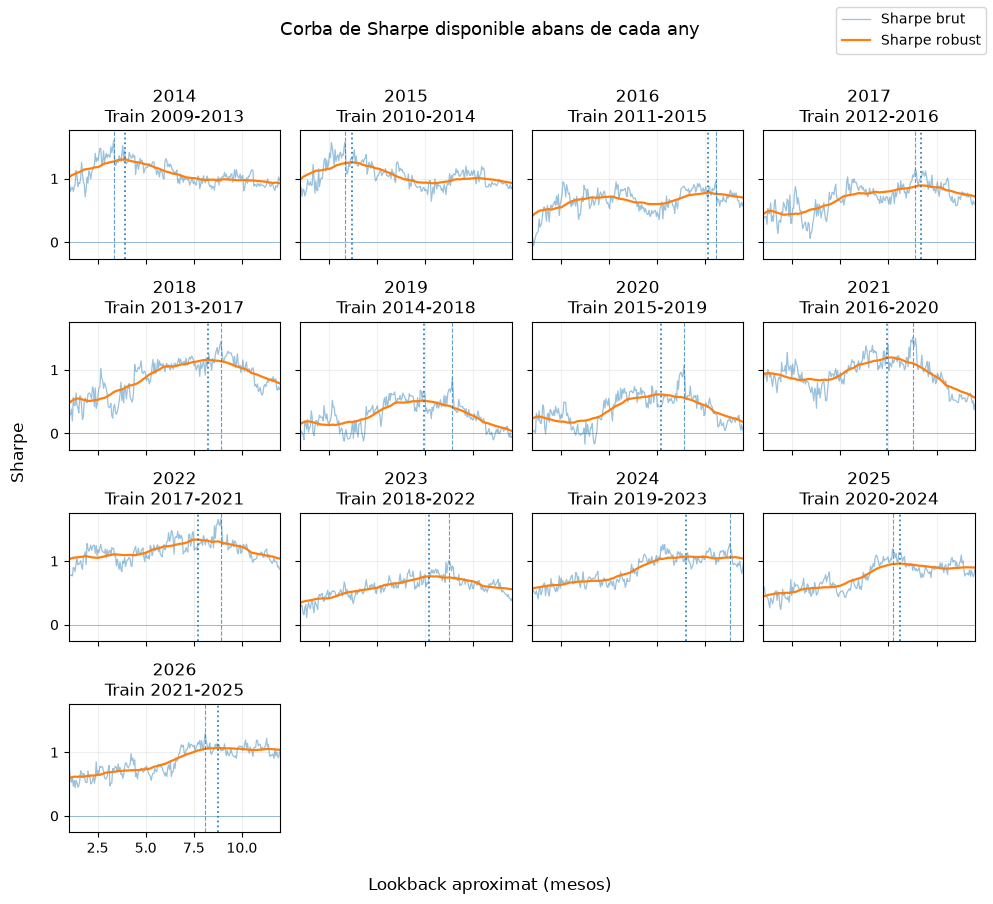

In [39]:
# SHARPE I REGIONS ROBUSTES ABANS DE CADA ANY

years = sorted(
    train_curves.keys()
)

fig, axes = plt.subplots(
    4,
    4,
    figsize=(10, 9),
    sharex=True,
    sharey=True
)

axes = axes.flatten()


for i, year in enumerate(years):

    ax = axes[i]

    data = train_curves[year]

    sharpe_curve = (
        data["Sharpe"]
    )

    robust_curve = (
        data["Robust Score"]
    )

    peak_lb = (
        data["Selected Peak"]
    )

    robust_lb = (
        data["Selected Robust"]
    )


    # SHARPE BRUT

    ax.plot(
        sharpe_curve.index / 21,
        sharpe_curve,
        linewidth=0.9,
        alpha=0.45,
        label="Sharpe brut"
    )


    # SHARPE LOCAL MITJA

    ax.plot(
        robust_curve.index / 21,
        robust_curve,
        linewidth=1.6,
        label="Sharpe robust"
    )


    # MILLOR PIC

    ax.axvline(
        peak_lb / 21,
        linestyle="--",
        linewidth=0.8,
        alpha=0.7
    )


    # CENTRE DE LA MILLOR MUNTANYA

    ax.axvline(
        robust_lb / 21,
        linestyle=":",
        linewidth=1.3,
        alpha=0.9
    )


    # REFERENCIA SHARPE 0

    ax.axhline(
        0,
        linewidth=0.6,
        alpha=0.5
    )


    ax.set_title(
        f"{year}\n"
        f"Train {year - 5}-{year - 1}"
    )

    ax.grid(
        alpha=0.2
    )


# ELIMINEM PANELS SOBRANTS

for j in range(
    len(years),
    len(axes)
):

    axes[j].axis("off")


# EIXOS

for ax in axes:

    if ax.has_data():

        ax.set_xlim(
            1,
            12
        )


fig.supxlabel(
    "Lookback aproximat (mesos)"
)

fig.supylabel(
    "Sharpe"
)


fig.suptitle(
    "Corba de Sharpe disponible abans de cada any",
    fontsize=13
)


# UNA SOLA LLEGENDA

handles, labels = (
    axes[0].get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc="upper right"
)


plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

## 13. Adaptació vs lookback fix

El Walk-Forward Robust recalibra el lookback utilitzant només informació passada.

Però una estratègia adaptativa només està justificada si aporta valor respecte a una regla molt més simple.

Compararem:

- Robust Walk-Forward;
- Peak Walk-Forward;
- lookback fix de 8 mesos;
- lookback fix de 9 mesos;
- Buy & Hold.

Els models fixos no recalibren cap paràmetre.

Per tant, aquesta comparació respon:

$$
\text{adaptació}
\stackrel{?}{>}
\text{regla simple i estable}
$$

Si el model adaptatiu no millora materialment el resultat, la complexitat addicional no estaria justificada.

,Strategy,Total Return,CAGR,Volatility,Sharpe,Max Drawdown
0,Robust Walk-Forward,246.76%,10.24%,12.30%,0.86,-18.36%
1,Peak Walk-Forward,221.02%,9.58%,11.81%,0.84,-19.97%
2,Fixed 8m,281.60%,11.07%,11.66%,0.96,-16.58%
3,Fixed 9m,229.10%,9.79%,11.68%,0.86,-17.70%
4,Buy & Hold,156.74%,7.68%,11.33%,0.71,-22.77%


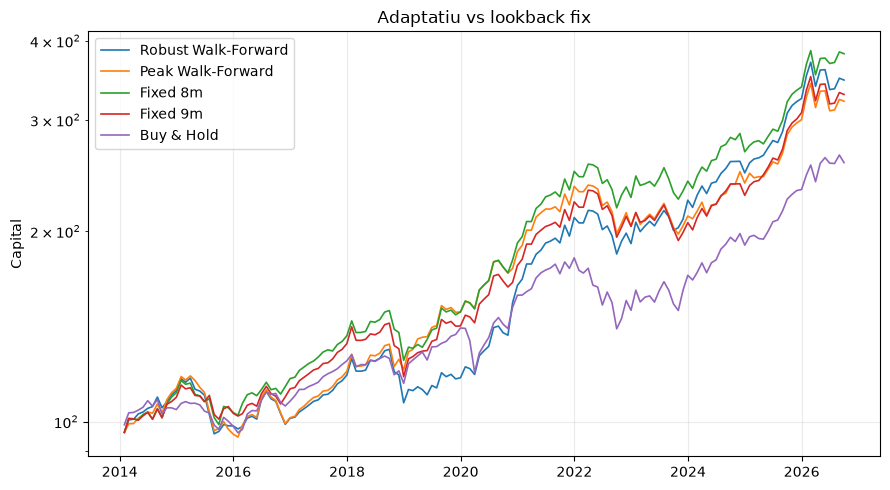

In [40]:
# ADAPTATIU VS LOOKBACK FIX

fixed_lookbacks = {
    "Fixed 8m": 8 * 21,
    "Fixed 9m": 9 * 21
}


comparison_returns = {
    "Robust Walk-Forward":
        robust_oos_returns,

    "Peak Walk-Forward":
        peak_oos_returns
}


# MODELS FIXOS

for name, lookback in fixed_lookbacks.items():

    fixed_returns = (
        strategy_returns_by_lb[
            lookback
        ]
        .reindex(
            common_oos_index
        )
    )

    comparison_returns[
        name
    ] = fixed_returns


# BUY AND HOLD

comparison_returns[
    "Buy & Hold"
] = buyhold_returns


# METRIQUES

fixed_comparison_results = []


for name, returns in comparison_returns.items():

    metrics = (
        performance_metrics_monthly(
            returns
        )
    )

    fixed_comparison_results.append({
        "Strategy":
            name,

        **metrics
    })


fixed_comparison_df = pd.DataFrame(
    fixed_comparison_results
)


# FORMAT

fixed_display = (
    fixed_comparison_df.copy()
)


for col in [
    "Total Return",
    "CAGR",
    "Volatility",
    "Max Drawdown"
]:

    fixed_display[col] = (
        fixed_display[col] * 100
    ).map(
        lambda x: f"{x:.2f}%"
    )


fixed_display[
    "Sharpe"
] = (
    fixed_display[
        "Sharpe"
    ].map(
        lambda x: f"{x:.2f}"
    )
)


display(
    fixed_display
)


# EQUITY CURVES

plt.figure(
    figsize=(9, 5)
)


for name, returns in comparison_returns.items():

    equity = (
        1 + returns
    ).cumprod() * 100

    plt.plot(
        equity,
        label=name,
        linewidth=1.2
    )


plt.title(
    "Adaptatiu vs lookback fix"
)

plt.ylabel(
    "Capital"
)

plt.yscale(
    "log"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()

## 14. Robustesa de la velocitat d'aprenentatge

El model adaptatiu necessita decidir quanta història recent utilitza per seleccionar la regió robusta de momentum.

Compararem tres finestres de train:

$$
3,\ 5,\ 7\ anys
$$

Una finestra curta:

$$
3\ anys
$$

pot reaccionar més ràpid als canvis del mercat, però també és més sensible al soroll.

Una finestra llarga:

$$
7\ anys
$$

produeix estimacions més estables, però pot reaccionar més lentament quan el comportament del mercat canvia.

Per cada finestra:

1. calculem el Sharpe de tots els lookbacks;
2. suavitzem la corba utilitzant un veïnat de $\pm1.5$ mesos;
3. seleccionem la millor regió robusta;
4. congelem el lookback durant l'any següent;
5. concatenem només els retorns out-of-sample.

Els costos es calcularan sobre la seqüència real de pesos utilitzada pel model, inclosos els canvis de lookback entre anys.

Compararem també amb:

- momentum fix de 8 mesos;
- Buy & Hold.

Precalculant models: 100.0% (232/232)
Models precalculats.

Calculant Robust WF amb 3 anys de train...

Calculant Robust WF amb 5 anys de train...

Calculant Robust WF amb 7 anys de train...

RESULTATS:


,Strategy,Total Return,CAGR,Volatility,Sharpe,Max Drawdown
0,Robust WF 3y,208.50%,10.06%,12.78%,0.82,-17.12%
1,Robust WF 5y,210.14%,10.11%,12.57%,0.83,-18.36%
2,Robust WF 7y,167.36%,8.73%,12.58%,0.73,-23.39%
3,Fixed 8m,243.46%,11.07%,11.79%,0.95,-16.58%
4,Buy & Hold,148.81%,8.07%,11.45%,0.74,-21.37%


,Train Years,Avg_Selected_Months,Std_Selected_Months,Min_Selected_Months,Max_Selected_Months,Avg_Robust_Score
0,3,9.45,2.18,6.19,12.00,1.02
1,5,7.93,1.56,3.71,10.14,0.97
2,7,7.13,1.71,4.00,9.24,0.92


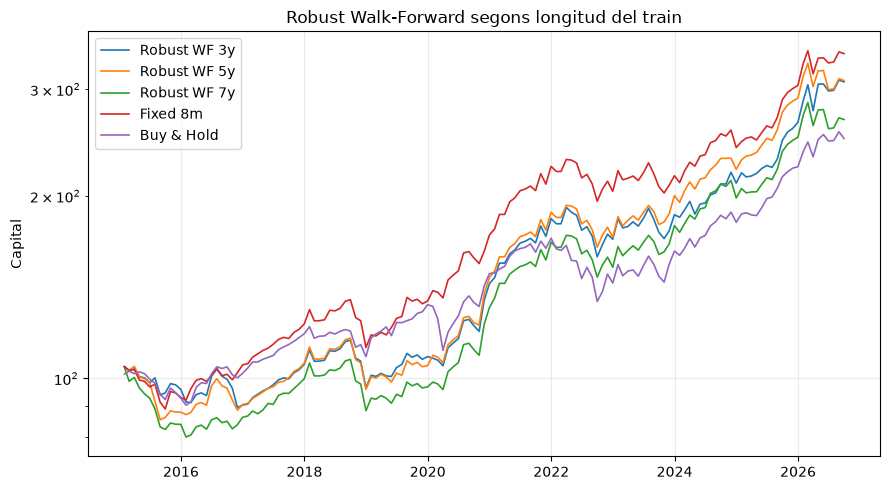

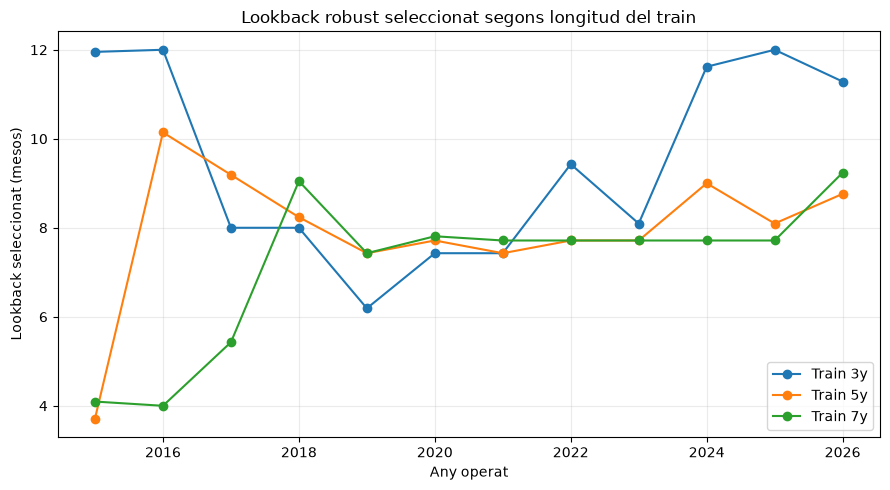

In [41]:
# ROBUST WALK-FORWARD
# COMPARACIO DE 3, 5 I 7 ANYS DE TRAIN
# AMB TURNOVER REAL ENTRE CANVIS DE MODEL

candidate_lookbacks = range(21, 253)

train_windows = [3, 5, 7]

top_n = 3

half_neighborhood_days = 32

cost_bps = 10
cost_rate = cost_bps / 10000

# Per poder comparar tots els models
# utilitzarem exactament els mateixos anys OOS

oos_years = range(2015, 2027)


# ============================================================
# 1. PRECALCULEM PESOS I RETORNS DE CADA LOOKBACK
# ============================================================

weights_by_lb = {}
returns_by_lb = {}

total_tests = len(candidate_lookbacks)


for n, lookback in enumerate(
    candidate_lookbacks,
    start=1
):

    # MOMENTUM DIARI

    momentum_daily = (
        cs_prices
        / cs_prices.shift(lookback)
        - 1
    )


    # VALOR DISPONIBLE A FINAL DE CADA MES

    momentum_monthly = (
        momentum_daily
        .resample("ME")
        .last()
    )


    # RANKING
    # 1 = millor actiu

    ranks = momentum_monthly.rank(
        axis=1,
        ascending=False,
        method="first"
    )


    # TOP 3 A PESOS IGUALS

    weights_signal = (
        ranks <= top_n
    ).astype(float) / top_n


    # UTILITZEM EL SENYAL EL MES SEGÜENT

    weights = (
        weights_signal
        .shift(1)
        .reindex(
            monthly_returns_fine.index
        )
    )


    # DATES VALIDES

    valid = (
        weights.notna().all(axis=1)
        & monthly_returns_fine.notna().all(axis=1)
    )


    # GUARDEM ELS PESOS

    weights_by_lb[
        lookback
    ] = weights


    # RETORN BRUT

    gross_returns = (
        weights
        * monthly_returns_fine
    ).sum(axis=1)


    # TURNOVER DEL MODEL FIX

    turnover = (
        weights
        .diff()
        .abs()
        .sum(axis=1)
        .fillna(0)
    )


    # RETORN NET
    # AIXO S'UTILITZA PER AVALUAR EL TRAIN

    net_returns = (
        gross_returns
        - turnover * cost_rate
    )

    net_returns.loc[
        ~valid
    ] = np.nan


    returns_by_lb[
        lookback
    ] = net_returns


    if (
        n == 1
        or n % 20 == 0
        or n == total_tests
    ):

        print(
            f"\rPrecalculant models: "
            f"{100 * n / total_tests:.1f}% "
            f"({n}/{total_tests})",
            end=""
        )


strategy_returns_by_lb = pd.DataFrame(
    returns_by_lb
)


print("\nModels precalculats.")


# ============================================================
# 2. FUNCIONS
# ============================================================

def get_train_sharpe_curve(
    train_start,
    train_end,
    train_years
):

    sharpe_values = {}

    # Exigim aproximadament el 80% dels mesos esperats

    min_months = int(
        train_years * 12 * 0.80
    )


    for lookback in candidate_lookbacks:

        r = (
            strategy_returns_by_lb[
                lookback
            ]
            .loc[
                train_start:
                train_end
            ]
            .dropna()
        )


        if len(r) < min_months:
            continue


        if r.std() == 0:
            continue


        sharpe = (
            r.mean()
            / r.std()
            * np.sqrt(12)
        )


        sharpe_values[
            lookback
        ] = sharpe


    return pd.Series(
        sharpe_values,
        dtype=float
    ).sort_index()


def get_robust_curve(
    sharpe_curve
):

    robust_score = pd.Series(
        index=sharpe_curve.index,
        dtype=float
    )

    local_std = pd.Series(
        index=sharpe_curve.index,
        dtype=float
    )


    for lookback in sharpe_curve.index:

        left = max(
            sharpe_curve.index.min(),
            lookback
            - half_neighborhood_days
        )

        right = min(
            sharpe_curve.index.max(),
            lookback
            + half_neighborhood_days
        )


        neighborhood = (
            sharpe_curve.loc[
                left:right
            ]
        )


        robust_score.loc[
            lookback
        ] = neighborhood.mean()


        local_std.loc[
            lookback
        ] = neighborhood.std()


    return (
        robust_score,
        local_std
    )


def returns_from_actual_weights(
    weights,
    returns
):

    # RETORN BRUT

    gross = (
        weights * returns
    ).sum(axis=1)


    # TURNOVER REAL
    # INCLOU EL CANVI ENTRE DESEMBRE I GENER
    # SI CANVIA EL LOOKBACK

    turnover = (
        weights
        .diff()
        .abs()
        .sum(axis=1)
        .fillna(0)
    )


    net = (
        gross
        - turnover * cost_rate
    )


    return (
        net,
        turnover
    )


# ============================================================
# 3. WALK-FORWARD PER 3, 5 I 7 ANYS
# ============================================================

adaptive_returns = {}

selection_rows = []


for train_years in train_windows:

    stitched_weights = []

    print(
        f"\nCalculant Robust WF "
        f"amb {train_years} anys de train..."
    )


    for year in oos_years:

        train_start = (
            f"{year - train_years}-01-01"
        )

        train_end = (
            f"{year - 1}-12-31"
        )

        test_start = (
            f"{year}-01-01"
        )

        test_end = (
            f"{year}-12-31"
        )


        # CORBA DE SHARPE DEL TRAIN

        sharpe_curve = (
            get_train_sharpe_curve(
                train_start,
                train_end,
                train_years
            )
        )


        if sharpe_curve.empty:
            continue


        # CORBA ROBUSTA

        (
            robust_curve,
            local_std
        ) = get_robust_curve(
            sharpe_curve
        )


        # LOOKBACK ROBUST

        selected_lb = int(
            robust_curve.idxmax()
        )


        # PESOS QUE REALMENT UTILITZAREM
        # DURANT L'ANY FUTUR

        test_weights = (
            weights_by_lb[
                selected_lb
            ]
            .loc[
                test_start:
                test_end
            ]
            .copy()
        )


        if len(test_weights) == 0:
            continue


        stitched_weights.append(
            test_weights
        )


        selection_rows.append({

            "Train Years":
                train_years,

            "Year":
                year,

            "Selected Days":
                selected_lb,

            "Selected Months":
                selected_lb / 21,

            "Raw Sharpe":
                sharpe_curve.loc[
                    selected_lb
                ],

            "Robust Score":
                robust_curve.loc[
                    selected_lb
                ],

            "Local Std":
                local_std.loc[
                    selected_lb
                ]
        })


    # UNIM TOTS ELS ANYS OOS

    adaptive_weights = (
        pd.concat(
            stitched_weights
        )
        .sort_index()
    )


    adaptive_weights = (
        adaptive_weights[
            ~adaptive_weights
            .index
            .duplicated()
        ]
    )


    # RETORNS DELS ACTIUS
    # EXACTAMENT A LES MATEIXES DATES

    adaptive_asset_returns = (
        monthly_returns_fine
        .reindex(
            adaptive_weights.index
        )
    )


    # RETORN NET
    # AMB TURNOVER REAL

    net_returns, turnover = (
        returns_from_actual_weights(
            adaptive_weights,
            adaptive_asset_returns
        )
    )


    adaptive_returns[
        f"Robust WF {train_years}y"
    ] = net_returns


selection_df = pd.DataFrame(
    selection_rows
)


# ============================================================
# 4. PERIODE COMU
# ============================================================

common_index = None


for returns in adaptive_returns.values():

    idx = returns.dropna().index

    if common_index is None:

        common_index = idx

    else:

        common_index = (
            common_index
            .intersection(idx)
        )


# ============================================================
# 5. FIXED 8 MONTHS
# ============================================================

fixed_8m_lb = 8 * 21

fixed_8m_weights = (
    weights_by_lb[
        fixed_8m_lb
    ]
    .reindex(
        common_index
    )
)


fixed_asset_returns = (
    monthly_returns_fine
    .reindex(
        common_index
    )
)


fixed_8m_returns, _ = (
    returns_from_actual_weights(
        fixed_8m_weights,
        fixed_asset_returns
    )
)


# ============================================================
# 6. BUY AND HOLD
# ============================================================

buyhold_asset_returns = (
    monthly_returns_fine
    .reindex(
        common_index
    )
)


# Capital inicial repartit igualment
# i sense rebalancejar posteriorment

buyhold_sleeves = (
    1 + buyhold_asset_returns
).cumprod() / len(cs_tickers)


buyhold_equity = (
    buyhold_sleeves.sum(axis=1)
)


buyhold_returns = (
    buyhold_equity
    .pct_change()
)


buyhold_returns.iloc[0] = (
    buyhold_equity.iloc[0]
    - 1
)


# ============================================================
# 7. METRIQUES
# ============================================================

all_returns = {}


for name, returns in adaptive_returns.items():

    all_returns[
        name
    ] = returns.reindex(
        common_index
    )


all_returns[
    "Fixed 8m"
] = fixed_8m_returns


all_returns[
    "Buy & Hold"
] = buyhold_returns


results = []


for name, returns in all_returns.items():

    metrics = (
        performance_metrics_monthly(
            returns
        )
    )


    results.append({
        "Strategy":
            name,

        **metrics
    })


results_df = pd.DataFrame(
    results
)


# FORMAT

display_results = (
    results_df.copy()
)


for col in [
    "Total Return",
    "CAGR",
    "Volatility",
    "Max Drawdown"
]:

    display_results[col] = (
        display_results[col] * 100
    ).map(
        lambda x: f"{x:.2f}%"
    )


display_results[
    "Sharpe"
] = (
    display_results[
        "Sharpe"
    ].map(
        lambda x: f"{x:.2f}"
    )
)


print(
    "\nRESULTATS:"
)

display(
    display_results
)


# ============================================================
# 8. ESTABILITAT DEL LOOKBACK ESCOLLIT
# ============================================================

selection_summary = (
    selection_df
    .groupby(
        "Train Years"
    )
    .agg(

        Avg_Selected_Months=(
            "Selected Months",
            "mean"
        ),

        Std_Selected_Months=(
            "Selected Months",
            "std"
        ),

        Min_Selected_Months=(
            "Selected Months",
            "min"
        ),

        Max_Selected_Months=(
            "Selected Months",
            "max"
        ),

        Avg_Robust_Score=(
            "Robust Score",
            "mean"
        )
    )
    .reset_index()
)


display(
    selection_summary.round(2)
)


# ============================================================
# 9. EQUITY CURVES
# ============================================================

plt.figure(
    figsize=(9, 5)
)


for name, returns in all_returns.items():

    equity = (
        1 + returns
    ).cumprod() * 100


    plt.plot(
        equity,
        label=name,
        linewidth=1.2
    )


plt.title(
    "Robust Walk-Forward segons longitud del train"
)

plt.ylabel(
    "Capital"
)

plt.yscale(
    "log"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 10. LOOKBACK ESCOLLIT CADA ANY
# ============================================================

plt.figure(
    figsize=(9, 5)
)


for train_years in train_windows:

    data = (
        selection_df[
            selection_df[
                "Train Years"
            ] == train_years
        ]
    )


    plt.plot(
        data["Year"],
        data["Selected Months"],
        marker="o",
        label=f"Train {train_years}y"
    )


plt.title(
    "Lookback robust seleccionat segons longitud del train"
)

plt.xlabel(
    "Any operat"
)

plt.ylabel(
    "Lookback seleccionat (mesos)"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()

Train 7.00 anys completat
Fet.


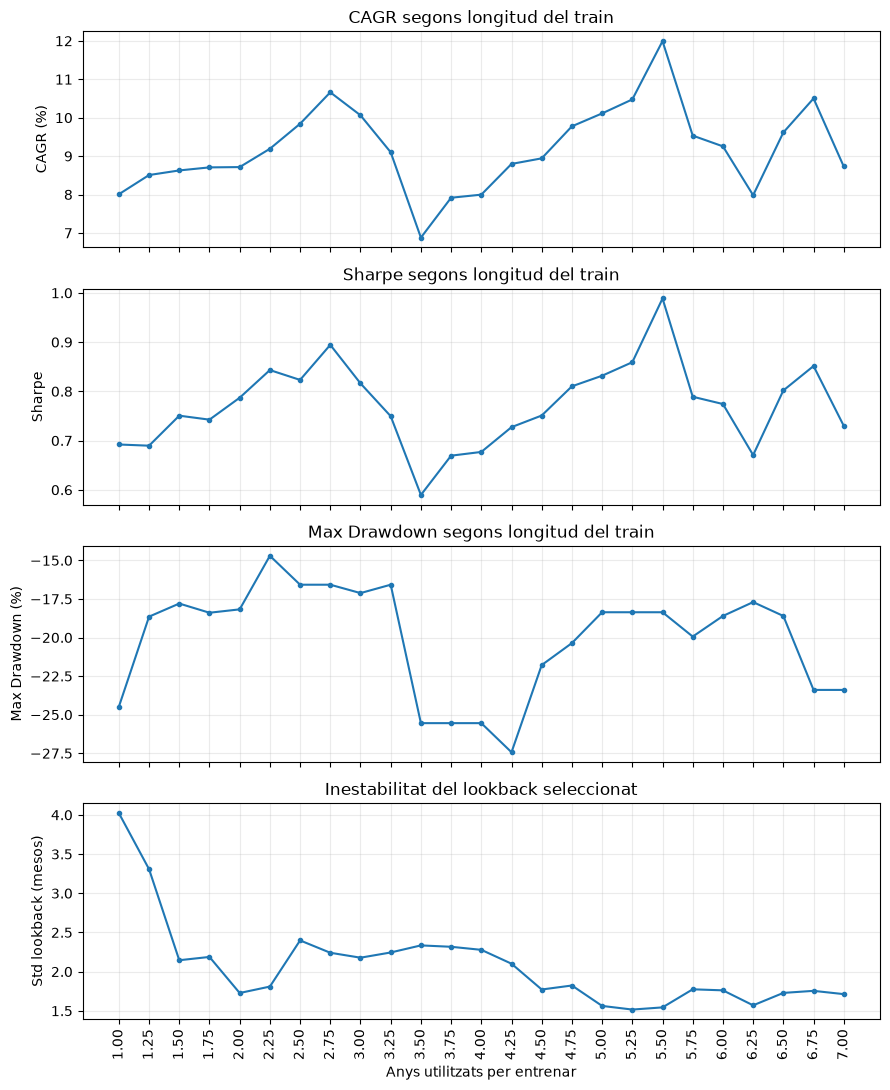

In [42]:
# SENSIBILITAT A LA LONGITUD DEL TRAIN
# 1.00, 1.25, 1.50, ... 7.00 ANYS

train_year_grid = np.arange(
    1.0,
    7.01,
    0.25
)

candidate_lookbacks = range(21, 253)

half_neighborhood_days = 32

cost_bps = 10
cost_rate = cost_bps / 10000

oos_years = range(2015, 2027)


def robust_selection_for_train(
    train_start,
    train_end,
    train_months
):

    sharpe_values = {}

    # Exigim almenys 80% dels mesos previstos
    min_months = int(
        train_months * 0.80
    )

    for lookback in candidate_lookbacks:

        r = (
            strategy_returns_by_lb[lookback]
            .loc[train_start:train_end]
            .dropna()
        )

        if len(r) < min_months:
            continue

        if r.std() == 0:
            continue

        sharpe = (
            r.mean()
            / r.std()
            * np.sqrt(12)
        )

        sharpe_values[
            lookback
        ] = sharpe


    sharpe_curve = pd.Series(
        sharpe_values,
        dtype=float
    ).sort_index()


    if sharpe_curve.empty:
        return None


    robust_curve = pd.Series(
        index=sharpe_curve.index,
        dtype=float
    )


    for lookback in sharpe_curve.index:

        left = max(
            sharpe_curve.index.min(),
            lookback - half_neighborhood_days
        )

        right = min(
            sharpe_curve.index.max(),
            lookback + half_neighborhood_days
        )

        neighborhood = (
            sharpe_curve.loc[left:right]
        )

        robust_curve.loc[
            lookback
        ] = neighborhood.mean()


    selected_lb = int(
        robust_curve.idxmax()
    )


    return {
        "Selected Lookback":
            selected_lb,

        "Robust Score":
            robust_curve.loc[
                selected_lb
            ]
    }


dense_train_returns = {}
dense_train_rows = []


for train_years in train_year_grid:

    train_months = int(
        round(train_years * 12)
    )

    stitched_weights = []


    for year in oos_years:

        test_start = pd.Timestamp(
            f"{year}-01-01"
        )

        test_end = pd.Timestamp(
            f"{year}-12-31"
        )

        # Exemple:
        # 2.25 anys = 27 mesos abans del test
        train_end = (
            test_start
            - pd.Timedelta(days=1)
        )

        train_start = (
            test_start
            - pd.DateOffset(
                months=train_months
            )
        )


        result = (
            robust_selection_for_train(
                train_start,
                train_end,
                train_months
            )
        )


        if result is None:
            continue


        selected_lb = (
            result[
                "Selected Lookback"
            ]
        )


        # PESOS REALS UTILITZATS
        # DURANT L'ANY SEGÜENT

        test_weights = (
            weights_by_lb[
                selected_lb
            ]
            .loc[
                test_start:
                test_end
            ]
            .copy()
        )


        if len(test_weights) == 0:
            continue


        stitched_weights.append(
            test_weights
        )


        dense_train_rows.append({

            "Train Years":
                train_years,

            "Train Months":
                train_months,

            "Year":
                year,

            "Selected Months":
                selected_lb / 21,

            "Robust Score":
                result["Robust Score"]
        })


    if len(stitched_weights) == 0:
        continue


    actual_weights = (
        pd.concat(
            stitched_weights
        )
        .sort_index()
    )

    actual_weights = (
        actual_weights[
            ~actual_weights.index.duplicated()
        ]
    )


    asset_returns = (
        monthly_returns_fine
        .reindex(
            actual_weights.index
        )
    )


    # RETORN BRUT

    gross_returns = (
        actual_weights
        * asset_returns
    ).sum(axis=1)


    # TURNOVER REAL

    turnover = (
        actual_weights
        .diff()
        .abs()
        .sum(axis=1)
        .fillna(0)
    )


    net_returns = (
        gross_returns
        - turnover * cost_rate
    )


    dense_train_returns[
        train_years
    ] = net_returns


    print(
        f"\rTrain {train_years:.2f} anys completat",
        end=""
    )


print("\nFet.")


dense_selection_df = pd.DataFrame(
    dense_train_rows
)


# ============================================================
# MATEIX PERIODE PER TOTES LES FINESTRES
# ============================================================

common_index = None

for r in dense_train_returns.values():

    idx = r.dropna().index

    if common_index is None:
        common_index = idx

    else:
        common_index = (
            common_index
            .intersection(idx)
        )


# ============================================================
# METRIQUES
# ============================================================

dense_results = []


for train_years, returns in dense_train_returns.items():

    r = returns.reindex(
        common_index
    )

    metrics = (
        performance_metrics_monthly(
            r
        )
    )

    selected = (
        dense_selection_df[
            dense_selection_df[
                "Train Years"
            ] == train_years
        ]
    )


    dense_results.append({

        "Train Years":
            train_years,

        "CAGR":
            metrics["CAGR"],

        "Volatility":
            metrics["Volatility"],

        "Sharpe":
            metrics["Sharpe"],

        "Max Drawdown":
            metrics["Max Drawdown"],

        "Avg Selected Months":
            selected[
                "Selected Months"
            ].mean(),

        "Std Selected Months":
            selected[
                "Selected Months"
            ].std()
    })


dense_results_df = pd.DataFrame(
    dense_results
)


# ============================================================
# GRAFICS
# ============================================================

fig, axes = plt.subplots(
    4,
    1,
    figsize=(9, 11),
    sharex=True
)


# CAGR

axes[0].plot(
    dense_results_df["Train Years"],
    dense_results_df["CAGR"] * 100,
    marker="o",
    markersize=3
)

axes[0].set_title(
    "CAGR segons longitud del train"
)

axes[0].set_ylabel(
    "CAGR (%)"
)

axes[0].grid(alpha=0.25)


# SHARPE

axes[1].plot(
    dense_results_df["Train Years"],
    dense_results_df["Sharpe"],
    marker="o",
    markersize=3
)

axes[1].set_title(
    "Sharpe segons longitud del train"
)

axes[1].set_ylabel(
    "Sharpe"
)

axes[1].grid(alpha=0.25)


# MAX DRAWDOWN

axes[2].plot(
    dense_results_df["Train Years"],
    dense_results_df["Max Drawdown"] * 100,
    marker="o",
    markersize=3
)

axes[2].set_title(
    "Max Drawdown segons longitud del train"
)

axes[2].set_ylabel(
    "Max Drawdown (%)"
)

axes[2].grid(alpha=0.25)


# INESTABILITAT DEL PARAMETRE

axes[3].plot(
    dense_results_df["Train Years"],
    dense_results_df["Std Selected Months"],
    marker="o",
    markersize=3
)

axes[3].set_title(
    "Inestabilitat del lookback seleccionat"
)

axes[3].set_xlabel(
    "Anys utilitzats per entrenar"
)

axes[3].set_ylabel(
    "Std lookback (mesos)"
)

axes[3].set_xticks(
    train_year_grid
)

axes[3].tick_params(
    axis="x",
    rotation=90
)

axes[3].grid(alpha=0.25)


plt.tight_layout()
plt.show()

In [43]:
# COMPORTAMENT EN MESOS ALCISTES I BAIXISTES

comparison_index = common_index


# BUY AND HOLD MENSUAL

bh_assets = (
    monthly_returns_fine
    .reindex(comparison_index)
)

bh_sleeves = (
    1 + bh_assets
).cumprod() / len(cs_tickers)

bh_equity = (
    bh_sleeves.sum(axis=1)
)

bh_returns_regime = (
    bh_equity.pct_change()
)

bh_returns_regime.iloc[0] = (
    bh_equity.iloc[0] - 1
)


# FIXED 8M

fixed_8_returns = (
    strategy_returns_by_lb[
        8 * 21
    ]
    .reindex(
        comparison_index
    )
)


# ROBUST 5Y

robust_5_returns = (
    dense_train_returns[
        5.0
    ]
    .reindex(
        comparison_index
    )
)


regime_comparison = pd.DataFrame({

    "Buy & Hold":
        bh_returns_regime,

    "Fixed 8m":
        fixed_8_returns,

    "Robust WF 5y":
        robust_5_returns
})


regime_comparison[
    "Market Regime"
] = np.where(

    regime_comparison[
        "Buy & Hold"
    ] > 0,

    "UP",

    "DOWN"
)


regime_rows = []


for regime in [
    "UP",
    "DOWN"
]:

    data = (
        regime_comparison[
            regime_comparison[
                "Market Regime"
            ] == regime
        ]
    )


    for strategy in [
        "Fixed 8m",
        "Robust WF 5y"
    ]:

        strategy_return = (
            data[strategy].mean()
        )

        bh_return = (
            data["Buy & Hold"].mean()
        )

        excess = (
            strategy_return
            - bh_return
        )


        regime_rows.append({

            "Market Regime":
                regime,

            "Strategy":
                strategy,

            "Avg Strategy Return":
                strategy_return,

            "Avg B&H Return":
                bh_return,

            "Avg Excess Return":
                excess,

            "Months":
                len(data)
        })


regime_results = pd.DataFrame(
    regime_rows
)


regime_display = (
    regime_results.copy()
)


for col in [
    "Avg Strategy Return",
    "Avg B&H Return",
    "Avg Excess Return"
]:

    regime_display[col] = (
        regime_display[col] * 100
    ).map(
        lambda x: f"{x:.2f}%"
    )


display(
    regime_display
)

,Market Regime,Strategy,Avg Strategy Return,Avg B&H Return,Avg Excess Return,Months
0,UP,Fixed 8m,2.56%,2.58%,-0.02%,92
1,UP,Robust WF 5y,2.60%,2.58%,0.02%,92
2,DOWN,Fixed 8m,-2.12%,-2.83%,0.71%,49
3,DOWN,Robust WF 5y,-2.38%,-2.83%,0.45%,49


Millor regió robusta de train:
Centre: 5.25 anys
Sharpe local mitjà: 0.856
Dispersió local: 0.079


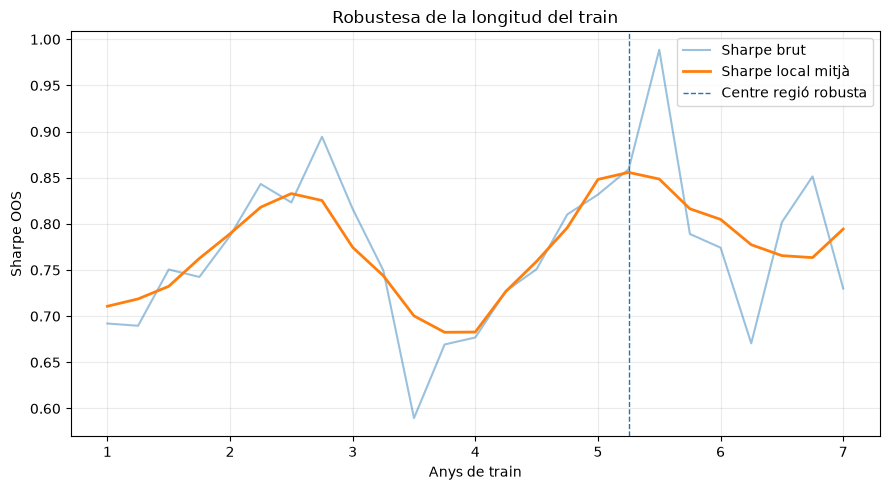

In [44]:
# ROBUSTESA DE LA LONGITUD DEL TRAIN

train_robustness = dense_results_df.copy()

half_window_years = 0.50

robust_train_score = []
local_train_std = []


for train_years in train_robustness["Train Years"]:

    neighborhood = train_robustness[
        (
            train_robustness["Train Years"]
            >= train_years - half_window_years
        )
        &
        (
            train_robustness["Train Years"]
            <= train_years + half_window_years
        )
    ]


    robust_train_score.append(
        neighborhood["Sharpe"].mean()
    )

    local_train_std.append(
        neighborhood["Sharpe"].std()
    )


train_robustness[
    "Robust Train Sharpe"
] = robust_train_score

train_robustness[
    "Local Sharpe Std"
] = local_train_std


# MILLOR MUNTANYA

best_robust_train = (
    train_robustness
    .loc[
        train_robustness[
            "Robust Train Sharpe"
        ].idxmax()
    ]
)


print(
    "Millor regió robusta de train:"
)

print(
    f"Centre: "
    f"{best_robust_train['Train Years']:.2f} anys"
)

print(
    f"Sharpe local mitjà: "
    f"{best_robust_train['Robust Train Sharpe']:.3f}"
)

print(
    f"Dispersió local: "
    f"{best_robust_train['Local Sharpe Std']:.3f}"
)


# GRAFIC

plt.figure(figsize=(9, 5))

plt.plot(
    train_robustness["Train Years"],
    train_robustness["Sharpe"],
    alpha=0.45,
    label="Sharpe brut"
)

plt.plot(
    train_robustness["Train Years"],
    train_robustness["Robust Train Sharpe"],
    linewidth=2,
    label="Sharpe local mitjà"
)

plt.axvline(
    best_robust_train["Train Years"],
    linestyle="--",
    linewidth=1,
    label="Centre regió robusta"
)

plt.title(
    "Robustesa de la longitud del train"
)

plt.xlabel(
    "Anys de train"
)

plt.ylabel(
    "Sharpe OOS"
)

plt.grid(alpha=0.25)

plt.legend()

plt.tight_layout()

plt.show()

Longituds de train: 61
Finestra de suavitzat: 11 punts
Calculant trains: 100.0% (61/61)
Fet.

Centre de la millor regió segons Sharpe suavitzat:
2.50 anys
Sharpe exacte: 0.823
Sharpe local mitjà: 0.872
CAGR local mitjà: 10.09%
MaxDD local mitjà: -16.18%
Inestabilitat local mitjana: 2.06 mesos


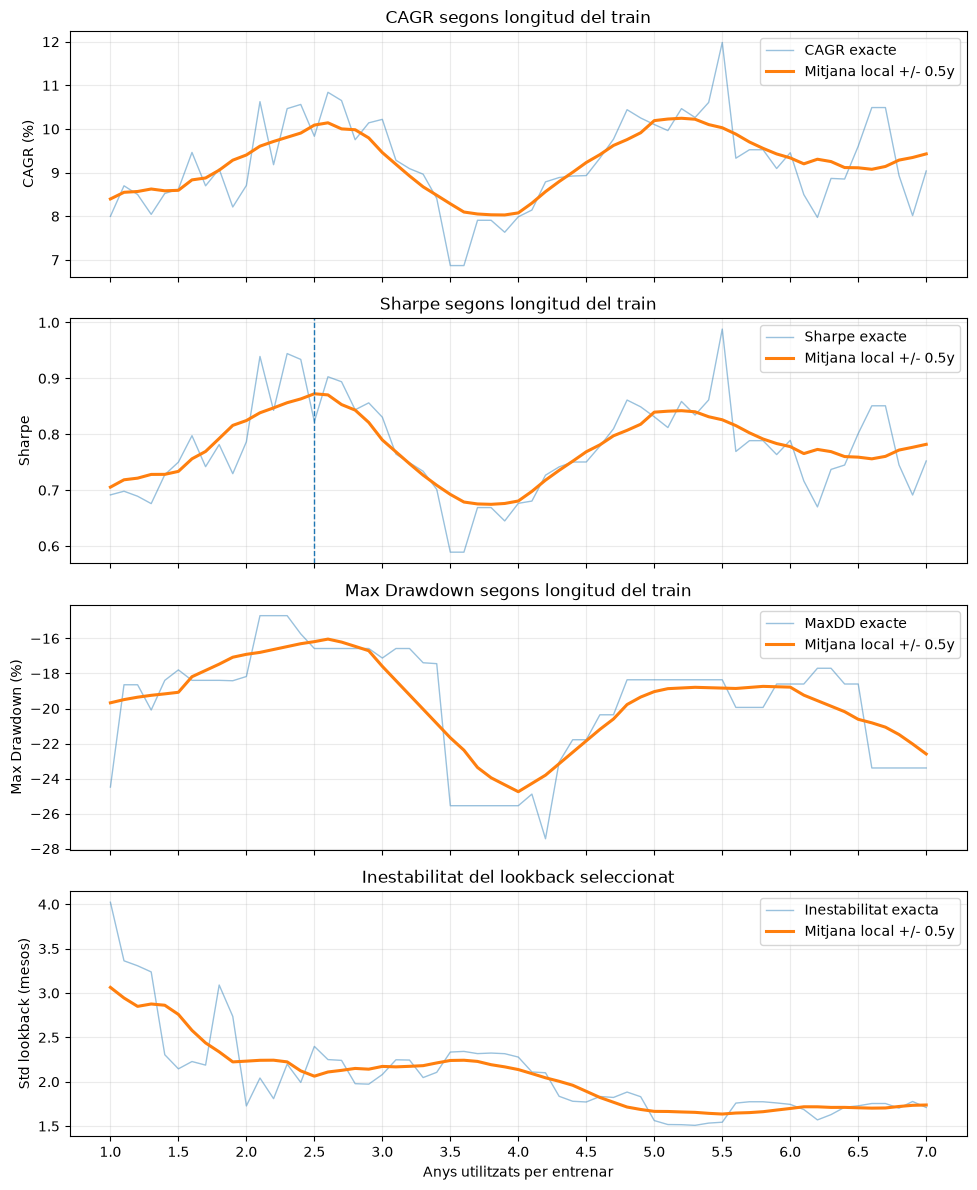

In [45]:
# SENSIBILITAT FINA A LA LONGITUD DEL TRAIN
# 1.0, 1.1, 1.2, ... 7.0 ANYS
#
# Per cada longitud calculem:
# - CAGR
# - Sharpe
# - Max Drawdown
# - Inestabilitat del lookback seleccionat
#
# I afegim una mitjana local de +/- 0.5 anys.


# ============================================================
# PARAMETRES
# ============================================================

train_step = 0.10

train_year_grid = np.round(
    np.arange(
        1.0,
        7.0 + train_step,
        train_step
    ),
    2
)

candidate_lookbacks = range(
    21,
    253
)

top_n = 3

half_neighborhood_days = 32

cost_bps = 10
cost_rate = cost_bps / 10000

oos_years = range(
    2015,
    2027
)


# SUAVITZAT DELS RESULTATS FINALS

smooth_half_width_years = 0.50

smooth_window_points = int(
    round(
        2 * smooth_half_width_years
        / train_step
    )
) + 1


print(
    "Longituds de train:",
    len(train_year_grid)
)

print(
    "Finestra de suavitzat:",
    smooth_window_points,
    "punts"
)


# ============================================================
# FUNCIO:
# SELECCIO ROBUSTA DEL LOOKBACK DINS DEL TRAIN
# ============================================================

def robust_selection_for_train(
    train_start,
    train_end,
    train_years
):

    # Agafem tots els models alhora

    train_data = (
        strategy_returns_by_lb
        .loc[
            train_start:
            train_end
        ]
    )


    # Nombre minim de mesos exigits

    expected_months = (
        train_years * 12
    )

    min_months = int(
        np.ceil(
            expected_months * 0.80
        )
    )


    # Quantes observacions tenim
    # per cada lookback

    counts = (
        train_data.count()
    )


    # SHARPE VECTORITZAT

    means = (
        train_data.mean()
    )

    stds = (
        train_data.std()
    )

    sharpe_curve = (
        means
        / stds
        * np.sqrt(12)
    )


    # ELIMINEM MODELS
    # AMB MASSA POCA INFORMACIO

    sharpe_curve = (
        sharpe_curve[
            counts >= min_months
        ]
        .dropna()
        .sort_index()
    )


    if sharpe_curve.empty:

        return None


    # ========================================================
    # MITJANA LOCAL DEL SHARPE
    #
    # +/- 32 dies de lookback
    # ========================================================

    robust_curve = (
        sharpe_curve
        .rolling(
            window=65,
            center=True,
            min_periods=33
        )
        .mean()
    )


    local_std = (
        sharpe_curve
        .rolling(
            window=65,
            center=True,
            min_periods=33
        )
        .std()
    )


    robust_curve = (
        robust_curve.dropna()
    )


    if robust_curve.empty:

        return None


    # CENTRE DE LA MILLOR MUNTANYA

    selected_lb = int(
        robust_curve.idxmax()
    )


    return {

        "Selected Lookback":
            selected_lb,

        "Raw Sharpe":
            sharpe_curve.loc[
                selected_lb
            ],

        "Robust Score":
            robust_curve.loc[
                selected_lb
            ],

        "Local Std":
            local_std.loc[
                selected_lb
            ]
    }


# ============================================================
# FUNCIO:
# RETORN REAL A PARTIR DELS PESOS CONCATENATS
# ============================================================

def returns_from_actual_weights(
    weights,
    asset_returns
):

    gross_returns = (
        weights
        * asset_returns
    ).sum(axis=1)


    # TURNOVER REAL
    #
    # Inclou canvis entre anys
    # quan el lookback seleccionat canvia

    turnover = (
        weights
        .diff()
        .abs()
        .sum(axis=1)
    )


    # Cost inicial d'entrar a la cartera

    if len(turnover) > 0:

        turnover.iloc[0] = (
            weights
            .iloc[0]
            .abs()
            .sum()
        )


    net_returns = (
        gross_returns
        - turnover * cost_rate
    )


    return (
        net_returns,
        turnover
    )


# ============================================================
# CALCUL DE TOTES LES LONGITUDS DE TRAIN
# ============================================================

dense_train_returns = {}

selection_rows = []


total_train_tests = len(
    train_year_grid
)


for test_number, train_years in enumerate(
    train_year_grid,
    start=1
):

    # Utilitzem dies de calendari
    # per tenir realment passos de 0.1 anys

    train_days = int(
        round(
            train_years
            * 365.25
        )
    )


    stitched_weights = []


    for year in oos_years:

        test_start = pd.Timestamp(
            f"{year}-01-01"
        )

        test_end = pd.Timestamp(
            f"{year}-12-31"
        )


        train_end = (
            test_start
            - pd.Timedelta(days=1)
        )


        train_start = (
            test_start
            - pd.Timedelta(
                days=train_days
            )
        )


        # SELECCIO ROBUSTA

        selection = (
            robust_selection_for_train(
                train_start,
                train_end,
                train_years
            )
        )


        if selection is None:
            continue


        selected_lb = int(
            selection[
                "Selected Lookback"
            ]
        )


        # PESOS QUE REALMENT UTILITZAREM
        # DURANT L'ANY FUTUR

        test_weights = (
            weights_by_lb[
                selected_lb
            ]
            .loc[
                test_start:
                test_end
            ]
            .copy()
        )


        if len(test_weights) == 0:
            continue


        stitched_weights.append(
            test_weights
        )


        selection_rows.append({

            "Train Years":
                train_years,

            "Year":
                year,

            "Selected Days":
                selected_lb,

            "Selected Months":
                selected_lb / 21,

            "Raw Sharpe":
                selection[
                    "Raw Sharpe"
                ],

            "Robust Score":
                selection[
                    "Robust Score"
                ],

            "Local Std":
                selection[
                    "Local Std"
                ]
        })


    # ========================================================
    # CONCATENEM LA CARTERA REAL OOS
    # ========================================================

    if len(stitched_weights) == 0:

        continue


    actual_weights = (
        pd.concat(
            stitched_weights
        )
        .sort_index()
    )


    actual_weights = (
        actual_weights[
            ~actual_weights
            .index
            .duplicated()
        ]
    )


    asset_returns = (
        monthly_returns_fine
        .reindex(
            actual_weights.index
        )
    )


    net_returns, turnover = (
        returns_from_actual_weights(
            actual_weights,
            asset_returns
        )
    )


    dense_train_returns[
        train_years
    ] = net_returns


    print(
        f"\rCalculant trains: "
        f"{100 * test_number / total_train_tests:.1f}% "
        f"({test_number}/{total_train_tests})",
        end=""
    )


print(
    "\nFet."
)


selection_df_dense = pd.DataFrame(
    selection_rows
)


# ============================================================
# PERIODE COMU PER TOTS ELS MODELS
# ============================================================

common_index = None


for returns in dense_train_returns.values():

    valid_index = (
        returns
        .dropna()
        .index
    )


    if common_index is None:

        common_index = (
            valid_index
        )

    else:

        common_index = (
            common_index
            .intersection(
                valid_index
            )
        )


# ============================================================
# METRIQUES DE CADA LONGITUD DE TRAIN
# ============================================================

dense_results = []


for train_years, returns in (
    dense_train_returns.items()
):

    r = (
        returns
        .reindex(
            common_index
        )
    )


    metrics = (
        performance_metrics_monthly(
            r
        )
    )


    selections = (
        selection_df_dense[
            selection_df_dense[
                "Train Years"
            ] == train_years
        ]
    )


    dense_results.append({

        "Train Years":
            train_years,

        "CAGR":
            metrics[
                "CAGR"
            ],

        "Volatility":
            metrics[
                "Volatility"
            ],

        "Sharpe":
            metrics[
                "Sharpe"
            ],

        "Max Drawdown":
            metrics[
                "Max Drawdown"
            ],

        "Avg Selected Months":
            selections[
                "Selected Months"
            ].mean(),

        "Std Selected Months":
            selections[
                "Selected Months"
            ].std(),

        "Avg Robust Score":
            selections[
                "Robust Score"
            ].mean()
    })


dense_results_df = (
    pd.DataFrame(
        dense_results
    )
    .sort_values(
        "Train Years"
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# SUAVITZAT FINAL
#
# +/- 0.5 ANYS
# ============================================================

metrics_to_smooth = [
    "CAGR",
    "Sharpe",
    "Max Drawdown",
    "Std Selected Months"
]


for metric in metrics_to_smooth:

    dense_results_df[
        f"Smooth {metric}"
    ] = (
        dense_results_df[
            metric
        ]
        .rolling(
            window=smooth_window_points,
            center=True,
            min_periods=(
                smooth_window_points // 2
                + 1
            )
        )
        .mean()
    )


# ============================================================
# MILLOR REGIO SEGONS SHARPE SUAVITZAT
# ============================================================

valid_smooth = (
    dense_results_df[
        "Smooth Sharpe"
    ].dropna()
)


best_idx = (
    valid_smooth.idxmax()
)


best_region = (
    dense_results_df
    .loc[
        best_idx
    ]
)


print(
    "\nCentre de la millor regió "
    "segons Sharpe suavitzat:"
)

print(
    f"{best_region['Train Years']:.2f} anys"
)

print(
    f"Sharpe exacte: "
    f"{best_region['Sharpe']:.3f}"
)

print(
    f"Sharpe local mitjà: "
    f"{best_region['Smooth Sharpe']:.3f}"
)

print(
    f"CAGR local mitjà: "
    f"{best_region['Smooth CAGR'] * 100:.2f}%"
)

print(
    f"MaxDD local mitjà: "
    f"{best_region['Smooth Max Drawdown'] * 100:.2f}%"
)

print(
    f"Inestabilitat local mitjana: "
    f"{best_region['Smooth Std Selected Months']:.2f} mesos"
)


# ============================================================
# GRAFICS
# ============================================================

fig, axes = plt.subplots(
    4,
    1,
    figsize=(10, 12),
    sharex=True
)


# ------------------------------------------------------------
# 1. CAGR
# ------------------------------------------------------------

axes[0].plot(
    dense_results_df[
        "Train Years"
    ],
    dense_results_df[
        "CAGR"
    ] * 100,
    linewidth=1,
    alpha=0.45,
    label="CAGR exacte"
)


axes[0].plot(
    dense_results_df[
        "Train Years"
    ],
    dense_results_df[
        "Smooth CAGR"
    ] * 100,
    linewidth=2.2,
    label="Mitjana local +/- 0.5y"
)


axes[0].set_title(
    "CAGR segons longitud del train"
)

axes[0].set_ylabel(
    "CAGR (%)"
)

axes[0].grid(
    alpha=0.25
)

axes[0].legend()


# ------------------------------------------------------------
# 2. SHARPE
# ------------------------------------------------------------

axes[1].plot(
    dense_results_df[
        "Train Years"
    ],
    dense_results_df[
        "Sharpe"
    ],
    linewidth=1,
    alpha=0.45,
    label="Sharpe exacte"
)


axes[1].plot(
    dense_results_df[
        "Train Years"
    ],
    dense_results_df[
        "Smooth Sharpe"
    ],
    linewidth=2.2,
    label="Mitjana local +/- 0.5y"
)


axes[1].axvline(
    best_region[
        "Train Years"
    ],
    linestyle="--",
    linewidth=1
)


axes[1].set_title(
    "Sharpe segons longitud del train"
)

axes[1].set_ylabel(
    "Sharpe"
)

axes[1].grid(
    alpha=0.25
)

axes[1].legend()


# ------------------------------------------------------------
# 3. MAX DRAWDOWN
# ------------------------------------------------------------

axes[2].plot(
    dense_results_df[
        "Train Years"
    ],
    dense_results_df[
        "Max Drawdown"
    ] * 100,
    linewidth=1,
    alpha=0.45,
    label="MaxDD exacte"
)


axes[2].plot(
    dense_results_df[
        "Train Years"
    ],
    dense_results_df[
        "Smooth Max Drawdown"
    ] * 100,
    linewidth=2.2,
    label="Mitjana local +/- 0.5y"
)


axes[2].set_title(
    "Max Drawdown segons longitud del train"
)

axes[2].set_ylabel(
    "Max Drawdown (%)"
)

axes[2].grid(
    alpha=0.25
)

axes[2].legend()


# ------------------------------------------------------------
# 4. INESTABILITAT DEL LOOKBACK
# ------------------------------------------------------------

axes[3].plot(
    dense_results_df[
        "Train Years"
    ],
    dense_results_df[
        "Std Selected Months"
    ],
    linewidth=1,
    alpha=0.45,
    label="Inestabilitat exacta"
)


axes[3].plot(
    dense_results_df[
        "Train Years"
    ],
    dense_results_df[
        "Smooth Std Selected Months"
    ],
    linewidth=2.2,
    label="Mitjana local +/- 0.5y"
)


axes[3].set_title(
    "Inestabilitat del lookback seleccionat"
)

axes[3].set_xlabel(
    "Anys utilitzats per entrenar"
)

axes[3].set_ylabel(
    "Std lookback (mesos)"
)

axes[3].grid(
    alpha=0.25
)

axes[3].legend()


# X AXIS

axes[3].set_xticks(
    np.arange(
        1,
        7.01,
        0.5
    )
)


plt.tight_layout()

plt.show()

## 17. Dues regions robustes de train

L'anàlisi de sensibilitat mostra dues regions interessants:

$$
2.2-3.0\ anys
$$

i

$$
4.7-5.5\ anys
$$

En lloc de seleccionar una longitud de train exacta, tractarem cada regió com un conjunt de models.

Per cada any out-of-sample:

1. provarem totes les longituds de train de la regió en passos de 0.1 anys;
2. cada train seleccionarà la seva regió robusta de lookback;
3. prendrem la mediana dels lookbacks seleccionats;
4. congelarem aquest lookback durant l'any següent.

Això redueix dues fonts de risc de paràmetre:

$$
\text{train window risk}
$$

i

$$
\text{momentum lookback risk}
$$

Compararem:

- Muntanya curta: 2.2–3.0 anys;
- Muntanya llarga: 4.7–5.5 anys;
- momentum fix de 8 mesos;
- Buy & Hold.

RESULTATS:


,Strategy,Total Return,CAGR,Volatility,Sharpe,Max Drawdown
0,Short Train 2.2-3.0y,223.14%,10.50%,11.82%,0.91,-16.58%
1,Long Train 4.7-5.5y,223.91%,10.52%,12.73%,0.85,-18.36%
2,Fixed 8m,243.13%,11.06%,11.78%,0.95,-16.58%
3,Buy & Hold,148.81%,8.07%,11.45%,0.74,-21.37%



ESTABILITAT:


,Mountain,Avg_Consensus_Months,Std_Consensus_Months,Avg_Internal_Dispersion,Avg_Robust_Score
0,Long Train 4.7-5.5y,7.77,1.51,0.29,0.96
1,Short Train 2.2-3.0y,9.33,2.06,0.62,1.00


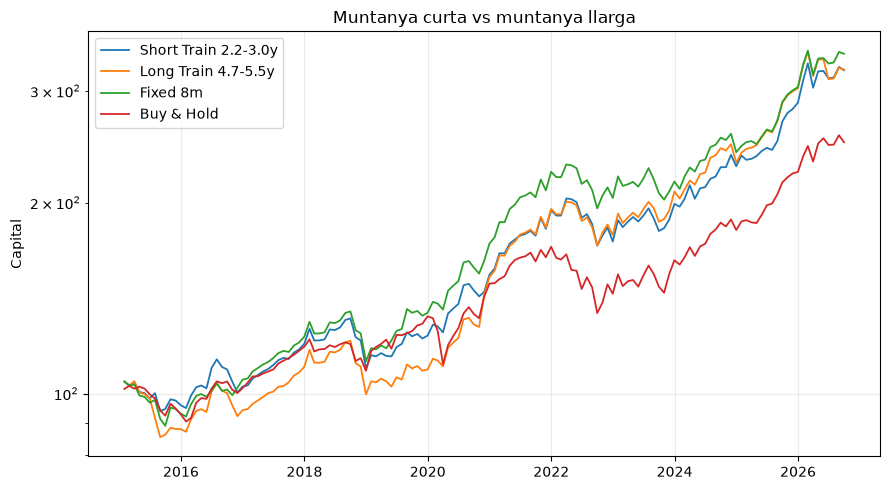

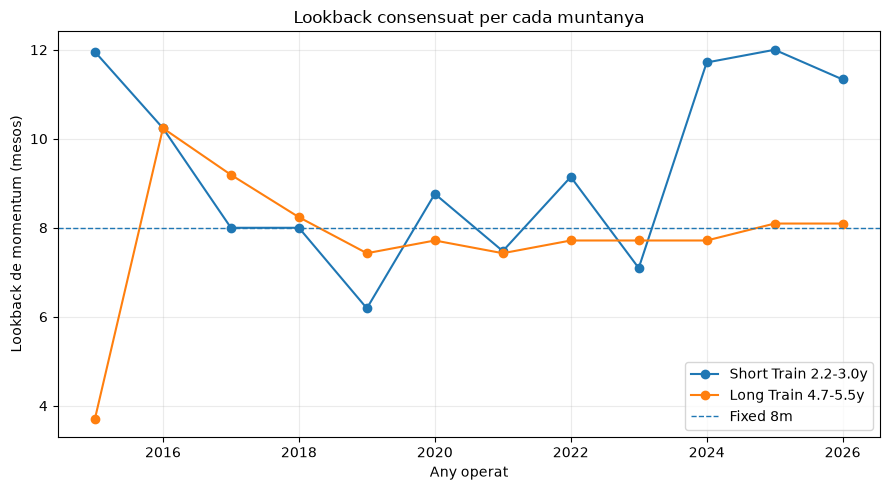

In [46]:
# DUES MUNTANYES ROBUSTES DE TRAIN
#
# Mountain Short: 2.2 - 3.0 anys
# Mountain Long : 4.7 - 5.5 anys
#
# Dins de cada muntanya:
# - provem trains cada 0.1 anys
# - cada train selecciona un lookback robust
# - utilitzem la MEDIANA dels lookbacks seleccionats
# - operem l'any següent


# ============================================================
# PARAMETRES
# ============================================================

train_mountains = {

    "Short Train 2.2-3.0y":
        np.round(
            np.arange(
                2.2,
                3.01,
                0.1
            ),
            1
        ),

    "Long Train 4.7-5.5y":
        np.round(
            np.arange(
                4.7,
                5.51,
                0.1
            ),
            1
        )
}


candidate_lookbacks = range(
    21,
    253
)

half_neighborhood_days = 32

cost_bps = 10
cost_rate = cost_bps / 10000

oos_years = range(
    2015,
    2027
)


# ============================================================
# SELECCIO ROBUSTA PER UNA LONGITUD DE TRAIN
# ============================================================

def select_robust_lookback(
    year,
    train_years
):

    test_start = pd.Timestamp(
        f"{year}-01-01"
    )


    train_end = (
        test_start
        - pd.Timedelta(days=1)
    )


    train_days = int(
        round(
            train_years
            * 365.25
        )
    )


    train_start = (
        test_start
        - pd.Timedelta(
            days=train_days
        )
    )


    # TOTS ELS LOOKBACKS ALHORA

    train_data = (
        strategy_returns_by_lb
        .loc[
            train_start:
            train_end
        ]
    )


    expected_months = (
        train_years * 12
    )

    min_months = int(
        np.ceil(
            expected_months
            * 0.80
        )
    )


    counts = (
        train_data.count()
    )

    means = (
        train_data.mean()
    )

    stds = (
        train_data.std()
    )


    sharpe_curve = (
        means
        / stds
        * np.sqrt(12)
    )


    sharpe_curve = (
        sharpe_curve[
            counts >= min_months
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .dropna()
        .sort_index()
    )


    if sharpe_curve.empty:

        return None


    # MUNTANYA ROBUSTA DEL LOOKBACK

    robust_curve = (
        sharpe_curve
        .rolling(
            window=65,
            center=True,
            min_periods=33
        )
        .mean()
        .dropna()
    )


    if robust_curve.empty:

        return None


    selected_lb = int(
        robust_curve.idxmax()
    )


    return {

        "Lookback":
            selected_lb,

        "Robust Score":
            robust_curve.loc[
                selected_lb
            ]
    }


# ============================================================
# CONSTRUCCIO DE CADA MUNTANYA
# ============================================================

mountain_returns = {}

mountain_selection_rows = []


for mountain_name, train_grid in (
    train_mountains.items()
):

    yearly_weights = []


    for year in oos_years:

        selected_lbs = []
        robust_scores = []


        # TOTS ELS TRAINS DE LA MUNTANYA

        for train_years in train_grid:

            result = (
                select_robust_lookback(
                    year,
                    train_years
                )
            )


            if result is None:
                continue


            selected_lbs.append(
                result["Lookback"]
            )

            robust_scores.append(
                result["Robust Score"]
            )


        if len(selected_lbs) == 0:
            continue


        # ====================================================
        # CONSENSUS DE LA MUNTANYA
        # ====================================================

        consensus_lb = int(
            round(
                np.median(
                    selected_lbs
                )
            )
        )


        selected_months = (
            np.array(
                selected_lbs
            )
            / 21
        )


        dispersion_months = (
            selected_months.std(
                ddof=1
            )
            if len(
                selected_months
            ) > 1
            else 0
        )


        # ====================================================
        # PESOS OOS DE L'ANY
        # ====================================================

        test_start = (
            f"{year}-01-01"
        )

        test_end = (
            f"{year}-12-31"
        )


        test_weights = (
            weights_by_lb[
                consensus_lb
            ]
            .loc[
                test_start:
                test_end
            ]
            .copy()
        )


        if len(test_weights) == 0:
            continue


        yearly_weights.append(
            test_weights
        )


        mountain_selection_rows.append({

            "Mountain":
                mountain_name,

            "Year":
                year,

            "Consensus Days":
                consensus_lb,

            "Consensus Months":
                consensus_lb / 21,

            "Mean Selected Months":
                selected_months.mean(),

            "Std Across Train Windows":
                dispersion_months,

            "Min Selected Months":
                selected_months.min(),

            "Max Selected Months":
                selected_months.max(),

            "Avg Robust Score":
                np.mean(
                    robust_scores
                )
        })


    # ========================================================
    # CONCATENEM ELS PESOS REALMENT OPERATS
    # ========================================================

    actual_weights = (
        pd.concat(
            yearly_weights
        )
        .sort_index()
    )


    actual_weights = (
        actual_weights[
            ~actual_weights
            .index
            .duplicated()
        ]
    )


    asset_returns = (
        monthly_returns_fine
        .reindex(
            actual_weights.index
        )
    )


    gross_returns = (
        actual_weights
        * asset_returns
    ).sum(axis=1)


    # TURNOVER REAL

    turnover = (
        actual_weights
        .diff()
        .abs()
        .sum(axis=1)
    )


    # COST INICIAL

    if len(turnover) > 0:

        turnover.iloc[0] = (
            actual_weights
            .iloc[0]
            .abs()
            .sum()
        )


    net_returns = (
        gross_returns
        - turnover
        * cost_rate
    )


    mountain_returns[
        mountain_name
    ] = net_returns


mountain_selection_df = pd.DataFrame(
    mountain_selection_rows
)


# ============================================================
# PERIODE COMU
# ============================================================

common_index = None


for r in mountain_returns.values():

    idx = (
        r.dropna().index
    )


    if common_index is None:

        common_index = idx

    else:

        common_index = (
            common_index
            .intersection(
                idx
            )
        )


# ============================================================
# FIXED 8 MONTHS
# ============================================================

fixed_8_lb = (
    8 * 21
)


fixed_weights = (
    weights_by_lb[
        fixed_8_lb
    ]
    .reindex(
        common_index
    )
)


asset_returns_common = (
    monthly_returns_fine
    .reindex(
        common_index
    )
)


fixed_gross = (
    fixed_weights
    * asset_returns_common
).sum(axis=1)


fixed_turnover = (
    fixed_weights
    .diff()
    .abs()
    .sum(axis=1)
)


fixed_turnover.iloc[0] = (
    fixed_weights
    .iloc[0]
    .abs()
    .sum()
)


fixed_8_returns = (
    fixed_gross
    - fixed_turnover
    * cost_rate
)


# ============================================================
# BUY AND HOLD
# ============================================================

buyhold_sleeves = (
    1
    + asset_returns_common
).cumprod() / len(cs_tickers)


buyhold_equity = (
    buyhold_sleeves.sum(axis=1)
)


buyhold_returns = (
    buyhold_equity
    .pct_change()
)


buyhold_returns.iloc[0] = (
    buyhold_equity.iloc[0]
    - 1
)


# ============================================================
# METRIQUES
# ============================================================

all_returns = {}


for name, r in (
    mountain_returns.items()
):

    all_returns[
        name
    ] = r.reindex(
        common_index
    )


all_returns[
    "Fixed 8m"
] = fixed_8_returns


all_returns[
    "Buy & Hold"
] = buyhold_returns


results = []


for name, r in (
    all_returns.items()
):

    metrics = (
        performance_metrics_monthly(
            r
        )
    )


    results.append({

        "Strategy":
            name,

        **metrics
    })


results_df = pd.DataFrame(
    results
)


display_results = (
    results_df.copy()
)


for col in [
    "Total Return",
    "CAGR",
    "Volatility",
    "Max Drawdown"
]:

    display_results[col] = (
        display_results[col]
        * 100
    ).map(
        lambda x: f"{x:.2f}%"
    )


display_results[
    "Sharpe"
] = (
    display_results[
        "Sharpe"
    ].map(
        lambda x: f"{x:.2f}"
    )
)


print(
    "RESULTATS:"
)

display(
    display_results
)


# ============================================================
# RESUM DE LES SELECCIONS
# ============================================================

selection_summary = (
    mountain_selection_df
    .groupby(
        "Mountain"
    )
    .agg(

        Avg_Consensus_Months=(
            "Consensus Months",
            "mean"
        ),

        Std_Consensus_Months=(
            "Consensus Months",
            "std"
        ),

        Avg_Internal_Dispersion=(
            "Std Across Train Windows",
            "mean"
        ),

        Avg_Robust_Score=(
            "Avg Robust Score",
            "mean"
        )
    )
    .reset_index()
)


print(
    "\nESTABILITAT:"
)

display(
    selection_summary.round(2)
)


# ============================================================
# EQUITY CURVES
# ============================================================

plt.figure(
    figsize=(9, 5)
)


for name, r in (
    all_returns.items()
):

    equity = (
        1 + r
    ).cumprod() * 100


    plt.plot(
        equity,
        label=name,
        linewidth=1.3
    )


plt.title(
    "Muntanya curta vs muntanya llarga"
)

plt.ylabel(
    "Capital"
)

plt.yscale(
    "log"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# LOOKBACK SELECCIONAT CADA ANY
# ============================================================

plt.figure(
    figsize=(9, 5)
)


for mountain_name in (
    train_mountains.keys()
):

    data = (
        mountain_selection_df[
            mountain_selection_df[
                "Mountain"
            ] == mountain_name
        ]
    )


    plt.plot(
        data["Year"],
        data["Consensus Months"],
        marker="o",
        label=mountain_name
    )


plt.axhline(
    8,
    linestyle="--",
    linewidth=1,
    label="Fixed 8m"
)


plt.title(
    "Lookback consensuat per cada muntanya"
)

plt.xlabel(
    "Any operat"
)

plt.ylabel(
    "Lookback de momentum (mesos)"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()

## 18. Consens entre els tres models

Disposem de tres models:

1. Short Train 2.2–3.0 anys;
2. Long Train 4.7–5.5 anys;
3. Fixed 8 mesos.

Cada model genera mensualment un ranking dels 8 actius i selecciona els seus Top 3.

Estudiarem si el grau d'acord entre els tres models conté informació predictiva.

Distingirem:

- mateix Top 3 i mateix ordre;
- mateix Top 3 però ordre diferent;
- 2 actius comuns als tres models;
- 1 actiu comú;
- cap actiu comú.

També construirem un ranking de consens:

$$
ConsensusRank_i
=
\frac{
Rank_i^{Short}
+
Rank_i^{Long}
+
Rank_i^{Fixed}
}{3}
$$

Els 3 actius amb menor ConsensusRank formen el Top 3 de consens.

Per cada senyal observarem el retorn del mes següent.

Mesurarem:

- retorn mitjà posterior;
- percentatge de mesos positius;
- retorn respecte Buy & Hold;
- nombre d'observacions.

L'objectiu és comprovar si:

$$
\text{més acord}
\rightarrow
\text{millor rendiment futur}
$$

abans de construir una nova estratègia.

Lookbacks precalculats: 17
Mesos analitzats: 141

RESULTATS SEGONS TIPUS D'ACORD:


,Months,Avg_Return,Median_Return,Hit_Rate,Avg_BH_Return,Avg_Excess
Agreement Type,,,,,,
3 iguals + mateix ordre,37,0.60%,0.54%,64.86%,0.39%,0.21%
3 iguals + ordre diferent,30,1.19%,0.60%,60.00%,1.31%,-0.12%
2 actius comuns,60,0.83%,1.46%,66.67%,0.49%,0.34%
1 actiu comu,10,2.78%,4.21%,70.00%,1.56%,1.22%
0 actius comuns,4,0.62%,0.52%,75.00%,0.15%,0.47%



RESULTATS SEGONS FORCA DEL CONSENS:


,Months,Avg_Consensus_Return,Consensus_Hit_Rate,Avg_Unanimous_Return,Unanimous_Hit_Rate,Avg_Excess
Common Assets,,,,,,
0,4,0.62%,75.00%,-,-,0.47%
1,10,2.78%,70.00%,3.67%,90.00%,1.22%
2,60,0.83%,66.67%,0.99%,68.33%,0.34%
3,67,0.86%,62.69%,0.86%,62.69%,0.06%


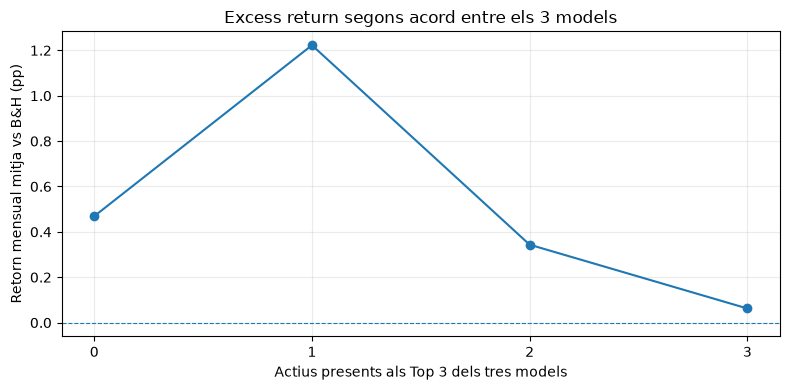

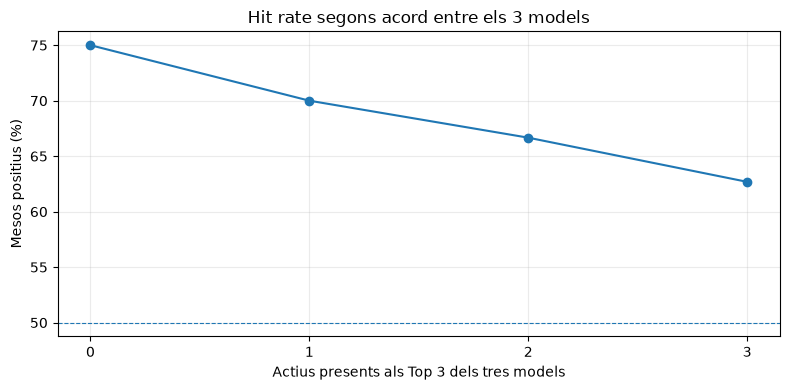

,Return Month,Short Top3,Long Top3,Fixed Top3,Agreement Type,Consensus Top3,Consensus Return,B&H Return
121,2025-02-28,"(GLD, SPY, IWM)","(GLD, VNQ, SPY)","(GLD, SPY, VNQ)",2 actius comuns,"(GLD, SPY, VNQ)",0.014173,0.004399
122,2025-03-31,"(GLD, SPY, VNQ)","(GLD, VNQ, SPY)","(GLD, VNQ, SPY)",3 iguals + ordre diferent,"(GLD, VNQ, SPY)",0.004290,-0.007960
123,2025-04-30,"(GLD, VNQ, EEM)","(GLD, EEM, VNQ)","(GLD, DBC, EEM)",2 actius comuns,"(GLD, EEM, VNQ)",0.010403,-0.002696
124,2025-05-31,"(GLD, VNQ, EFA)","(GLD, EFA, EEM)","(GLD, EFA, EEM)",2 actius comuns,"(GLD, EFA, EEM)",0.029188,0.030411
125,2025-06-30,"(GLD, VNQ, EFA)","(GLD, EFA, SPY)","(GLD, EFA, SPY)",2 actius comuns,"(GLD, EFA, SPY)",0.026466,0.035019
126,2025-07-31,"(GLD, EFA, EEM)","(GLD, EFA, EEM)","(GLD, EFA, EEM)",3 iguals + mateix ordre,"(GLD, EFA, EEM)",-0.006807,0.006327
127,2025-08-31,"(GLD, EEM, SPY)","(GLD, EFA, EEM)","(GLD, EFA, EEM)",2 actius comuns,"(GLD, EEM, EFA)",0.040631,0.033475
128,2025-09-30,"(GLD, EEM, SPY)","(GLD, EFA, EEM)","(GLD, EFA, EEM)",2 actius comuns,"(GLD, EEM, EFA)",0.069748,0.045167
129,2025-10-31,"(GLD, SPY, EEM)","(GLD, EEM, EFA)","(GLD, EEM, EFA)",2 actius comuns,"(GLD, EEM, EFA)",0.027721,0.018786
130,2025-11-30,"(GLD, EEM, EFA)","(GLD, EEM, EFA)","(GLD, EEM, IWM)",2 actius comuns,"(GLD, EEM, EFA)",0.014455,0.013963


In [47]:
# CONSENS ENTRE SHORT TRAIN, LONG TRAIN I FIXED 8M


# ============================================================
# 1. LOOKBACK UTILITZAT PER CADA MODEL I ANY
# ============================================================

short_name = "Short Train 2.2-3.0y"
long_name = "Long Train 4.7-5.5y"

fixed_lb = 8 * 21


short_lb_by_year = (
    mountain_selection_df[
        mountain_selection_df["Mountain"]
        == short_name
    ]
    .set_index("Year")[
        "Consensus Days"
    ]
    .astype(int)
)


long_lb_by_year = (
    mountain_selection_df[
        mountain_selection_df["Mountain"]
        == long_name
    ]
    .set_index("Year")[
        "Consensus Days"
    ]
    .astype(int)
)


# ============================================================
# 2. PRECALCULEM RANKINGS MENSUALS
# ============================================================

needed_lookbacks = sorted(
    set(
        short_lb_by_year.tolist()
        + long_lb_by_year.tolist()
        + [fixed_lb]
    )
)


rank_cache = {}


for lookback in needed_lookbacks:

    momentum_daily = (
        cs_prices
        / cs_prices.shift(lookback)
        - 1
    )

    momentum_monthly = (
        momentum_daily
        .resample("ME")
        .last()
    )

    ranks = (
        momentum_monthly
        .rank(
            axis=1,
            ascending=False,
            method="first"
        )
    )

    rank_cache[
        lookback
    ] = ranks


print(
    "Lookbacks precalculats:",
    len(needed_lookbacks)
)


# ============================================================
# 3. ANALISI MES A MES
# ============================================================

agreement_rows = []

all_month_dates = (
    monthly_returns_fine.index
)

month_position = {
    date: i
    for i, date
    in enumerate(all_month_dates)
}


for return_date in common_index:

    year = return_date.year


    if (
        year not in short_lb_by_year.index
        or year not in long_lb_by_year.index
    ):
        continue


    pos = month_position.get(
        return_date,
        None
    )


    if (
        pos is None
        or pos == 0
    ):
        continue


    # El senyal del mes anterior
    # s'utilitza durant aquest mes

    signal_date = (
        all_month_dates[
            pos - 1
        ]
    )


    short_lb = int(
        short_lb_by_year.loc[
            year
        ]
    )

    long_lb = int(
        long_lb_by_year.loc[
            year
        ]
    )


    # ========================================================
    # RANKINGS DELS TRES MODELS
    # ========================================================

    short_rank = (
        rank_cache[
            short_lb
        ]
        .loc[
            signal_date
        ]
        .dropna()
    )


    long_rank = (
        rank_cache[
            long_lb
        ]
        .loc[
            signal_date
        ]
        .dropna()
    )


    fixed_rank = (
        rank_cache[
            fixed_lb
        ]
        .loc[
            signal_date
        ]
        .dropna()
    )


    if (
        len(short_rank) < 3
        or len(long_rank) < 3
        or len(fixed_rank) < 3
    ):
        continue


    # TOP 3 ORDENAT

    short_top3 = tuple(
        short_rank
        .sort_values()
        .index[:3]
    )

    long_top3 = tuple(
        long_rank
        .sort_values()
        .index[:3]
    )

    fixed_top3 = tuple(
        fixed_rank
        .sort_values()
        .index[:3]
    )


    short_set = set(
        short_top3
    )

    long_set = set(
        long_top3
    )

    fixed_set = set(
        fixed_top3
    )


    # ========================================================
    # NIVELL D'ACORD
    # ========================================================

    exact_order = (
        short_top3
        == long_top3
        == fixed_top3
    )


    same_three = (
        short_set
        == long_set
        == fixed_set
    )


    common_assets = (
        short_set
        & long_set
        & fixed_set
    )

    common_count = len(
        common_assets
    )


    if exact_order:

        agreement_type = (
            "3 iguals + mateix ordre"
        )

    elif same_three:

        agreement_type = (
            "3 iguals + ordre diferent"
        )

    elif common_count == 2:

        agreement_type = (
            "2 actius comuns"
        )

    elif common_count == 1:

        agreement_type = (
            "1 actiu comu"
        )

    else:

        agreement_type = (
            "0 actius comuns"
        )


    # ========================================================
    # RANKING DE CONSENS
    #
    # Borda-style:
    # fem la mitjana dels tres rankings
    # ========================================================

    rank_matrix = pd.concat(
        [
            short_rank.rename(
                "Short"
            ),
            long_rank.rename(
                "Long"
            ),
            fixed_rank.rename(
                "Fixed"
            )
        ],
        axis=1
    )


    consensus_rank = (
        rank_matrix.mean(
            axis=1
        )
    )


    consensus_top3 = tuple(
        consensus_rank
        .sort_values()
        .index[:3]
    )


    # ========================================================
    # RETORNS DEL MES SEGÜENT
    # ========================================================

    next_returns = (
        monthly_returns_fine
        .loc[
            return_date
        ]
    )


    consensus_return = (
        next_returns[
            list(
                consensus_top3
            )
        ].mean()
    )


    # Retorn dels actius en què
    # TOTS TRES estan d'acord

    if common_count > 0:

        unanimous_return = (
            next_returns[
                list(
                    common_assets
                )
            ].mean()
        )

    else:

        unanimous_return = np.nan


    # Retorn individual
    # de cadascun dels tres Top 3

    short_return = (
        next_returns[
            list(
                short_top3
            )
        ].mean()
    )

    long_return = (
        next_returns[
            list(
                long_top3
            )
        ].mean()
    )

    fixed_return = (
        next_returns[
            list(
                fixed_top3
            )
        ].mean()
    )


    # BUY AND HOLD REAL
    # del nostre backtest

    if return_date in (
        buyhold_returns.index
    ):

        bh_return = (
            buyhold_returns.loc[
                return_date
            ]
        )

    else:

        bh_return = (
            next_returns.mean()
        )


    agreement_rows.append({

        "Signal Date":
            signal_date,

        "Return Month":
            return_date,

        "Short Lookback":
            short_lb / 21,

        "Long Lookback":
            long_lb / 21,

        "Short Top3":
            short_top3,

        "Long Top3":
            long_top3,

        "Fixed Top3":
            fixed_top3,

        "Agreement Type":
            agreement_type,

        "Common Assets":
            common_count,

        "Exact Order":
            exact_order,

        "Same Three":
            same_three,

        "Consensus Top3":
            consensus_top3,

        "Consensus Return":
            consensus_return,

        "Unanimous Return":
            unanimous_return,

        "Short Return":
            short_return,

        "Long Return":
            long_return,

        "Fixed Return":
            fixed_return,

        "B&H Return":
            bh_return,

        "Consensus Excess":
            consensus_return
            - bh_return
    })


agreement_df = pd.DataFrame(
    agreement_rows
)


print(
    "Mesos analitzats:",
    len(agreement_df)
)


# ============================================================
# 4. RESULTATS PER TIPUS D'ACORD
# ============================================================

agreement_order = [

    "3 iguals + mateix ordre",

    "3 iguals + ordre diferent",

    "2 actius comuns",

    "1 actiu comu",

    "0 actius comuns"
]


agreement_summary = (
    agreement_df
    .groupby(
        "Agreement Type"
    )
    .agg(

        Months=(
            "Consensus Return",
            "count"
        ),

        Avg_Return=(
            "Consensus Return",
            "mean"
        ),

        Median_Return=(
            "Consensus Return",
            "median"
        ),

        Hit_Rate=(
            "Consensus Return",
            lambda x:
                (x > 0).mean()
        ),

        Avg_BH_Return=(
            "B&H Return",
            "mean"
        ),

        Avg_Excess=(
            "Consensus Excess",
            "mean"
        )
    )
    .reindex(
        agreement_order
    )
    .dropna(
        how="all"
    )
)


agreement_display = (
    agreement_summary.copy()
)


for col in [
    "Avg_Return",
    "Median_Return",
    "Hit_Rate",
    "Avg_BH_Return",
    "Avg_Excess"
]:

    agreement_display[col] = (
        agreement_display[col]
        * 100
    ).map(
        lambda x: f"{x:.2f}%"
    )


print(
    "\nRESULTATS SEGONS TIPUS D'ACORD:"
)

display(
    agreement_display
)


# ============================================================
# 5. RESULTATS SEGONS NOMBRE D'ACTIUS
#    EN QUÈ ELS 3 MODELS COINCIDEIXEN
# ============================================================

common_summary = (
    agreement_df
    .groupby(
        "Common Assets"
    )
    .agg(

        Months=(
            "Consensus Return",
            "count"
        ),

        Avg_Consensus_Return=(
            "Consensus Return",
            "mean"
        ),

        Consensus_Hit_Rate=(
            "Consensus Return",
            lambda x:
                (x > 0).mean()
        ),

        Avg_Unanimous_Return=(
            "Unanimous Return",
            "mean"
        ),

        Unanimous_Hit_Rate=(
            "Unanimous Return",
            lambda x:
                (x.dropna() > 0).mean()
                if x.notna().any()
                else np.nan
        ),

        Avg_Excess=(
            "Consensus Excess",
            "mean"
        )
    )
)


common_display = (
    common_summary.copy()
)


for col in [
    "Avg_Consensus_Return",
    "Consensus_Hit_Rate",
    "Avg_Unanimous_Return",
    "Unanimous_Hit_Rate",
    "Avg_Excess"
]:

    common_display[col] = (
        common_display[col]
        * 100
    ).map(
        lambda x:
            f"{x:.2f}%"
            if pd.notna(x)
            else "-"
    )


print(
    "\nRESULTATS SEGONS FORCA DEL CONSENS:"
)

display(
    common_display
)


# ============================================================
# 6. GRAFIC:
#    EXCESS RETURN SEGONS ACORD
# ============================================================

plot_common = (
    common_summary
    .reset_index()
)


plt.figure(
    figsize=(8, 4)
)


plt.plot(
    plot_common[
        "Common Assets"
    ],
    plot_common[
        "Avg_Excess"
    ] * 100,
    marker="o"
)


plt.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)


plt.title(
    "Excess return segons acord entre els 3 models"
)

plt.xlabel(
    "Actius presents als Top 3 dels tres models"
)

plt.ylabel(
    "Retorn mensual mitja vs B&H (pp)"
)

plt.xticks(
    [0, 1, 2, 3]
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# 7. GRAFIC:
#    PROBABILITAT DE MES POSITIU
# ============================================================

plt.figure(
    figsize=(8, 4)
)


plt.plot(
    plot_common[
        "Common Assets"
    ],
    plot_common[
        "Consensus_Hit_Rate"
    ] * 100,
    marker="o"
)


plt.axhline(
    50,
    linestyle="--",
    linewidth=0.8
)


plt.title(
    "Hit rate segons acord entre els 3 models"
)

plt.xlabel(
    "Actius presents als Top 3 dels tres models"
)

plt.ylabel(
    "Mesos positius (%)"
)

plt.xticks(
    [0, 1, 2, 3]
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# 8. EXEMPLES RECENTS
# ============================================================

display(
    agreement_df[
        [
            "Return Month",
            "Short Top3",
            "Long Top3",
            "Fixed Top3",
            "Agreement Type",
            "Consensus Top3",
            "Consensus Return",
            "B&H Return"
        ]
    ]
    .tail(20)
)

,Months,Avg_Return,Median_Return,Hit_Rate,Avg_Excess
Votes,,,,,
0,141,0.49%,0.65%,58.16%,-0.21%
1,68,0.69%,0.96%,57.35%,0.19%
2,71,0.76%,1.27%,63.38%,0.13%
3,137,1.13%,1.12%,67.15%,0.42%


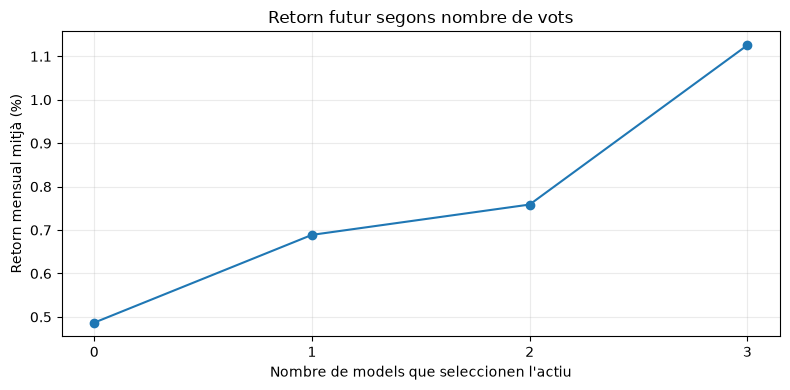

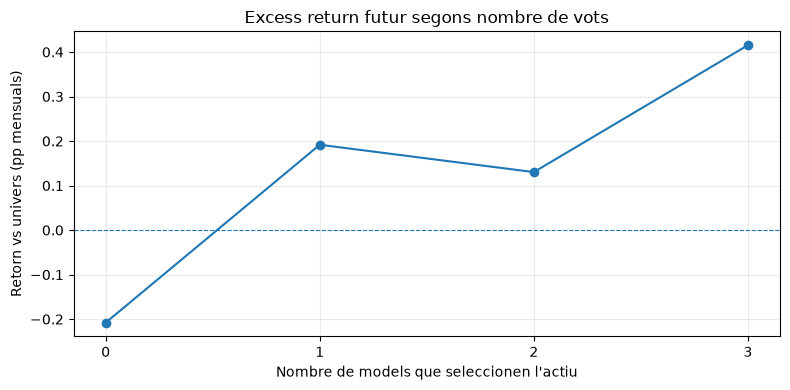

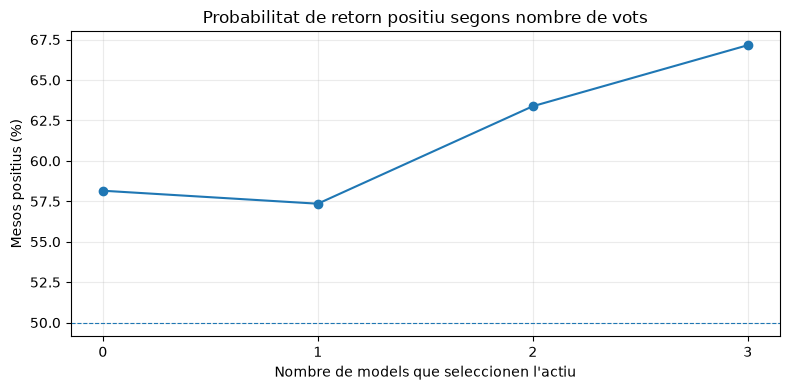

In [48]:
# ============================================================
# ANALISI PER ACTIU:
# 0, 1, 2 O 3 VOTS DELS MODELS
# ============================================================

asset_vote_rows = []


for _, row in agreement_df.iterrows():

    return_month = row[
        "Return Month"
    ]

    short_set = set(
        row["Short Top3"]
    )

    long_set = set(
        row["Long Top3"]
    )

    fixed_set = set(
        row["Fixed Top3"]
    )


    # RETORNS DE TOTS ELS ACTIUS
    # DURANT EL MES SEGÜENT

    next_returns = (
        monthly_returns_fine
        .loc[
            return_month
        ]
    )


    # RETORN MITJÀ DE TOT L'UNIVERS
    # COM A REFERÈNCIA

    universe_return = (
        next_returns[
            cs_tickers
        ].mean()
    )


    for ticker in cs_tickers:

        votes = (
            int(
                ticker in short_set
            )
            +
            int(
                ticker in long_set
            )
            +
            int(
                ticker in fixed_set
            )
        )


        asset_return = (
            next_returns[
                ticker
            ]
        )


        asset_vote_rows.append({

            "Return Month":
                return_month,

            "Ticker":
                ticker,

            "Votes":
                votes,

            "Asset Return":
                asset_return,

            "Universe Return":
                universe_return,

            "Excess Return":
                asset_return
                - universe_return
        })


asset_votes_df = pd.DataFrame(
    asset_vote_rows
)


# ============================================================
# PORTFOLIO MENSUAL PER NOMBRE DE VOTS
#
# Per exemple:
# tots els actius amb 3 vots
# formen un petit portfolio igualment ponderat.
# ============================================================

vote_monthly = (
    asset_votes_df
    .groupby(
        [
            "Return Month",
            "Votes"
        ]
    )
    .agg(

        Portfolio_Return=(
            "Asset Return",
            "mean"
        ),

        N_Assets=(
            "Ticker",
            "count"
        ),

        Universe_Return=(
            "Universe Return",
            "first"
        )
    )
    .reset_index()
)


vote_monthly[
    "Excess Return"
] = (
    vote_monthly[
        "Portfolio_Return"
    ]
    -
    vote_monthly[
        "Universe_Return"
    ]
)


# ============================================================
# RESUM
# ============================================================

vote_summary = (
    vote_monthly
    .groupby(
        "Votes"
    )
    .agg(

        Months=(
            "Portfolio_Return",
            "count"
        ),

        Avg_Return=(
            "Portfolio_Return",
            "mean"
        ),

        Median_Return=(
            "Portfolio_Return",
            "median"
        ),

        Hit_Rate=(
            "Portfolio_Return",
            lambda x:
                (x > 0).mean()
        ),

        Avg_Excess=(
            "Excess Return",
            "mean"
        )
    )
)


vote_display = (
    vote_summary.copy()
)


for col in [
    "Avg_Return",
    "Median_Return",
    "Hit_Rate",
    "Avg_Excess"
]:

    vote_display[col] = (
        vote_display[col]
        * 100
    ).map(
        lambda x:
            f"{x:.2f}%"
    )


display(
    vote_display
)


# ============================================================
# GRAFIC 1:
# RETORN SEGONS NOMBRE DE VOTS
# ============================================================

plot_votes = (
    vote_summary
    .reset_index()
)


plt.figure(
    figsize=(8, 4)
)

plt.plot(
    plot_votes["Votes"],
    plot_votes["Avg_Return"] * 100,
    marker="o"
)

plt.title(
    "Retorn futur segons nombre de vots"
)

plt.xlabel(
    "Nombre de models que seleccionen l'actiu"
)

plt.ylabel(
    "Retorn mensual mitjà (%)"
)

plt.xticks(
    [0, 1, 2, 3]
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# GRAFIC 2:
# EXCESS RETURN SEGONS VOTS
# ============================================================

plt.figure(
    figsize=(8, 4)
)

plt.plot(
    plot_votes["Votes"],
    plot_votes["Avg_Excess"] * 100,
    marker="o"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)

plt.title(
    "Excess return futur segons nombre de vots"
)

plt.xlabel(
    "Nombre de models que seleccionen l'actiu"
)

plt.ylabel(
    "Retorn vs univers (pp mensuals)"
)

plt.xticks(
    [0, 1, 2, 3]
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# GRAFIC 3:
# HIT RATE SEGONS VOTS
# ============================================================

plt.figure(
    figsize=(8, 4)
)

plt.plot(
    plot_votes["Votes"],
    plot_votes["Hit_Rate"] * 100,
    marker="o"
)

plt.axhline(
    50,
    linestyle="--",
    linewidth=0.8
)

plt.title(
    "Probabilitat de retorn positiu segons nombre de vots"
)

plt.xlabel(
    "Nombre de models que seleccionen l'actiu"
)

plt.ylabel(
    "Mesos positius (%)"
)

plt.xticks(
    [0, 1, 2, 3]
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()

## 19. Ensemble dels tres models

Els tres models utilitzen horitzons diferents:

- Short Train 2.2–3.0 anys;
- Long Train 4.7–5.5 anys;
- Fixed 8 mesos.

En lloc de seleccionar-ne un, combinarem les seves decisions.

Cada model té un pes d'un terç dins de l'ensemble.

Com que cada model reparteix el capital entre els seus Top 3, el pes final d'un actiu depèn directament del nombre de vots:

$$
w_i
=
\frac{Votes_i}{9}
$$

Per tant:

- 3 vots → 33.3%;
- 2 vots → 22.2%;
- 1 vot → 11.1%;
- 0 vots → 0%.

Aquesta regla no introdueix cap paràmetre optimitzat nou.

És simplement la mitjana de les tres carteres.

Compararem:

- Ensemble;
- Short Train;
- Long Train;
- Fixed 8m;
- Buy & Hold.

Pes mitja total: 1.0
Pes minim total: 0.9999999999999999
Pes maxim total: 1.0


,Strategy,Total Return,CAGR,Volatility,Sharpe,Max Drawdown
0,Ensemble 3 Models,232.81%,10.78%,11.78%,0.93,-16.95%
1,Short Train,223.14%,10.50%,11.82%,0.91,-16.58%
2,Long Train,223.91%,10.52%,12.73%,0.85,-18.36%
3,Fixed 8m,243.13%,11.06%,11.78%,0.95,-16.58%
4,Buy & Hold,148.81%,8.07%,11.45%,0.74,-21.37%


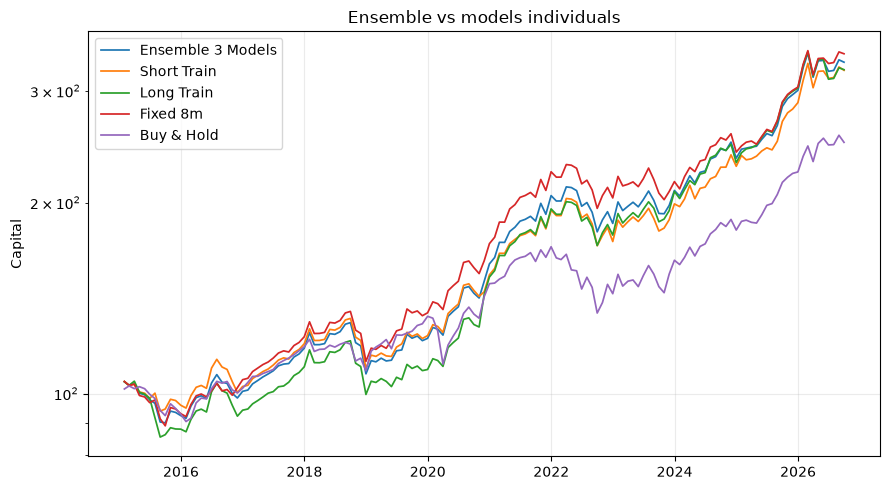

Nombre mitja d'actius: 3.65
Minim: 3
Maxim: 6
Nombre efectiu mitja de posicions: 3.38


In [53]:
# ============================================================
# ENSEMBLE DELS TRES MODELS
#
# Pes = nombre de vots / 9
# ============================================================

ensemble_weights = pd.DataFrame(
    0.0,
    index=agreement_df["Return Month"],
    columns=cs_tickers
)


# ============================================================
# 1. CONSTRUIM ELS PESOS
# ============================================================

for _, row in agreement_df.iterrows():

    date = row["Return Month"]


    # Cada model representa 1/3 de la cartera.
    #
    # Cada model posa 1/3 en cadascun dels seus Top 3.
    #
    # Per tant cada vot representa:
    #
    # (1/3) * (1/3) = 1/9

    for ticker in row["Short Top3"]:

        ensemble_weights.loc[
            date,
            ticker
        ] += 1 / 9


    for ticker in row["Long Top3"]:

        ensemble_weights.loc[
            date,
            ticker
        ] += 1 / 9


    for ticker in row["Fixed Top3"]:

        ensemble_weights.loc[
            date,
            ticker
        ] += 1 / 9


# COMPROVACIO:
# els pesos han de sumar 1

print(
    "Pes mitja total:",
    ensemble_weights.sum(axis=1).mean()
)

print(
    "Pes minim total:",
    ensemble_weights.sum(axis=1).min()
)

print(
    "Pes maxim total:",
    ensemble_weights.sum(axis=1).max()
)


# ============================================================
# 2. RETORNS DELS ACTIUS
# ============================================================

ensemble_asset_returns = (
    monthly_returns_fine
    .reindex(
        ensemble_weights.index
    )
)


# ============================================================
# 3. RETORN BRUT
# ============================================================

ensemble_gross_returns = (
    ensemble_weights
    * ensemble_asset_returns
).sum(axis=1)


# ============================================================
# 4. TURNOVER REAL
# ============================================================

ensemble_turnover = (
    ensemble_weights
    .diff()
    .abs()
    .sum(axis=1)
)


# Cost inicial d'entrar a la cartera

ensemble_turnover.iloc[0] = (
    ensemble_weights
    .iloc[0]
    .abs()
    .sum()
)


# ============================================================
# 5. RETORN NET
# ============================================================

ensemble_returns = (
    ensemble_gross_returns
    - ensemble_turnover
    * cost_rate
)


# ============================================================
# 6. PERIODE COMU
# ============================================================

ensemble_index = (
    ensemble_returns
    .dropna()
    .index
)


short_returns = (
    mountain_returns[
        "Short Train 2.2-3.0y"
    ]
    .reindex(
        ensemble_index
    )
)


long_returns = (
    mountain_returns[
        "Long Train 4.7-5.5y"
    ]
    .reindex(
        ensemble_index
    )
)


fixed_returns = (
    fixed_8_returns
    .reindex(
        ensemble_index
    )
)


# ============================================================
# 7. BUY & HOLD DEL MATEIX PERIODE
# ============================================================

bh_assets = (
    monthly_returns_fine
    .reindex(
        ensemble_index
    )
)


bh_sleeves = (
    1 + bh_assets
).cumprod() / len(cs_tickers)


bh_equity = (
    bh_sleeves.sum(axis=1)
)


bh_returns = (
    bh_equity
    .pct_change()
)


bh_returns.iloc[0] = (
    bh_equity.iloc[0]
    - 1
)


# ============================================================
# 8. COMPARACIO
# ============================================================

ensemble_comparison = {

    "Ensemble 3 Models":
        ensemble_returns,

    "Short Train":
        short_returns,

    "Long Train":
        long_returns,

    "Fixed 8m":
        fixed_returns,

    "Buy & Hold":
        bh_returns
}


ensemble_results = []


for name, returns in (
    ensemble_comparison.items()
):

    metrics = (
        performance_metrics_monthly(
            returns
        )
    )


    ensemble_results.append({

        "Strategy":
            name,

        **metrics
    })


ensemble_results_df = pd.DataFrame(
    ensemble_results
)


# FORMAT

ensemble_display = (
    ensemble_results_df.copy()
)


for col in [
    "Total Return",
    "CAGR",
    "Volatility",
    "Max Drawdown"
]:

    ensemble_display[col] = (
        ensemble_display[col]
        * 100
    ).map(
        lambda x:
            f"{x:.2f}%"
    )


ensemble_display[
    "Sharpe"
] = (
    ensemble_display[
        "Sharpe"
    ].map(
        lambda x:
            f"{x:.2f}"
    )
)


display(
    ensemble_display
)


# ============================================================
# 9. EQUITY CURVES
# ============================================================

plt.figure(
    figsize=(9, 5)
)


for name, returns in (
    ensemble_comparison.items()
):

    equity = (
        1 + returns
    ).cumprod() * 100


    plt.plot(
        equity,
        label=name,
        linewidth=1.25
    )


plt.title(
    "Ensemble vs models individuals"
)

plt.ylabel(
    "Capital"
)

plt.yscale(
    "log"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 10. QUANTS ACTIUS TE L'ENSEMBLE?
# ============================================================

n_positions = (
    ensemble_weights > 0
).sum(axis=1)


print(
    "Nombre mitja d'actius:",
    f"{n_positions.mean():.2f}"
)

print(
    "Minim:",
    n_positions.min()
)

print(
    "Maxim:",
    n_positions.max()
)


# ============================================================
# 11. CONCENTRACIO EFECTIVA
#
# 1 / sum(w^2)
# ============================================================

effective_positions = (
    1
    / (
        ensemble_weights ** 2
    ).sum(axis=1)
)


print(
    "Nombre efectiu mitja de posicions:",
    f"{effective_positions.mean():.2f}"
)

## 20. Comparació de regles de ponderació per consens

Cada actiu pot rebre entre 0 i 3 vots segons quants models l'inclouen al seu Top 3:

$$
v_i\in\{0,1,2,3\}
$$

Compararem cinc maneres de transformar els vots en pesos.

### 1. Vots lineals

$$
w_i=\frac{v_i}{9}
$$

Cada vot representa una novena part de la cartera.

### 2. Màxim de vots

El 100% del capital es reparteix només entre els actius amb el nombre màxim de vots.

### 3. Líder 50% + segon nivell 50%

Si només existeix un actiu amb el màxim de vots:

- rep el 50%;
- l'altre 50% es reparteix entre els actius amb el següent nombre més alt de vots.

Si diversos actius comparteixen el màxim, el capital es reparteix igualment entre ells.

### 4. Vots al quadrat

$$
w_i=
\frac{v_i^2}
{\sum_jv_j^2}
$$

Aquesta regla dona més pes als actius amb consens elevat, però manté una petita exposició als actius amb un sol vot.

### 5. Top 3 reescalat

Seleccionem els tres actius amb més vots i reescalem els seus pesos perquè sumin 100%:

$$
w_i=
\frac{v_i}
{\sum_{j\in Top3}v_j}
$$

En cas d'empat utilitzarem l'ordre mitjà dels tres models com a desempat.

Compararem totes les variants amb:

- Fixed 8m;
- Buy & Hold.

Mantindrem 10 bps de cost per unitat de turnover.

RESULTATS DE PERFORMANCE:


,Strategy,Total Return,CAGR,Volatility,Sharpe,Max Drawdown
0,Vots lineals,232.81%,10.78%,11.78%,0.93,-16.95%
1,Max vots 100%,287.10%,12.21%,12.72%,0.97,-18.23%
2,Lider 50 + segon 50,279.88%,12.03%,12.50%,0.97,-18.23%
3,Vots al quadrat,249.79%,11.25%,11.94%,0.96,-17.30%
4,Top 3 reescalat,249.67%,11.24%,11.99%,0.95,-16.99%
5,Fixed 8m,243.13%,11.06%,11.78%,0.95,-16.58%
6,Buy & Hold,148.81%,8.07%,11.45%,0.74,-21.37%



ESTRUCTURA DE LES CARTERES:


,Strategy,Turnover/year,Avg Positions,Effective Positions,Avg Max Weight
0,Vots lineals,4.21x,3.65,3.38,33.02%
1,Max vots 100%,7.09x,2.43,2.43,45.15%
2,Lider 50 + segon 50,6.09x,2.60,2.56,41.61%
3,Vots al quadrat,5.07x,3.65,3.03,36.57%
4,Top 3 reescalat,5.01x,3.00,2.94,36.00%
5,Fixed 8m,4.57x,3.00,3.00,33.33%
6,Buy & Hold,0.00x,8.00,7.56,17.69%



PESOS DE L'ULTIM MES: 2026-09-30


,EEM,IWM,GLD,DBC
Vots lineals,33.3%,22.2%,11.1%,33.3%
Max vots 100%,50.0%,0.0%,0.0%,50.0%
Lider 50 + segon 50,50.0%,0.0%,0.0%,50.0%
Vots al quadrat,39.1%,17.4%,4.3%,39.1%
Top 3 reescalat,37.5%,25.0%,0.0%,37.5%
Fixed 8m,33.3%,33.3%,0.0%,33.3%


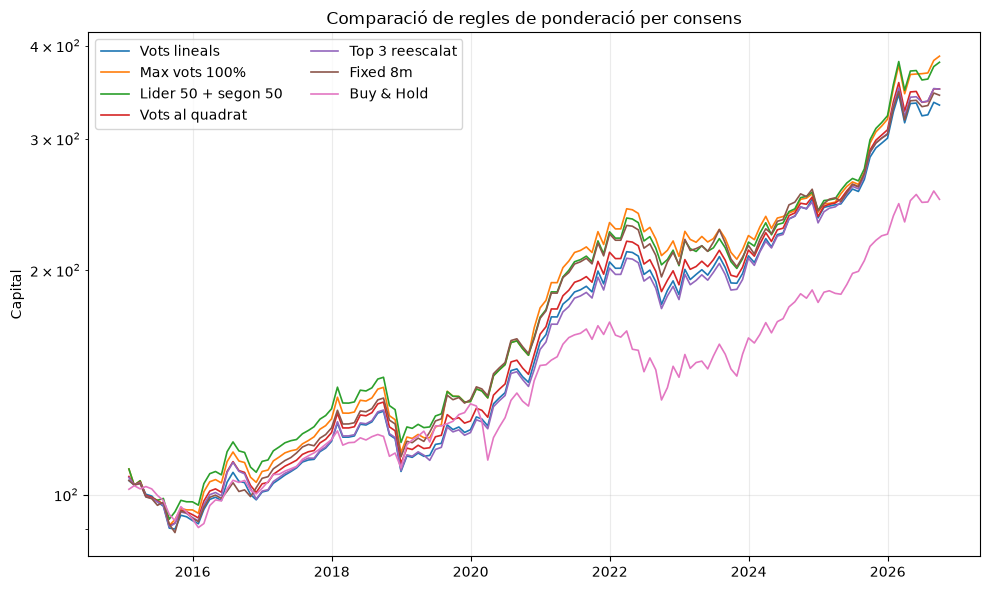

In [54]:
# COMPARACIO DE REGLES DE PONDERACIO PER CONSENS

cost_bps = 10
cost_rate = cost_bps / 10000

fixed_lb = 8 * 21


# ============================================================
# 1. DATES COMUNES
# ============================================================

candidate_dates = pd.DatetimeIndex(
    pd.to_datetime(
        agreement_df["Return Month"]
    ).unique()
).sort_values()


asset_returns_all = (
    monthly_returns_fine
    .reindex(candidate_dates)[cs_tickers]
)


fixed_weights_all = (
    weights_by_lb[fixed_lb]
    .reindex(candidate_dates)[cs_tickers]
)


valid_dates = (
    asset_returns_all.notna().all(axis=1)
    &
    fixed_weights_all.notna().all(axis=1)
)


comparison_dates = (
    candidate_dates[
        valid_dates.to_numpy()
    ]
)


asset_returns = (
    asset_returns_all
    .reindex(comparison_dates)
)


# ============================================================
# 2. MATRIUS DE PESOS
# ============================================================

model_names = [
    "Vots lineals",
    "Max vots 100%",
    "Lider 50 + segon 50",
    "Vots al quadrat",
    "Top 3 reescalat"
]


weight_matrices = {

    name: pd.DataFrame(
        0.0,
        index=candidate_dates,
        columns=cs_tickers
    )

    for name in model_names
}


# ============================================================
# 3. FUNCIO PER OBTENIR VOTS I RANKING MITJA
# ============================================================

def get_votes_and_average_rank(
    short_top3,
    long_top3,
    fixed_top3
):

    top_lists = [
        tuple(short_top3),
        tuple(long_top3),
        tuple(fixed_top3)
    ]


    # VOTS

    votes = pd.Series(
        0.0,
        index=cs_tickers
    )


    for top3 in top_lists:

        for ticker in top3:

            votes.loc[ticker] += 1


    # RANKING MITJA
    #
    # Posicio 1, 2 o 3 si l'actiu es seleccionat.
    # Posicio 4 si queda fora del Top 3.
    #
    # Només s'utilitza per desempatar actius
    # amb el mateix nombre de vots.

    rank_columns = []


    for top3 in top_lists:

        model_rank = pd.Series(
            4.0,
            index=cs_tickers
        )


        for position, ticker in enumerate(
            top3,
            start=1
        ):

            model_rank.loc[ticker] = position


        rank_columns.append(
            model_rank
        )


    average_rank = (
        pd.concat(
            rank_columns,
            axis=1
        )
        .mean(axis=1)
    )


    return votes, average_rank


# ============================================================
# 4. CONSTRUCCIO DELS CINC MODELS
# ============================================================

for _, row in agreement_df.iterrows():

    date = pd.Timestamp(
        row["Return Month"]
    )


    if date not in candidate_dates:
        continue


    votes, average_rank = (
        get_votes_and_average_rank(

            row["Short Top3"],

            row["Long Top3"],

            row["Fixed Top3"]
        )
    )


    # Comprovacio:
    # tres models * tres actius = nou vots

    if not np.isclose(
        votes.sum(),
        9.0
    ):

        raise ValueError(
            f"Els vots no sumen 9 a {date}"
        )


    # --------------------------------------------------------
    # MODEL 1
    # VOTS LINEALS
    #
    # 3 vots = 33.3%
    # 2 vots = 22.2%
    # 1 vot  = 11.1%
    # --------------------------------------------------------

    linear_weights = (
        votes
        / votes.sum()
    )


    weight_matrices[
        "Vots lineals"
    ].loc[date] = linear_weights


    # --------------------------------------------------------
    # MODEL 2
    # 100% ALS ACTIUS AMB EL MAXIM DE VOTS
    # --------------------------------------------------------

    max_votes = (
        votes.max()
    )


    max_assets = (
        votes[
            votes == max_votes
        ].index
    )


    max_weights = pd.Series(
        0.0,
        index=cs_tickers
    )


    max_weights.loc[
        max_assets
    ] = (
        1
        / len(max_assets)
    )


    weight_matrices[
        "Max vots 100%"
    ].loc[date] = max_weights


    # --------------------------------------------------------
    # MODEL 3
    # LIDER 50% + SEGON NIVELL 50%
    #
    # Si hi ha un únic lider:
    # - 50% al lider
    # - 50% al següent nivell de vots
    #
    # Si hi ha diversos líders:
    # - 100% repartit entre ells
    # --------------------------------------------------------

    leader_next_weights = pd.Series(
        0.0,
        index=cs_tickers
    )


    if len(max_assets) > 1:

        leader_next_weights.loc[
            max_assets
        ] = (
            1
            / len(max_assets)
        )


    else:

        leader = (
            max_assets[0]
        )


        leader_next_weights.loc[
            leader
        ] = 0.50


        lower_positive_levels = sorted(

            votes[
                (votes < max_votes)
                &
                (votes > 0)
            ].unique(),

            reverse=True
        )


        if len(
            lower_positive_levels
        ) > 0:

            next_level = (
                lower_positive_levels[0]
            )


            next_assets = (
                votes[
                    votes == next_level
                ].index
            )


            leader_next_weights.loc[
                next_assets
            ] = (
                0.50
                / len(next_assets)
            )


        else:

            # Cas defensiu:
            # si no existeix segon nivell,
            # el líder rep el 100%.

            leader_next_weights.loc[
                leader
            ] = 1.0


    weight_matrices[
        "Lider 50 + segon 50"
    ].loc[date] = leader_next_weights


    # --------------------------------------------------------
    # MODEL 4
    # VOTS AL QUADRAT
    #
    # Exemples de puntuacio:
    #
    # 3 vots -> 9
    # 2 vots -> 4
    # 1 vot  -> 1
    # --------------------------------------------------------

    squared_score = (
        votes ** 2
    )


    squared_weights = (
        squared_score
        / squared_score.sum()
    )


    weight_matrices[
        "Vots al quadrat"
    ].loc[date] = squared_weights


    # --------------------------------------------------------
    # MODEL 5
    # TOP 3 REESCALAT
    #
    # Ordenem primer per vots.
    # En cas d'empat, utilitzem el ranking mitja.
    # --------------------------------------------------------

    ranking_table = pd.DataFrame({

        "Votes":
            votes,

        "Average Rank":
            average_rank,

        "Ticker":
            votes.index
    })


    ranking_table = (
        ranking_table
        .sort_values(

            [
                "Votes",
                "Average Rank",
                "Ticker"
            ],

            ascending=[
                False,
                True,
                True
            ]
        )
    )


    selected_top3 = (
        ranking_table
        .head(3)
        .index
    )


    top3_weights = pd.Series(
        0.0,
        index=cs_tickers
    )


    selected_votes = (
        votes.loc[
            selected_top3
        ]
    )


    top3_weights.loc[
        selected_top3
    ] = (
        selected_votes
        / selected_votes.sum()
    )


    weight_matrices[
        "Top 3 reescalat"
    ].loc[date] = top3_weights


# ============================================================
# 5. PERIODE COMU I COMPROVACIO DELS PESOS
# ============================================================

for name in model_names:

    weight_matrices[name] = (
        weight_matrices[name]
        .reindex(comparison_dates)
    )


    weight_sum = (
        weight_matrices[name]
        .sum(axis=1)
    )


    if not np.allclose(
        weight_sum,
        1.0
    ):

        raise ValueError(
            f"Els pesos de {name} no sumen 1"
        )


fixed_weights = (
    fixed_weights_all
    .reindex(comparison_dates)
)


# ============================================================
# 6. FUNCIO DE BACKTEST
# ============================================================

def backtest_monthly_weights(
    weights,
    returns,
    cost_rate
):

    weights = (
        weights
        .reindex(
            returns.index
        )
    )


    gross_returns = (
        weights
        * returns
    ).sum(axis=1)


    turnover = (
        weights
        .diff()
        .abs()
        .sum(axis=1)
    )


    # Cost inicial d'entrar a la cartera

    turnover.iloc[0] = (
        weights
        .iloc[0]
        .abs()
        .sum()
    )


    net_returns = (
        gross_returns
        - turnover
        * cost_rate
    )


    return (
        net_returns,
        turnover
    )


# ============================================================
# 7. RETORNS DELS MODELS DE CONSENS
# ============================================================

strategy_returns = {}
strategy_turnover = {}
strategy_weights = {}


for name in model_names:

    net_returns, turnover = (
        backtest_monthly_weights(

            weight_matrices[name],

            asset_returns,

            cost_rate
        )
    )


    strategy_returns[
        name
    ] = net_returns


    strategy_turnover[
        name
    ] = turnover


    strategy_weights[
        name
    ] = weight_matrices[name]


# ============================================================
# 8. FIXED 8M
# ============================================================

fixed_returns, fixed_turnover = (
    backtest_monthly_weights(

        fixed_weights,

        asset_returns,

        cost_rate
    )
)


strategy_returns[
    "Fixed 8m"
] = fixed_returns


strategy_turnover[
    "Fixed 8m"
] = fixed_turnover


strategy_weights[
    "Fixed 8m"
] = fixed_weights


# ============================================================
# 9. BUY AND HOLD
#
# Mateix capital inicial repartit entre els 8 actius
# sense rebalanceig posterior.
# ============================================================

buyhold_sleeves = (
    1 + asset_returns
).cumprod() / len(cs_tickers)


buyhold_equity = (
    buyhold_sleeves
    .sum(axis=1)
)


buyhold_returns = (
    buyhold_equity
    .pct_change()
)


buyhold_returns.iloc[0] = (
    buyhold_equity.iloc[0]
    - 1
)


buyhold_dynamic_weights = (
    buyhold_sleeves
    .div(
        buyhold_equity,
        axis=0
    )
)


strategy_returns[
    "Buy & Hold"
] = buyhold_returns


strategy_weights[
    "Buy & Hold"
] = buyhold_dynamic_weights


strategy_turnover[
    "Buy & Hold"
] = pd.Series(
    0.0,
    index=comparison_dates
)


# ============================================================
# 10. METRIQUES DE PERFORMANCE
# ============================================================

performance_rows = []


strategy_order = (
    model_names
    + [
        "Fixed 8m",
        "Buy & Hold"
    ]
)


for name in strategy_order:

    metrics = (
        performance_metrics_monthly(
            strategy_returns[name]
        )
    )


    performance_rows.append({

        "Strategy":
            name,

        **metrics
    })


performance_df = pd.DataFrame(
    performance_rows
)


performance_display = (
    performance_df.copy()
)


for col in [
    "Total Return",
    "CAGR",
    "Volatility",
    "Max Drawdown"
]:

    performance_display[col] = (
        performance_display[col]
        * 100
    ).map(
        lambda x:
            f"{x:.2f}%"
    )


performance_display[
    "Sharpe"
] = (
    performance_display[
        "Sharpe"
    ].map(
        lambda x:
            f"{x:.2f}"
    )
)


print(
    "RESULTATS DE PERFORMANCE:"
)

display(
    performance_display
)


# ============================================================
# 11. ESTRUCTURA I CONCENTRACIO
# ============================================================

structure_rows = []


for name in strategy_order:

    weights = (
        strategy_weights[name]
    )


    turnover = (
        strategy_turnover[name]
    )


    n_positions = (
        weights > 0
    ).sum(axis=1)


    effective_positions = (
        1
        / (
            weights ** 2
        ).sum(axis=1)
    )


    max_weight = (
        weights.max(axis=1)
    )


    structure_rows.append({

        "Strategy":
            name,

        "Turnover/year":
            turnover.mean()
            * 12,

        "Avg Positions":
            n_positions.mean(),

        "Effective Positions":
            effective_positions.mean(),

        "Avg Max Weight":
            max_weight.mean()
    })


structure_df = pd.DataFrame(
    structure_rows
)


structure_display = (
    structure_df.copy()
)


structure_display[
    "Turnover/year"
] = (
    structure_display[
        "Turnover/year"
    ].map(
        lambda x:
            f"{x:.2f}x"
    )
)


for col in [
    "Avg Positions",
    "Effective Positions"
]:

    structure_display[col] = (
        structure_display[col]
        .map(
            lambda x:
                f"{x:.2f}"
        )
    )


structure_display[
    "Avg Max Weight"
] = (
    structure_display[
        "Avg Max Weight"
    ] * 100
).map(
    lambda x:
        f"{x:.2f}%"
)


print(
    "\nESTRUCTURA DE LES CARTERES:"
)

display(
    structure_display
)


# ============================================================
# 12. PESOS DE L'ULTIM MES
# ============================================================

latest_date = (
    comparison_dates[-1]
)


latest_weights = pd.DataFrame({

    name:
        strategy_weights[name]
        .loc[latest_date]

    for name in (
        model_names
        + ["Fixed 8m"]
    )
}).T


latest_weights = (
    latest_weights.loc[
        :,
        latest_weights.max(axis=0) > 0
    ]
)


latest_weights_display = (
    latest_weights
    * 100
).round(1)


latest_weights_display = (
    latest_weights_display
    .map(
        lambda x:
            f"{x:.1f}%"
    )
)


print(
    f"\nPESOS DE L'ULTIM MES: "
    f"{latest_date.date()}"
)

display(
    latest_weights_display
)


# ============================================================
# 13. EQUITY CURVES
# ============================================================

plt.figure(
    figsize=(10, 6)
)


for name in strategy_order:

    equity = (
        1
        + strategy_returns[name]
    ).cumprod() * 100


    plt.plot(
        equity,
        label=name,
        linewidth=1.2
    )


plt.title(
    "Comparació de regles de ponderació per consens"
)

plt.ylabel(
    "Capital"
)

plt.yscale(
    "log"
)

plt.grid(
    alpha=0.25
)

plt.legend(
    ncol=2
)

plt.tight_layout()

plt.show()

## 21. Meta Walk-Forward de la regla de ponderació

Ja disposem de diversos models de construcció de cartera.

Els dos candidats principals són:

- Líder 50% + segon nivell 50%;
- Vots al quadrat.

Ara comprovarem si podem seleccionar entre aquests models utilitzant únicament informació passada.

Per operar cada any:

1. observarem els 36 mesos anteriors;
2. calcularem el Sharpe de cada regla;
3. seleccionarem la regla amb millor Sharpe;
4. congelarem aquesta regla durant l'any següent.

Per exemple:

$$
2015-2017
\rightarrow
selecció
\rightarrow
2018
$$

El turnover es calcularà sobre els pesos realment utilitzats, incloent el cost de canviar de regla entre dos anys.

També compararem el meta-model amb:

- Líder 50 + segon 50;
- Vots al quadrat;
- Max vots 100%;
- Fixed 8m;
- Buy & Hold.

CORRELACIO DELS RETORNS MENSUALS:


,Lider 50 + segon 50,Vots al quadrat,Max vots 100%,Fixed 8m
Lider 50 + segon 50,1.000,0.986,0.988,0.937
Vots al quadrat,0.986,1.000,0.976,0.964
Max vots 100%,0.988,0.976,1.000,0.930
Fixed 8m,0.937,0.964,0.930,1.000



Distancia mitjana entre els pesos de 50+50 i Vots al quadrat:
0.210

RESULTATS META WALK-FORWARD:


,Strategy,Total Return,CAGR,Volatility,Sharpe,Max Drawdown
0,Meta Walk-Forward,175.21%,12.27%,12.85%,0.97,-18.23%
1,Lider 50 + segon 50,191.37%,13.00%,13.04%,1.01,-18.23%
2,Vots al quadrat,188.70%,12.88%,12.67%,1.02,-17.30%
3,Max vots 100%,206.30%,13.65%,13.34%,1.03,-18.23%
4,Fixed 8m,179.10%,12.45%,12.63%,1.00,-16.58%
5,Buy & Hold,108.15%,8.74%,12.13%,0.75,-20.14%



MODEL ESCOLLIT ABANS DE CADA ANY:


,Year,Selected Model,Train Sharpe,OOS Return
0,2018,Lider 50 + segon 50,0.87,-9.90%
1,2019,Lider 50 + segon 50,0.56,13.46%
2,2020,Vots al quadrat,0.66,30.67%
3,2021,Vots al quadrat,0.84,28.79%
4,2022,Vots al quadrat,2.04,-9.56%
5,2023,Lider 50 + segon 50,1.15,7.59%
6,2024,Vots al quadrat,0.74,10.94%
7,2025,Vots al quadrat,0.36,30.65%
8,2026,Vots al quadrat,1.57,13.42%



FREQUENCIA DE SELECCIO:


Selected Model
Vots al quadrat        66.67
Lider 50 + segon 50    33.33
Name: Percentatge, dtype: float64

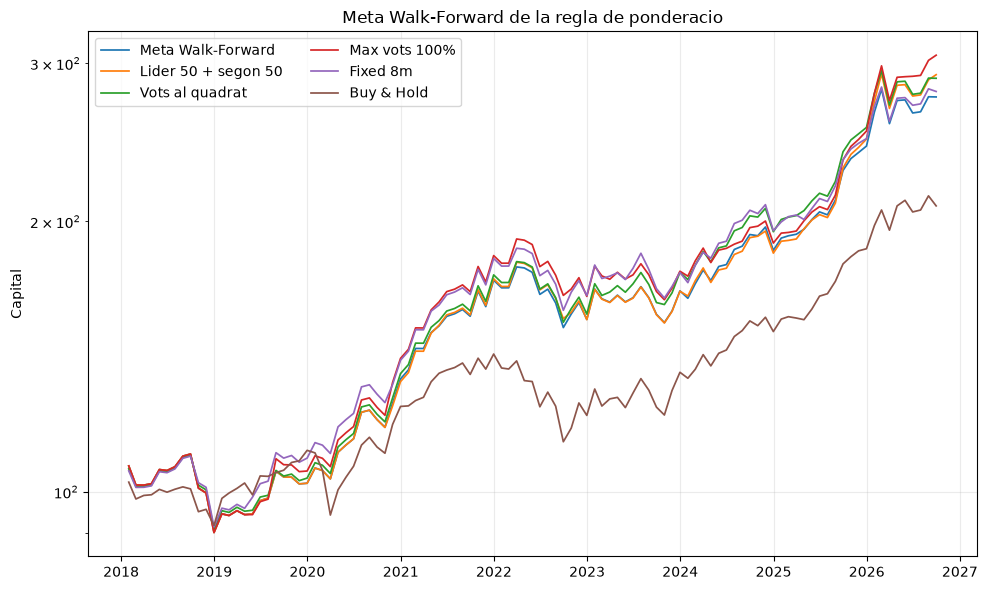

In [56]:
# META WALK-FORWARD DE LA REGLA DE PONDERACIO

meta_candidates = [
    "Lider 50 + segon 50",
    "Vots al quadrat"
]

comparison_models = [
    "Lider 50 + segon 50",
    "Vots al quadrat",
    "Max vots 100%",
    "Fixed 8m"
]

meta_train_months = 36

cost_bps = 10
cost_rate = cost_bps / 10000


def monthly_sharpe(returns):

    returns = (
        returns
        .dropna()
    )

    if (
        len(returns) == 0
        or returns.std() == 0
    ):

        return np.nan

    return (
        returns.mean()
        / returns.std()
        * np.sqrt(12)
    )


# DIAGNOSTIC:
# CORRELACIO DELS RETORNS

diagnostic_returns = pd.DataFrame({

    name:
        strategy_returns[name]

    for name in comparison_models
}).dropna()


print(
    "CORRELACIO DELS RETORNS MENSUALS:"
)

display(
    diagnostic_returns
    .corr()
    .round(3)
)


# DIAGNOSTIC:
# DISTANCIA ENTRE ELS PESOS DELS DOS CANDIDATS

weight_distance = (
    strategy_weights[
        "Lider 50 + segon 50"
    ]
    .sub(
        strategy_weights[
            "Vots al quadrat"
        ]
    )
    .abs()
    .sum(axis=1)
)


print(
    "\nDistancia mitjana entre els pesos "
    "de 50+50 i Vots al quadrat:"
)

print(
    f"{weight_distance.mean():.3f}"
)


# META WALK-FORWARD

available_years = sorted(
    strategy_weights[
        meta_candidates[0]
    ].index.year.unique()
)

first_meta_year = (
    min(available_years)
    + int(
        np.ceil(
            meta_train_months / 12
        )
    )
)

last_meta_year = (
    max(available_years)
)


meta_rows = []
meta_weight_parts = []


for year in range(
    first_meta_year,
    last_meta_year + 1
):

    test_start = pd.Timestamp(
        f"{year}-01-01"
    )

    test_end = pd.Timestamp(
        f"{year}-12-31"
    )

    train_end = (
        test_start
        - pd.Timedelta(days=1)
    )

    train_start = (
        test_start
        - pd.DateOffset(
            months=meta_train_months
        )
    )

    candidate_rows = []


    for model_name in meta_candidates:

        train_returns = (
            strategy_returns[
                model_name
            ]
            .loc[
                train_start:
                train_end
            ]
            .dropna()
        )


        if len(train_returns) < 30:
            continue


        train_sharpe = (
            monthly_sharpe(
                train_returns
            )
        )


        if pd.isna(
            train_sharpe
        ):

            continue


        candidate_rows.append({

            "Model":
                model_name,

            "Train Sharpe":
                train_sharpe
        })


    candidates_df = pd.DataFrame(
        candidate_rows
    )


    if candidates_df.empty:
        continue


    best_row = (
        candidates_df
        .sort_values(
            "Train Sharpe",
            ascending=False
        )
        .iloc[0]
    )


    selected_model = (
        best_row["Model"]
    )

    selected_train_sharpe = float(
        best_row["Train Sharpe"]
    )


    test_weights = (
        strategy_weights[
            selected_model
        ]
        .loc[
            test_start:
            test_end
        ]
        .copy()
    )


    if len(
        test_weights
    ) == 0:

        continue


    meta_weight_parts.append(
        test_weights
    )


    meta_rows.append({

        "Year":
            year,

        "Selected Model":
            selected_model,

        "Train Sharpe":
            selected_train_sharpe
    })


if len(
    meta_weight_parts
) == 0:

    raise ValueError(
        "No s'han pogut construir pesos "
        "per al Meta Walk-Forward."
    )


# PESOS REALS DEL META-MODEL

meta_weights = (
    pd.concat(
        meta_weight_parts
    )
    .sort_index()
)

meta_weights = (
    meta_weights.loc[
        ~meta_weights.index.duplicated(
            keep="first"
        )
    ]
)


meta_asset_returns = (
    monthly_returns_fine
    .reindex(
        meta_weights.index
    )[cs_tickers]
)


valid_meta = (
    meta_weights.notna().all(axis=1)
    &
    meta_asset_returns.notna().all(axis=1)
)


meta_weights = (
    meta_weights.loc[
        valid_meta
    ]
)

meta_asset_returns = (
    meta_asset_returns.loc[
        valid_meta
    ]
)


# RETORNS DEL META-MODEL
# AMB TURNOVER REAL ENTRE ANYS

meta_returns, meta_turnover = (
    backtest_monthly_weights(

        meta_weights,

        meta_asset_returns,

        cost_rate
    )
)


# RETORN OOS DE CADA ANY

meta_selection_df = pd.DataFrame(
    meta_rows
)


annual_oos_returns = (
    meta_returns
    .groupby(
        meta_returns.index.year
    )
    .apply(
        lambda x:
            (1 + x).prod() - 1
    )
)


meta_selection_df[
    "OOS Return"
] = (
    meta_selection_df[
        "Year"
    ]
    .map(
        annual_oos_returns
    )
)


# PERIODE COMU PER A TOTES LES ESTRATEGIES

common_index = (
    meta_returns
    .dropna()
    .index
)


for model_name in comparison_models:

    model_valid_index = (
        strategy_weights[
            model_name
        ]
        .dropna(
            how="any"
        )
        .index
    )

    common_index = (
        common_index
        .intersection(
            model_valid_index
        )
    )


asset_valid_index = (
    monthly_returns_fine[
        cs_tickers
    ]
    .dropna(
        how="any"
    )
    .index
)


common_index = (
    common_index
    .intersection(
        asset_valid_index
    )
    .sort_values()
)


if len(
    common_index
) == 0:

    raise ValueError(
        "No hi ha un periode comu valid "
        "per comparar les estrategies."
    )


# RETORNS COMPARABLES

meta_comparison_returns = {

    "Meta Walk-Forward":
        meta_returns
        .reindex(
            common_index
        )
}


comparison_asset_returns = (
    monthly_returns_fine
    .reindex(
        common_index
    )[cs_tickers]
)


for model_name in comparison_models:

    model_weights = (
        strategy_weights[
            model_name
        ]
        .reindex(
            common_index
        )
    )


    model_returns, _ = (
        backtest_monthly_weights(

            model_weights,

            comparison_asset_returns,

            cost_rate
        )
    )


    meta_comparison_returns[
        model_name
    ] = model_returns


# BUY AND HOLD

buyhold_sleeves = (
    1
    + comparison_asset_returns
).cumprod() / len(
    cs_tickers
)


buyhold_equity = (
    buyhold_sleeves
    .sum(axis=1)
)


buyhold_returns = (
    buyhold_equity
    .pct_change()
)


buyhold_returns.iloc[0] = (
    buyhold_equity.iloc[0]
    - 1
)


meta_comparison_returns[
    "Buy & Hold"
] = buyhold_returns


# RESULTATS

meta_results = []


for name, returns in (
    meta_comparison_returns.items()
):

    metrics = (
        performance_metrics_monthly(
            returns
        )
    )


    meta_results.append({

        "Strategy":
            name,

        **metrics
    })


meta_results_df = pd.DataFrame(
    meta_results
)


meta_display = (
    meta_results_df.copy()
)


for col in [
    "Total Return",
    "CAGR",
    "Volatility",
    "Max Drawdown"
]:

    meta_display[col] = (
        meta_display[col]
        * 100
    ).map(
        lambda x:
            f"{x:.2f}%"
    )


meta_display[
    "Sharpe"
] = (
    meta_display[
        "Sharpe"
    ]
    .map(
        lambda x:
            f"{x:.2f}"
    )
)


print(
    "\nRESULTATS META WALK-FORWARD:"
)

display(
    meta_display
)


# MODEL ESCOLLIT ABANS DE CADA ANY

meta_selection_display = (
    meta_selection_df.copy()
)


meta_selection_display[
    "Train Sharpe"
] = (
    meta_selection_display[
        "Train Sharpe"
    ]
    .map(
        lambda x:
            f"{x:.2f}"
    )
)


meta_selection_display[
    "OOS Return"
] = (
    meta_selection_display[
        "OOS Return"
    ]
    * 100
).map(
    lambda x:
        f"{x:.2f}%"
        if pd.notna(x)
        else "-"
)


print(
    "\nMODEL ESCOLLIT ABANS DE CADA ANY:"
)

display(
    meta_selection_display
)


# FREQUENCIA DE SELECCIO

selection_frequency = (
    meta_selection_df[
        "Selected Model"
    ]
    .value_counts(
        normalize=True
    )
    .mul(100)
    .rename(
        "Percentatge"
    )
)


print(
    "\nFREQUENCIA DE SELECCIO:"
)

display(
    selection_frequency
    .round(2)
)


# EQUITY CURVES

plt.figure(
    figsize=(10, 6)
)


for name, returns in (
    meta_comparison_returns.items()
):

    equity = (
        1
        + returns
    ).cumprod() * 100


    plt.plot(
        equity,
        label=name,
        linewidth=1.25
    )


plt.title(
    "Meta Walk-Forward de la regla de ponderacio"
)

plt.ylabel(
    "Capital"
)

plt.yscale(
    "log"
)

plt.grid(
    alpha=0.25
)

plt.legend(
    ncol=2
)

plt.tight_layout()

plt.show()

## 22. Estabilitat temporal del senyal de consens

Hem observat que els actius seleccionats per més models tendeixen a tenir millor rendiment posterior.

Ara volem comprovar si aquesta relació és estable al llarg del temps.

Utilitzarem finestres rolling de 36 mesos.

Per cada finestra calcularem el retorn excessiu mitjà dels actius que havien rebut:

- 0 vots;
- 1 vot;
- 2 vots;
- 3 vots.

L'objectiu és comprovar si:

$$
3\ vots > 2\ vots > 1\ vot > 0\ vots
$$

és una característica persistent o només el resultat agregat d'alguns períodes concrets.

També calcularem el spread:

$$
Spread_{3-0}
=
Return_{3\ votes}
-
Return_{0\ votes}
$$

Si aquest spread és positiu de manera persistent, el consens entre models conté informació útil.

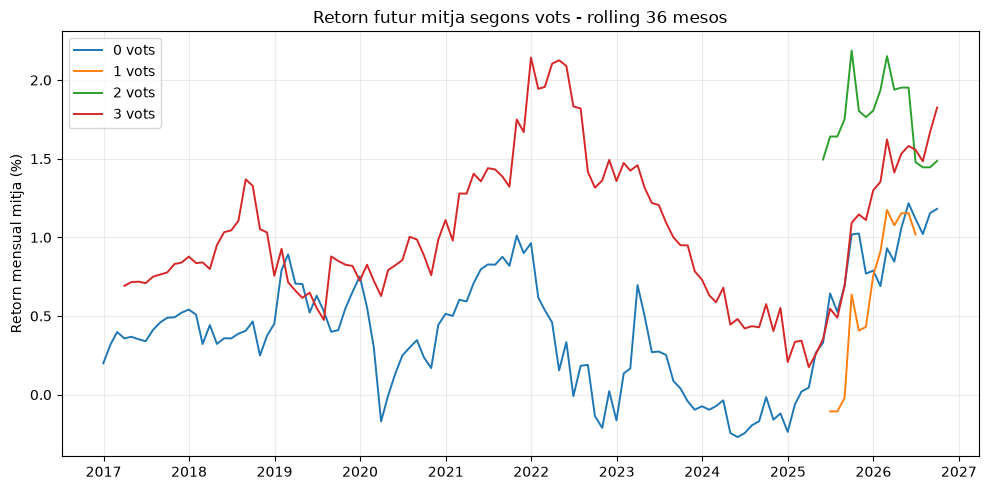

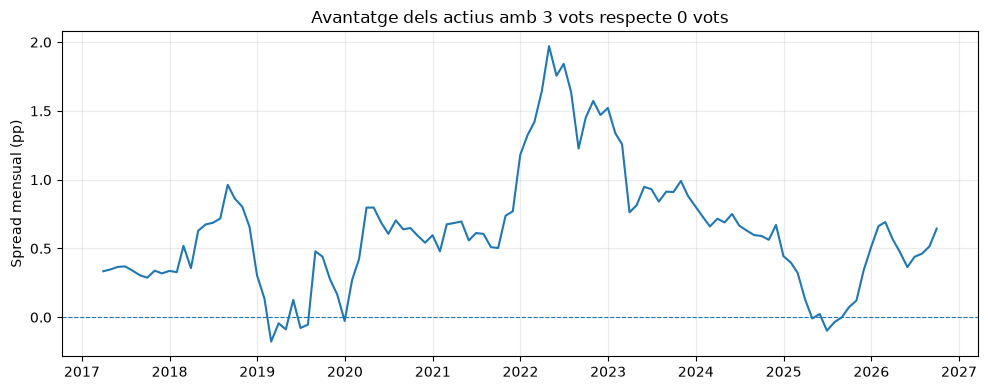

Percentatge de finestres rolling on 3 vots supera 0 vots:
91.30%

Spread 3-0 mitja:
0.62 pp mensuals

Spread 3-0 mediana:
0.61 pp mensuals

Percentatge de finestres amb:
3 vots > 2 > 1 > 0:
0.00%

Percentatge de finestres on 3 vots supera 0 i 1 vot:
76.92%


In [57]:
# ESTABILITAT TEMPORAL DEL SENYAL DE VOTS

rolling_months = 36


# ============================================================
# 1. RETORN MENSUAL MITJA PER NIVELL DE VOTS
# ============================================================

monthly_vote_returns = (
    asset_votes_df
    .groupby(
        [
            "Return Month",
            "Votes"
        ]
    )[
        "Asset Return"
    ]
    .mean()
    .unstack(
        "Votes"
    )
    .sort_index()
)


# Ens assegurem de tenir les quatre categories

monthly_vote_returns = (
    monthly_vote_returns
    .reindex(
        columns=[
            0,
            1,
            2,
            3
        ]
    )
)


# ============================================================
# 2. MITJANES ROLLING
# ============================================================

rolling_vote_returns = (
    monthly_vote_returns
    .rolling(
        window=rolling_months,
        min_periods=24
    )
    .mean()
)


# SPREAD 3 VOTS - 0 VOTS

rolling_vote_returns[
    "Spread 3-0"
] = (
    rolling_vote_returns[3]
    - rolling_vote_returns[0]
)


# ============================================================
# 3. GRAFIC DEL RETORN PER VOTS
# ============================================================

plt.figure(
    figsize=(10, 5)
)


for votes in [
    0,
    1,
    2,
    3
]:

    plt.plot(
        rolling_vote_returns.index,
        rolling_vote_returns[votes] * 100,
        label=f"{votes} vots",
        linewidth=1.4
    )


plt.title(
    "Retorn futur mitja segons vots - rolling 36 mesos"
)

plt.ylabel(
    "Retorn mensual mitja (%)"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 4. SPREAD 3 VOTS VS 0 VOTS
# ============================================================

plt.figure(
    figsize=(10, 4)
)


plt.plot(
    rolling_vote_returns.index,
    rolling_vote_returns[
        "Spread 3-0"
    ] * 100,
    linewidth=1.5
)


plt.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)


plt.title(
    "Avantatge dels actius amb 3 vots respecte 0 vots"
)

plt.ylabel(
    "Spread mensual (pp)"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# 5. QUANT TEMPS EL SPREAD ES POSITIU?
# ============================================================

spread = (
    rolling_vote_returns[
        "Spread 3-0"
    ]
    .dropna()
)


positive_fraction = (
    (spread > 0).mean()
)


print(
    "Percentatge de finestres rolling "
    "on 3 vots supera 0 vots:"
)

print(
    f"{positive_fraction * 100:.2f}%"
)


print(
    "\nSpread 3-0 mitja:"
)

print(
    f"{spread.mean() * 100:.2f} pp mensuals"
)


print(
    "\nSpread 3-0 mediana:"
)

print(
    f"{spread.median() * 100:.2f} pp mensuals"
)


# ============================================================
# 6. MONOTONICITAT
#
# Comprovem quants cops tenim:
#
# 3 > 2 > 1 > 0
# ============================================================

valid_rows = (
    rolling_vote_returns[
        [0, 1, 2, 3]
    ]
    .dropna()
)


strict_monotonic = (
    (
        valid_rows[3]
        > valid_rows[2]
    )
    &
    (
        valid_rows[2]
        > valid_rows[1]
    )
    &
    (
        valid_rows[1]
        > valid_rows[0]
    )
)


print(
    "\nPercentatge de finestres amb:"
)

print(
    "3 vots > 2 > 1 > 0:"
)

print(
    f"{strict_monotonic.mean() * 100:.2f}%"
)


# ============================================================
# 7. UNA PROVA MES FLEXIBLE
#
# Només demanem que:
#
# 3 vots > 0 vots
# i
# 3 vots > 1 vot
# ============================================================

three_votes_best_signal = (
    (
        valid_rows[3]
        > valid_rows[0]
    )
    &
    (
        valid_rows[3]
        > valid_rows[1]
    )
)


print(
    "\nPercentatge de finestres on "
    "3 vots supera 0 i 1 vot:"
)

print(
    f"{three_votes_best_signal.mean() * 100:.2f}%"
)

## 23. Test estadístic del senyal de consens

L'anàlisi rolling mostra una diferència persistent entre els actius amb 3 vots i els actius amb 0 vots.

Ara volem estimar la incertesa d'aquest resultat.

Utilitzarem dues mesures.

### Spread 3 vs 0

Per cada mes:

$$
Spread_t
=
R_{3vots,t}
-
R_{0vots,t}
$$

### Pendent dels vots

Per cada mes estimarem la relació cross-sectional entre:

$$
Votes_i
$$

i

$$
R_i-R_{univers}
$$

Una pendent positiva significa que, dins d'aquell mes, els actius amb més vots han tendit a obtenir millor rendiment posterior.

Finalment utilitzarem un block bootstrap temporal.

En lloc de remostrejar mesos individuals, remostrarem blocs consecutius de mesos per preservar parcialment la dependència temporal.

L'objectiu és estimar intervals de confiança del 95% per:

- spread 3 vs 0;
- rendiment addicional per vot.

RESULTATS DEL SENYAL DE CONSENS:


,Measure,Observations,Mean,Median,Positive,CI 2.5%,CI 97.5%
0,Spread 3 votes - 0 votes,137,0.614%,0.315%,57.7%,-0.031%,1.220%
1,Return per additional vote,141,0.194%,0.162%,58.2%,-0.005%,0.392%


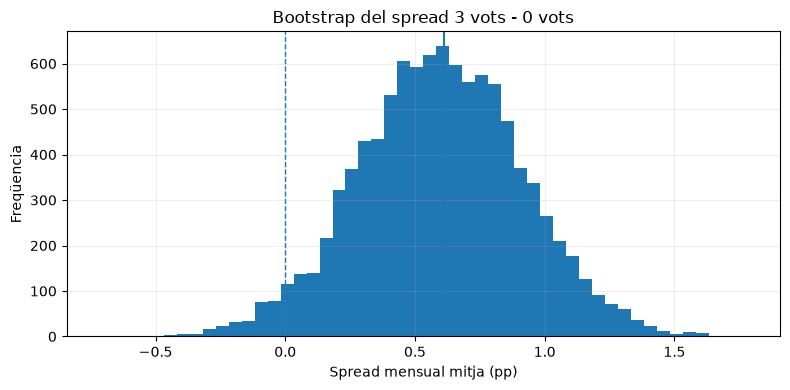

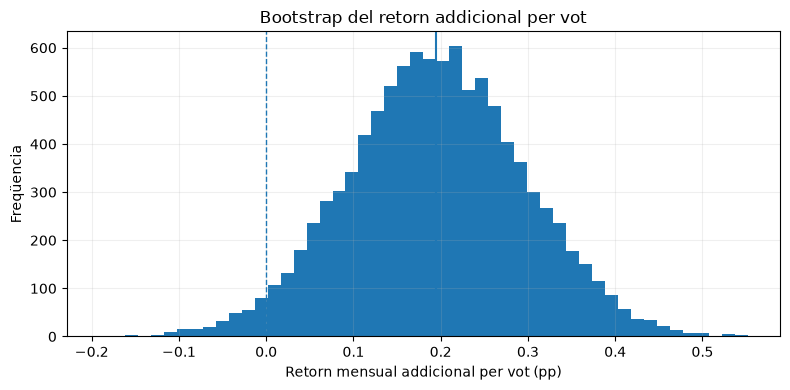

In [58]:
# ============================================================
# TEST ESTADISTIC DEL SENYAL DE CONSENS
# ============================================================

bootstrap_iterations = 10000

block_length = 6

rng = np.random.default_rng(
    42
)


# ============================================================
# 1. SPREAD MENSUAL 3 VOTS VS 0 VOTS
# ============================================================

monthly_extremes = (
    asset_votes_df
    .pivot_table(
        index="Return Month",
        columns="Votes",
        values="Asset Return",
        aggfunc="mean"
    )
    .sort_index()
)


# Només mesos on existeixen
# tant actius amb 3 vots com amb 0 vots

spread_3_0 = (
    monthly_extremes[3]
    - monthly_extremes[0]
).dropna()


# ============================================================
# 2. PENDENT CROSS-SECTIONAL DELS VOTS
#
# Cada mes:
#
# Excess Return_i = alpha + beta * Votes_i
#
# beta > 0
# implica més retorn per més vots.
# ============================================================

monthly_slopes = []


for date, month_data in (
    asset_votes_df
    .groupby(
        "Return Month"
    )
):

    data = (
        month_data[
            [
                "Votes",
                "Excess Return"
            ]
        ]
        .dropna()
    )


    if len(data) < 4:
        continue


    x = (
        data["Votes"]
        .to_numpy(
            dtype=float
        )
    )

    y = (
        data["Excess Return"]
        .to_numpy(
            dtype=float
        )
    )


    # Si tots els actius tenen
    # exactament els mateixos vots
    # no podem calcular pendent.

    if np.var(x) == 0:
        continue


    beta = (
        np.cov(
            x,
            y,
            ddof=1
        )[0, 1]
        / np.var(
            x,
            ddof=1
        )
    )


    monthly_slopes.append({

        "Return Month":
            date,

        "Vote Slope":
            beta
    })


monthly_slopes_df = (
    pd.DataFrame(
        monthly_slopes
    )
    .set_index(
        "Return Month"
    )
    .sort_index()
)


vote_slope = (
    monthly_slopes_df[
        "Vote Slope"
    ]
)


# ============================================================
# 3. BLOCK BOOTSTRAP
# ============================================================

def block_bootstrap_mean(
    series,
    block_length,
    iterations,
    rng
):

    values = (
        series
        .dropna()
        .to_numpy(
            dtype=float
        )
    )

    n = len(values)


    if n < block_length:

        raise ValueError(
            "No hi ha prou observacions "
            "per al block bootstrap."
        )


    possible_starts = np.arange(
        0,
        n - block_length + 1
    )


    bootstrap_means = np.empty(
        iterations
    )


    blocks_needed = int(
        np.ceil(
            n / block_length
        )
    )


    for i in range(
        iterations
    ):

        starts = rng.choice(
            possible_starts,
            size=blocks_needed,
            replace=True
        )


        sample_parts = []


        for start in starts:

            block = values[
                start:
                start + block_length
            ]

            sample_parts.append(
                block
            )


        bootstrap_sample = (
            np.concatenate(
                sample_parts
            )[:n]
        )


        bootstrap_means[i] = (
            bootstrap_sample.mean()
        )


    return bootstrap_means


# ============================================================
# 4. BOOTSTRAP DEL SPREAD 3-0
# ============================================================

spread_bootstrap = (
    block_bootstrap_mean(
        spread_3_0,
        block_length,
        bootstrap_iterations,
        rng
    )
)


spread_ci = np.percentile(
    spread_bootstrap,
    [
        2.5,
        97.5
    ]
)


# ============================================================
# 5. BOOTSTRAP DE LA PENDENT DELS VOTS
# ============================================================

slope_bootstrap = (
    block_bootstrap_mean(
        vote_slope,
        block_length,
        bootstrap_iterations,
        rng
    )
)


slope_ci = np.percentile(
    slope_bootstrap,
    [
        2.5,
        97.5
    ]
)


# ============================================================
# 6. RESULTATS
# ============================================================

statistical_results = pd.DataFrame([

    {

        "Measure":
            "Spread 3 votes - 0 votes",

        "Observations":
            len(spread_3_0),

        "Mean":
            spread_3_0.mean(),

        "Median":
            spread_3_0.median(),

        "Positive":
            (spread_3_0 > 0).mean(),

        "CI 2.5%":
            spread_ci[0],

        "CI 97.5%":
            spread_ci[1]
    },

    {

        "Measure":
            "Return per additional vote",

        "Observations":
            len(vote_slope),

        "Mean":
            vote_slope.mean(),

        "Median":
            vote_slope.median(),

        "Positive":
            (vote_slope > 0).mean(),

        "CI 2.5%":
            slope_ci[0],

        "CI 97.5%":
            slope_ci[1]
    }

])


statistical_display = (
    statistical_results.copy()
)


for col in [
    "Mean",
    "Median",
    "CI 2.5%",
    "CI 97.5%"
]:

    statistical_display[col] = (
        statistical_display[col]
        * 100
    ).map(
        lambda x:
            f"{x:.3f}%"
    )


statistical_display[
    "Positive"
] = (
    statistical_display[
        "Positive"
    ]
    * 100
).map(
    lambda x:
        f"{x:.1f}%"
)


print(
    "RESULTATS DEL SENYAL DE CONSENS:"
)

display(
    statistical_display
)


# ============================================================
# 7. DISTRIBUCIO BOOTSTRAP DEL SPREAD 3-0
# ============================================================

plt.figure(
    figsize=(8, 4)
)


plt.hist(
    spread_bootstrap
    * 100,
    bins=50
)


plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)


plt.axvline(
    spread_3_0.mean()
    * 100,
    linewidth=1.5
)


plt.title(
    "Bootstrap del spread 3 vots - 0 vots"
)

plt.xlabel(
    "Spread mensual mitja (pp)"
)

plt.ylabel(
    "Freqüencia"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()


# ============================================================
# 8. DISTRIBUCIO BOOTSTRAP DE LA PENDENT
# ============================================================

plt.figure(
    figsize=(8, 4)
)


plt.hist(
    slope_bootstrap
    * 100,
    bins=50
)


plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)


plt.axvline(
    vote_slope.mean()
    * 100,
    linewidth=1.5
)


plt.title(
    "Bootstrap del retorn addicional per vot"
)

plt.xlabel(
    "Retorn mensual addicional per vot (pp)"
)

plt.ylabel(
    "Freqüencia"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

SENSIBILITAT DEL BOOTSTRAP:


,Block Months,Spread Mean,Spread CI Low,Spread CI High,Slope Mean,Slope CI Low,Slope CI High
0,3,0.614%,-0.096%,1.275%,0.194%,-0.034%,0.409%
1,6,0.614%,-0.031%,1.220%,0.194%,-0.004%,0.396%
2,9,0.614%,0.087%,1.191%,0.194%,0.032%,0.391%
3,12,0.614%,0.094%,1.175%,0.194%,0.052%,0.382%


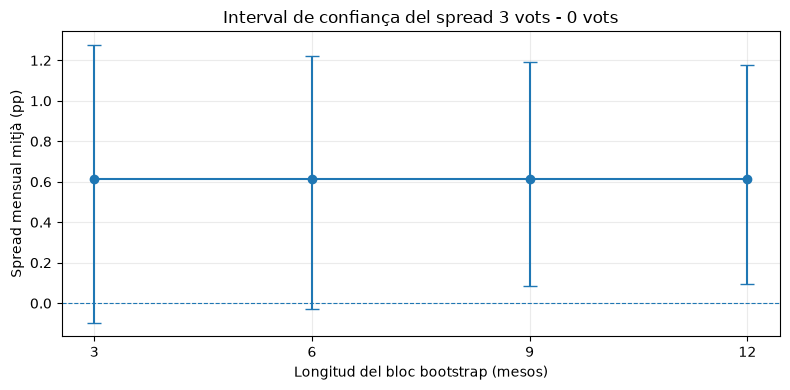

In [59]:
# ============================================================
# SENSIBILITAT DEL BLOCK BOOTSTRAP
# ============================================================

bootstrap_iterations = 10000

block_lengths = [
    3,
    6,
    9,
    12
]

rng_seed = 42


def block_bootstrap_mean(
    series,
    block_length,
    iterations,
    seed
):

    rng = np.random.default_rng(
        seed
    )

    values = (
        series
        .dropna()
        .to_numpy(
            dtype=float
        )
    )

    n = len(values)


    if n < block_length:

        raise ValueError(
            "El bloc és més llarg "
            "que la sèrie disponible."
        )


    possible_starts = np.arange(
        0,
        n - block_length + 1
    )


    blocks_needed = int(
        np.ceil(
            n / block_length
        )
    )


    bootstrap_means = np.empty(
        iterations
    )


    for i in range(
        iterations
    ):

        starts = rng.choice(
            possible_starts,
            size=blocks_needed,
            replace=True
        )


        sample = np.concatenate([

            values[
                start:
                start + block_length
            ]

            for start in starts
        ])[:n]


        bootstrap_means[i] = (
            sample.mean()
        )


    return bootstrap_means


# ============================================================
# RESULTATS PER DIFERENTS BLOCS
# ============================================================

bootstrap_rows = []


for block_length in block_lengths:

    # SPREAD 3 - 0

    spread_boot = (
        block_bootstrap_mean(
            spread_3_0,
            block_length,
            bootstrap_iterations,
            rng_seed
        )
    )


    spread_ci = np.percentile(
        spread_boot,
        [
            2.5,
            97.5
        ]
    )


    # PENDENT PER VOT

    slope_boot = (
        block_bootstrap_mean(
            vote_slope,
            block_length,
            bootstrap_iterations,
            rng_seed
        )
    )


    slope_ci = np.percentile(
        slope_boot,
        [
            2.5,
            97.5
        ]
    )


    bootstrap_rows.append({

        "Block Months":
            block_length,

        "Spread Mean":
            spread_3_0.mean(),

        "Spread CI Low":
            spread_ci[0],

        "Spread CI High":
            spread_ci[1],

        "Slope Mean":
            vote_slope.mean(),

        "Slope CI Low":
            slope_ci[0],

        "Slope CI High":
            slope_ci[1]
    })


bootstrap_sensitivity_df = (
    pd.DataFrame(
        bootstrap_rows
    )
)


# ============================================================
# FORMAT
# ============================================================

bootstrap_display = (
    bootstrap_sensitivity_df.copy()
)


for col in [
    "Spread Mean",
    "Spread CI Low",
    "Spread CI High",
    "Slope Mean",
    "Slope CI Low",
    "Slope CI High"
]:

    bootstrap_display[col] = (
        bootstrap_display[col]
        * 100
    ).map(
        lambda x:
            f"{x:.3f}%"
    )


print(
    "SENSIBILITAT DEL BOOTSTRAP:"
)

display(
    bootstrap_display
)


# ============================================================
# GRAFIC DELS INTERVALS DEL SPREAD
# ============================================================

x = (
    bootstrap_sensitivity_df[
        "Block Months"
    ]
)


mean = (
    bootstrap_sensitivity_df[
        "Spread Mean"
    ] * 100
)


low = (
    bootstrap_sensitivity_df[
        "Spread CI Low"
    ] * 100
)


high = (
    bootstrap_sensitivity_df[
        "Spread CI High"
    ] * 100
)


lower_error = (
    mean - low
)

upper_error = (
    high - mean
)


plt.figure(
    figsize=(8, 4)
)


plt.errorbar(
    x,
    mean,
    yerr=[
        lower_error,
        upper_error
    ],
    marker="o",
    capsize=5
)


plt.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)


plt.title(
    "Interval de confiança del spread 3 vots - 0 vots"
)

plt.xlabel(
    "Longitud del bloc bootstrap (mesos)"
)

plt.ylabel(
    "Spread mensual mitjà (pp)"
)

plt.xticks(
    block_lengths
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()

SPREAD 3 VOTS VS 0 VOTS PER ANY:


,Year,Spread_Mean,Spread_Median,Spread_Positive_Months,Vote_Slope_Mean,Months
0,2015,0.12%,1.31%,60.0%,0.11%,10
1,2016,0.54%,0.62%,54.5%,0.01%,11
2,2017,0.20%,0.53%,58.3%,0.05%,12
3,2018,-0.00%,0.31%,58.3%,0.02%,12
4,2019,-0.51%,-3.05%,27.3%,-0.05%,11
5,2020,2.04%,0.31%,58.3%,0.56%,12
6,2021,1.66%,1.05%,75.0%,0.53%,12
7,2022,0.87%,0.66%,66.7%,0.32%,12
8,2023,-0.11%,-0.01%,50.0%,0.10%,12
9,2024,0.58%,0.71%,58.3%,0.26%,12



Percentatge d'anys amb spread mitja positiu:
75.0%

Spread anual mitja dels anys:
0.60% mensual


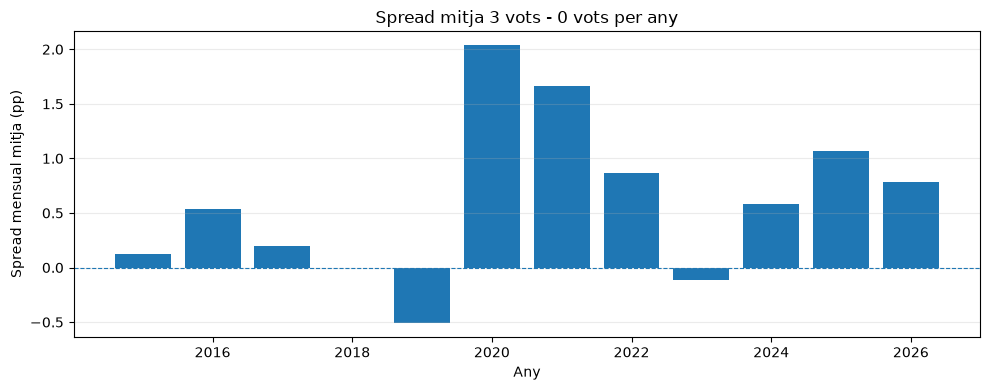

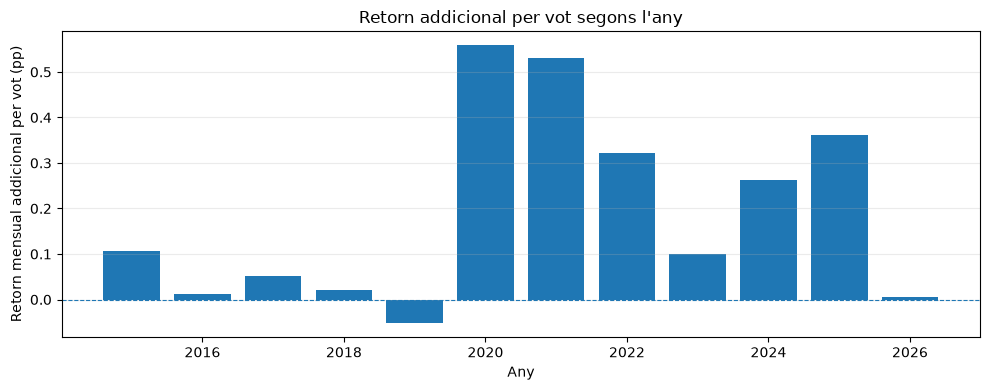

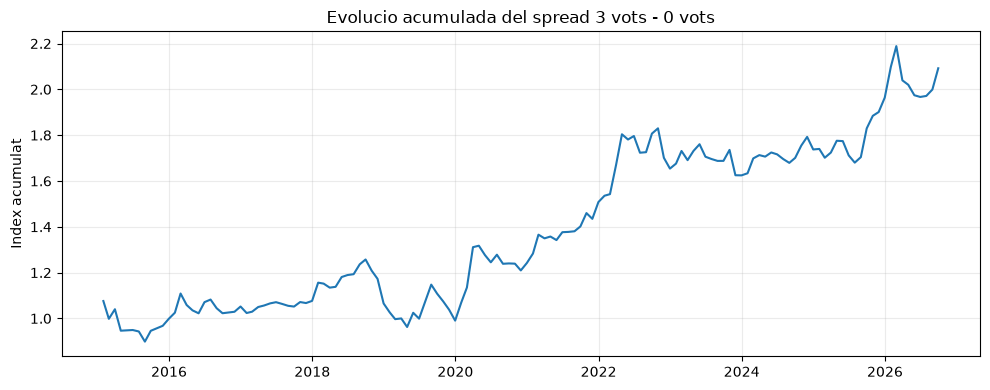

In [60]:
# ============================================================
# SPREAD 3 VOTS VS 0 VOTS ANY PER ANY
# ============================================================

yearly_spread_data = pd.DataFrame({

    "Spread 3-0":
        spread_3_0,

    "Vote Slope":
        vote_slope
})


yearly_spread_data.index = (
    pd.to_datetime(
        yearly_spread_data.index
    )
)


yearly_results = (
    yearly_spread_data
    .groupby(
        yearly_spread_data.index.year
    )
    .agg(

        Spread_Mean=(
            "Spread 3-0",
            "mean"
        ),

        Spread_Median=(
            "Spread 3-0",
            "median"
        ),

        Spread_Positive_Months=(
            "Spread 3-0",
            lambda x:
                (x.dropna() > 0).mean()
        ),

        Vote_Slope_Mean=(
            "Vote Slope",
            "mean"
        ),

        Months=(
            "Spread 3-0",
            "count"
        )
    )
    .reset_index()
    .rename(
        columns={
            "Return Month":
                "Year"
        }
    )
)


# FORMAT DE LA TAULA

yearly_display = (
    yearly_results.copy()
)


for col in [
    "Spread_Mean",
    "Spread_Median",
    "Vote_Slope_Mean"
]:

    yearly_display[col] = (
        yearly_display[col]
        * 100
    ).map(
        lambda x:
            f"{x:.2f}%"
    )


yearly_display[
    "Spread_Positive_Months"
] = (
    yearly_display[
        "Spread_Positive_Months"
    ]
    * 100
).map(
    lambda x:
        f"{x:.1f}%"
    )


print(
    "SPREAD 3 VOTS VS 0 VOTS PER ANY:"
)

display(
    yearly_display
)


# ============================================================
# QUANTS ANYS SON POSITIUS?
# ============================================================

positive_years = (
    yearly_results[
        "Spread_Mean"
    ] > 0
).mean()


print(
    "\nPercentatge d'anys amb spread mitja positiu:"
)

print(
    f"{positive_years * 100:.1f}%"
)


print(
    "\nSpread anual mitja dels anys:"
)

print(
    f"{yearly_results['Spread_Mean'].mean() * 100:.2f}% mensual"
)


# ============================================================
# GRAFIC 1
# SPREAD MITJA PER ANY
# ============================================================

plt.figure(
    figsize=(10, 4)
)


plt.bar(
    yearly_results[
        "Year"
    ],
    yearly_results[
        "Spread_Mean"
    ] * 100
)


plt.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)


plt.title(
    "Spread mitja 3 vots - 0 vots per any"
)

plt.xlabel(
    "Any"
)

plt.ylabel(
    "Spread mensual mitja (pp)"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# GRAFIC 2
# PENDENT DELS VOTS PER ANY
# ============================================================

plt.figure(
    figsize=(10, 4)
)


plt.bar(
    yearly_results[
        "Year"
    ],
    yearly_results[
        "Vote_Slope_Mean"
    ] * 100
)


plt.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)


plt.title(
    "Retorn addicional per vot segons l'any"
)

plt.xlabel(
    "Any"
)

plt.ylabel(
    "Retorn mensual addicional per vot (pp)"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# GRAFIC 3
# SPREAD ACUMULADA
#
# No es una estrategia executable:
# només visualitza la persistencia del senyal.
# ============================================================

spread_cumulative = (
    1
    + spread_3_0
).cumprod()


plt.figure(
    figsize=(10, 4)
)


plt.plot(
    spread_cumulative,
    linewidth=1.5
)


plt.title(
    "Evolucio acumulada del spread 3 vots - 0 vots"
)

plt.ylabel(
    "Index acumulat"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()

## 26. Intensitat contínua del consens

El nombre de vots sembla contenir informació sobre el retorn futur.

Ara estudiarem quanta importància hem de donar al consens.

Definirem els pesos com:

$$
w_i=
\frac{Votes_i^p}
{\sum_j Votes_j^p}
$$

on $p$ controla la concentració.

- $p=0$: tots els actius amb almenys un vot pesen igual;
- $p=1$: vots lineals;
- $p=2$: vots al quadrat;
- valors alts de $p$: cada vegada més capital als actius amb màxim consens.

Per cada valor de $p$ calcularem:

- CAGR;
- Sharpe;
- Max Drawdown;
- turnover;
- nombre efectiu de posicions;
- pes màxim mitjà.

No buscarem el millor valor exacte de $p$.

Buscarem una regió ampla on petits canvis en la concentració produeixin resultats semblants.

Calculant: 100.0% (161/161)
Fet.

Centre de la millor regió segons Sharpe suavitzat:
p = 5.85
Sharpe exacte: 0.974
Sharpe local mitja: 0.974
CAGR local mitja: 11.99%
MaxDD local mitja: -18.01%
Posicions efectives: 2.55
Pes maxim mitja: 42.92%


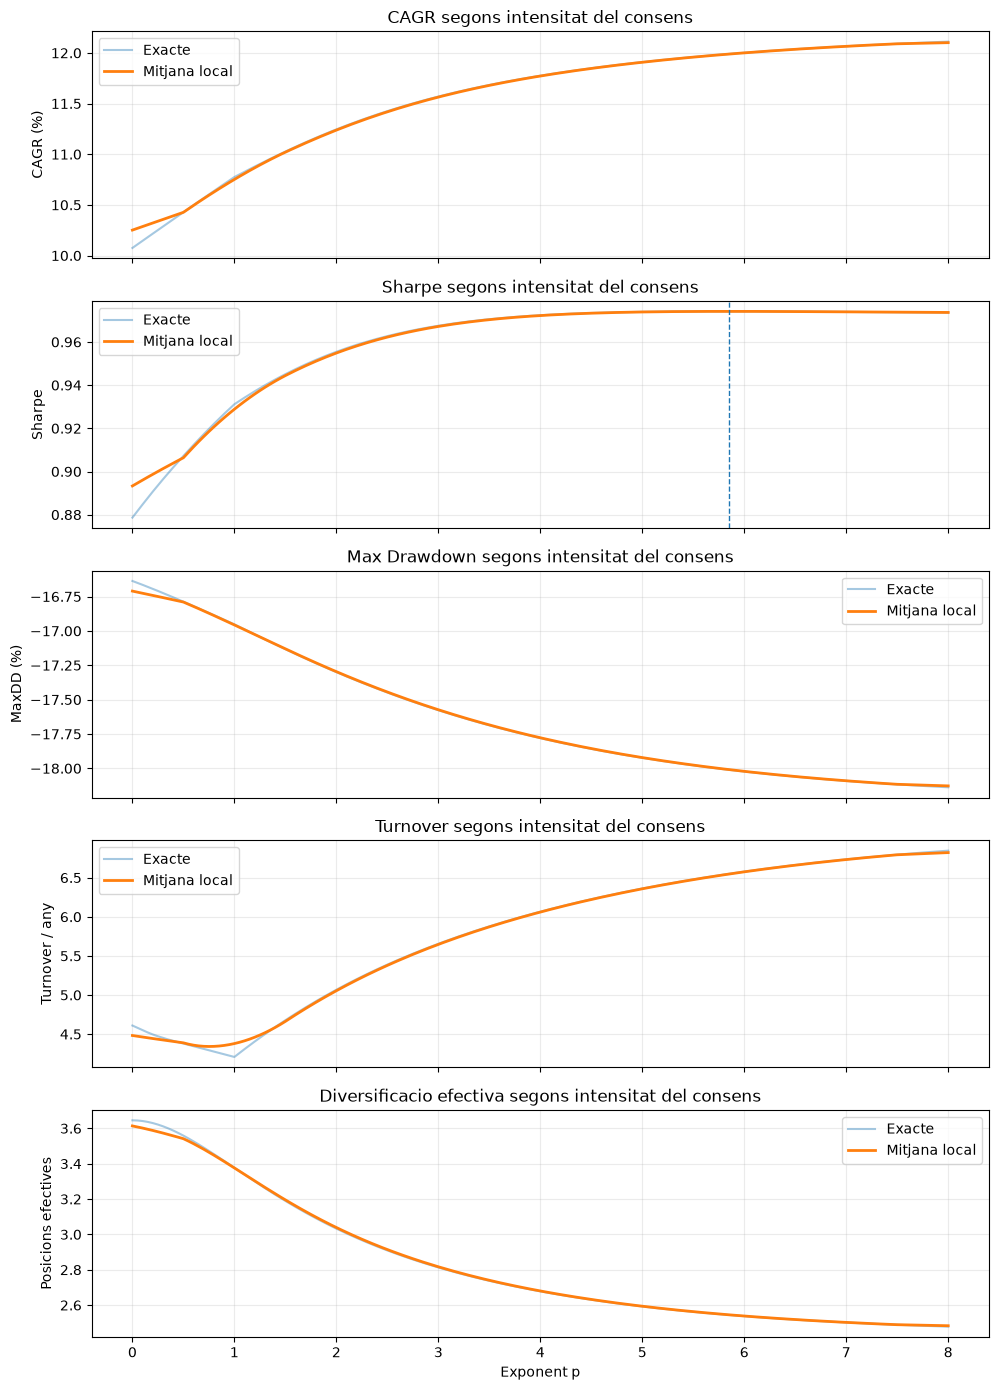

In [61]:
# ============================================================
# SENSIBILITAT CONTINUA A LA CONCENTRACIO DELS VOTS
# ============================================================

p_grid = np.round(
    np.arange(
        0.0,
        8.01,
        0.05
    ),
    2
)

cost_bps = 10
cost_rate = cost_bps / 10000


# ============================================================
# 1. MATRIU DE VOTS DE CADA MES
# ============================================================

vote_dates = pd.DatetimeIndex(
    pd.to_datetime(
        agreement_df["Return Month"]
    ).unique()
).sort_values()


votes_matrix = pd.DataFrame(
    0.0,
    index=vote_dates,
    columns=cs_tickers
)


for _, row in agreement_df.iterrows():

    date = pd.Timestamp(
        row["Return Month"]
    )

    for ticker in row["Short Top3"]:

        votes_matrix.loc[
            date,
            ticker
        ] += 1


    for ticker in row["Long Top3"]:

        votes_matrix.loc[
            date,
            ticker
        ] += 1


    for ticker in row["Fixed Top3"]:

        votes_matrix.loc[
            date,
            ticker
        ] += 1


# Cada mes han d'existir exactament 9 vots

if not np.allclose(
    votes_matrix.sum(axis=1),
    9.0
):

    raise ValueError(
        "Els vots mensuals no sumen 9."
    )


# ============================================================
# 2. RETORNS DELS ACTIUS
# ============================================================

asset_returns = (
    monthly_returns_fine
    .reindex(
        vote_dates
    )[cs_tickers]
)


valid = (
    asset_returns.notna().all(axis=1)
)


votes_matrix = (
    votes_matrix.loc[
        valid
    ]
)


asset_returns = (
    asset_returns.loc[
        valid
    ]
)


# ============================================================
# 3. FUNCIO DE BACKTEST
# ============================================================

def backtest_vote_weights(
    weights,
    returns,
    cost_rate
):

    gross_returns = (
        weights
        * returns
    ).sum(axis=1)


    turnover = (
        weights
        .diff()
        .abs()
        .sum(axis=1)
    )


    turnover.iloc[0] = (
        weights
        .iloc[0]
        .abs()
        .sum()
    )


    net_returns = (
        gross_returns
        - turnover
        * cost_rate
    )


    return (
        net_returns,
        turnover
    )


# ============================================================
# 4. PROVEM TOTS ELS EXPONENTS
# ============================================================

concentration_rows = []

returns_by_p = {}

weights_by_p = {}


total_tests = len(
    p_grid
)


for n, p in enumerate(
    p_grid,
    start=1
):

    # --------------------------------------------------------
    # SCORE SEGONS VOTS
    # --------------------------------------------------------

    if p == 0:

        scores = (
            votes_matrix > 0
        ).astype(float)

    else:

        scores = (
            votes_matrix ** p
        )


    # --------------------------------------------------------
    # NORMALITZEM A 100%
    # --------------------------------------------------------

    weights = (
        scores
        .div(
            scores.sum(axis=1),
            axis=0
        )
    )


    # --------------------------------------------------------
    # BACKTEST
    # --------------------------------------------------------

    net_returns, turnover = (
        backtest_vote_weights(
            weights,
            asset_returns,
            cost_rate
        )
    )


    metrics = (
        performance_metrics_monthly(
            net_returns
        )
    )


    # --------------------------------------------------------
    # CONCENTRACIO
    # --------------------------------------------------------

    effective_positions = (
        1
        / (
            weights ** 2
        ).sum(axis=1)
    )


    max_weight = (
        weights.max(axis=1)
    )


    actual_positions = (
        weights > 0
    ).sum(axis=1)


    concentration_rows.append({

        "p":
            p,

        "CAGR":
            metrics["CAGR"],

        "Volatility":
            metrics["Volatility"],

        "Sharpe":
            metrics["Sharpe"],

        "Max Drawdown":
            metrics["Max Drawdown"],

        "Turnover/year":
            turnover.mean()
            * 12,

        "Avg Positions":
            actual_positions.mean(),

        "Effective Positions":
            effective_positions.mean(),

        "Avg Max Weight":
            max_weight.mean()
    })


    returns_by_p[
        p
    ] = net_returns


    weights_by_p[
        p
    ] = weights


    if (
        n == 1
        or n % 20 == 0
        or n == total_tests
    ):

        print(
            f"\rCalculant: "
            f"{100 * n / total_tests:.1f}% "
            f"({n}/{total_tests})",
            end=""
        )


print(
    "\nFet."
)


concentration_df = (
    pd.DataFrame(
        concentration_rows
    )
)


# ============================================================
# 5. SUAVITZAT LOCAL
#
# +/- 0.5 EN EXPONENT p
# ============================================================

p_step = 0.05

half_smooth_p = 0.50

smooth_points = int(
    round(
        2
        * half_smooth_p
        / p_step
    )
) + 1


metrics_to_smooth = [
    "CAGR",
    "Sharpe",
    "Max Drawdown",
    "Turnover/year",
    "Effective Positions",
    "Avg Max Weight"
]


for metric in metrics_to_smooth:

    concentration_df[
        f"Smooth {metric}"
    ] = (
        concentration_df[
            metric
        ]
        .rolling(
            window=smooth_points,
            center=True,
            min_periods=(
                smooth_points // 2
                + 1
            )
        )
        .mean()
    )


# ============================================================
# 6. CENTRE DE LA MILLOR REGIO DE SHARPE
# ============================================================

valid_smooth = (
    concentration_df[
        "Smooth Sharpe"
    ]
    .dropna()
)


best_idx = (
    valid_smooth.idxmax()
)


best_region = (
    concentration_df
    .loc[
        best_idx
    ]
)


print(
    "\nCentre de la millor regió "
    "segons Sharpe suavitzat:"
)

print(
    f"p = {best_region['p']:.2f}"
)

print(
    f"Sharpe exacte: "
    f"{best_region['Sharpe']:.3f}"
)

print(
    f"Sharpe local mitja: "
    f"{best_region['Smooth Sharpe']:.3f}"
)

print(
    f"CAGR local mitja: "
    f"{best_region['Smooth CAGR'] * 100:.2f}%"
)

print(
    f"MaxDD local mitja: "
    f"{best_region['Smooth Max Drawdown'] * 100:.2f}%"
)

print(
    f"Posicions efectives: "
    f"{best_region['Smooth Effective Positions']:.2f}"
)

print(
    f"Pes maxim mitja: "
    f"{best_region['Smooth Avg Max Weight'] * 100:.2f}%"
)


# ============================================================
# 7. GRAFICS
# ============================================================

fig, axes = plt.subplots(
    5,
    1,
    figsize=(10, 14),
    sharex=True
)


# ------------------------------------------------------------
# CAGR
# ------------------------------------------------------------

axes[0].plot(
    concentration_df["p"],
    concentration_df["CAGR"] * 100,
    alpha=0.4,
    label="Exacte"
)

axes[0].plot(
    concentration_df["p"],
    concentration_df[
        "Smooth CAGR"
    ] * 100,
    linewidth=2,
    label="Mitjana local"
)

axes[0].set_title(
    "CAGR segons intensitat del consens"
)

axes[0].set_ylabel(
    "CAGR (%)"
)

axes[0].grid(
    alpha=0.25
)

axes[0].legend()


# ------------------------------------------------------------
# SHARPE
# ------------------------------------------------------------

axes[1].plot(
    concentration_df["p"],
    concentration_df["Sharpe"],
    alpha=0.4,
    label="Exacte"
)

axes[1].plot(
    concentration_df["p"],
    concentration_df[
        "Smooth Sharpe"
    ],
    linewidth=2,
    label="Mitjana local"
)

axes[1].axvline(
    best_region["p"],
    linestyle="--",
    linewidth=1
)

axes[1].set_title(
    "Sharpe segons intensitat del consens"
)

axes[1].set_ylabel(
    "Sharpe"
)

axes[1].grid(
    alpha=0.25
)

axes[1].legend()


# ------------------------------------------------------------
# MAX DRAWDOWN
# ------------------------------------------------------------

axes[2].plot(
    concentration_df["p"],
    concentration_df[
        "Max Drawdown"
    ] * 100,
    alpha=0.4,
    label="Exacte"
)

axes[2].plot(
    concentration_df["p"],
    concentration_df[
        "Smooth Max Drawdown"
    ] * 100,
    linewidth=2,
    label="Mitjana local"
)

axes[2].set_title(
    "Max Drawdown segons intensitat del consens"
)

axes[2].set_ylabel(
    "MaxDD (%)"
)

axes[2].grid(
    alpha=0.25
)

axes[2].legend()


# ------------------------------------------------------------
# TURNOVER
# ------------------------------------------------------------

axes[3].plot(
    concentration_df["p"],
    concentration_df[
        "Turnover/year"
    ],
    alpha=0.4,
    label="Exacte"
)

axes[3].plot(
    concentration_df["p"],
    concentration_df[
        "Smooth Turnover/year"
    ],
    linewidth=2,
    label="Mitjana local"
)

axes[3].set_title(
    "Turnover segons intensitat del consens"
)

axes[3].set_ylabel(
    "Turnover / any"
)

axes[3].grid(
    alpha=0.25
)

axes[3].legend()


# ------------------------------------------------------------
# POSICIONS EFECTIVES
# ------------------------------------------------------------

axes[4].plot(
    concentration_df["p"],
    concentration_df[
        "Effective Positions"
    ],
    alpha=0.4,
    label="Exacte"
)

axes[4].plot(
    concentration_df["p"],
    concentration_df[
        "Smooth Effective Positions"
    ],
    linewidth=2,
    label="Mitjana local"
)

axes[4].set_title(
    "Diversificacio efectiva segons intensitat del consens"
)

axes[4].set_xlabel(
    "Exponent p"
)

axes[4].set_ylabel(
    "Posicions efectives"
)

axes[4].grid(
    alpha=0.25
)

axes[4].legend()


plt.tight_layout()

plt.show()

## 27. Walk-forward de la intensitat del consens

Hem observat que augmentar l'exponent $p$ dona més pes als actius amb més consens:

$$
w_i=
\frac{Votes_i^p}
{\sum_j Votes_j^p}
$$

L'anàlisi completa mostrava una plataforma aproximada:

$$
p\approx3-5
$$

Per evitar seleccionar aquesta regió utilitzant informació futura, farem un walk-forward.

Per cada any:

1. utilitzarem només els 36 mesos anteriors;
2. calcularem el Sharpe per $p=0,0.1,0.2,\ldots,8$;
3. suavitzarem la corba en un veïnat de $\pm0.5$;
4. seleccionarem la millor regió robusta;
5. congelarem el valor de $p$ durant l'any següent.

Compararem el resultat amb:

- $p=3$ fix;
- $p=4$ fix;
- $p=5$ fix;
- Max Votes;
- Fixed 8m;
- Buy & Hold.

Exponents calculats: 81
Finestra suavitzada: 11 punts

RESULTATS:


,Strategy,Total Return,CAGR,Volatility,Sharpe,Max Drawdown
0,Robust p Walk-Forward,167.24%,11.89%,13.01%,0.93,-18.12%
1,Fixed p=3,193.22%,13.08%,12.78%,1.03,-17.58%
2,Fixed p=4,196.60%,13.23%,12.89%,1.03,-17.78%
3,Fixed p=5,199.21%,13.34%,13.00%,1.03,-17.92%
4,Max votes 100%,206.30%,13.65%,13.34%,1.03,-18.23%
5,Fixed 8m,179.10%,12.45%,12.63%,1.00,-16.58%
6,Buy & Hold,108.15%,8.74%,12.13%,0.75,-20.14%



p ESCOLLIT ABANS DE CADA ANY:


,Year,Selected p,Raw Train Sharpe,Robust Train Sharpe,Local Sharpe Std,OOS Return
0,2018,7.5,0.78,0.78,0.00,-9.81%
1,2019,7.5,0.54,0.54,0.00,16.34%
2,2020,0.8,0.67,0.67,0.00,31.13%
3,2021,0.5,0.87,0.87,0.01,27.61%
4,2022,0.6,2.05,2.05,0.00,-9.71%
5,2023,7.5,1.18,1.18,0.00,7.39%
6,2024,1.4,0.75,0.75,0.00,11.68%
7,2025,0.5,0.45,0.45,0.02,25.65%
8,2026,1.4,1.58,1.58,0.00,11.87%


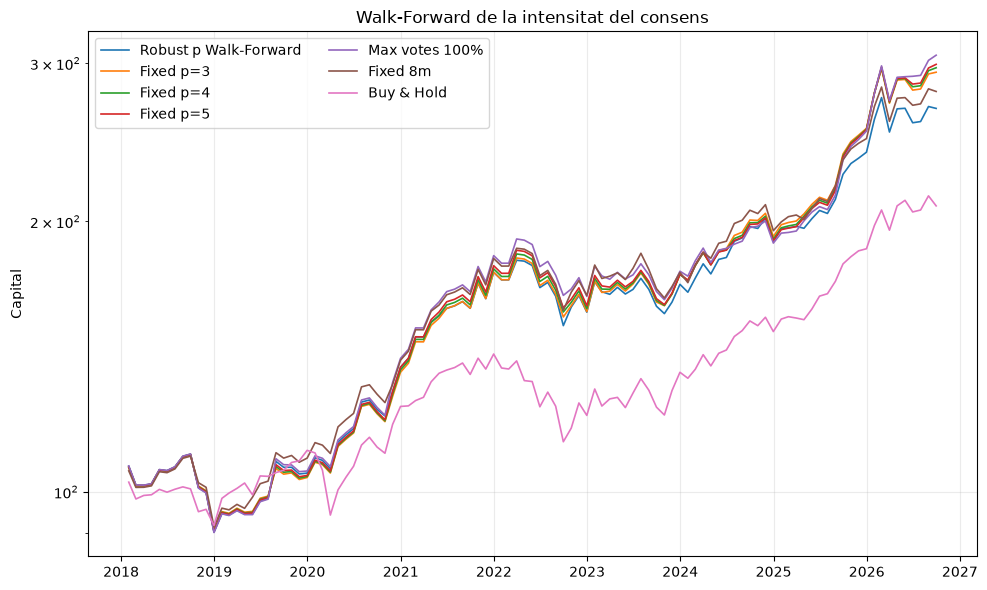

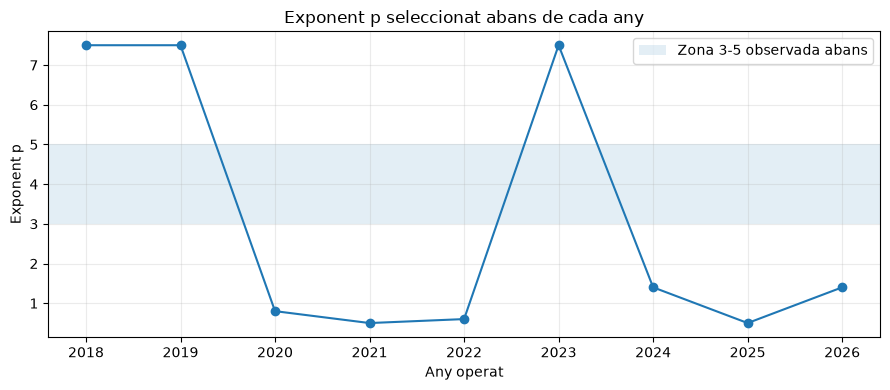

In [62]:
# ============================================================
# WALK-FORWARD ROBUST DE L'EXPONENT p
# ============================================================

p_grid = np.round(
    np.arange(
        0.0,
        8.01,
        0.10
    ),
    2
)

train_months = 36

p_step = 0.10

smooth_half_width = 0.50

smooth_points = int(
    round(
        2 * smooth_half_width / p_step
    )
) + 1

cost_bps = 10
cost_rate = cost_bps / 10000


# ============================================================
# FUNCIO DE BACKTEST
# ============================================================

def backtest_weights(
    weights,
    asset_returns
):

    gross_returns = (
        weights
        * asset_returns
    ).sum(axis=1)


    turnover = (
        weights
        .diff()
        .abs()
        .sum(axis=1)
    )


    # Cost inicial d'entrar a la cartera

    turnover.iloc[0] = (
        weights
        .iloc[0]
        .abs()
        .sum()
    )


    net_returns = (
        gross_returns
        - turnover * cost_rate
    )


    return (
        net_returns,
        turnover
    )


# ============================================================
# 1. MATRIU DE VOTS
# ============================================================

vote_dates = pd.DatetimeIndex(
    pd.to_datetime(
        agreement_df["Return Month"]
    ).unique()
).sort_values()


votes_matrix = pd.DataFrame(
    0.0,
    index=vote_dates,
    columns=cs_tickers
)


for _, row in agreement_df.iterrows():

    date = pd.Timestamp(
        row["Return Month"]
    )


    for ticker in row["Short Top3"]:

        votes_matrix.loc[
            date,
            ticker
        ] += 1


    for ticker in row["Long Top3"]:

        votes_matrix.loc[
            date,
            ticker
        ] += 1


    for ticker in row["Fixed Top3"]:

        votes_matrix.loc[
            date,
            ticker
        ] += 1


# Cada mes:
# 3 models x 3 actius = 9 vots

if not np.allclose(
    votes_matrix.sum(axis=1),
    9.0
):

    raise ValueError(
        "Els vots mensuals no sumen 9."
    )


# ============================================================
# 2. RETORNS DELS ACTIUS
# ============================================================

asset_returns = (
    monthly_returns_fine
    .reindex(
        vote_dates
    )[cs_tickers]
)


valid_dates = (
    asset_returns.notna().all(axis=1)
)


votes_matrix = (
    votes_matrix.loc[
        valid_dates
    ]
)


asset_returns = (
    asset_returns.loc[
        valid_dates
    ]
)


# ============================================================
# 3. FUNCIO QUE TRANSFORMA VOTS EN PESOS
# ============================================================

def weights_from_p(
    votes,
    p
):

    # p = 0:
    # tots els actius amb algun vot
    # tenen el mateix score

    if np.isclose(
        p,
        0.0
    ):

        scores = (
            votes > 0
        ).astype(float)


    else:

        scores = (
            votes ** p
        )


    weights = (
        scores
        .div(
            scores.sum(axis=1),
            axis=0
        )
    )


    return weights


# ============================================================
# 4. PRECALCULEM TOTS ELS p
# ============================================================

weights_by_p = {}

returns_by_p = {}


for p in p_grid:

    weights = (
        weights_from_p(
            votes_matrix,
            p
        )
    )


    returns, _ = (
        backtest_weights(
            weights,
            asset_returns
        )
    )


    weights_by_p[
        float(p)
    ] = weights


    returns_by_p[
        float(p)
    ] = returns


returns_by_p_df = pd.DataFrame(
    returns_by_p
)


print(
    "Exponents calculats:",
    len(p_grid)
)

print(
    "Finestra suavitzada:",
    smooth_points,
    "punts"
)


# ============================================================
# 5. WALK-FORWARD
# ============================================================

first_date = (
    returns_by_p_df.index.min()
)

last_date = (
    returns_by_p_df.index.max()
)


first_test_year = (
    first_date.year
    + 3
)

last_test_year = (
    last_date.year
)


selection_rows = []

wf_weight_parts = []

p_train_curves = {}


for year in range(
    first_test_year,
    last_test_year + 1
):

    test_start = pd.Timestamp(
        f"{year}-01-01"
    )

    test_end = pd.Timestamp(
        f"{year}-12-31"
    )


    train_end = (
        test_start
        - pd.Timedelta(days=1)
    )


    train_start = (
        test_start
        - pd.DateOffset(
            months=train_months
        )
    )


    train_returns = (
        returns_by_p_df
        .loc[
            train_start:
            train_end
        ]
    )


    if len(
        train_returns
    ) < 30:

        continue


    # ========================================================
    # SHARPE PER CADA p
    # ========================================================

    mean_returns = (
        train_returns.mean()
    )

    std_returns = (
        train_returns.std()
    )


    sharpe_curve = (
        mean_returns
        / std_returns
        * np.sqrt(12)
    )


    sharpe_curve = (
        sharpe_curve
        .replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        )
        .dropna()
        .sort_index()
    )


    # ========================================================
    # SUAVITZAT:
    # +/- 0.5 EN p
    # ========================================================

    robust_curve = (
        sharpe_curve
        .rolling(
            window=smooth_points,
            center=True,
            min_periods=smooth_points
        )
        .mean()
        .dropna()
    )


    local_std = (
        sharpe_curve
        .rolling(
            window=smooth_points,
            center=True,
            min_periods=smooth_points
        )
        .std()
    )


    if robust_curve.empty:

        continue


    # ========================================================
    # MILLOR MUNTANYA
    # ========================================================

    selected_p = float(
        robust_curve.idxmax()
    )


    # ========================================================
    # PESOS DURANT L'ANY FUTUR
    # ========================================================

    test_weights = (
        weights_by_p[
            selected_p
        ]
        .loc[
            test_start:
            test_end
        ]
        .copy()
    )


    if len(
        test_weights
    ) == 0:

        continue


    wf_weight_parts.append(
        test_weights
    )


    selection_rows.append({

        "Year":
            year,

        "Selected p":
            selected_p,

        "Raw Train Sharpe":
            sharpe_curve.loc[
                selected_p
            ],

        "Robust Train Sharpe":
            robust_curve.loc[
                selected_p
            ],

        "Local Sharpe Std":
            local_std.loc[
                selected_p
            ]
    })


    p_train_curves[
        year
    ] = {

        "Sharpe":
            sharpe_curve,

        "Robust":
            robust_curve,

        "Selected p":
            selected_p
    }


# ============================================================
# 6. UNIM ELS PESOS REALMENT OPERATS
# ============================================================

if len(
    wf_weight_parts
) == 0:

    raise ValueError(
        "No s'han pogut generar pesos walk-forward."
    )


wf_weights = (
    pd.concat(
        wf_weight_parts
    )
    .sort_index()
)


wf_weights = (
    wf_weights.loc[
        ~wf_weights.index.duplicated(
            keep="first"
        )
    ]
)


wf_asset_returns = (
    asset_returns
    .reindex(
        wf_weights.index
    )
)


wf_returns, wf_turnover = (
    backtest_weights(
        wf_weights,
        wf_asset_returns
    )
)


# ============================================================
# 7. RETORN OOS DE CADA ANY
# ============================================================

selection_df = pd.DataFrame(
    selection_rows
)


annual_returns = (
    wf_returns
    .groupby(
        wf_returns.index.year
    )
    .apply(
        lambda x:
            (1 + x).prod() - 1
    )
)


selection_df[
    "OOS Return"
] = (
    selection_df[
        "Year"
    ]
    .map(
        annual_returns
    )
)


# ============================================================
# 8. MATEIX PERIODE PER TOTES LES COMPARACIONS
# ============================================================

common_index = (
    wf_returns
    .dropna()
    .index
)


comparison_returns = {

    "Robust p Walk-Forward":
        wf_returns
        .reindex(
            common_index
        )
}


# ============================================================
# 9. p FIXOS 3, 4 I 5
# ============================================================

for fixed_p in [
    3.0,
    4.0,
    5.0
]:

    fixed_weights = (
        weights_by_p[
            float(
                fixed_p
            )
        ]
        .reindex(
            common_index
        )
    )


    fixed_returns, _ = (
        backtest_weights(

            fixed_weights,

            asset_returns
            .reindex(
                common_index
            )
        )
    )


    comparison_returns[
        f"Fixed p={fixed_p:.0f}"
    ] = fixed_returns


# ============================================================
# 10. MAX VOTES 100%
# ============================================================

max_weights = pd.DataFrame(
    0.0,
    index=common_index,
    columns=cs_tickers
)


common_votes = (
    votes_matrix
    .reindex(
        common_index
    )
)


for date in common_index:

    votes = (
        common_votes.loc[
            date
        ]
    )


    max_votes = (
        votes.max()
    )


    selected_assets = (
        votes[
            votes == max_votes
        ].index
    )


    max_weights.loc[
        date,
        selected_assets
    ] = (
        1
        / len(
            selected_assets
        )
    )


max_returns, _ = (
    backtest_weights(

        max_weights,

        asset_returns
        .reindex(
            common_index
        )
    )
)


comparison_returns[
    "Max votes 100%"
] = max_returns


# ============================================================
# 11. FIXED 8M
# ============================================================

fixed_8_weights = (
    strategy_weights[
        "Fixed 8m"
    ]
    .reindex(
        common_index
    )
)


fixed_8_returns, _ = (
    backtest_weights(

        fixed_8_weights,

        asset_returns
        .reindex(
            common_index
        )
    )
)


comparison_returns[
    "Fixed 8m"
] = fixed_8_returns


# ============================================================
# 12. BUY & HOLD
# ============================================================

bh_assets = (
    asset_returns
    .reindex(
        common_index
    )
)


bh_sleeves = (
    1
    + bh_assets
).cumprod() / len(
    cs_tickers
)


bh_equity = (
    bh_sleeves.sum(
        axis=1
    )
)


bh_returns = (
    bh_equity
    .pct_change()
)


bh_returns.iloc[0] = (
    bh_equity.iloc[0]
    - 1
)


comparison_returns[
    "Buy & Hold"
] = bh_returns


# ============================================================
# 13. METRIQUES
# ============================================================

result_rows = []


for name, returns in (
    comparison_returns.items()
):

    metrics = (
        performance_metrics_monthly(
            returns
        )
    )


    result_rows.append({

        "Strategy":
            name,

        **metrics
    })


results_df = pd.DataFrame(
    result_rows
)


results_display = (
    results_df.copy()
)


for col in [
    "Total Return",
    "CAGR",
    "Volatility",
    "Max Drawdown"
]:

    results_display[col] = (
        results_display[col]
        * 100
    ).map(
        lambda x:
            f"{x:.2f}%"
    )


results_display[
    "Sharpe"
] = (
    results_display[
        "Sharpe"
    ].map(
        lambda x:
            f"{x:.2f}"
    )
)


print(
    "\nRESULTATS:"
)

display(
    results_display
)


# ============================================================
# 14. p ESCOLLIT CADA ANY
# ============================================================

selection_display = (
    selection_df.copy()
)


for col in [
    "Raw Train Sharpe",
    "Robust Train Sharpe",
    "Local Sharpe Std"
]:

    selection_display[col] = (
        selection_display[col]
        .map(
            lambda x:
                f"{x:.2f}"
        )
    )


selection_display[
    "OOS Return"
] = (
    selection_display[
        "OOS Return"
    ]
    * 100
).map(
    lambda x:
        f"{x:.2f}%"
    )


print(
    "\np ESCOLLIT ABANS DE CADA ANY:"
)

display(
    selection_display
)


# ============================================================
# 15. EQUITY CURVES
# ============================================================

plt.figure(
    figsize=(10, 6)
)


for name, returns in (
    comparison_returns.items()
):

    equity = (
        1
        + returns
    ).cumprod() * 100


    plt.plot(
        equity,
        label=name,
        linewidth=1.2
    )


plt.title(
    "Walk-Forward de la intensitat del consens"
)

plt.ylabel(
    "Capital"
)

plt.yscale(
    "log"
)

plt.grid(
    alpha=0.25
)

plt.legend(
    ncol=2
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. p SELECCIONAT CADA ANY
# ============================================================

plt.figure(
    figsize=(9, 4)
)


plt.plot(
    selection_df[
        "Year"
    ],
    selection_df[
        "Selected p"
    ],
    marker="o"
)


# Zona que havíem observat retrospectivament.
# Només és una referència visual.

plt.axhspan(
    3,
    5,
    alpha=0.12,
    label="Zona 3-5 observada abans"
)


plt.title(
    "Exponent p seleccionat abans de cada any"
)

plt.xlabel(
    "Any operat"
)

plt.ylabel(
    "Exponent p"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()

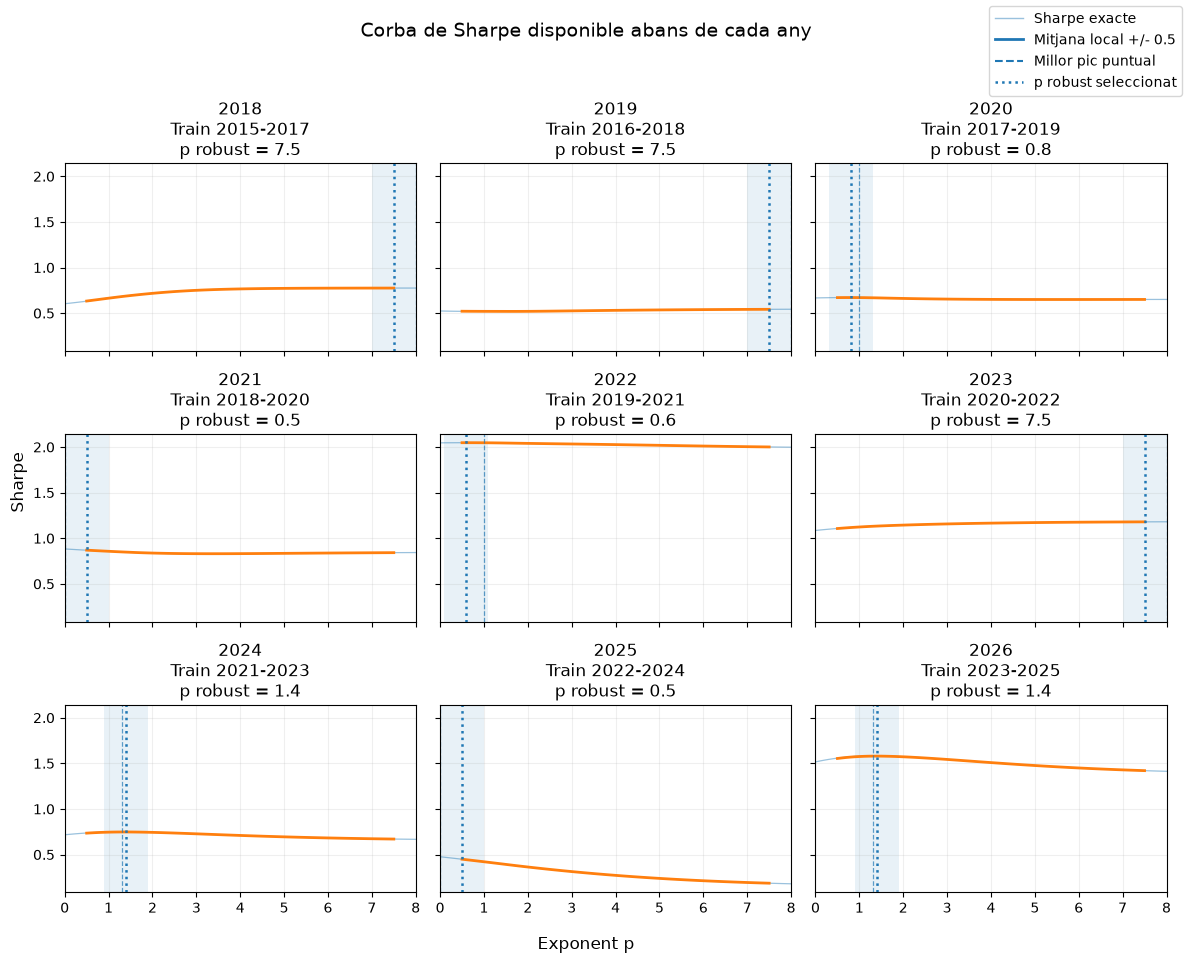

In [63]:
# ============================================================
# CORBES DE SHARPE DE p ABANS DE CADA ANY
#
# - Blau fi: Sharpe exacte
# - Taronja: mitjana local +/- 0.5 en p
# - Linia discontinua: maxim puntual del Sharpe
# - Linia de punts: p robust seleccionat
# - Zona ombrejada: interval +/- 0.5 del p robust
# ============================================================

years = sorted(
    p_train_curves.keys()
)


n_cols = 3

n_rows = int(
    np.ceil(
        len(years) / n_cols
    )
)


fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 3.2 * n_rows),
    sharex=True,
    sharey=True
)


axes = np.array(
    axes
).flatten()


for i, year in enumerate(
    years
):

    ax = axes[i]


    # ========================================================
    # DADES
    # ========================================================

    sharpe_curve = (
        p_train_curves[
            year
        ]["Sharpe"]
    )


    robust_curve = (
        p_train_curves[
            year
        ]["Robust"]
    )


    selected_p = float(
        p_train_curves[
            year
        ]["Selected p"]
    )


    peak_p = float(
        sharpe_curve.idxmax()
    )


    # ========================================================
    # SHARPE EXACTE
    # ========================================================

    ax.plot(
        sharpe_curve.index,
        sharpe_curve.values,
        linewidth=0.9,
        alpha=0.45,
        label="Sharpe exacte"
    )


    # ========================================================
    # SHARPE ROBUST:
    # MITJANA LOCAL +/- 0.5
    # ========================================================

    ax.plot(
        robust_curve.index,
        robust_curve.values,
        linewidth=2.0,
        label="Sharpe robust"
    )


    # ========================================================
    # INTERVAL UTILITZAT AL VOLTANT DEL p ROBUST
    # ========================================================

    ax.axvspan(
        max(
            0,
            selected_p - 0.5
        ),
        min(
            8,
            selected_p + 0.5
        ),
        alpha=0.10
    )


    # ========================================================
    # MILLOR PIC PUNTUAL
    # ========================================================

    ax.axvline(
        peak_p,
        linestyle="--",
        linewidth=0.9,
        alpha=0.7
    )


    # ========================================================
    # MILLOR REGIO ROBUSTA
    # ========================================================

    ax.axvline(
        selected_p,
        linestyle=":",
        linewidth=1.8
    )


    # ========================================================
    # TITOL
    # ========================================================

    train_start_year = (
        year - 3
    )


    ax.set_title(
        f"{year}\n"
        f"Train {train_start_year}-{year - 1}\n"
        f"p robust = {selected_p:.1f}"
    )


    ax.grid(
        alpha=0.2
    )


    ax.set_xlim(
        0,
        8
    )


# ============================================================
# ELIMINEM PANELS SOBRANTS
# ============================================================

for j in range(
    len(years),
    len(axes)
):

    axes[j].axis(
        "off"
    )


# ============================================================
# TITOLS GENERALS
# ============================================================

fig.suptitle(
    "Corba de Sharpe disponible abans de cada any",
    fontsize=14
)


fig.supxlabel(
    "Exponent p"
)


fig.supylabel(
    "Sharpe"
)


# ============================================================
# LLEGENDA UNICA
# ============================================================

handles = [

    plt.Line2D(
        [0],
        [0],
        linewidth=1,
        alpha=0.45,
        label="Sharpe exacte"
    ),

    plt.Line2D(
        [0],
        [0],
        linewidth=2,
        label="Mitjana local +/- 0.5"
    ),

    plt.Line2D(
        [0],
        [0],
        linestyle="--",
        label="Millor pic puntual"
    ),

    plt.Line2D(
        [0],
        [0],
        linestyle=":",
        linewidth=1.8,
        label="p robust seleccionat"
    )
]


fig.legend(
    handles=handles,
    loc="upper right"
)


plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.95
    ]
)


plt.show()

## 28. Robustesa temporal del model de consens

La selecció adaptativa de l'exponent $p$ ha resultat inestable.

Les corbes de Sharpe de cada train són molt planes i, en molts casos, el selector acaba triant un extrem del rang.

En canvi, utilitzant tota la mostra havíem observat una plataforma robusta aproximada:

$$
p\in[3,5]
$$

Ara comprovarem si aquesta família de models supera de manera consistent el model simple Fixed 8m.

Utilitzarem finestres rolling de 36 mesos i calcularem:

- CAGR;
- Sharpe;
- Max Drawdown.

Compararem:

- Fixed $p=3$;
- Fixed $p=4$;
- Fixed $p=5$;
- Fixed 8 mesos;
- Buy & Hold.

L'objectiu no és trobar quin dels tres valors de $p$ és millor, sinó comprovar si tota la regió $p=3-5$ mostra un comportament semblant i robust al llarg del temps.

Periode analitzat:
2015-01-31 00:00:00 -> 2026-09-30 00:00:00
Mesos: 141

COMPARACIO ROLLING CONTRA FIXED 8m:


,Model,Windows,CAGR > Fixed 8m,Sharpe > Fixed 8m,Better MaxDD,Avg CAGR Difference,Avg Sharpe Difference,Avg MaxDD Difference
0,p=3,106,55.7%,49.1%,54.7%,-0.08 pp,-0.030,0.08 pp
1,p=4,106,51.9%,47.2%,54.7%,-0.05 pp,-0.037,0.07 pp
2,p=5,106,46.2%,43.4%,53.8%,-0.01 pp,-0.044,0.05 pp


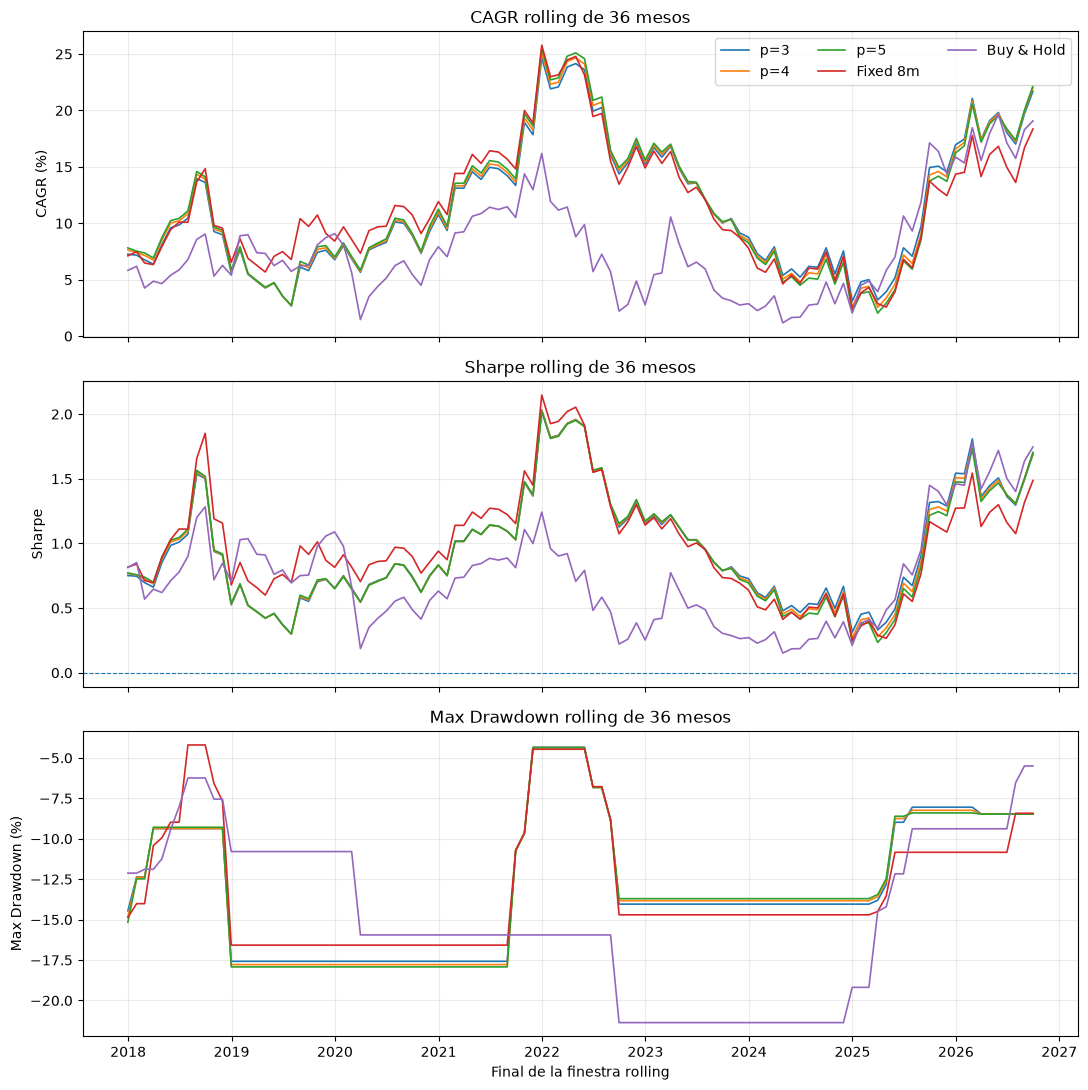

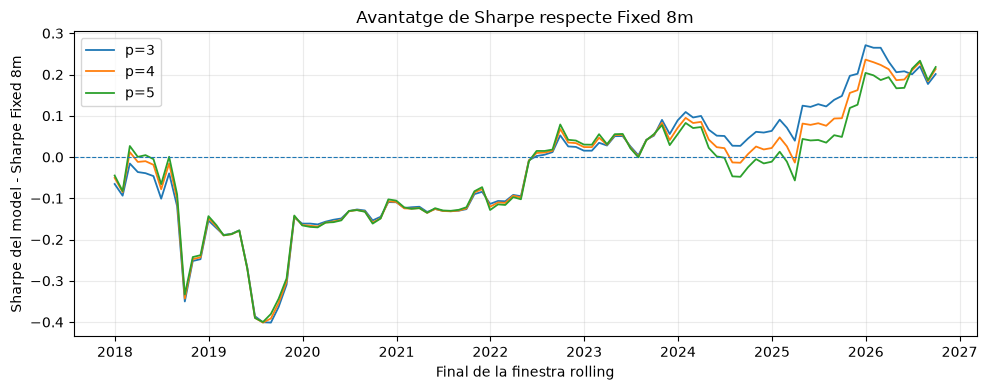

In [64]:
# ROBUSTESA TEMPORAL DEL CONSENS p=3, 4 I 5

rolling_months = 36
min_months = 30

cost_bps = 10
cost_rate = cost_bps / 10000


# 1. FUNCIONS

def backtest_weights_rolling(
    weights,
    returns,
    cost_rate
):

    weights = (
        weights
        .reindex(
            returns.index
        )
    )

    gross_returns = (
        weights
        * returns
    ).sum(axis=1)

    turnover = (
        weights
        .diff()
        .abs()
        .sum(axis=1)
    )

    turnover.iloc[0] = (
        weights
        .iloc[0]
        .abs()
        .sum()
    )

    net_returns = (
        gross_returns
        - turnover * cost_rate
    )

    return net_returns


def calculate_window_metrics(
    returns
):

    returns = (
        returns
        .dropna()
    )

    n_months = len(
        returns
    )

    if n_months < min_months:

        return None

    total_return = (
        (1 + returns).prod()
        - 1
    )

    years = (
        n_months / 12
    )

    cagr = (
        (1 + total_return)
        ** (1 / years)
        - 1
    )

    volatility = (
        returns.std()
        * np.sqrt(12)
    )

    if returns.std() == 0:

        sharpe = np.nan

    else:

        sharpe = (
            returns.mean()
            / returns.std()
            * np.sqrt(12)
        )

    equity = (
        1 + returns
    ).cumprod()

    drawdown = (
        equity
        / equity.cummax()
        - 1
    )

    max_drawdown = (
        drawdown.min()
    )

    return {

        "CAGR":
            cagr,

        "Volatility":
            volatility,

        "Sharpe":
            sharpe,

        "Max Drawdown":
            max_drawdown
    }


# 2. PERIODE COMU

common_index = (
    asset_returns.index
)


for p in [
    3.0,
    4.0,
    5.0
]:

    common_index = (
        common_index
        .intersection(
            weights_by_p[
                p
            ].index
        )
    )


common_index = (
    common_index
    .intersection(
        strategy_weights[
            "Fixed 8m"
        ].index
    )
    .sort_values()
)


returns_common = (
    asset_returns
    .reindex(
        common_index
    )
)


# 3. RETORNS DELS p FIXOS

strategy_returns_temporal = {}


for p in [
    3.0,
    4.0,
    5.0
]:

    weights = (
        weights_by_p[
            p
        ]
        .reindex(
            common_index
        )
    )

    strategy_returns_temporal[
        f"p={int(p)}"
    ] = (
        backtest_weights_rolling(
            weights,
            returns_common,
            cost_rate
        )
    )


# 4. FIXED 8m

fixed_8_weights = (
    strategy_weights[
        "Fixed 8m"
    ]
    .reindex(
        common_index
    )
)


fixed_8_returns = (
    backtest_weights_rolling(
        fixed_8_weights,
        returns_common,
        cost_rate
    )
)


strategy_returns_temporal[
    "Fixed 8m"
] = fixed_8_returns


# 5. BUY & HOLD

buyhold_sleeves = (
    1
    + returns_common
).cumprod() / len(
    cs_tickers
)


buyhold_equity = (
    buyhold_sleeves
    .sum(axis=1)
)


buyhold_returns = (
    buyhold_equity
    .pct_change()
)


buyhold_returns.iloc[0] = (
    buyhold_equity.iloc[0]
    - 1
)


strategy_returns_temporal[
    "Buy & Hold"
] = buyhold_returns


# 6. DATAFRAME COMU

temporal_returns_df = (
    pd.DataFrame(
        strategy_returns_temporal
    )
    .dropna()
)


print(
    "Periode analitzat:"
)

print(
    temporal_returns_df.index.min(),
    "->",
    temporal_returns_df.index.max()
)

print(
    "Mesos:",
    len(
        temporal_returns_df
    )
)


# 7. METRIQUES ROLLING DE 36 MESOS

rolling_rows = []


for end_position in range(
    rolling_months - 1,
    len(
        temporal_returns_df
    )
):

    start_position = (
        end_position
        - rolling_months
        + 1
    )

    window = (
        temporal_returns_df
        .iloc[
            start_position:
            end_position + 1
        ]
    )

    end_date = (
        window.index[-1]
    )

    start_date = (
        window.index[0]
    )


    for strategy in (
        temporal_returns_df.columns
    ):

        metrics = (
            calculate_window_metrics(
                window[
                    strategy
                ]
            )
        )

        if metrics is None:
            continue

        rolling_rows.append({

            "Start Date":
                start_date,

            "End Date":
                end_date,

            "Strategy":
                strategy,

            **metrics
        })


rolling_metrics_df = (
    pd.DataFrame(
        rolling_rows
    )
)


# 8. TAULES PIVOT PER GRAFICS

rolling_cagr = (
    rolling_metrics_df
    .pivot(
        index="End Date",
        columns="Strategy",
        values="CAGR"
    )
)


rolling_sharpe = (
    rolling_metrics_df
    .pivot(
        index="End Date",
        columns="Strategy",
        values="Sharpe"
    )
)


rolling_maxdd = (
    rolling_metrics_df
    .pivot(
        index="End Date",
        columns="Strategy",
        values="Max Drawdown"
    )
)


# 9. RESUM CONTRA FIXED 8m

comparison_rows = []


for model in [
    "p=3",
    "p=4",
    "p=5"
]:

    valid_cagr = (
        rolling_cagr[
            [
                model,
                "Fixed 8m"
            ]
        ]
        .dropna()
    )

    valid_sharpe = (
        rolling_sharpe[
            [
                model,
                "Fixed 8m"
            ]
        ]
        .dropna()
    )

    valid_maxdd = (
        rolling_maxdd[
            [
                model,
                "Fixed 8m"
            ]
        ]
        .dropna()
    )


    cagr_win_rate = (
        valid_cagr[
            model
        ]
        >
        valid_cagr[
            "Fixed 8m"
        ]
    ).mean()


    sharpe_win_rate = (
        valid_sharpe[
            model
        ]
        >
        valid_sharpe[
            "Fixed 8m"
        ]
    ).mean()


    maxdd_win_rate = (
        valid_maxdd[
            model
        ]
        >
        valid_maxdd[
            "Fixed 8m"
        ]
    ).mean()


    avg_cagr_difference = (
        valid_cagr[
            model
        ]
        -
        valid_cagr[
            "Fixed 8m"
        ]
    ).mean()


    avg_sharpe_difference = (
        valid_sharpe[
            model
        ]
        -
        valid_sharpe[
            "Fixed 8m"
        ]
    ).mean()


    avg_maxdd_difference = (
        valid_maxdd[
            model
        ]
        -
        valid_maxdd[
            "Fixed 8m"
        ]
    ).mean()


    comparison_rows.append({

        "Model":
            model,

        "Windows":
            len(
                valid_cagr
            ),

        "CAGR > Fixed 8m":
            cagr_win_rate,

        "Sharpe > Fixed 8m":
            sharpe_win_rate,

        "Better MaxDD":
            maxdd_win_rate,

        "Avg CAGR Difference":
            avg_cagr_difference,

        "Avg Sharpe Difference":
            avg_sharpe_difference,

        "Avg MaxDD Difference":
            avg_maxdd_difference
    })


rolling_comparison_df = (
    pd.DataFrame(
        comparison_rows
    )
)


rolling_comparison_display = (
    rolling_comparison_df.copy()
)


for col in [
    "CAGR > Fixed 8m",
    "Sharpe > Fixed 8m",
    "Better MaxDD"
]:

    rolling_comparison_display[col] = (
        rolling_comparison_display[col]
        * 100
    ).map(
        lambda x:
            f"{x:.1f}%"
    )


for col in [
    "Avg CAGR Difference",
    "Avg MaxDD Difference"
]:

    rolling_comparison_display[col] = (
        rolling_comparison_display[col]
        * 100
    ).map(
        lambda x:
            f"{x:.2f} pp"
    )


rolling_comparison_display[
    "Avg Sharpe Difference"
] = (
    rolling_comparison_display[
        "Avg Sharpe Difference"
    ].map(
        lambda x:
            f"{x:.3f}"
    )
)


print(
    "\nCOMPARACIO ROLLING CONTRA FIXED 8m:"
)

display(
    rolling_comparison_display
)


# 10. GRAFICS

fig, axes = plt.subplots(
    3,
    1,
    figsize=(11, 11),
    sharex=True
)


models_to_plot = [
    "p=3",
    "p=4",
    "p=5",
    "Fixed 8m",
    "Buy & Hold"
]


for model in models_to_plot:

    axes[0].plot(
        rolling_cagr.index,
        rolling_cagr[
            model
        ] * 100,
        label=model,
        linewidth=1.2
    )


axes[0].set_title(
    "CAGR rolling de 36 mesos"
)

axes[0].set_ylabel(
    "CAGR (%)"
)

axes[0].grid(
    alpha=0.25
)

axes[0].legend(
    ncol=3
)


for model in models_to_plot:

    axes[1].plot(
        rolling_sharpe.index,
        rolling_sharpe[
            model
        ],
        label=model,
        linewidth=1.2
    )


axes[1].set_title(
    "Sharpe rolling de 36 mesos"
)

axes[1].set_ylabel(
    "Sharpe"
)

axes[1].axhline(
    0,
    linestyle="--",
    linewidth=0.8
)

axes[1].grid(
    alpha=0.25
)


for model in models_to_plot:

    axes[2].plot(
        rolling_maxdd.index,
        rolling_maxdd[
            model
        ] * 100,
        label=model,
        linewidth=1.2
    )


axes[2].set_title(
    "Max Drawdown rolling de 36 mesos"
)

axes[2].set_xlabel(
    "Final de la finestra rolling"
)

axes[2].set_ylabel(
    "Max Drawdown (%)"
)

axes[2].grid(
    alpha=0.25
)


plt.tight_layout()

plt.show()


# 11. DIFERENCIA DE SHARPE CONTRA FIXED 8m

plt.figure(
    figsize=(10, 4)
)


for model in [
    "p=3",
    "p=4",
    "p=5"
]:

    difference = (
        rolling_sharpe[
            model
        ]
        -
        rolling_sharpe[
            "Fixed 8m"
        ]
    )

    plt.plot(
        difference.index,
        difference,
        label=model,
        linewidth=1.3
    )


plt.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)


plt.title(
    "Avantatge de Sharpe respecte Fixed 8m"
)

plt.xlabel(
    "Final de la finestra rolling"
)

plt.ylabel(
    "Sharpe del model - Sharpe Fixed 8m"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()

## 29. Validació fora de l'univers original

Fins ara el model s'ha desenvolupat sobre el mateix univers d'ETFs.

Per comprovar si el comportament és generalitzable, congelarem tots els paràmetres i aplicarem exactament el mateix sistema a un univers diferent.

Utilitzarem els ETFs sectorials dels EUA:

- XLB: Materials
- XLE: Energy
- XLF: Financials
- XLI: Industrials
- XLK: Technology
- XLP: Consumer Staples
- XLU: Utilities
- XLV: Health Care
- XLY: Consumer Discretionary

No optimitzarem cap paràmetre nou.

Mantindrem:

$$
TopN=3
$$

$$
ShortTrain=2.2-3.0y
$$

$$
LongTrain=4.7-5.5y
$$

$$
FixedMomentum=8m
$$

i compararem:

$$
p=3,\quad p=4,\quad p=5
$$

amb Fixed 8m i Buy & Hold.

Si la família $p=3-5$ continua funcionant en aquest univers diferent, tindrem una evidència molt més forta que el mecanisme de consens no és simplement una particularitat dels actius utilitzats per construir-lo.

Descarregant univers sectorial...
Precalculant lookbacks...
Lookbacks: 100.0% (232/232)
Lookbacks precalculats.

Periode OOS sectorial: 2006 -> 2026

VALIDACIO EN UNIVERS SECTORIAL:


,Strategy,Total Return,CAGR,Volatility,Sharpe,Max Drawdown
0,Consensus p=3,704.78%,10.57%,15.09%,0.74,-40.14%
1,Consensus p=4,736.50%,10.78%,15.44%,0.74,-40.16%
2,Consensus p=5,763.33%,10.95%,15.71%,0.74,-40.64%
3,Fixed 8m,686.10%,10.45%,14.69%,0.75,-39.46%
4,Short Train,586.37%,9.73%,14.44%,0.72,-44.18%
5,Long Train,564.61%,9.56%,14.58%,0.70,-43.20%
6,Buy & Hold,701.68%,10.55%,14.36%,0.77,-47.65%



LOOKBACKS SELECCIONATS:


Mountain,Long Train 4.7-5.5y,Short Train 2.2-3.0y
Year,,
2006,11.95,9.43
2007,11.57,7.29
2008,9.95,2.05
2009,12.00,12.00
2010,12.00,4.43
2011,3.19,3.48
2012,4.43,4.43
2013,4.29,2.95
2014,9.38,6.62


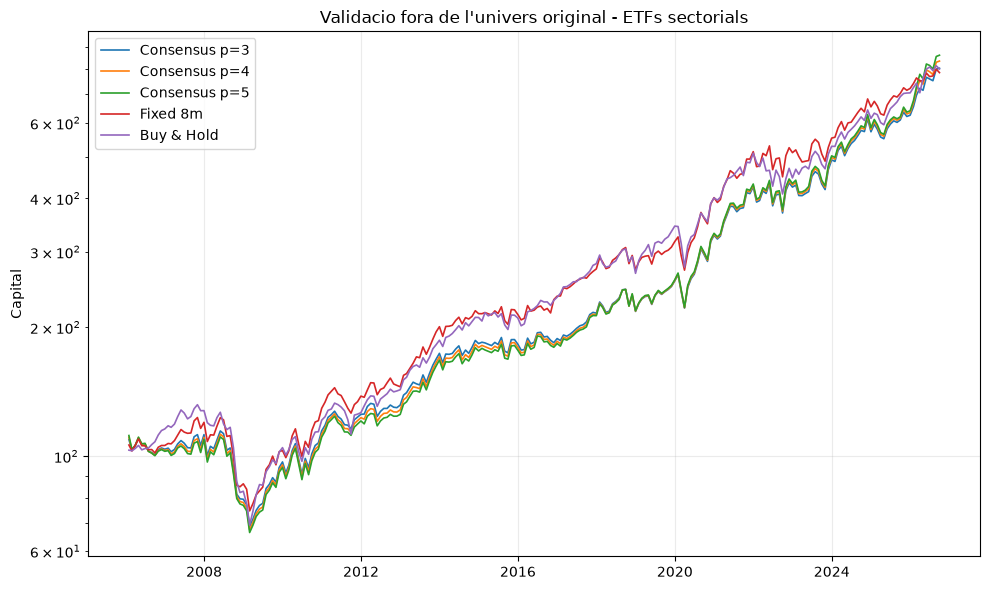

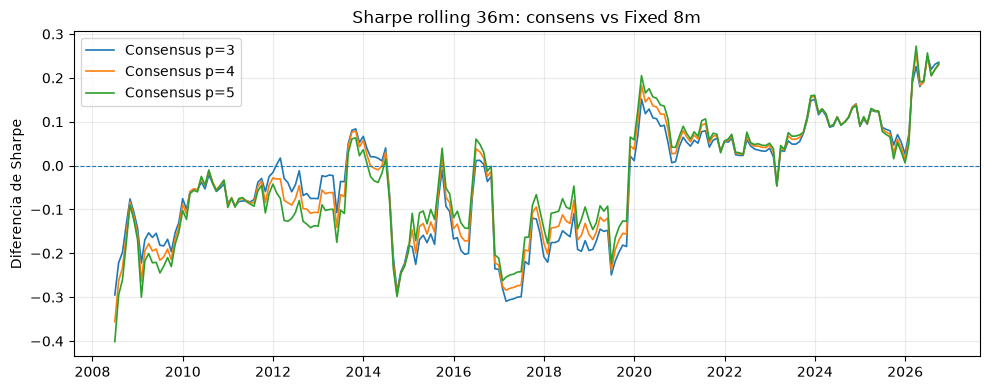

In [65]:
# VALIDACIO FORA DE L'UNIVERS ORIGINAL: ETF SECTORIALS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


sector_tickers = [
    "XLB", "XLE", "XLF",
    "XLI", "XLK", "XLP",
    "XLU", "XLV", "XLY"
]

download_start = "2000-01-01"

top_n = 3

cost_bps = 10
cost_rate = cost_bps / 10000

candidate_lookbacks = range(
    21,
    253
)


train_mountains = {

    "Short Train 2.2-3.0y":
        np.round(
            np.arange(
                2.2,
                3.01,
                0.1
            ),
            1
        ),

    "Long Train 4.7-5.5y":
        np.round(
            np.arange(
                4.7,
                5.51,
                0.1
            ),
            1
        )
}


print(
    "Descarregant univers sectorial..."
)


raw_sector = yf.download(
    sector_tickers,
    start=download_start,
    auto_adjust=True,
    progress=False
)


if isinstance(
    raw_sector.columns,
    pd.MultiIndex
):

    sector_prices = (
        raw_sector["Close"]
        .copy()
    )

else:

    raise ValueError(
        "No s'ha rebut el format esperat "
        "de yfinance."
    )


sector_prices = (
    sector_prices[
        sector_tickers
    ]
    .dropna(
        how="all"
    )
)


sector_monthly_prices = (
    sector_prices
    .resample("ME")
    .last()
)


sector_monthly_returns = (
    sector_monthly_prices
    .pct_change()
)


def backtest_monthly_validation(
    weights,
    returns,
    cost_rate
):

    common = (
        weights.index
        .intersection(
            returns.index
        )
    )


    w = (
        weights
        .reindex(
            common
        )
    )


    r = (
        returns
        .reindex(
            common
        )
    )


    valid = (
        w.notna().all(axis=1)
        &
        r.notna().all(axis=1)
    )


    w = (
        w.loc[
            valid
        ]
    )


    r = (
        r.loc[
            valid
        ]
    )


    if len(w) == 0:

        return (
            pd.Series(
                dtype=float
            ),
            pd.Series(
                dtype=float
            )
        )


    gross_returns = (
        w
        .mul(r)
        .sum(axis=1)
    )


    turnover = (
        w
        .diff()
        .abs()
        .sum(axis=1)
    )


    turnover.iloc[0] = (
        w.iloc[0]
        .abs()
        .sum()
    )


    net_returns = (
        gross_returns
        - turnover
        * cost_rate
    )


    return (
        net_returns,
        turnover
    )


def performance_metrics_validation(
    returns
):

    r = (
        returns
        .dropna()
    )


    equity = (
        1 + r
    ).cumprod()


    total_return = (
        equity.iloc[-1]
        - 1
    )


    years = (
        len(r) / 12
    )


    cagr = (
        equity.iloc[-1]
        ** (1 / years)
        - 1
    )


    volatility = (
        r.std()
        * np.sqrt(12)
    )


    sharpe = (
        r.mean()
        / r.std()
        * np.sqrt(12)
    )


    drawdown = (
        equity
        / equity.cummax()
        - 1
    )


    return {

        "Total Return":
            total_return,

        "CAGR":
            cagr,

        "Volatility":
            volatility,

        "Sharpe":
            sharpe,

        "Max Drawdown":
            drawdown.min()
    }


print(
    "Precalculant lookbacks..."
)


weights_by_lb_sector = {}

returns_by_lb_sector = {}


total_lbs = len(
    list(
        candidate_lookbacks
    )
)


for n, lb in enumerate(
    candidate_lookbacks,
    start=1
):

    momentum_daily = (
        sector_prices
        / sector_prices.shift(lb)
        - 1
    )


    momentum_monthly = (
        momentum_daily
        .resample("ME")
        .last()
    )


    ranks = (
        momentum_monthly
        .rank(
            axis=1,
            ascending=False,
            method="first"
        )
    )


    signal_weights = (
        (ranks <= top_n)
        .astype(float)
        / top_n
    )


    enough_assets = (
        momentum_monthly
        .notna()
        .sum(axis=1)
        >= top_n
    )


    signal_weights.loc[
        ~enough_assets
    ] = np.nan


    applied_weights = (
        signal_weights
        .shift(1)
        .reindex(
            sector_monthly_returns.index
        )
    )


    strategy_returns, _ = (
        backtest_monthly_validation(
            applied_weights,
            sector_monthly_returns,
            cost_rate
        )
    )


    weights_by_lb_sector[
        lb
    ] = applied_weights


    returns_by_lb_sector[
        lb
    ] = strategy_returns


    if (
        n == 1
        or n % 40 == 0
        or n == total_lbs
    ):

        print(
            f"\rLookbacks: "
            f"{100 * n / total_lbs:.1f}% "
            f"({n}/{total_lbs})",
            end=""
        )


print(
    "\nLookbacks precalculats."
)


strategy_returns_by_lb_sector = (
    pd.DataFrame(
        returns_by_lb_sector
    )
    .sort_index()
)


def robust_lookback_for_train_sector(
    train_start,
    train_end,
    train_years
):

    train_data = (
        strategy_returns_by_lb_sector
        .loc[
            train_start:
            train_end
        ]
    )


    min_months = int(
        np.ceil(
            train_years
            * 12
            * 0.80
        )
    )


    counts = (
        train_data.count()
    )


    sharpe_curve = (
        train_data.mean()
        / train_data.std()
        * np.sqrt(12)
    )


    sharpe_curve = (
        sharpe_curve[
            counts >= min_months
        ]
        .replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        )
        .dropna()
        .sort_index()
    )


    if sharpe_curve.empty:

        return None


    robust_curve = (
        sharpe_curve
        .rolling(
            window=65,
            center=True,
            min_periods=33
        )
        .mean()
        .dropna()
    )


    if robust_curve.empty:

        return None


    return int(
        robust_curve.idxmax()
    )


first_available_year = (
    sector_monthly_returns
    .dropna(
        how="all"
    )
    .index.min()
    .year
)


first_test_year = (
    first_available_year
    + 6
)


last_test_year = (
    sector_monthly_returns
    .dropna(
        how="all"
    )
    .index.max()
    .year
)


oos_years = range(
    first_test_year,
    last_test_year + 1
)


print(
    "\nPeriode OOS sectorial:",
    first_test_year,
    "->",
    last_test_year
)


mountain_weight_parts = {

    name: []

    for name in train_mountains
}


selection_rows = []


for mountain_name, train_grid in (
    train_mountains.items()
):

    for year in oos_years:

        selected_lbs = []


        test_start = pd.Timestamp(
            f"{year}-01-01"
        )


        test_end = pd.Timestamp(
            f"{year}-12-31"
        )


        train_end = (
            test_start
            - pd.Timedelta(
                days=1
            )
        )


        for train_years in train_grid:

            train_days = int(
                round(
                    train_years
                    * 365.25
                )
            )


            train_start = (
                test_start
                - pd.Timedelta(
                    days=train_days
                )
            )


            selected_lb = (
                robust_lookback_for_train_sector(
                    train_start,
                    train_end,
                    train_years
                )
            )


            if selected_lb is not None:

                selected_lbs.append(
                    selected_lb
                )


        if len(
            selected_lbs
        ) == 0:

            continue


        consensus_lb = int(
            round(
                np.median(
                    selected_lbs
                )
            )
        )


        year_weights = (
            weights_by_lb_sector[
                consensus_lb
            ]
            .loc[
                test_start:
                test_end
            ]
            .copy()
        )


        if len(
            year_weights
        ) == 0:

            continue


        mountain_weight_parts[
            mountain_name
        ].append(
            year_weights
        )


        selection_rows.append({

            "Mountain":
                mountain_name,

            "Year":
                year,

            "Consensus Days":
                consensus_lb,

            "Consensus Months":
                consensus_lb / 21,

            "Internal Std Months":
                np.std(
                    np.array(
                        selected_lbs
                    ) / 21,
                    ddof=1
                )
                if len(
                    selected_lbs
                ) > 1
                else 0
        })


mountain_weights_sector = {}


for mountain_name, parts in (
    mountain_weight_parts.items()
):

    weights = (
        pd.concat(
            parts
        )
        .sort_index()
    )


    weights = (
        weights.loc[
            ~weights.index.duplicated(
                keep="first"
            )
        ]
    )


    mountain_weights_sector[
        mountain_name
    ] = weights


selection_sector_df = pd.DataFrame(
    selection_rows
)


fixed_8_lb = (
    8 * 21
)


fixed_8_weights_sector = (
    weights_by_lb_sector[
        fixed_8_lb
    ]
)


common_index = (
    mountain_weights_sector[
        "Short Train 2.2-3.0y"
    ]
    .dropna(
        how="any"
    )
    .index
    .intersection(
        mountain_weights_sector[
            "Long Train 4.7-5.5y"
        ]
        .dropna(
            how="any"
        )
        .index
    )
    .intersection(
        fixed_8_weights_sector
        .dropna(
            how="any"
        )
        .index
    )
    .intersection(
        sector_monthly_returns
        .dropna(
            how="any"
        )
        .index
    )
    .sort_values()
)


short_weights = (
    mountain_weights_sector[
        "Short Train 2.2-3.0y"
    ]
    .reindex(
        common_index
    )
)


long_weights = (
    mountain_weights_sector[
        "Long Train 4.7-5.5y"
    ]
    .reindex(
        common_index
    )
)


fixed_weights = (
    fixed_8_weights_sector
    .reindex(
        common_index
    )
)


returns_common = (
    sector_monthly_returns
    .reindex(
        common_index
    )
)


votes = (
    (short_weights > 0).astype(float)
    +
    (long_weights > 0).astype(float)
    +
    (fixed_weights > 0).astype(float)
)


consensus_weights = {}


for p in [
    3.0,
    4.0,
    5.0
]:

    scores = (
        votes ** p
    )


    weights = (
        scores
        .div(
            scores.sum(axis=1),
            axis=0
        )
    )


    consensus_weights[
        p
    ] = weights


comparison_returns = {}


for p in [
    3.0,
    4.0,
    5.0
]:

    returns, _ = (
        backtest_monthly_validation(
            consensus_weights[
                p
            ],
            returns_common,
            cost_rate
        )
    )


    comparison_returns[
        f"Consensus p={int(p)}"
    ] = returns


fixed_returns, _ = (
    backtest_monthly_validation(
        fixed_weights,
        returns_common,
        cost_rate
    )
)


comparison_returns[
    "Fixed 8m"
] = fixed_returns


short_returns, _ = (
    backtest_monthly_validation(
        short_weights,
        returns_common,
        cost_rate
    )
)


comparison_returns[
    "Short Train"
] = short_returns


long_returns, _ = (
    backtest_monthly_validation(
        long_weights,
        returns_common,
        cost_rate
    )
)


comparison_returns[
    "Long Train"
] = long_returns


buyhold_sleeves = (
    1
    + returns_common
).cumprod() / len(
    sector_tickers
)


buyhold_equity = (
    buyhold_sleeves
    .sum(axis=1)
)


buyhold_returns = (
    buyhold_equity
    .pct_change()
)


buyhold_returns.iloc[0] = (
    buyhold_equity.iloc[0]
    - 1
)


comparison_returns[
    "Buy & Hold"
] = buyhold_returns


result_rows = []


for name, returns in (
    comparison_returns.items()
):

    metrics = (
        performance_metrics_validation(
            returns
        )
    )


    result_rows.append({

        "Strategy":
            name,

        **metrics
    })


validation_results_df = pd.DataFrame(
    result_rows
)


validation_display = (
    validation_results_df.copy()
)


for col in [
    "Total Return",
    "CAGR",
    "Volatility",
    "Max Drawdown"
]:

    validation_display[col] = (
        validation_display[col]
        * 100
    ).map(
        lambda x:
            f"{x:.2f}%"
    )


validation_display[
    "Sharpe"
] = (
    validation_display[
        "Sharpe"
    ].map(
        lambda x:
            f"{x:.2f}"
    )
)


print(
    "\nVALIDACIO EN UNIVERS SECTORIAL:"
)


display(
    validation_display
)


print(
    "\nLOOKBACKS SELECCIONATS:"
)


display(
    selection_sector_df
    .pivot(
        index="Year",
        columns="Mountain",
        values="Consensus Months"
    )
    .round(2)
)


plt.figure(
    figsize=(10, 6)
)


for name in [
    "Consensus p=3",
    "Consensus p=4",
    "Consensus p=5",
    "Fixed 8m",
    "Buy & Hold"
]:

    equity = (
        1
        + comparison_returns[
            name
        ]
    ).cumprod() * 100


    plt.plot(
        equity,
        label=name,
        linewidth=1.2
    )


plt.title(
    "Validacio fora de l'univers original - ETFs sectorials"
)


plt.ylabel(
    "Capital"
)


plt.yscale(
    "log"
)


plt.grid(
    alpha=0.25
)


plt.legend()


plt.tight_layout()


plt.show()


returns_validation_df = pd.DataFrame({

    name:
        comparison_returns[
            name
        ]

    for name in [
        "Consensus p=3",
        "Consensus p=4",
        "Consensus p=5",
        "Fixed 8m"
    ]
}).dropna()


rolling_sharpe = (
    returns_validation_df
    .rolling(
        36,
        min_periods=30
    )
    .mean()
    /
    returns_validation_df
    .rolling(
        36,
        min_periods=30
    )
    .std()
    * np.sqrt(12)
)


plt.figure(
    figsize=(10, 4)
)


for name in [
    "Consensus p=3",
    "Consensus p=4",
    "Consensus p=5"
]:

    difference = (
        rolling_sharpe[
            name
        ]
        -
        rolling_sharpe[
            "Fixed 8m"
        ]
    )


    plt.plot(
        difference,
        label=name,
        linewidth=1.2
    )


plt.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)


plt.title(
    "Sharpe rolling 36m: consens vs Fixed 8m"
)


plt.ylabel(
    "Diferencia de Sharpe"
)


plt.grid(
    alpha=0.25
)


plt.legend()


plt.tight_layout()


plt.show()

## 30. Segona validació fora de mostra: països

Volem distingir entre tres possibilitats:

1. el model de consens és una regla general;
2. funciona només en universos amb determinades característiques;
3. està sobreajustat a l'univers original.

Utilitzarem un tercer univers format per ETFs de diferents països:

- EWJ: Japó
- EWU: Regne Unit
- EWG: Alemanya
- EWQ: França
- EWC: Canadà
- EWA: Austràlia
- EWH: Hong Kong
- EWS: Singapur
- EWT: Taiwan

Mantindrem congelats tots els paràmetres del model.

A més de la performance, mesurarem dues característiques de l'univers:

### Correlació mitjana

Mesura fins a quin punt els actius tendeixen a moure's junts.

### Dispersió cross-sectional

Mesura quant diferents són els retorns dels actius en un mateix mes.

Si el consens funciona millor en universos amb menor correlació i major dispersió, podria existir una explicació estructural del seu comportament.

Descarregant: ETFs de paisos
Lookbacks: 100.0%
Lookbacks calculats.

RESULTATS: ETFs de paisos


,Strategy,Total Return,CAGR,Volatility,Sharpe,Max Drawdown
0,Consensus p=3,158.93%,4.69%,18.72%,0.34,-62.20%
1,Consensus p=4,168.98%,4.88%,18.84%,0.35,-61.69%
2,Consensus p=5,179.05%,5.07%,18.95%,0.36,-61.30%
3,Fixed 8m,172.59%,4.95%,18.77%,0.35,-61.85%
4,Buy & Hold,316.30%,7.12%,18.11%,0.47,-58.53%



CARACTERISTIQUES DE L'UNIVERS:


,Universe,Assets,Start,End,Avg Pairwise Correlation,Avg Monthly Dispersion
0,ETFs de paisos,9,2006-01-31,2026-09-30,0.745,2.81%


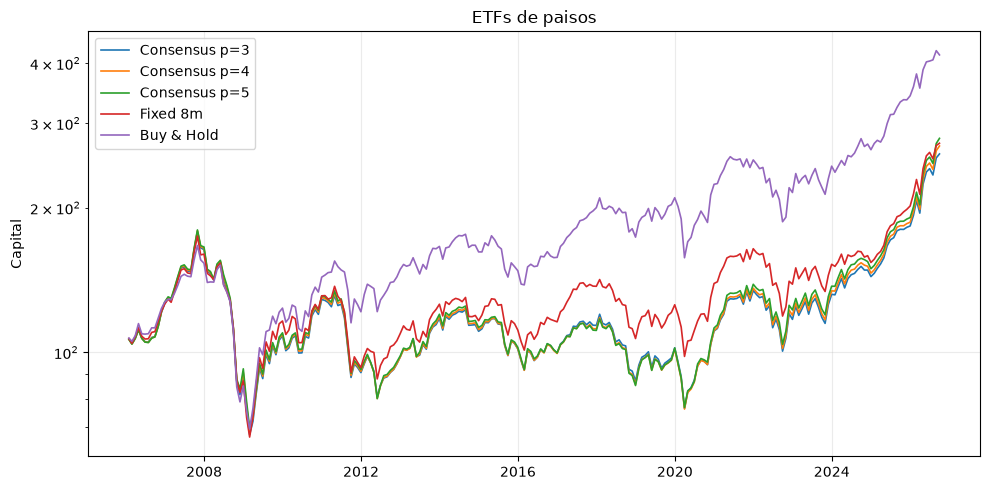

In [66]:
# FUNCIO DE VALIDACIO PER QUALSEVOL UNIVERS

def validate_consensus_universe(
    tickers,
    universe_name,
    download_start="2000-01-01",
    top_n=3,
    cost_bps=10
):

    cost_rate = (
        cost_bps / 10000
    )

    candidate_lookbacks = range(
        21,
        253
    )

    train_mountains_local = {

        "Short Train 2.2-3.0y":
            np.round(
                np.arange(
                    2.2,
                    3.01,
                    0.1
                ),
                1
            ),

        "Long Train 4.7-5.5y":
            np.round(
                np.arange(
                    4.7,
                    5.51,
                    0.1
                ),
                1
            )
    }


    print(
        f"Descarregant: {universe_name}"
    )


    raw = yf.download(
        tickers,
        start=download_start,
        auto_adjust=True,
        progress=False
    )


    if not isinstance(
        raw.columns,
        pd.MultiIndex
    ):

        raise ValueError(
            "Format inesperat de yfinance."
        )


    prices = (
        raw["Close"]
        .copy()
        .reindex(
            columns=tickers
        )
    )


    prices = (
        prices.dropna(
            how="all"
        )
    )


    monthly_prices = (
        prices
        .resample("ME")
        .last()
    )


    monthly_returns = (
        monthly_prices
        .pct_change()
    )


    def backtest(
        weights,
        returns
    ):

        common = (
            weights.index
            .intersection(
                returns.index
            )
        )


        w = (
            weights
            .reindex(common)
        )


        r = (
            returns
            .reindex(common)
        )


        valid = (
            w.notna().all(axis=1)
            &
            r.notna().all(axis=1)
        )


        w = (
            w.loc[valid]
        )


        r = (
            r.loc[valid]
        )


        gross = (
            w * r
        ).sum(axis=1)


        turnover = (
            w.diff()
            .abs()
            .sum(axis=1)
        )


        if len(
            turnover
        ) > 0:

            turnover.iloc[0] = (
                w.iloc[0]
                .abs()
                .sum()
            )


        net = (
            gross
            - turnover
            * cost_rate
        )


        return (
            net,
            turnover
        )


    def metrics(
        returns
    ):

        r = (
            returns.dropna()
        )


        equity = (
            1 + r
        ).cumprod()


        years = (
            len(r) / 12
        )


        total_return = (
            equity.iloc[-1] - 1
        )


        cagr = (
            equity.iloc[-1]
            ** (1 / years)
            - 1
        )


        vol = (
            r.std()
            * np.sqrt(12)
        )


        sharpe = (
            r.mean()
            / r.std()
            * np.sqrt(12)
        )


        drawdown = (
            equity
            / equity.cummax()
            - 1
        )


        return {

            "Total Return":
                total_return,

            "CAGR":
                cagr,

            "Volatility":
                vol,

            "Sharpe":
                sharpe,

            "Max Drawdown":
                drawdown.min()
        }


    weights_by_lb = {}

    returns_by_lb = {}


    lookbacks = list(
        candidate_lookbacks
    )


    for n, lb in enumerate(
        lookbacks,
        start=1
    ):

        momentum = (
            prices
            / prices.shift(lb)
            - 1
        )


        momentum_monthly = (
            momentum
            .resample("ME")
            .last()
        )


        ranks = (
            momentum_monthly
            .rank(
                axis=1,
                ascending=False,
                method="first"
            )
        )


        signal_weights = (
            (ranks <= top_n)
            .astype(float)
            / top_n
        )


        enough_assets = (
            momentum_monthly
            .notna()
            .sum(axis=1)
            >= top_n
        )


        signal_weights.loc[
            ~enough_assets
        ] = np.nan


        applied_weights = (
            signal_weights
            .shift(1)
            .reindex(
                monthly_returns.index
            )
        )


        strategy_returns, _ = (
            backtest(
                applied_weights,
                monthly_returns
            )
        )


        weights_by_lb[
            lb
        ] = applied_weights


        returns_by_lb[
            lb
        ] = strategy_returns


        if (
            n == 1
            or n % 40 == 0
            or n == len(
                lookbacks
            )
        ):

            print(
                f"\rLookbacks: "
                f"{100*n/len(lookbacks):.1f}%",
                end=""
            )


    print(
        "\nLookbacks calculats."
    )


    returns_by_lb_df = (
        pd.DataFrame(
            returns_by_lb
        )
        .sort_index()
    )


    def select_robust_lb(
        train_start,
        train_end,
        train_years
    ):

        train_data = (
            returns_by_lb_df
            .loc[
                train_start:
                train_end
            ]
        )


        minimum = int(
            np.ceil(
                train_years
                * 12
                * 0.80
            )
        )


        counts = (
            train_data.count()
        )


        sharpe_curve = (
            train_data.mean()
            / train_data.std()
            * np.sqrt(12)
        )


        sharpe_curve = (
            sharpe_curve[
                counts >= minimum
            ]
            .replace(
                [
                    np.inf,
                    -np.inf
                ],
                np.nan
            )
            .dropna()
            .sort_index()
        )


        if sharpe_curve.empty:

            return None


        robust_curve = (
            sharpe_curve
            .rolling(
                window=65,
                center=True,
                min_periods=33
            )
            .mean()
            .dropna()
        )


        if robust_curve.empty:

            return None


        return int(
            robust_curve.idxmax()
        )


    first_year = (
        monthly_returns
        .dropna(
            how="all"
        )
        .index.min()
        .year
        + 6
    )


    last_year = (
        monthly_returns
        .dropna(
            how="all"
        )
        .index.max()
        .year
    )


    mountain_parts = {

        name: []

        for name
        in train_mountains_local
    }


    selection_rows = []


    for mountain_name, grid in (
        train_mountains_local.items()
    ):

        for year in range(
            first_year,
            last_year + 1
        ):

            test_start = pd.Timestamp(
                f"{year}-01-01"
            )


            test_end = pd.Timestamp(
                f"{year}-12-31"
            )


            train_end = (
                test_start
                - pd.Timedelta(
                    days=1
                )
            )


            selected_lbs = []


            for train_years in grid:

                train_days = int(
                    round(
                        train_years
                        * 365.25
                    )
                )


                train_start = (
                    test_start
                    - pd.Timedelta(
                        days=train_days
                    )
                )


                lb = (
                    select_robust_lb(
                        train_start,
                        train_end,
                        train_years
                    )
                )


                if lb is not None:

                    selected_lbs.append(
                        lb
                    )


            if len(
                selected_lbs
            ) == 0:

                continue


            consensus_lb = int(
                round(
                    np.median(
                        selected_lbs
                    )
                )
            )


            year_weights = (
                weights_by_lb[
                    consensus_lb
                ]
                .loc[
                    test_start:
                    test_end
                ]
            )


            if len(
                year_weights
            ) == 0:

                continue


            mountain_parts[
                mountain_name
            ].append(
                year_weights
            )


            selection_rows.append({

                "Mountain":
                    mountain_name,

                "Year":
                    year,

                "Consensus Months":
                    consensus_lb / 21
            })


    mountain_weights = {}


    for name, parts in (
        mountain_parts.items()
    ):

        combined = (
            pd.concat(
                parts
            )
            .sort_index()
        )


        combined = (
            combined.loc[
                ~combined.index.duplicated(
                    keep="first"
                )
            ]
        )


        mountain_weights[
            name
        ] = combined


    fixed_weights = (
        weights_by_lb[
            8 * 21
        ]
    )


    common_index = (
        mountain_weights[
            "Short Train 2.2-3.0y"
        ]
        .dropna(
            how="any"
        )
        .index
        .intersection(
            mountain_weights[
                "Long Train 4.7-5.5y"
            ]
            .dropna(
                how="any"
            )
            .index
        )
        .intersection(
            fixed_weights
            .dropna(
                how="any"
            )
            .index
        )
        .intersection(
            monthly_returns
            .dropna(
                how="any"
            )
            .index
        )
        .sort_values()
    )


    short_weights = (
        mountain_weights[
            "Short Train 2.2-3.0y"
        ]
        .reindex(
            common_index
        )
    )


    long_weights = (
        mountain_weights[
            "Long Train 4.7-5.5y"
        ]
        .reindex(
            common_index
        )
    )


    fixed_weights = (
        fixed_weights
        .reindex(
            common_index
        )
    )


    returns_common = (
        monthly_returns
        .reindex(
            common_index
        )
    )


    votes = (
        (short_weights > 0)
        .astype(float)

        +

        (long_weights > 0)
        .astype(float)

        +

        (fixed_weights > 0)
        .astype(float)
    )


    comparison_returns = {}


    for p in [
        3.0,
        4.0,
        5.0
    ]:

        scores = (
            votes ** p
        )


        weights = (
            scores
            .div(
                scores.sum(axis=1),
                axis=0
            )
        )


        r, _ = (
            backtest(
                weights,
                returns_common
            )
        )


        comparison_returns[
            f"Consensus p={int(p)}"
        ] = r


    fixed_returns, _ = (
        backtest(
            fixed_weights,
            returns_common
        )
    )


    comparison_returns[
        "Fixed 8m"
    ] = fixed_returns


    buyhold_sleeves = (
        1
        + returns_common
    ).cumprod() / len(
        tickers
    )


    buyhold_equity = (
        buyhold_sleeves.sum(
            axis=1
        )
    )


    buyhold_returns = (
        buyhold_equity
        .pct_change()
    )


    buyhold_returns.iloc[0] = (
        buyhold_equity.iloc[0]
        - 1
    )


    comparison_returns[
        "Buy & Hold"
    ] = buyhold_returns


    results = []


    for name, r in (
        comparison_returns.items()
    ):

        results.append({

            "Strategy":
                name,

            **metrics(
                r
            )
        })


    results_df = pd.DataFrame(
        results
    )


    correlation_matrix = (
        returns_common.corr()
    )


    upper_triangle = (
        np.triu(
            np.ones(
                correlation_matrix.shape,
                dtype=bool
            ),
            k=1
        )
    )


    avg_pairwise_correlation = (
        correlation_matrix
        .where(
            upper_triangle
        )
        .stack()
        .mean()
    )


    monthly_dispersion = (
        returns_common.std(
            axis=1
        )
    )


    avg_monthly_dispersion = (
        monthly_dispersion.mean()
    )


    universe_stats = pd.DataFrame([{

        "Universe":
            universe_name,

        "Assets":
            len(tickers),

        "Start":
            common_index.min(),

        "End":
            common_index.max(),

        "Avg Pairwise Correlation":
            avg_pairwise_correlation,

        "Avg Monthly Dispersion":
            avg_monthly_dispersion
    }])


    print(
        f"\nRESULTATS: {universe_name}"
    )


    display_results = (
        results_df.copy()
    )


    for col in [
        "Total Return",
        "CAGR",
        "Volatility",
        "Max Drawdown"
    ]:

        display_results[col] = (
            display_results[col]
            * 100
        ).map(
            lambda x:
                f"{x:.2f}%"
        )


    display_results[
        "Sharpe"
    ] = (
        display_results[
            "Sharpe"
        ].map(
            lambda x:
                f"{x:.2f}"
        )
    )


    display(
        display_results
    )


    print(
        "\nCARACTERISTIQUES DE L'UNIVERS:"
    )


    universe_stats_display = (
        universe_stats.copy()
    )


    universe_stats_display[
        "Avg Pairwise Correlation"
    ] = (
        universe_stats_display[
            "Avg Pairwise Correlation"
        ]
        .map(
            lambda x:
                f"{x:.3f}"
        )
    )


    universe_stats_display[
        "Avg Monthly Dispersion"
    ] = (
        universe_stats_display[
            "Avg Monthly Dispersion"
        ]
        * 100
    ).map(
        lambda x:
            f"{x:.2f}%"
    )


    display(
        universe_stats_display
    )


    plt.figure(
        figsize=(10, 5)
    )


    for name, r in (
        comparison_returns.items()
    ):

        equity = (
            1
            + r
        ).cumprod() * 100


        plt.plot(
            equity,
            label=name,
            linewidth=1.2
        )


    plt.title(
        universe_name
    )


    plt.ylabel(
        "Capital"
    )


    plt.yscale(
        "log"
    )


    plt.grid(
        alpha=0.25
    )


    plt.legend()


    plt.tight_layout()


    plt.show()


    return {

        "results":
            results_df,

        "universe_stats":
            universe_stats,

        "returns":
            comparison_returns,

        "selection":
            pd.DataFrame(
                selection_rows
            )
    }


country_tickers = [
    "EWJ",
    "EWU",
    "EWG",
    "EWQ",
    "EWC",
    "EWA",
    "EWH",
    "EWS",
    "EWT"
]


country_validation = (
    validate_consensus_universe(
        country_tickers,
        "ETFs de paisos"
    )
)

Candidats valids: 31
['SPY', 'EFA', 'EEM', 'IWM', 'VNQ', 'XLP', 'XLU', 'XLE', 'XLF', 'XLK', 'XOM', 'JNJ', 'WMT', 'NEE', 'CAT', 'JPM', 'MSFT', 'TLT', 'IEF', 'TIP', 'HYG', 'LQD', 'GLD', 'SLV', 'DBC', 'DBA', 'USO', 'UUP', 'FXE', 'FXY', 'FXB']

UNIVERSOS TRIATS NOMES AMB DADES 2008-2014:


,Universe,Tickers,Avg |corr| IS,Max |corr| IS,Avg |corr| OOS,Max |corr| OOS
0,LowCorr_1,"SPY, GLD, WMT, TLT, DBA, FXY, HYG, FXB",0.241,0.741,0.255,0.798
1,LowCorr_2,"TLT, FXE, XLU, SLV, WMT, FXY, IEF, DBA",0.213,0.891,0.283,0.936
2,LowCorr_3,"GLD, XLK, NEE, TLT, USO, LQD, FXY, FXB",0.260,0.620,0.278,0.759
3,LowCorr_4,"UUP, IEF, XLU, SLV, JPM, FXY, LQD, DBC",0.257,0.702,0.311,0.769


C:\Users\Jordi\AppData\Local\Temp\ipykernel_13884\3084915890.py:653: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


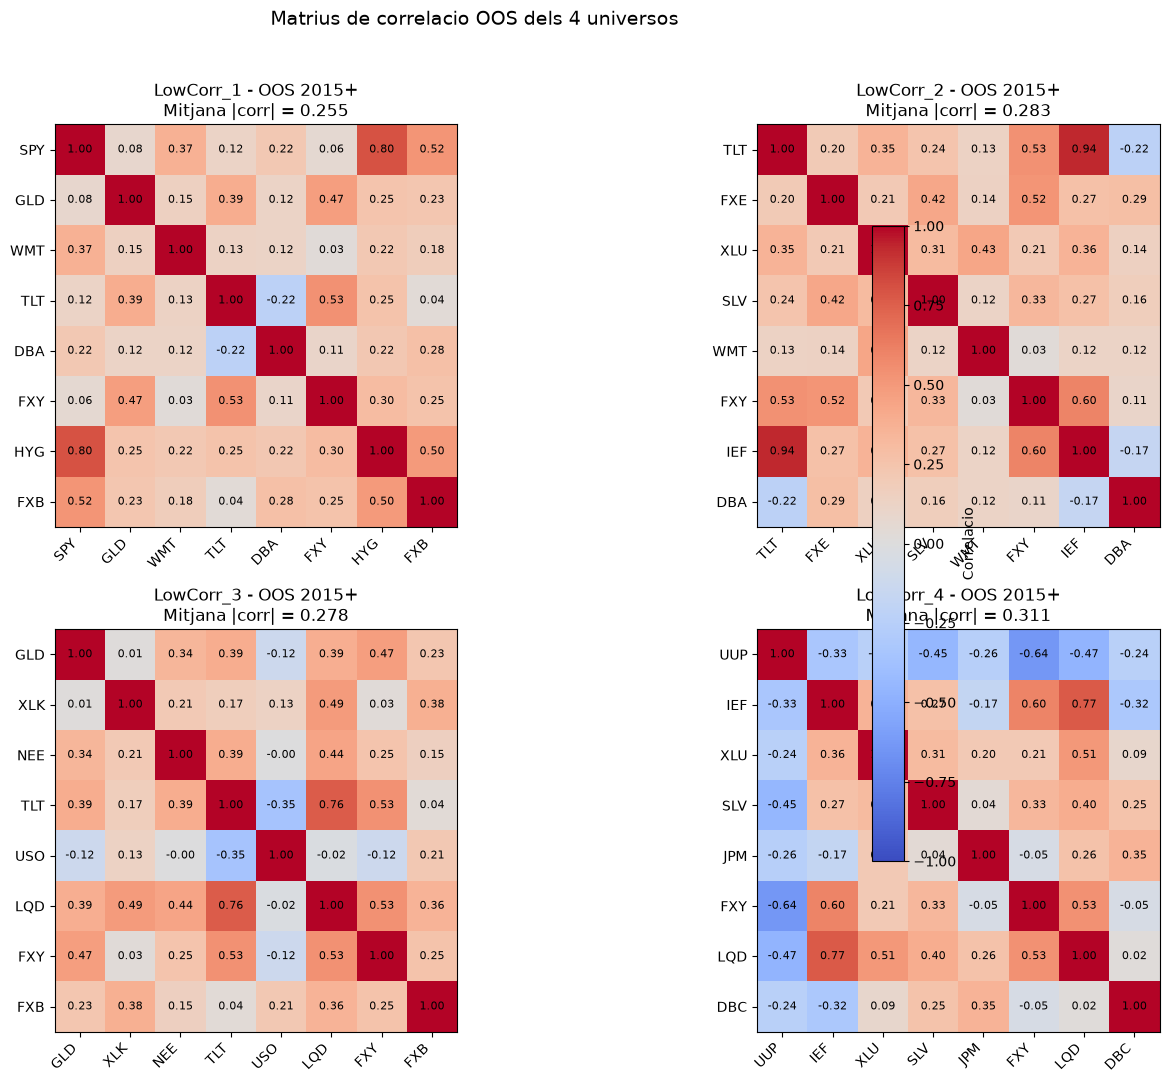

In [67]:
# CREAR 4 UNIVERSOS DE BAIXA CORRELACIO I COMPROVAR-LOS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

selection_start = "2008-01-01"
selection_end = "2014-12-31"
oos_start = "2015-01-01"

target_assets = 8
max_per_bucket = 2

# Petita penalitzacio per evitar que els 4 universos
# acabin sent exactament iguals.
reuse_penalty = 0.04


candidate_buckets = {

    # --------------------------------------------------------
    # EQUITY / SECTORS / EMPRESES
    # --------------------------------------------------------

    "SPY": "Equity",
    "EFA": "Equity",
    "EEM": "Equity",
    "IWM": "Equity",
    "VNQ": "Equity",

    "XLP": "Equity",
    "XLU": "Equity",
    "XLE": "Equity",
    "XLF": "Equity",
    "XLK": "Equity",

    "XOM": "Equity",
    "JNJ": "Equity",
    "WMT": "Equity",
    "NEE": "Equity",
    "CAT": "Equity",
    "JPM": "Equity",
    "MSFT": "Equity",


    # --------------------------------------------------------
    # BONS / TIPUS / CREDIT
    # --------------------------------------------------------

    "TLT": "RatesCredit",
    "IEF": "RatesCredit",
    "TIP": "RatesCredit",
    "HYG": "RatesCredit",
    "LQD": "RatesCredit",


    # --------------------------------------------------------
    # REAL ASSETS / COMMODITIES
    # --------------------------------------------------------

    "GLD": "RealAssets",
    "SLV": "RealAssets",
    "DBC": "RealAssets",
    "DBA": "RealAssets",
    "USO": "RealAssets",


    # --------------------------------------------------------
    # DIVISES
    # --------------------------------------------------------

    "UUP": "FX",
    "FXE": "FX",
    "FXY": "FX",
    "FXB": "FX",
}


candidate_tickers = list(
    candidate_buckets
)


# ============================================================
# 1. DESCARREGUEM TOT EL POOL
# ============================================================

raw = yf.download(
    candidate_tickers,
    start="2007-01-01",
    auto_adjust=True,
    progress=False
)


if not isinstance(
    raw.columns,
    pd.MultiIndex
):

    raise ValueError(
        "Format inesperat de yfinance."
    )


candidate_prices = (
    raw["Close"]
    .reindex(
        columns=candidate_tickers
    )
    .dropna(
        how="all"
    )
)


candidate_monthly_returns = (
    candidate_prices
    .resample("ME")
    .last()
    .pct_change()
)


# ============================================================
# 2. NOMES UTILITZEM 2008-2014 PER CONSTRUIR ELS UNIVERSOS
# ============================================================

selection_returns = (
    candidate_monthly_returns
    .loc[
        selection_start:
        selection_end
    ]
)


coverage = (
    selection_returns
    .notna()
    .mean()
)


annualized_vol = (
    selection_returns
    .std()
    * np.sqrt(12)
)


# Eliminem actius amb poca historia
# o volatilitat gairebe nul·la.

valid_candidates = [

    ticker

    for ticker in candidate_tickers

    if (
        coverage.get(
            ticker,
            0
        ) >= 0.90

        and

        annualized_vol.get(
            ticker,
            0
        ) >= 0.06
    )
]


selection_corr = (
    selection_returns[
        valid_candidates
    ]
    .corr(
        min_periods=48
    )
)


print(
    "Candidats valids:",
    len(valid_candidates)
)

print(
    valid_candidates
)


# ============================================================
# 3. FUNCIONS DE CORRELACIO
# ============================================================

def off_diagonal_abs_values(
    corr_matrix
):

    matrix = (
        corr_matrix
        .abs()
        .to_numpy()
    )


    return matrix[
        np.triu_indices_from(
            matrix,
            k=1
        )
    ]


def avg_abs_corr(
    corr_matrix
):

    values = (
        off_diagonal_abs_values(
            corr_matrix
        )
    )


    return float(
        np.nanmean(
            values
        )
    )


def max_abs_corr(
    corr_matrix
):

    values = (
        off_diagonal_abs_values(
            corr_matrix
        )
    )


    return float(
        np.nanmax(
            values
        )
    )


# ============================================================
# 4. CONSTRUCTOR GREEDY D'UNIVERSOS LOW-CORR
# ============================================================

def build_low_corr_universe(
    anchor,
    reuse_counts
):

    if anchor not in valid_candidates:

        raise ValueError(
            f"Anchor no valid: {anchor}"
        )


    selected = [
        anchor
    ]


    bucket_counts = {

        bucket: 0

        for bucket in set(
            candidate_buckets.values()
        )
    }


    bucket_counts[
        candidate_buckets[
            anchor
        ]
    ] = 1


    while len(
        selected
    ) < target_assets:

        best_ticker = None

        best_score = np.inf


        for ticker in valid_candidates:

            if ticker in selected:

                continue


            bucket = (
                candidate_buckets[
                    ticker
                ]
            )


            if (
                bucket_counts[
                    bucket
                ]
                >= max_per_bucket
            ):

                continue


            correlations = (
                selection_corr
                .loc[
                    ticker,
                    selected
                ]
                .abs()
                .dropna()
            )


            if len(
                correlations
            ) != len(
                selected
            ):

                continue


            # Com menys |correlacio| amb
            # els actius que ja tenim,
            # millor.

            score = (
                correlations.mean()

                +

                reuse_penalty
                * reuse_counts.get(
                    ticker,
                    0
                )
            )


            if score < best_score:

                best_score = score

                best_ticker = ticker


        if best_ticker is None:

            raise ValueError(
                "No s'ha pogut completar "
                "l'univers."
            )


        selected.append(
            best_ticker
        )


        bucket_counts[
            candidate_buckets[
                best_ticker
            ]
        ] += 1


    return selected


# ============================================================
# 5. FEM 4 UNIVERSOS DIFERENTS
# ============================================================

anchors = [
    "SPY",
    "TLT",
    "GLD",
    "UUP"
]


reuse_counts = {

    ticker: 0

    for ticker in valid_candidates
}


low_corr_universes = {}


for i, anchor in enumerate(
    anchors,
    start=1
):

    name = (
        f"LowCorr_{i}"
    )


    selected = (
        build_low_corr_universe(
            anchor,
            reuse_counts
        )
    )


    low_corr_universes[
        name
    ] = selected


    for ticker in selected:

        reuse_counts[
            ticker
        ] += 1


# ============================================================
# 6. ARA MIREM LES CORRELACIONS REALS OOS 2015+
# ============================================================

oos_returns_pool = (
    candidate_monthly_returns
    .loc[
        oos_start:
    ]
)


corr_rows = []

oos_corr_matrices = {}


for name, tickers in (
    low_corr_universes.items()
):

    corr_is = (
        selection_returns[
            tickers
        ]
        .corr()
    )


    corr_oos = (
        oos_returns_pool[
            tickers
        ]
        .corr()
    )


    oos_corr_matrices[
        name
    ] = corr_oos


    corr_rows.append({

        "Universe":
            name,

        "Tickers":
            ", ".join(
                tickers
            ),

        "Avg |corr| IS":
            avg_abs_corr(
                corr_is
            ),

        "Max |corr| IS":
            max_abs_corr(
                corr_is
            ),

        "Avg |corr| OOS":
            avg_abs_corr(
                corr_oos
            ),

        "Max |corr| OOS":
            max_abs_corr(
                corr_oos
            )
    })


universe_corr_stats_df = (
    pd.DataFrame(
        corr_rows
    )
)


print(
    "\nUNIVERSOS TRIATS "
    "NOMES AMB DADES 2008-2014:"
)


display(
    universe_corr_stats_df
    .round(3)
)


# ============================================================
# 7. MATRIUS DE CORRELACIO OOS
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 11)
)


axes = (
    axes.flatten()
)


for ax, (
    name,
    corr
) in zip(
    axes,
    oos_corr_matrices.items()
):

    image = ax.imshow(
        corr.values,
        vmin=-1,
        vmax=1,
        cmap="coolwarm"
    )


    labels = list(
        corr.columns
    )


    ax.set_xticks(
        range(
            len(labels)
        )
    )

    ax.set_yticks(
        range(
            len(labels)
        )
    )


    ax.set_xticklabels(
        labels,
        rotation=45,
        ha="right"
    )


    ax.set_yticklabels(
        labels
    )


    for row in range(
        len(labels)
    ):

        for col in range(
            len(labels)
        ):

            ax.text(
                col,
                row,
                f"{corr.iloc[row, col]:.2f}",
                ha="center",
                va="center",
                fontsize=8
            )


    avg_oos = (
        universe_corr_stats_df
        .loc[
            universe_corr_stats_df[
                "Universe"
            ] == name,
            "Avg |corr| OOS"
        ]
        .iloc[0]
    )


    ax.set_title(
        f"{name} - OOS 2015+\n"
        f"Mitjana |corr| = {avg_oos:.3f}"
    )


fig.colorbar(
    image,
    ax=axes.tolist(),
    shrink=0.75,
    label="Correlacio"
)


fig.suptitle(
    "Matrius de correlacio OOS dels 4 universos",
    fontsize=14
)


plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.96
    ]
)


plt.show()

Calculant LowCorr_1: ['SPY', 'GLD', 'WMT', 'TLT', 'DBA', 'FXY', 'HYG', 'FXB']


,Strategy,Total Return,CAGR,Volatility,Sharpe,Max Drawdown
0,Consensus p=3,181.79%,7.28%,10.40%,0.73,-16.09%
1,Consensus p=4,177.32%,7.16%,10.63%,0.71,-15.98%
2,Consensus p=5,174.57%,7.09%,10.79%,0.69,-15.92%
3,Fixed 8m,191.76%,7.53%,9.97%,0.78,-17.67%
4,Buy & Hold,183.83%,7.33%,8.51%,0.88,-17.49%


,Universe,Assets,Start,End,Avg Pairwise Correlation,Avg Monthly Dispersion
0,LowCorr_1,8,2012-01-31,2026-09-30,0.226,3.14%


Calculant LowCorr_2: ['TLT', 'FXE', 'XLU', 'SLV', 'WMT', 'FXY', 'IEF', 'DBA']


,Strategy,Total Return,CAGR,Volatility,Sharpe,Max Drawdown
0,Consensus p=3,218.54%,7.63%,13.61%,0.61,-21.66%
1,Consensus p=4,208.68%,7.42%,13.96%,0.58,-22.27%
2,Consensus p=5,201.92%,7.27%,14.21%,0.57,-22.67%
3,Fixed 8m,185.96%,6.90%,12.78%,0.59,-19.26%
4,Buy & Hold,137.28%,5.64%,9.44%,0.63,-16.72%


...

,Universe,Assets,Start,End,Avg Pairwise Correlation,Avg Monthly Dispersion
0,LowCorr_4,8,2012-01-31,2026-09-30,0.073,4.21%



RESULTATS OOS 2015+:


,Universe,Strategy,Total Return,CAGR,Volatility,Sharpe,Max Drawdown
0,LowCorr_1,Consensus p=3,139.76%,7.73%,10.86%,0.74,-16.09%
1,LowCorr_1,Consensus p=4,138.12%,7.66%,11.03%,0.73,-15.98%
2,LowCorr_1,Consensus p=5,137.15%,7.63%,11.16%,0.72,-15.92%
3,LowCorr_1,Fixed 8m,116.65%,6.80%,10.37%,0.69,-17.67%
4,LowCorr_1,Buy & Hold,156.54%,8.35%,9.12%,0.93,-17.49%
5,LowCorr_2,Consensus p=3,127.01%,7.23%,13.62%,0.58,-21.66%
6,LowCorr_2,Consensus p=4,116.70%,6.80%,13.90%,0.54,-22.27%
7,LowCorr_2,Consensus p=5,109.85%,6.51%,14.11%,0.52,-22.67%
8,LowCorr_2,Fixed 8m,115.43%,6.75%,12.86%,0.57,-19.26%
9,LowCorr_2,Buy & Hold,108.74%,6.46%,9.97%,0.68,-16.72%



RESUM CONSENS p=4 VS FIXED 8m:


,Universe,Avg |corr| OOS,Max |corr| OOS,Dispersion,p4 CAGR,Fixed CAGR,p4 - Fixed CAGR,p4 Sharpe,Fixed Sharpe,p4 - Fixed Sharpe,p4 MaxDD,Fixed MaxDD,B&H CAGR,B&H Sharpe
0,LowCorr_1,0.255,0.798,3.17%,7.66%,6.80%,0.86%,0.726,0.688,0.038,-15.98%,-17.67%,8.35%,0.927
1,LowCorr_2,0.283,0.936,3.79%,6.80%,6.75%,0.05%,0.544,0.573,-0.029,-22.27%,-19.26%,6.46%,0.679
2,LowCorr_3,0.278,0.759,4.77%,11.31%,13.28%,-1.97%,0.909,1.104,-0.196,-21.13%,-17.34%,11.54%,0.956
3,LowCorr_4,0.311,0.769,4.22%,8.35%,11.27%,-2.92%,0.646,0.921,-0.275,-21.16%,-15.63%,9.93%,0.931


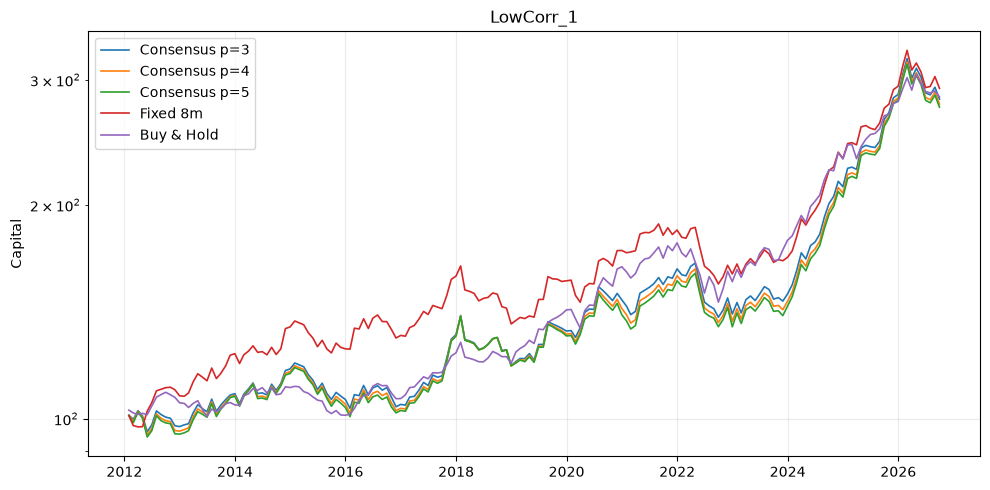

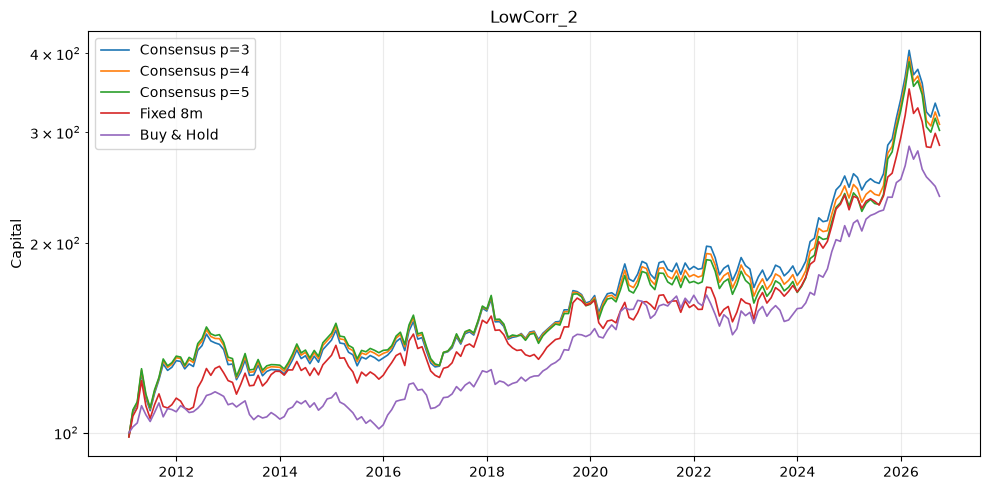

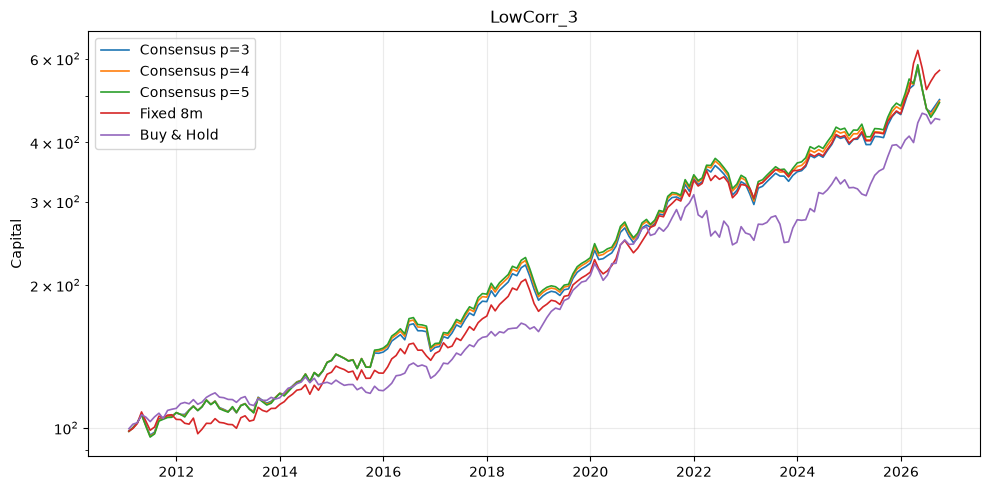

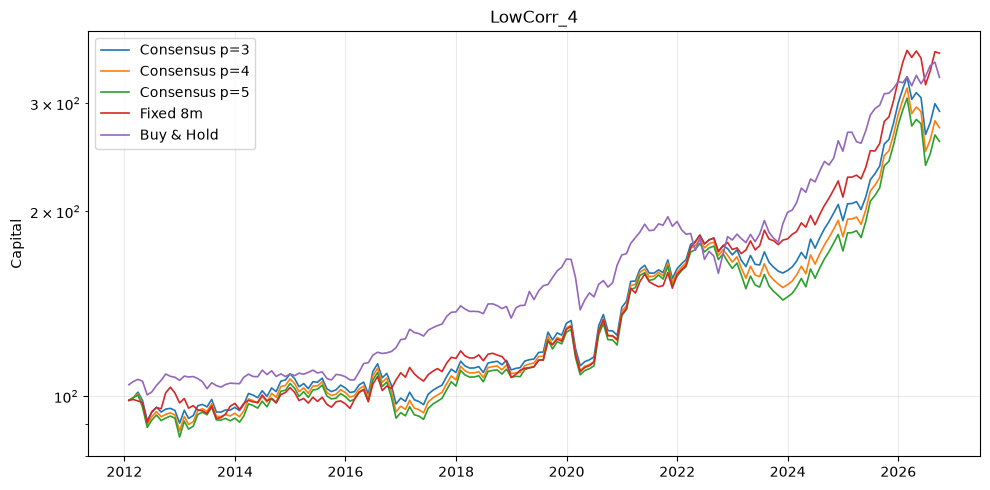

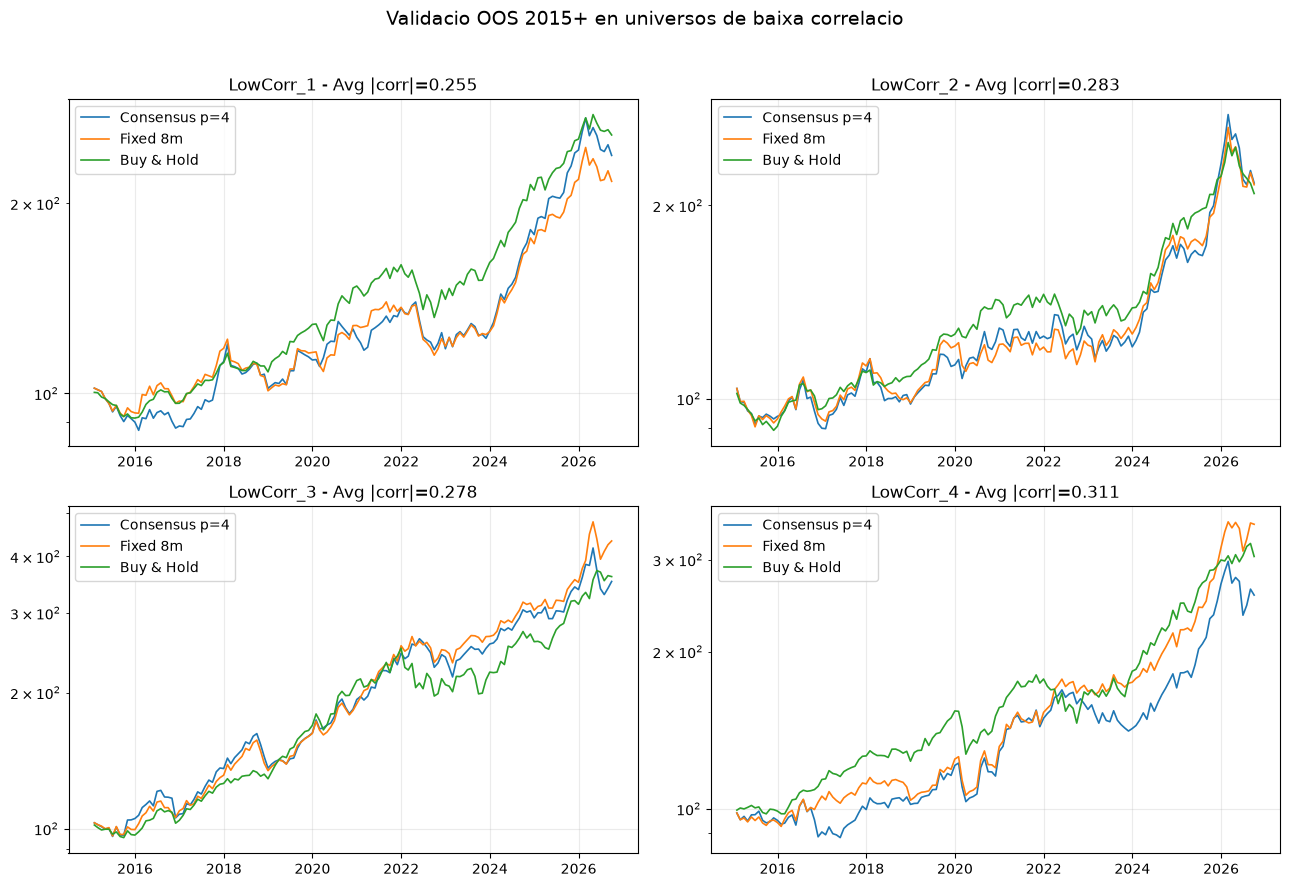

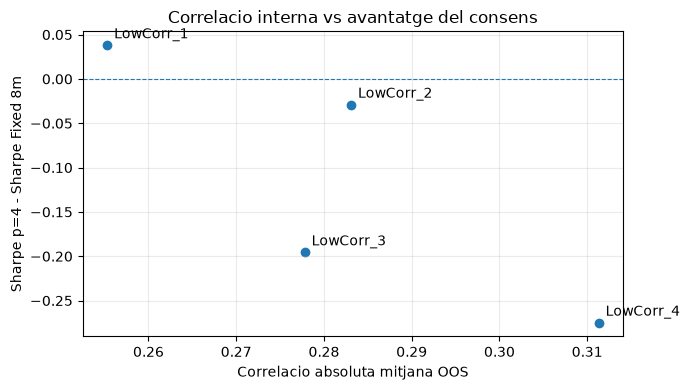

In [68]:
# VALIDAR ELS 4 UNIVERSOS DE BAIXA CORRELACIO DES DE 2015

import io
import contextlib


def monthly_metrics(
    returns
):

    r = (
        returns.dropna()
    )


    equity = (
        1 + r
    ).cumprod()


    years = (
        len(r) / 12
    )


    total_return = (
        equity.iloc[-1]
        - 1
    )


    cagr = (
        equity.iloc[-1]
        ** (1 / years)
        - 1
    )


    volatility = (
        r.std()
        * np.sqrt(12)
    )


    sharpe = (
        r.mean()
        / r.std()
        * np.sqrt(12)
    )


    drawdown = (
        equity
        / equity.cummax()
        - 1
    )


    return {

        "Total Return":
            total_return,

        "CAGR":
            cagr,

        "Volatility":
            volatility,

        "Sharpe":
            sharpe,

        "Max Drawdown":
            drawdown.min()
    }


low_corr_validation_results = {}

all_performance_rows = []

comparison_rows = []


# ============================================================
# 1. EXECUTEM ELS 4 BACKTESTS
# ============================================================

original_display = globals().get(
    "display",
    None
)


original_show = (
    plt.show
)


def silent_display(
    *args,
    **kwargs
):

    pass


try:

    if original_display is not None:

        globals()[
            "display"
        ] = silent_display


    plt.show = (
        lambda *args, **kwargs:
            None
    )


    for name, tickers in (
        low_corr_universes.items()
    ):

        print(
            f"Calculant {name}: "
            f"{tickers}"
        )


        with contextlib.redirect_stdout(
            io.StringIO()
        ):

            validation = (
                validate_consensus_universe(
                    tickers,
                    name
                )
            )


        low_corr_validation_results[
            name
        ] = validation


finally:

    if original_display is not None:

        globals()[
            "display"
        ] = original_display


    plt.show = (
        original_show
    )


# ============================================================
# 2. NOMES RESULTATS OOS 2015+
# ============================================================

for name, validation in (
    low_corr_validation_results.items()
):

    returns_df = (
        pd.DataFrame(
            validation[
                "returns"
            ]
        )
        .loc[
            oos_start:
        ]
        .dropna()
    )


    strategies = [
        "Consensus p=3",
        "Consensus p=4",
        "Consensus p=5",
        "Fixed 8m",
        "Buy & Hold"
    ]


    for strategy in strategies:

        metrics = (
            monthly_metrics(
                returns_df[
                    strategy
                ]
            )
        )


        all_performance_rows.append({

            "Universe":
                name,

            "Strategy":
                strategy,

            **metrics
        })


    metrics_p4 = (
        monthly_metrics(
            returns_df[
                "Consensus p=4"
            ]
        )
    )


    metrics_fixed = (
        monthly_metrics(
            returns_df[
                "Fixed 8m"
            ]
        )
    )


    metrics_bh = (
        monthly_metrics(
            returns_df[
                "Buy & Hold"
            ]
        )
    )


    tickers = (
        low_corr_universes[
            name
        ]
    )


    monthly_oos = (
        candidate_monthly_returns
        .loc[
            oos_start:,
            tickers
        ]
    )


    dispersion = (
        monthly_oos
        .std(
            axis=1
        )
        .mean()
    )


    corr_row = (
        universe_corr_stats_df
        .loc[
            universe_corr_stats_df[
                "Universe"
            ] == name
        ]
        .iloc[0]
    )


    comparison_rows.append({

        "Universe":
            name,

        "Avg |corr| OOS":
            corr_row[
                "Avg |corr| OOS"
            ],

        "Max |corr| OOS":
            corr_row[
                "Max |corr| OOS"
            ],

        "Dispersion":
            dispersion,

        "p4 CAGR":
            metrics_p4[
                "CAGR"
            ],

        "Fixed CAGR":
            metrics_fixed[
                "CAGR"
            ],

        "p4 - Fixed CAGR":
            (
                metrics_p4[
                    "CAGR"
                ]
                -
                metrics_fixed[
                    "CAGR"
                ]
            ),

        "p4 Sharpe":
            metrics_p4[
                "Sharpe"
            ],

        "Fixed Sharpe":
            metrics_fixed[
                "Sharpe"
            ],

        "p4 - Fixed Sharpe":
            (
                metrics_p4[
                    "Sharpe"
                ]
                -
                metrics_fixed[
                    "Sharpe"
                ]
            ),

        "p4 MaxDD":
            metrics_p4[
                "Max Drawdown"
            ],

        "Fixed MaxDD":
            metrics_fixed[
                "Max Drawdown"
            ],

        "B&H CAGR":
            metrics_bh[
                "CAGR"
            ],

        "B&H Sharpe":
            metrics_bh[
                "Sharpe"
            ]
    })


performance_all_df = (
    pd.DataFrame(
        all_performance_rows
    )
)


comparison_low_corr_df = (
    pd.DataFrame(
        comparison_rows
    )
)


# ============================================================
# 3. TAULA COMPLETA
# ============================================================

performance_display = (
    performance_all_df.copy()
)


for col in [
    "Total Return",
    "CAGR",
    "Volatility",
    "Max Drawdown"
]:

    performance_display[col] = (
        performance_display[col]
        * 100
    ).map(
        lambda x:
            f"{x:.2f}%"
    )


performance_display[
    "Sharpe"
] = (
    performance_display[
        "Sharpe"
    ].map(
        lambda x:
            f"{x:.2f}"
    )
)


print(
    "\nRESULTATS OOS 2015+:"
)


display(
    performance_display
)


# ============================================================
# 4. TAULA RESUM
# ============================================================

summary_display = (
    comparison_low_corr_df.copy()
)


for col in [
    "Dispersion",
    "p4 CAGR",
    "Fixed CAGR",
    "p4 - Fixed CAGR",
    "p4 MaxDD",
    "Fixed MaxDD",
    "B&H CAGR"
]:

    summary_display[col] = (
        summary_display[col]
        * 100
    ).map(
        lambda x:
            f"{x:.2f}%"
    )


for col in [
    "Avg |corr| OOS",
    "Max |corr| OOS",
    "p4 Sharpe",
    "Fixed Sharpe",
    "p4 - Fixed Sharpe",
    "B&H Sharpe"
]:

    summary_display[col] = (
        summary_display[col]
        .map(
            lambda x:
                f"{x:.3f}"
        )
    )


print(
    "\nRESUM CONSENS p=4 VS FIXED 8m:"
)


display(
    summary_display
)


# ============================================================
# 5. EQUITY CURVES
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 9)
)


axes = (
    axes.flatten()
)


for ax, (
    name,
    validation
) in zip(
    axes,
    low_corr_validation_results.items()
):

    returns_df = (
        pd.DataFrame(
            validation[
                "returns"
            ]
        )
        .loc[
            oos_start:
        ]
        .dropna()
    )


    for strategy in [
        "Consensus p=4",
        "Fixed 8m",
        "Buy & Hold"
    ]:

        equity = (
            1
            + returns_df[
                strategy
            ]
        ).cumprod() * 100


        ax.plot(
            equity,
            label=strategy,
            linewidth=1.2
        )


    avg_corr = (
        comparison_low_corr_df
        .loc[
            comparison_low_corr_df[
                "Universe"
            ] == name,
            "Avg |corr| OOS"
        ]
        .iloc[0]
    )


    ax.set_title(
        f"{name} - "
        f"Avg |corr|={avg_corr:.3f}"
    )


    ax.set_yscale(
        "log"
    )


    ax.grid(
        alpha=0.25
    )


    ax.legend()


fig.suptitle(
    "Validacio OOS 2015+ "
    "en universos de baixa correlacio",
    fontsize=14
)


plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.96
    ]
)


plt.show()


# ============================================================
# 6. CORRELACIO INTERNA VS AVANTATGE DEL CONSENS
# ============================================================

plt.figure(
    figsize=(7, 4)
)


plt.scatter(
    comparison_low_corr_df[
        "Avg |corr| OOS"
    ],
    comparison_low_corr_df[
        "p4 - Fixed Sharpe"
    ]
)


for _, row in (
    comparison_low_corr_df
    .iterrows()
):

    plt.annotate(
        row[
            "Universe"
        ],
        (
            row[
                "Avg |corr| OOS"
            ],
            row[
                "p4 - Fixed Sharpe"
            ]
        ),
        xytext=(
            5,
            5
        ),
        textcoords=
            "offset points"
    )


plt.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)


plt.title(
    "Correlacio interna vs avantatge del consens"
)


plt.xlabel(
    "Correlacio absoluta mitjana OOS"
)


plt.ylabel(
    "Sharpe p=4 - Sharpe Fixed 8m"
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()


plt.show()

Actius analitzats:
['DBC', 'EEM', 'EFA', 'GLD', 'IWM', 'SPY', 'TLT', 'VNQ']

Periode:
2015-01-31 00:00:00 -> 2026-09-30 00:00:00

INFORMATION COEFFICIENT I REGRESSIO:


,Measure,Months,Mean,Median,Positive
0,IC Fixed 8m,141,0.045,0.000,48.9%
1,IC Votes,141,0.054,0.056,53.2%
2,Incremental Vote IC,141,0.050,0.048,53.2%
3,Beta Fixed,141,0.000,-0.000,48.9%
4,Beta Votes,141,0.003,0.003,54.6%



BOOTSTRAP DEL VALOR INCREMENTAL DELS VOTS:


,Block Months,Incremental IC Mean,Incremental IC CI Low,Incremental IC CI High,Beta Votes Mean,Beta Votes CI Low,Beta Votes CI High
0,6,0.050,-0.016,0.120,0.265%,-0.250%,0.716%
1,12,0.050,-0.007,0.111,0.265%,-0.147%,0.680%


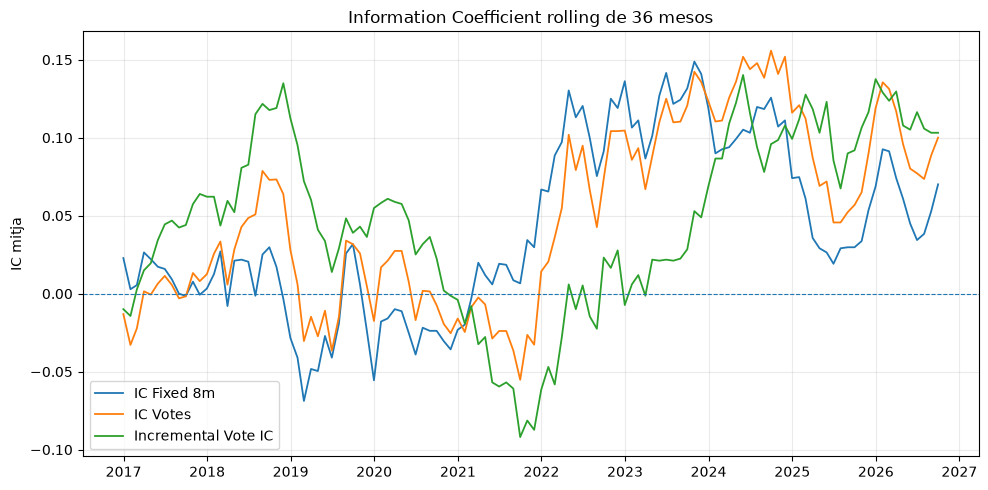

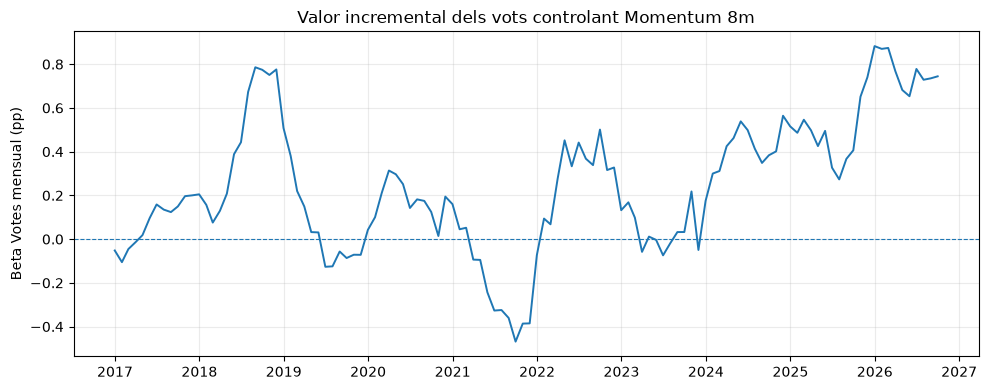

In [69]:
# TEST FINAL DEL CONSENS: APORTA INFORMACIO MES ENLLA DEL MOMENTUM 8M?

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


# PARAMETRES FIXOS

lookback_8m_days = 8 * 21

bootstrap_iterations = 10000

bootstrap_blocks = [
    6,
    12
]

rng_seed = 42


# PREPAREM LES DADES DE VOTS

ic_data = (
    asset_votes_df
    .reset_index()
    .copy()
)


def find_column(
    df,
    candidates
):

    for column in candidates:

        if column in df.columns:

            return column

    raise ValueError(
        "No he trobat cap d'aquestes columnes: "
        + str(candidates)
    )


date_col = find_column(
    ic_data,
    [
        "Return Month",
        "Date",
        "Month"
    ]
)


ticker_col = find_column(
    ic_data,
    [
        "Ticker",
        "Asset",
        "Symbol"
    ]
)


votes_col = find_column(
    ic_data,
    [
        "Votes",
        "Vote"
    ]
)


return_col = find_column(
    ic_data,
    [
        "Asset Return",
        "Return",
        "Future Return"
    ]
)


ic_data[
    date_col
] = pd.to_datetime(
    ic_data[
        date_col
    ]
)


ic_data[
    ticker_col
] = (
    ic_data[
        ticker_col
    ]
    .astype(str)
)


test_tickers = sorted(
    ic_data[
        ticker_col
    ]
    .unique()
)


print(
    "Actius analitzats:"
)

print(
    test_tickers
)


print(
    "\nPeriode:"
)

print(
    ic_data[
        date_col
    ].min(),
    "->",
    ic_data[
        date_col
    ].max()
)


# DESCARREGUEM PREUS PER RECONSTRUIR EXACTAMENT EL MOMENTUM 8M

download_start = (
    ic_data[
        date_col
    ].min()
    - pd.DateOffset(
        years=2
    )
)


download_end = (
    ic_data[
        date_col
    ].max()
    + pd.DateOffset(
        months=1
    )
)


raw_prices = yf.download(
    test_tickers,
    start=download_start.strftime(
        "%Y-%m-%d"
    ),
    end=download_end.strftime(
        "%Y-%m-%d"
    ),
    auto_adjust=True,
    progress=False
)


if isinstance(
    raw_prices.columns,
    pd.MultiIndex
):

    close_prices = (
        raw_prices[
            "Close"
        ]
        .reindex(
            columns=test_tickers
        )
    )

else:

    if len(
        test_tickers
    ) != 1:

        raise ValueError(
            "Format inesperat de yfinance."
        )

    close_prices = pd.DataFrame(
        raw_prices[
            "Close"
        ]
    )

    close_prices.columns = (
        test_tickers
    )


# MOMENTUM DE 8 MESOS

momentum_8m_daily = (
    close_prices
    / close_prices.shift(
        lookback_8m_days
    )
    - 1
)


momentum_8m_monthly = (
    momentum_8m_daily
    .resample(
        "ME"
    )
    .last()
)


# IMPORTANT:
# El retorn del mes t només pot utilitzar
# el senyal conegut abans de començar t.

momentum_8m_signal = (
    momentum_8m_monthly
    .shift(1)
)


momentum_long = (
    momentum_8m_signal
    .stack()
    .rename(
        "Momentum 8m"
    )
    .reset_index()
)


momentum_long.columns = [
    date_col,
    ticker_col,
    "Momentum 8m"
]


# UNIM MOMENTUM, VOTS I RETORN FUTUR

test_data = (
    ic_data
    .merge(
        momentum_long,
        on=[
            date_col,
            ticker_col
        ],
        how="inner"
    )
    .dropna(
        subset=[
            votes_col,
            return_col,
            "Momentum 8m"
        ]
    )
    .copy()
)


# RANK CROSS-SECTIONAL DEL MOMENTUM 8M
#
# 1 = millor momentum
# però per comoditat fem que
# score alt = millor.

test_data[
    "Fixed 8m Score"
] = (
    test_data
    .groupby(
        date_col
    )[
        "Momentum 8m"
    ]
    .rank(
        pct=True,
        method="average"
    )
)


# FUNCIONS AUXILIARS

def zscore_cross_section(
    values
):

    values = np.asarray(
        values,
        dtype=float
    )

    std = np.std(
        values,
        ddof=1
    )

    if (
        not np.isfinite(
            std
        )
        or std == 0
    ):

        return np.full(
            len(values),
            np.nan
        )

    return (
        values
        - np.mean(
            values
        )
    ) / std


def spearman_safe(
    x,
    y
):

    x = pd.Series(
        x
    )

    y = pd.Series(
        y
    )

    if (
        x.nunique()
        < 2
        or y.nunique()
        < 2
    ):

        return np.nan

    return x.corr(
        y,
        method="spearman"
    )


# TEST MES A MES

monthly_rows = []


for month, month_data in (
    test_data
    .groupby(
        date_col
    )
):

    data = (
        month_data[
            [
                ticker_col,
                votes_col,
                return_col,
                "Fixed 8m Score"
            ]
        ]
        .dropna()
        .copy()
    )


    if len(
        data
    ) < 6:

        continue


    future_returns = (
        data[
            return_col
        ]
        .to_numpy(
            dtype=float
        )
    )


    fixed_score = (
        data[
            "Fixed 8m Score"
        ]
        .to_numpy(
            dtype=float
        )
    )


    votes = (
        data[
            votes_col
        ]
        .to_numpy(
            dtype=float
        )
    )


    # IC NORMAL

    ic_fixed = (
        spearman_safe(
            fixed_score,
            future_returns
        )
    )


    ic_votes = (
        spearman_safe(
            votes,
            future_returns
        )
    )


    # ESTANDARDITZEM ELS DOS SENYALS

    z_fixed = (
        zscore_cross_section(
            fixed_score
        )
    )


    z_votes = (
        zscore_cross_section(
            votes
        )
    )


    if (
        np.isnan(
            z_fixed
        ).any()
        or
        np.isnan(
            z_votes
        ).any()
    ):

        continue


    # REGRESSIO:
    #
    # Votes = a + b * Fixed8m + residual
    #
    # El residual son els vots
    # que NO s'expliquen pel momentum 8m.

    x_votes = np.column_stack(
        [
            np.ones(
                len(data)
            ),
            z_fixed
        ]
    )


    beta_votes_on_fixed = (
        np.linalg.lstsq(
            x_votes,
            z_votes,
            rcond=None
        )[0]
    )


    residual_votes = (
        z_votes
        - x_votes
        @ beta_votes_on_fixed
    )


    incremental_ic = (
        spearman_safe(
            residual_votes,
            future_returns
        )
    )


    # REGRESSIO CROSS-SECTIONAL:
    #
    # Retorn futur =
    # alpha
    # + beta_fixed * Momentum8m
    # + beta_votes * Votes

    x_returns = np.column_stack(
        [
            np.ones(
                len(data)
            ),
            z_fixed,
            z_votes
        ]
    )


    betas = (
        np.linalg.lstsq(
            x_returns,
            future_returns,
            rcond=None
        )[0]
    )


    monthly_rows.append({

        "Month":
            month,

        "Assets":
            len(data),

        "IC Fixed 8m":
            ic_fixed,

        "IC Votes":
            ic_votes,

        "Incremental Vote IC":
            incremental_ic,

        "Beta Fixed":
            betas[1],

        "Beta Votes":
            betas[2]
    })


monthly_ic_df = (
    pd.DataFrame(
        monthly_rows
    )
    .set_index(
        "Month"
    )
    .sort_index()
)


# RESUM GENERAL

summary_rows = []


for column in [
    "IC Fixed 8m",
    "IC Votes",
    "Incremental Vote IC",
    "Beta Fixed",
    "Beta Votes"
]:

    series = (
        monthly_ic_df[
            column
        ]
        .dropna()
    )


    summary_rows.append({

        "Measure":
            column,

        "Months":
            len(series),

        "Mean":
            series.mean(),

        "Median":
            series.median(),

        "Positive":
            (
                series > 0
            ).mean()
    })


summary_df = pd.DataFrame(
    summary_rows
)


summary_display = (
    summary_df.copy()
)


summary_display[
    "Mean"
] = (
    summary_display[
        "Mean"
    ]
    .map(
        lambda x:
            f"{x:.3f}"
    )
)


summary_display[
    "Median"
] = (
    summary_display[
        "Median"
    ]
    .map(
        lambda x:
            f"{x:.3f}"
    )
)


summary_display[
    "Positive"
] = (
    summary_display[
        "Positive"
    ]
    * 100
).map(
    lambda x:
        f"{x:.1f}%"
)


print(
    "\nINFORMATION COEFFICIENT I REGRESSIO:"
)


display(
    summary_display
)


# BLOCK BOOTSTRAP DE LES DUES VARIABLES
# QUE REALMENT ENS IMPORTEN:
#
# 1. IC incremental dels vots
# 2. Beta dels vots controlant Fixed 8m

def block_bootstrap_mean(
    series,
    block_length,
    iterations,
    seed
):

    rng = np.random.default_rng(
        seed
    )


    values = (
        series
        .dropna()
        .to_numpy(
            dtype=float
        )
    )


    n = len(
        values
    )


    possible_starts = np.arange(
        0,
        n - block_length + 1
    )


    blocks_needed = int(
        np.ceil(
            n / block_length
        )
    )


    bootstrap_means = np.empty(
        iterations
    )


    for i in range(
        iterations
    ):

        starts = (
            rng.choice(
                possible_starts,
                size=blocks_needed,
                replace=True
            )
        )


        sample = np.concatenate(
            [
                values[
                    start:
                    start + block_length
                ]

                for start in starts
            ]
        )[:n]


        bootstrap_means[
            i
        ] = np.mean(
            sample
        )


    return bootstrap_means


bootstrap_rows = []


for block_months in (
    bootstrap_blocks
):

    incremental_boot = (
        block_bootstrap_mean(
            monthly_ic_df[
                "Incremental Vote IC"
            ],
            block_months,
            bootstrap_iterations,
            rng_seed
        )
    )


    beta_votes_boot = (
        block_bootstrap_mean(
            monthly_ic_df[
                "Beta Votes"
            ],
            block_months,
            bootstrap_iterations,
            rng_seed
        )
    )


    incremental_ci = (
        np.percentile(
            incremental_boot,
            [
                2.5,
                97.5
            ]
        )
    )


    beta_ci = (
        np.percentile(
            beta_votes_boot,
            [
                2.5,
                97.5
            ]
        )
    )


    bootstrap_rows.append({

        "Block Months":
            block_months,

        "Incremental IC Mean":
            monthly_ic_df[
                "Incremental Vote IC"
            ].mean(),

        "Incremental IC CI Low":
            incremental_ci[0],

        "Incremental IC CI High":
            incremental_ci[1],

        "Beta Votes Mean":
            monthly_ic_df[
                "Beta Votes"
            ].mean(),

        "Beta Votes CI Low":
            beta_ci[0],

        "Beta Votes CI High":
            beta_ci[1]
    })


bootstrap_df = pd.DataFrame(
    bootstrap_rows
)


bootstrap_display = (
    bootstrap_df.copy()
)


for column in [
    "Incremental IC Mean",
    "Incremental IC CI Low",
    "Incremental IC CI High"
]:

    bootstrap_display[
        column
    ] = (
        bootstrap_display[
            column
        ]
        .map(
            lambda x:
                f"{x:.3f}"
        )
    )


for column in [
    "Beta Votes Mean",
    "Beta Votes CI Low",
    "Beta Votes CI High"
]:

    bootstrap_display[
        column
    ] = (
        bootstrap_display[
            column
        ]
        * 100
    ).map(
        lambda x:
            f"{x:.3f}%"
    )


print(
    "\nBOOTSTRAP DEL VALOR INCREMENTAL DELS VOTS:"
)


display(
    bootstrap_display
)


# ROLLING 36 MESOS

rolling_ic = (
    monthly_ic_df[
        [
            "IC Fixed 8m",
            "IC Votes",
            "Incremental Vote IC"
        ]
    ]
    .rolling(
        36,
        min_periods=24
    )
    .mean()
)


plt.figure(
    figsize=(10, 5)
)


for column in [
    "IC Fixed 8m",
    "IC Votes",
    "Incremental Vote IC"
]:

    plt.plot(
        rolling_ic.index,
        rolling_ic[
            column
        ],
        label=column,
        linewidth=1.3
    )


plt.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)


plt.title(
    "Information Coefficient rolling de 36 mesos"
)


plt.ylabel(
    "IC mitja"
)


plt.grid(
    alpha=0.25
)


plt.legend()


plt.tight_layout()


plt.show()


# BETA INCREMENTAL DELS VOTS

rolling_beta_votes = (
    monthly_ic_df[
        "Beta Votes"
    ]
    .rolling(
        36,
        min_periods=24
    )
    .mean()
)


plt.figure(
    figsize=(10, 4)
)


plt.plot(
    rolling_beta_votes.index,
    rolling_beta_votes * 100,
    linewidth=1.4
)


plt.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)


plt.title(
    "Valor incremental dels vots controlant Momentum 8m"
)


plt.ylabel(
    "Beta Votes mensual (pp)"
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()


plt.show()